# **Import Library**

In [1]:
# ============================================================
# CELL 1. IMPORT LIBRARY
# ============================================================
import os
import random
import math
import copy
import json
import time
import warnings
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import librosa
import soundfile as sf
from scipy.signal import butter, sosfiltfilt
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
import kagglehub
warnings.filterwarnings("ignore")

# **Load Dataset**

In [2]:
import os
import glob
import pandas as pd
import kagglehub
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
# === Step 1: Download & Setup Dataset ===
path = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")
print("Dataset tersimpan di:", path)

DATASET_PATH = os.path.join(path, "respiratory_sound_database", "Respiratory_Sound_Database")
AUDIO_DIR = os.path.join(DATASET_PATH, "audio_and_txt_files")
META_FILE = os.path.join(DATASET_PATH, "patient_diagnosis.csv")

print("\nStruktur Direktori:")
for item in os.listdir(DATASET_PATH):
    print(" -", item)

# === Load diagnosis pasien (opsional untuk konteks, bukan label modelmu) ===
diagnosis_df = pd.read_csv(META_FILE, header=None, names=["patient_id", "disease"])
diagnosis_df["patient_id"] = diagnosis_df["patient_id"].astype(int)

print("\nTotal pasien:", len(diagnosis_df))
print("\nDistribusi diagnosis (konteks):")
print(diagnosis_df["disease"].value_counts())

# === Index pasangan wav dan txt ===
wav_paths = sorted(glob.glob(os.path.join(AUDIO_DIR, "*.wav")))
txt_list = glob.glob(os.path.join(AUDIO_DIR, "*.txt"))

# mapping: stem -> path txt
txt_paths = {os.path.splitext(os.path.basename(p))[0]: p for p in txt_list}

print("\nTotal file wav:", len(wav_paths))
print("Contoh wav:", [os.path.basename(p) for p in wav_paths[:5]])

missing_txt = [
    os.path.basename(w)
    for w in wav_paths
    if os.path.splitext(os.path.basename(w))[0] not in txt_paths
]
print("\nWav tanpa anotasi txt:", len(missing_txt))
if len(missing_txt) > 0:
    print("Contoh:", missing_txt[:5])

Device: cuda
Using Colab cache for faster access to the 'respiratory-sound-database' dataset.
Dataset tersimpan di: /kaggle/input/respiratory-sound-database

Struktur Direktori:
 - patient_diagnosis.csv
 - filename_format.txt
 - audio_and_txt_files
 - filename_differences.txt

Total pasien: 126

Distribusi diagnosis (konteks):
disease
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1
Name: count, dtype: int64

Total file wav: 920
Contoh wav: ['101_1b1_Al_sc_Meditron.wav', '101_1b1_Pr_sc_Meditron.wav', '102_1b1_Ar_sc_Meditron.wav', '103_2b2_Ar_mc_LittC2SE.wav', '104_1b1_Al_sc_Litt3200.wav']

Wav tanpa anotasi txt: 0


# **Segmentasi dan Labeling Berdasarkan File Anotasi**
> Ekstraksi data



In [3]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm import tqdm

# Fungsi baca anotasi TXT: start end crackle wheeze
def parse_annotation(txt_path):
    segments = []
    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 4:
                continue

            start = float(parts[0])
            end = float(parts[1])
            crackle = int(float(parts[2]))
            wheeze = int(float(parts[3]))

            if end <= start:
                continue

            if crackle == 1 and wheeze == 1:
                label = "both"
            elif crackle == 1:
                label = "crackle"
            elif wheeze == 1:
                label = "wheeze"
            else:
                label = "normal"

            segments.append((start, end, crackle, wheeze, label))
    return segments


# ===== Output folder =====
SEGMENTED_DIR = "segmented_audio_precise"
os.makedirs(SEGMENTED_DIR, exist_ok=True)

# ===== Konfigurasi =====
MIN_SEC = 0.0          # kalau mau paksa minimal durasi, isi > 0
MIN_AMPL = 1e-4        # threshold amplitude untuk deteksi segmen "diam"
KEEP_SILENT = False    # True kalau mau simpan segmen diam, False kalau mau buang
TOL_DUR = 0.25         # toleransi beda durasi audio vs max end anotasi (detik)
SAVE_WAV = True        # True kalau mau simpan file segmen wav, False kalau mau metadata saja

meta_rows = []
silent_skipped = 0
empty_skipped = 0
time_mismatch_warn = 0
txt_missing = 0

# Buat lookup diagnosis biar cepat
diag_map = {}
if "patient_id" in diagnosis_df.columns and "disease" in diagnosis_df.columns:
    diag_map = dict(zip(diagnosis_df["patient_id"].astype(int), diagnosis_df["disease"].astype(str)))

print("Memotong audio secara presisi sesuai anotasi (ORIGINAL RAW, tanpa preprocessing dulu)")

for wav_path in tqdm(wav_paths, ncols=100):
    wav_file = os.path.basename(wav_path)
    stem = os.path.splitext(wav_file)[0]

    # anotasi TXT dengan stem yang sama
    txt_path = txt_paths.get(stem, None)
    if txt_path is None or (not os.path.exists(txt_path)):
        txt_missing += 1
        continue

    segments = parse_annotation(txt_path)
    if len(segments) == 0:
        continue

    # baca audio raw (tanpa resample)
    y, sr = sf.read(wav_path, always_2d=False)
    if y.ndim > 1:
        y = y.mean(axis=1)
    y = y.astype(np.float32, copy=False)

    dur_audio = len(y) / float(sr)
    max_end = max(s[1] for s in segments)

    if abs(dur_audio - max_end) > TOL_DUR:
        time_mismatch_warn += 1
        # batasi print agar tidak spam
        if time_mismatch_warn <= 10:
            print(f"[PERINGATAN] {wav_file}: durasi audio {dur_audio:.3f}s vs max anotasi {max_end:.3f}s")

    # patient_id biasanya di depan nama file
    patient_id_str = stem.split("_")[0]
    try:
        patient_id = int(patient_id_str)
    except ValueError:
        patient_id = -1

    disease = diag_map.get(patient_id, "") if patient_id != -1 else ""

    for i, (start, end, crackle, wheeze, label) in enumerate(segments):
        start_samp = int(np.floor(start * sr))
        end_samp = int(np.ceil(end * sr))

        # clamp ke range valid
        start_samp = max(0, min(start_samp, len(y)))
        end_samp = max(0, min(end_samp, len(y)))

        if end_samp <= start_samp:
            empty_skipped += 1
            continue

        segment = y[start_samp:end_samp]

        # optional: paksa minimal durasi
        if MIN_SEC > 0.0:
            min_len = int(MIN_SEC * sr)
            if len(segment) < min_len:
                segment = np.pad(segment, (0, min_len - len(segment)), mode="constant")

        # cek amplitude
        max_amp = float(np.max(np.abs(segment))) if segment.size > 0 else 0.0
        is_silent = max_amp < MIN_AMPL

        if is_silent and (not KEEP_SILENT):
            silent_skipped += 1
            continue

        out_path = ""
        if SAVE_WAV:
            label_dir = os.path.join(SEGMENTED_DIR, label)
            os.makedirs(label_dir, exist_ok=True)

            out_path = os.path.join(
                label_dir,
                f"{stem}_s{start:.3f}_e{end:.3f}_seg{i}.wav"
            )
            sf.write(out_path, segment, sr)

        meta_rows.append({
            "wav_source": wav_path,
            "txt_source": txt_path,
            "file": out_path,
            "sound": label,
            "patient_id": patient_id,
            "disease": disease,           # konteks saja
            "start_sec": float(start),
            "end_sec": float(end),
            "duration_sec": float(len(segment) / sr),
            "crackle": int(crackle),
            "wheeze": int(wheeze),
            "sr_raw": int(sr),
            "max_amp": max_amp,
            "is_silent": int(is_silent),
            "source": "original"
        })

meta_segments = pd.DataFrame(meta_rows)
meta_csv_path = os.path.join(SEGMENTED_DIR, "metadata_segments_precise.csv")
meta_segments.to_csv(meta_csv_path, index=False)

print("\nTotal segmen yang DISIMPAN:", len(meta_segments))
if len(meta_segments) > 0:
    print("\nDistribusi kelas sound:")
    print(meta_segments["sound"].value_counts())

    dur = meta_segments["duration_sec"]
    dur_rounded = dur.round(2)

    print("\nRingkasan variasi durasi segmen")
    print("Durasi minimum (detik):", float(dur.min()))
    print("Durasi maksimum (detik):", float(dur.max()))
    print("Jumlah variasi durasi unik (dibulatkan 2 desimal):", int(dur_rounded.nunique()))

    unique_vals = np.sort(dur_rounded.unique())
    print("\nContoh 20 durasi unik pertama (detik):")
    print(unique_vals[:20])

    top = dur_rounded.value_counts().head(10)
    print("\n10 durasi paling sering muncul (detik -> jumlah segmen):")
    for dval, cnt in top.items():
        print(f"{dval:.2f} -> {int(cnt)}")

print("\nRingkasan masalah saat segmentasi:")
print("Wav tanpa anotasi txt                :", txt_missing)
print("Segmen kosong (end_samp <= start_samp):", empty_skipped)
print("Segmen diam dibuang                  :", silent_skipped)
print("File mismatch durasi vs anotasi      :", time_mismatch_warn)

print("\nMetadata tersimpan di:", meta_csv_path)

Memotong audio secara presisi sesuai anotasi (ORIGINAL RAW, tanpa preprocessing dulu)


  2%|▉                                                             | 14/920 [00:01<02:31,  5.97it/s]

[PERINGATAN] 107_2b3_Al_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s
[PERINGATAN] 107_2b3_Ar_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s


  2%|█                                                             | 16/920 [00:02<02:44,  5.51it/s]

[PERINGATAN] 107_2b3_Ll_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s
[PERINGATAN] 107_2b3_Lr_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s


...

[PERINGATAN] 107_2b4_Al_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.542s
[PERINGATAN] 107_2b4_Ar_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.542s


  2%|█▌                                                            | 23/920 [00:03<02:44,  5.44it/s]

[PERINGATAN] 107_2b4_Ll_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.542s


100%|█████████████████████████████████████████████████████████████| 920/920 [01:29<00:00, 10.30it/s]



Total segmen yang DISIMPAN: 6898

Distribusi kelas sound:
sound
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

Ringkasan variasi durasi segmen
Durasi minimum (detik): 0.20002267573696145
Durasi maksimum (detik): 16.163
Jumlah variasi durasi unik (dibulatkan 2 desimal): 574

Contoh 20 durasi unik pertama (detik):
[0.2  0.23 0.24 0.26 0.29 0.3  0.31 0.32 0.33 0.34 0.36 0.37 0.39 0.4
 0.41 0.43 0.44 0.45 0.46 0.47]

10 durasi paling sering muncul (detik -> jumlah segmen):
2.37 -> 90
2.39 -> 63
2.40 -> 52
2.61 -> 49
2.20 -> 49
2.29 -> 47
2.62 -> 46
2.24 -> 45
2.57 -> 45
2.12 -> 43

Ringkasan masalah saat segmentasi:
Wav tanpa anotasi txt                : 0
Segmen kosong (end_samp <= start_samp): 0
Segmen diam dibuang                  : 0
File mismatch durasi vs anotasi      : 394

Metadata tersimpan di: segmented_audio_precise/metadata_segments_precise.csv



Sumber: segmented_audio_precise/normal/120_1b1_Ar_sc_Meditron_s16.698_e19.734_seg6.wav
Mode  : segment_file
Kelas : normal
Patient ID: 120
Waktu segmen: 16.698s - 19.734s
SR    : 4000
Durasi: 3.036 detik
Max amplitude: 0.781921


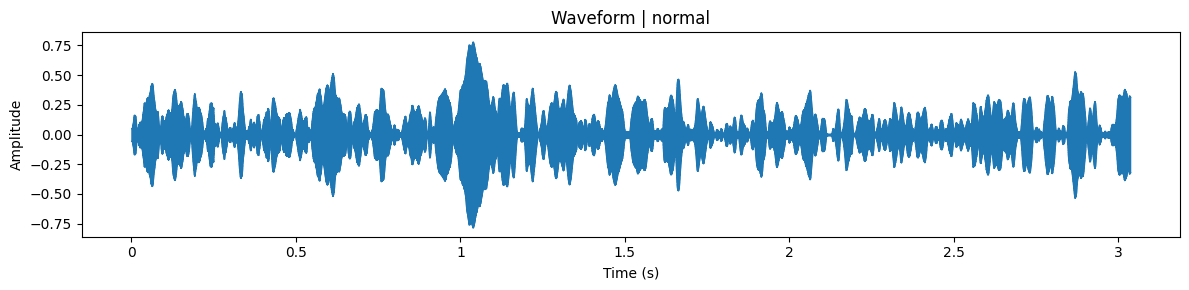

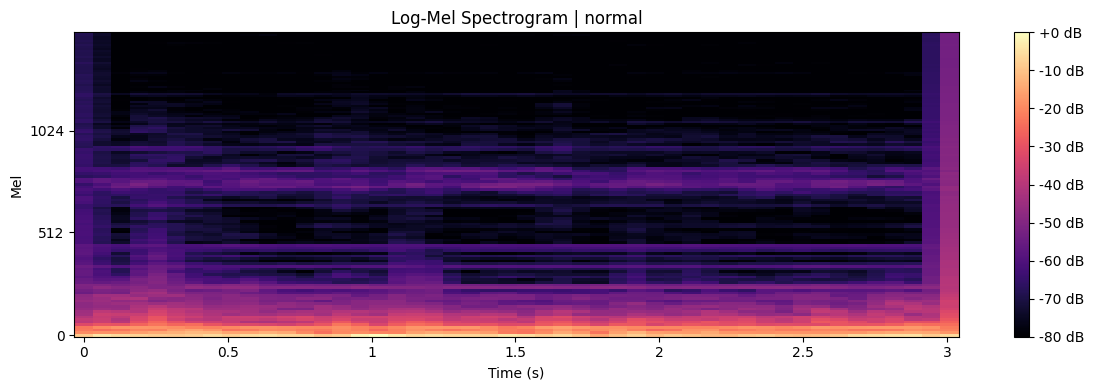


Sumber: segmented_audio_precise/crackle/130_2b2_Ar_mc_AKGC417L_s4.933_e7.466_seg2.wav
Mode  : segment_file
Kelas : crackle
Patient ID: 130
Waktu segmen: 4.933s - 7.466s
SR    : 44100
Durasi: 2.533 detik
Max amplitude: 0.501038


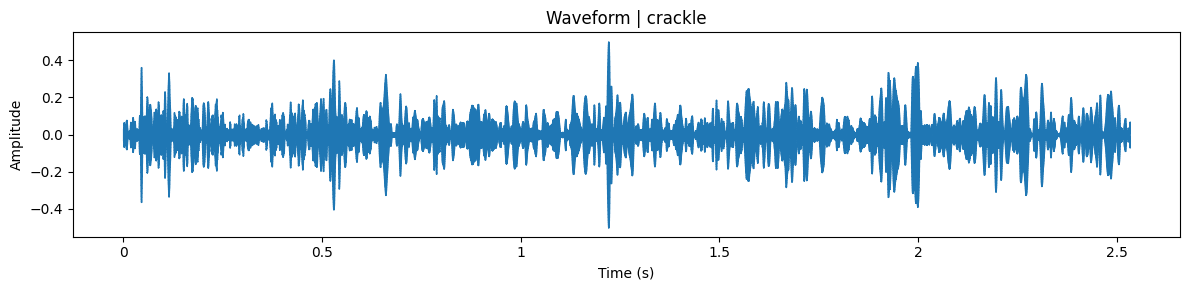

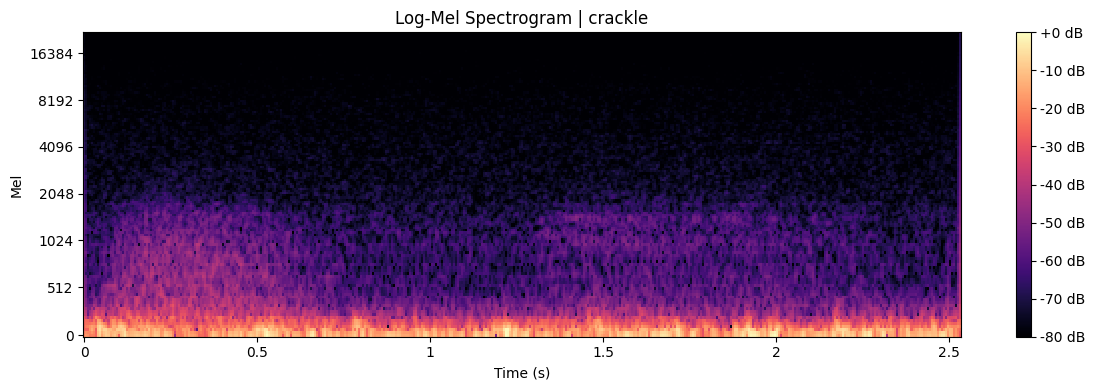


Sumber: segmented_audio_precise/wheeze/112_1p1_Ll_sc_Litt3200_s11.015_e14.557_seg3.wav
Mode  : segment_file
Kelas : wheeze
Patient ID: 112
Waktu segmen: 11.015s - 14.557s
SR    : 4000
Durasi: 3.542 detik
Max amplitude: 0.209106


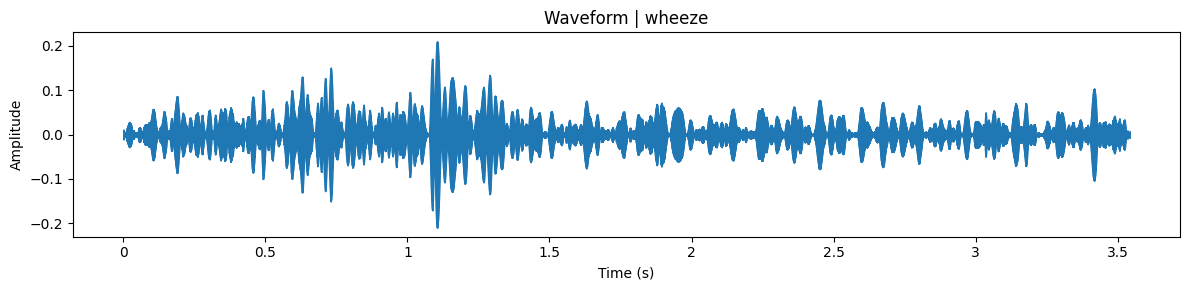

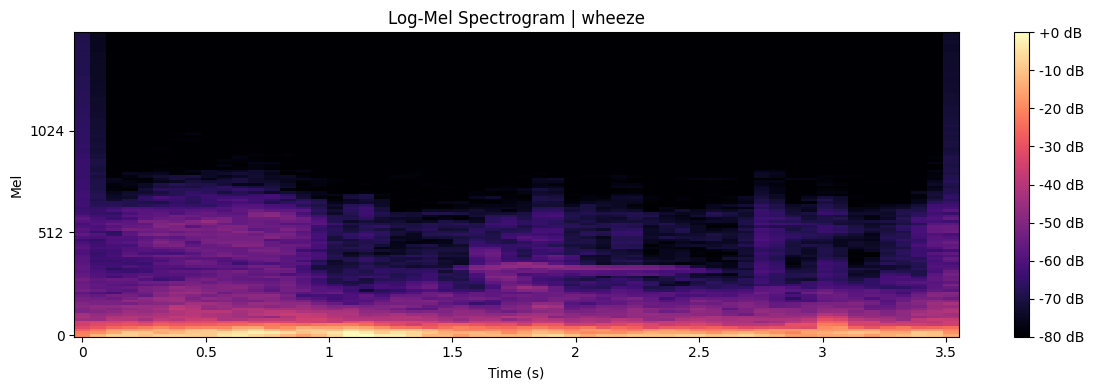


Sumber: segmented_audio_precise/both/151_3p2_Pr_mc_AKGC417L_s0.059_e3.514_seg0.wav
Mode  : segment_file
Kelas : both
Patient ID: 151
Waktu segmen: 0.059s - 3.514s
SR    : 44100
Durasi: 3.455 detik
Max amplitude: 1.000000


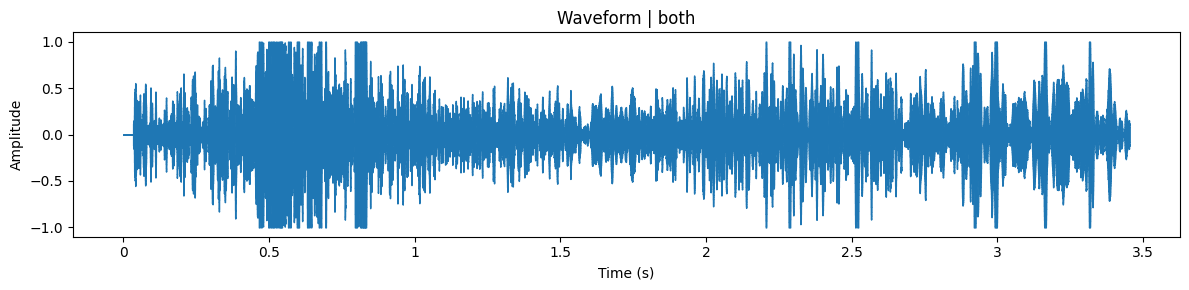

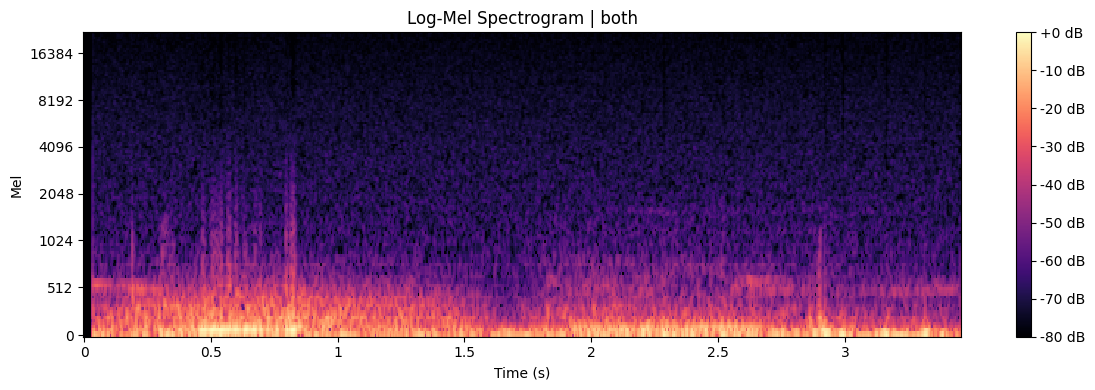

In [4]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

SEGMENTED_DIR = "segmented_audio_precise"
META_PATH = os.path.join(SEGMENTED_DIR, "metadata_segments_precise.csv")

meta = pd.read_csv(META_PATH)

classes = ["normal", "crackle", "wheeze", "both"]

def load_segment_from_row(row):
    seg_path = str(row.get("file", ""))
    if seg_path and seg_path != "nan" and os.path.exists(seg_path):
        y, sr = librosa.load(seg_path, sr=None, mono=True)
        return y, sr, seg_path, "segment_file"

    wav_source = str(row.get("wav_source", ""))
    if (not wav_source) or wav_source == "nan" or (not os.path.exists(wav_source)):
        raise FileNotFoundError(f"wav_source tidak ditemukan: {wav_source}")

    start = float(row.get("start_sec", 0.0))
    end = float(row.get("end_sec", 0.0))
    if end <= start:
        raise ValueError(f"start/end tidak valid: start={start}, end={end}")

    y_full, sr = sf.read(wav_source, always_2d=False)
    if y_full.ndim > 1:
        y_full = y_full.mean(axis=1)
    y_full = y_full.astype(np.float32, copy=False)

    start_samp = int(np.floor(start * sr))
    end_samp = int(np.ceil(end * sr))
    start_samp = max(0, min(start_samp, len(y_full)))
    end_samp = max(0, min(end_samp, len(y_full)))

    if end_samp <= start_samp:
        raise ValueError("Segment kosong setelah clamp indeks sample")

    y = y_full[start_samp:end_samp]
    return y, sr, wav_source, "sliced_from_raw"


def show_example_from_row(row, n_mels=128, n_fft=1024, hop_length=160, fmax=2000):
    label = row.get("sound", "")
    patient_id = row.get("patient_id", "")
    start = row.get("start_sec", None)
    end = row.get("end_sec", None)

    try:
        y, sr, src, mode = load_segment_from_row(row)
    except Exception as e:
        print("[ERROR] gagal load segmen:", e)
        return

    dur = len(y) / sr if sr else 0.0
    max_amp = float(np.max(np.abs(y))) if len(y) > 0 else 0.0

    print("Sumber:", src)
    print("Mode  :", mode)
    print("Kelas :", label)
    print("Patient ID:", patient_id)
    if start is not None and end is not None:
        print(f"Waktu segmen: {float(start):.3f}s - {float(end):.3f}s")
    print("SR    :", sr)
    print(f"Durasi: {dur:.3f} detik")
    print(f"Max amplitude: {max_amp:.6f}")

    # Audio preview
    if len(y) == 0 or max_amp == 0:
        print("[INFO] sinyal kosong/diam, audio tidak akan terdengar jelas.")
    display(Audio(y, rate=sr, normalize=False))

    # Waveform
    plt.figure(figsize=(12, 3))
    if len(y) > 0:
        librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform | {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # Log-Mel Spectrogram
    if len(y) > 0:
        S = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=n_mels,
            n_fft=n_fft,
            hop_length=hop_length,
            fmax=fmax
        )
        S_db = librosa.power_to_db(S + 1e-10, ref=np.max)
    else:
        S_db = np.zeros((n_mels, 1))

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis="mel"
    )
    plt.title(f"Log-Mel Spectrogram | {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Mel")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()


# Ambil 1 sampel acak per kelas, tapi hindari segmen silent kalau ada kolom is_silent
for cls in classes:
    subset = meta[meta["sound"] == cls].copy()
    if len(subset) == 0:
        print(f"\nKelas {cls} tidak ditemukan di metadata.")
        continue

    if "is_silent" in subset.columns:
        subset = subset[subset["is_silent"] == 0]
        if len(subset) == 0:
            # fallback kalau semua ditandai silent
            subset = meta[meta["sound"] == cls].copy()

    row = subset.sample(1, random_state=42).iloc[0]

    print("\n" + "="*80)
    show_example_from_row(row, n_mels=128, n_fft=1024, hop_length=256, fmax=None)

# **Splitting Data**
> **80:10:10**


In [5]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# ============================================================
# 0. Konfigurasi path
# ============================================================

SEGMENTED_DIR = "segmented_audio_precise"
META_SPLIT_DIR = "metadata_split"
os.makedirs(META_SPLIT_DIR, exist_ok=True)

META_FILE = os.path.join(SEGMENTED_DIR, "metadata_segments_precise.csv")

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both"]


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"
    elif label in ABNORMAL_CLASSES:
        return "abnormal"
    else:
        raise ValueError(f"Label tidak dikenal: {label}")


# ============================================================
# 1. Load metadata segmen hasil segmentasi presisi
# ============================================================

meta_segments = pd.read_csv(META_FILE)

print("Memuat metadata dari:", META_FILE)
print("Total segmen awal:", len(meta_segments))

# ============================================================
# 2. Validasi kolom wajib
# ============================================================

required_cols = ["patient_id", "sound", "wav_source", "start_sec", "end_sec"]
missing_cols = [c for c in required_cols if c not in meta_segments.columns]

if len(missing_cols) > 0:
    raise AssertionError(f"Kolom wajib tidak ada di metadata: {missing_cols}")

# Normalisasi kolom penting
meta_segments = meta_segments.copy()
meta_segments["sound"] = meta_segments["sound"].astype(str).str.strip().str.lower()

# Validasi label asli
unknown_source_labels = sorted(set(meta_segments["sound"]) - set(SOURCE_CLASSES))
if len(unknown_source_labels) > 0:
    raise AssertionError(f"Label sound tidak dikenal: {unknown_source_labels}")

# Buang patient_id invalid kalau ada
meta_segments["patient_id"] = meta_segments["patient_id"].astype(int)
meta_segments = meta_segments[meta_segments["patient_id"] != -1].copy()

# Simpan label asli dan buat label binary untuk model
meta_segments["original_sound"] = meta_segments["sound"]
meta_segments["binary_label"] = meta_segments["sound"].apply(to_binary_label)

print("\nDistribusi awal label asli per segmen:")
print(meta_segments["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0))

print("\nDistribusi awal binary label per segmen:")
print(meta_segments["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

n_patients = meta_segments["patient_id"].nunique()
print("\nTotal pasien unik:", n_patients)


# ============================================================
# 3. Tentukan label dominan binary per pasien
# ============================================================
patient_labels = (
    meta_segments
    .groupby("patient_id")["binary_label"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index(name="dominant_binary_label")
)

print("\nDistribusi pasien berdasarkan dominant binary label:")
print(patient_labels["dominant_binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

patients = patient_labels["patient_id"].values
labels = patient_labels["dominant_binary_label"].values


# ============================================================
# 4. Split patient-wise: 80% train, 10% val, 10% test
# ============================================================

test_size = 0.10
val_size = 0.10
random_state = 42

# Split train+val vs test
train_val_pat, test_pat = train_test_split(
    patients,
    test_size=test_size,
    stratify=labels,
    random_state=random_state,
)

# Ambil label untuk subset train+val
mask_train_val = patient_labels["patient_id"].isin(train_val_pat)
patients_train_val = patient_labels.loc[mask_train_val, "patient_id"].values
labels_train_val = patient_labels.loc[mask_train_val, "dominant_binary_label"].values

# Dari 90% train+val, ambil 10% total untuk validation
val_ratio = val_size / (1.0 - test_size)

train_pat, val_pat = train_test_split(
    patients_train_val,
    test_size=val_ratio,
    stratify=labels_train_val,
    random_state=random_state,
)


# ============================================================
# 5. Mapping kembali ke segment-level dataframe
# ============================================================

train_df = meta_segments[meta_segments["patient_id"].isin(train_pat)].copy()
val_df = meta_segments[meta_segments["patient_id"].isin(val_pat)].copy()
test_df = meta_segments[meta_segments["patient_id"].isin(test_pat)].copy()

# Cek keras: tidak boleh ada patient leakage
assert set(train_df["patient_id"]) & set(val_df["patient_id"]) == set()
assert set(train_df["patient_id"]) & set(test_df["patient_id"]) == set()
assert set(val_df["patient_id"]) & set(test_df["patient_id"]) == set()

# Cek keras: total segmen tidak boleh berubah
assert len(train_df) + len(val_df) + len(test_df) == len(meta_segments)


# ============================================================
# 6. Tampilkan distribusi setiap subset
# ============================================================

for name, df in [("TRAIN", train_df), ("VAL", val_df), ("TEST", test_df)]:
    print(f"\n[{name}]")
    print("  Pasien unik  :", df["patient_id"].nunique())
    print("  Segmen total :", len(df))

    print("\n  Distribusi label asli:")
    print(df["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0))

    print("\n  Distribusi binary label:")
    print(df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

    normal_count = int((df["binary_label"] == "normal").sum())
    abnormal_count = int((df["binary_label"] == "abnormal").sum())
    total_count = len(df)

    print("\n  Rasio binary:")
    print(f"    normal   : {normal_count} ({normal_count / total_count:.4f})")
    print(f"    abnormal : {abnormal_count} ({abnormal_count / total_count:.4f})")


# ============================================================
# 7. Simpan metadata split
# ============================================================

train_path = os.path.join(META_SPLIT_DIR, "metadata_train_precise.csv")
val_path = os.path.join(META_SPLIT_DIR, "metadata_val_precise.csv")
test_path = os.path.join(META_SPLIT_DIR, "metadata_test_precise.csv")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print("\nMetadata split patient-wise binary disimpan di:")
print(" -", train_path)
print(" -", val_path)
print(" -", test_path)

print("\nKolom penting yang sekarang tersedia:")
print(" - sound           : label asli, yaitu normal/crackle/wheeze/both")
print(" - original_sound  : salinan label asli untuk analisis")
print(" - binary_label    : label model, yaitu normal/abnormal")

Memuat metadata dari: segmented_audio_precise/metadata_segments_precise.csv
Total segmen awal: 6898

Distribusi awal label asli per segmen:
sound
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

Distribusi awal binary label per segmen:
binary_label
normal      3642
abnormal    3256
Name: count, dtype: int64

Total pasien unik: 126

Distribusi pasien berdasarkan dominant binary label:
dominant_binary_label
normal      86
abnormal    40
Name: count, dtype: int64

[TRAIN]
  Pasien unik  : 100
  Segmen total : 5134

  Distribusi label asli:
sound
normal     2820
crackle    1390
wheeze      627
both        297
Name: count, dtype: int64

  Distribusi binary label:
binary_label
normal      2820
abnormal    2314
Name: count, dtype: int64

  Rasio binary:
    normal   : 2820 (0.5493)
    abnormal : 2314 (0.4507)

[VAL]
  Pasien unik  : 13
  Segmen total : 956

  Distribusi label asli:
sound
normal     330
crackle    380
wheeze     106
both       140
Nam

# **Distribusi Data Awal**

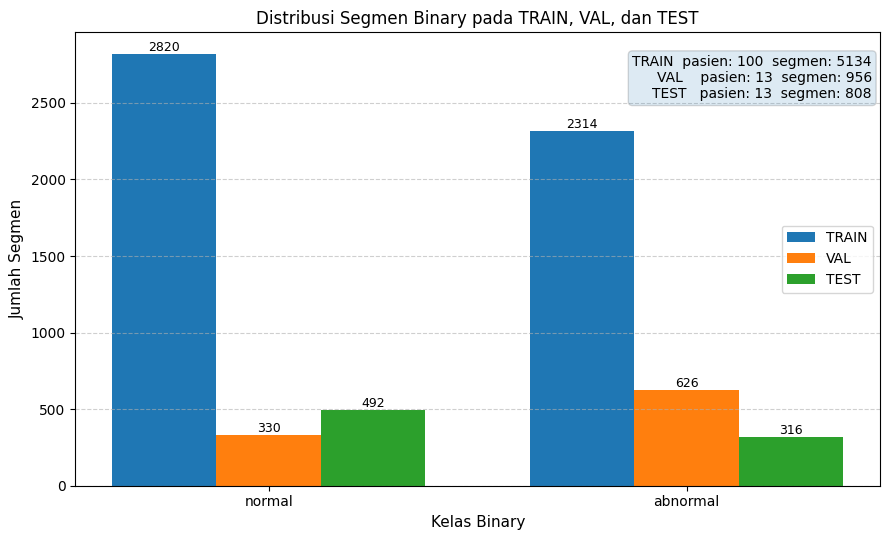


Distribusi binary label per subset:


,train,val,test,total
binary_label,,,,
normal,2820,330,492,3642
abnormal,2314,626,316,3256



Audit distribusi label asli per subset:


,train,val,test,total
sound,,,,
normal,2820,330,492,3642
crackle,1390,380,94,1864
wheeze,627,106,153,886
both,297,140,69,506



Cek patient leakage: aman
Tidak ada patient_id yang muncul di lebih dari satu subset.


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0. Konfigurasi path
# ============================================================

META_SPLIT_DIR = "metadata_split"

train_path = os.path.join(META_SPLIT_DIR, "metadata_train_precise.csv")
val_path   = os.path.join(META_SPLIT_DIR, "metadata_val_precise.csv")
test_path  = os.path.join(META_SPLIT_DIR, "metadata_test_precise.csv")

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both"]


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"
    elif label in ABNORMAL_CLASSES:
        return "abnormal"
    else:
        raise ValueError(f"Label tidak dikenal: {label}")


# ============================================================
# 1. Normalisasi metadata split
# ============================================================

def clean_split_df(df):
    df = df.copy()

    required_cols = ["patient_id", "sound"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if len(missing_cols) > 0:
        raise AssertionError(f"Kolom wajib tidak ada: {missing_cols}")

    df["sound"] = df["sound"].astype(str).str.strip().str.lower()

    unknown_labels = sorted(set(df["sound"]) - set(SOURCE_CLASSES))
    if len(unknown_labels) > 0:
        raise AssertionError(f"Label sound tidak dikenal: {unknown_labels}")

    if "original_sound" not in df.columns:
        df["original_sound"] = df["sound"]
    else:
        df["original_sound"] = df["original_sound"].astype(str).str.strip().str.lower()

    if "binary_label" not in df.columns:
        df["binary_label"] = df["sound"].apply(to_binary_label)
    else:
        df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    unknown_binary = sorted(set(df["binary_label"]) - set(BINARY_CLASSES))
    if len(unknown_binary) > 0:
        raise AssertionError(f"Label binary tidak dikenal: {unknown_binary}")

    df = df.dropna(subset=["patient_id"])
    df["patient_id"] = df["patient_id"].astype(int)
    df = df[df["patient_id"] != -1].copy()

    return df


train_df = clean_split_df(train_df)
val_df   = clean_split_df(val_df)
test_df  = clean_split_df(test_df)


# ============================================================
# 2. Hitung distribusi binary label
# ============================================================

train_counts = train_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0)
val_counts   = val_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0)
test_counts  = test_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0)

train_pat, train_seg = train_df["patient_id"].nunique(), len(train_df)
val_pat,   val_seg   = val_df["patient_id"].nunique(), len(val_df)
test_pat,  test_seg  = test_df["patient_id"].nunique(), len(test_df)


# ============================================================
# 3. Visualisasi distribusi binary label
# ============================================================

x = np.arange(len(BINARY_CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.5))

b1 = ax.bar(x - width, train_counts.values, width, label="TRAIN")
b2 = ax.bar(x,         val_counts.values,   width, label="VAL")
b3 = ax.bar(x + width, test_counts.values,  width, label="TEST")

ax.set_title("Distribusi Segmen Binary pada TRAIN, VAL, dan TEST", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(BINARY_CLASSES)
ax.set_xlabel("Kelas Binary", fontsize=11)
ax.set_ylabel("Jumlah Segmen", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend()

for bar in list(b1) + list(b2) + list(b3):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=9
    )

summary_text = (
    f"TRAIN  pasien: {train_pat}  segmen: {train_seg}\n"
    f"VAL    pasien: {val_pat}  segmen: {val_seg}\n"
    f"TEST   pasien: {test_pat}  segmen: {test_seg}"
)

ax.text(
    0.99, 0.95,
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.tight_layout()
plt.show()


# ============================================================
# 4. Tabel distribusi binary label
# ============================================================

binary_table = pd.DataFrame({
    "train": train_counts,
    "val": val_counts,
    "test": test_counts
}).astype(int)

binary_table["total"] = binary_table.sum(axis=1)

print("\nDistribusi binary label per subset:")
display(binary_table)


# ============================================================
# 5. Audit tambahan: distribusi label asli
# ============================================================
# Ini bukan target model, tetapi penting untuk laporan.
# Reviewer perlu melihat bahwa kelas abnormal berasal dari crackle, wheeze, dan both.

source_train_counts = train_df["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0)
source_val_counts   = val_df["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0)
source_test_counts  = test_df["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0)

source_table = pd.DataFrame({
    "train": source_train_counts,
    "val": source_val_counts,
    "test": source_test_counts
}).astype(int)

source_table["total"] = source_table.sum(axis=1)

print("\nAudit distribusi label asli per subset:")
display(source_table)


# ============================================================
# 6. Cek patient leakage
# ============================================================

train_patients = set(train_df["patient_id"].unique())
val_patients   = set(val_df["patient_id"].unique())
test_patients  = set(test_df["patient_id"].unique())

assert train_patients & val_patients == set(), "Patient leakage antara train dan val"
assert train_patients & test_patients == set(), "Patient leakage antara train dan test"
assert val_patients & test_patients == set(), "Patient leakage antara val dan test"

print("\nCek patient leakage: aman")
print("Tidak ada patient_id yang muncul di lebih dari satu subset.")

# **Preprocessing - Normalisasi Data Audio**

In [7]:
# ============================================================
# CELL: PREPROCESSING AUDIO PAPER-STYLE 16 kHz + FIXED 5 DETIK CHUNKING
# Target: Binary Normal-Abnormal
# ============================================================
import os
import re
import math
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf

from scipy.signal import butter, sosfiltfilt, resample_poly
from tqdm.auto import tqdm


# ============================================================
# 0. INPUT METADATA SPLIT
# ============================================================

CANDIDATE_SPLIT_DIRS = [
    Path("paper_binary_16k_outputs/02_split_metadata"),
    Path("metadata_split"),
]

SPLIT_NAMES = ["train", "val", "test"]


# ============================================================
# 1. OUTPUT FOLDER
# ============================================================

OUT_DIR = Path("paper_binary_16k_outputs/03_preprocessed_audio_16k5s")
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. PARAMETER PREPROCESSING
# ============================================================

TARGET_SR = 16000

APPLY_BANDPASS = True
LOWCUT = 50.0
HIGHCUT = 2000.0
FILTER_ORDER = 4

# memakai RMS normalization ke -15 dBFS.
TARGET_DBFS = -15.0

# Normalisasi panjang durasi
FIX_LEN_SEC = 5.0
FIX_LEN = int(TARGET_SR * FIX_LEN_SEC)

PADDING_STRATEGY = "right_zero_padding_for_short_or_last_chunk"
FIX_STRATEGY = "sequential_5s_chunking_with_right_padding"

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both"]

LABEL_TO_ID = {
    "normal": 0,
    "abnormal": 1
}

ID_TO_LABEL = {
    0: "normal",
    1: "abnormal"
}


# ============================================================
# 3. HELPER PATH DAN METADATA
# ============================================================

def find_split_metadata(split_name):
    candidates = []

    for d in CANDIDATE_SPLIT_DIRS:
        candidates.extend([
            d / f"metadata_{split_name}_binary.csv",
            d / f"metadata_{split_name}.csv",
            d / f"metadata_{split_name}_precise.csv",
        ])

    for p in candidates:
        if p.exists():
            return p

    raise FileNotFoundError(
        f"Metadata split `{split_name}` tidak ditemukan. "
        f"Jalankan cell splitting train, val, test terlebih dahulu."
    )


def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def sanitize_token(s):
    s = str(s).strip()
    s = s.replace("\\", "_").replace("/", "_").replace(" ", "_")
    s = re.sub(r"[^A-Za-z0-9_.+-]", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else "unknown"


def to_binary_label_from_sound(sound):
    sound = str(sound).strip().lower()

    if sound == "normal":
        return "normal"

    if sound in ABNORMAL_CLASSES:
        return "abnormal"

    if sound == "abnormal":
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {sound}")


def infer_sound_4class(row):
    if "sound_4class" in row.index and safe_str(row["sound_4class"]):
        return safe_str(row["sound_4class"]).lower()

    if "original_sound" in row.index and safe_str(row["original_sound"]):
        return safe_str(row["original_sound"]).lower()

    if "sound" in row.index and safe_str(row["sound"]):
        sound = safe_str(row["sound"]).lower()

        if sound in SOURCE_CLASSES:
            return sound

        if sound == "abnormal":
            return "abnormal"

    crackle = int(float(row.get("crackle", 0))) if "crackle" in row.index else 0
    wheeze = int(float(row.get("wheeze", 0))) if "wheeze" in row.index else 0

    if crackle == 1 and wheeze == 1:
        return "both"

    if crackle == 1 and wheeze == 0:
        return "crackle"

    if crackle == 0 and wheeze == 1:
        return "wheeze"

    return "normal"


def normalize_metadata(df, split_name):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "patient_id" not in df.columns:
        raise AssertionError(f"{split_name}: kolom `patient_id` tidak ditemukan.")

    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
    df = df.dropna(subset=["patient_id"]).copy()
    df["patient_id"] = df["patient_id"].astype(int)
    df = df[df["patient_id"] != -1].copy()

    if "audio_path" not in df.columns:
        if "file" in df.columns:
            df["audio_path"] = df["file"].astype(str)
        else:
            df["audio_path"] = ""

    df["audio_path"] = df["audio_path"].astype(str)

    has_audio_path = df["audio_path"].astype(str).str.len() > 0
    has_slice_info = {"wav_source", "start_sec", "end_sec"}.issubset(set(df.columns))

    if not has_audio_path.any() and not has_slice_info:
        raise AssertionError(
            f"{split_name}: metadata harus punya `audio_path/file`, "
            f"atau punya `wav_source`, `start_sec`, dan `end_sec`."
        )

    df["sound_4class"] = df.apply(infer_sound_4class, axis=1)

    if "binary_label" not in df.columns:
        df["binary_label"] = df["sound_4class"].apply(to_binary_label_from_sound)
    else:
        df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

        invalid_binary = ~df["binary_label"].isin(BINARY_CLASSES)

        if invalid_binary.any():
            df.loc[invalid_binary, "binary_label"] = (
                df.loc[invalid_binary, "sound_4class"]
                .apply(to_binary_label_from_sound)
            )

    df["label_id"] = df["binary_label"].map(LABEL_TO_ID).astype(int)
    df["split"] = split_name

    if "sample_id" not in df.columns:
        def make_sample_id(row):
            if safe_str(row.get("audio_path", "")):
                stem = Path(str(row["audio_path"])).stem
            elif safe_str(row.get("wav_source", "")):
                stem = Path(str(row["wav_source"])).stem
            else:
                stem = "unknown"

            start = float(row.get("start_sec", 0.0))
            end = float(row.get("end_sec", 0.0))

            return f"{sanitize_token(stem)}_s{start:.3f}_e{end:.3f}"

        df["sample_id"] = df.apply(make_sample_id, axis=1)

    unknown_binary = sorted(set(df["binary_label"].unique()) - set(BINARY_CLASSES))

    if len(unknown_binary) > 0:
        raise AssertionError(f"{split_name}: binary_label tidak valid: {unknown_binary}")

    return df.reset_index(drop=True)


# ============================================================
# 4. HELPER AUDIO
# ============================================================

def safe_audio_array(y):
    if y is None:
        return None

    y = np.asarray(y, dtype=np.float64)

    if y.ndim > 1:
        y = y.mean(axis=1)

    if len(y) == 0:
        return None

    y = np.nan_to_num(
        y,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if not np.all(np.isfinite(y)):
        return None

    max_abs = float(np.max(np.abs(y))) if len(y) > 0 else 0.0

    if not np.isfinite(max_abs):
        return None

    if max_abs > 10.0:
        y = y / (max_abs + 1e-12)

    return y.astype(np.float64, copy=False)


def compute_rms_dbfs(y, eps=1e-10):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return np.nan, np.nan

    rms = float(np.sqrt(np.mean(np.square(y, dtype=np.float64)) + eps))
    dbfs = float(20.0 * np.log10(rms + eps))

    return rms, dbfs


def resample_to_target(y, orig_sr, target_sr=TARGET_SR):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None

    orig_sr = int(orig_sr)
    target_sr = int(target_sr)

    if orig_sr == target_sr:
        return y.astype(np.float32, copy=False)

    gcd = math.gcd(orig_sr, target_sr)
    up = target_sr // gcd
    down = orig_sr // gcd

    try:
        y_rs = resample_poly(y, up, down)
    except Exception:
        return None

    y_rs = safe_audio_array(y_rs)

    if y_rs is None or len(y_rs) == 0:
        return None

    return y_rs.astype(np.float32, copy=False)


def bandpass_filter(y, sr, lowcut=LOWCUT, highcut=HIGHCUT, order=FILTER_ORDER):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None

    if not np.any(y):
        return y.astype(np.float32, copy=False)

    nyq = 0.5 * float(sr)

    lowcut_eff = max(float(lowcut), 1.0)
    highcut_eff = min(float(highcut), nyq * 0.95)

    if highcut_eff <= lowcut_eff:
        return y.astype(np.float32, copy=False)

    low = lowcut_eff / nyq
    high = highcut_eff / nyq

    try:
        sos = butter(
            int(order),
            [low, high],
            btype="band",
            output="sos"
        )

        y_filt = sosfiltfilt(sos, y)

    except Exception:
        y_filt = y

    y_filt = np.nan_to_num(
        y_filt,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if not np.all(np.isfinite(y_filt)):
        return None

    return y_filt.astype(np.float32, copy=False)


def normalize_to_dbfs(y, target_dbfs=TARGET_DBFS, eps=1e-10):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None

    rms = float(np.sqrt(np.mean(np.square(y, dtype=np.float64)) + eps))

    if not np.isfinite(rms) or rms <= eps:
        return y.astype(np.float32, copy=False)

    target_rms = 10.0 ** (float(target_dbfs) / 20.0)
    gain = target_rms / rms

    y_norm = y * gain

    y_norm = np.nan_to_num(
        y_norm,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    y_norm = np.clip(y_norm, -1.0, 1.0)

    return y_norm.astype(np.float32, copy=False)


def split_into_5s_chunks(y, target_len=FIX_LEN):
    """
    Membagi audio menjadi chunk fixed 5 detik.

    Tidak ada sisa audio yang dibuang.
    Sisa chunk terakhir diberi right zero padding.
    """
    if y is None or len(y) == 0:
        return []

    y = y.astype(np.float32, copy=False)

    total_len = int(len(y))
    n_chunks = int(np.ceil(total_len / target_len))

    chunk_items = []

    for chunk_idx in range(n_chunks):
        start = chunk_idx * target_len
        end = min(start + target_len, total_len)

        chunk = y[start:end].astype(np.float32, copy=False)
        active_len = int(len(chunk))

        padding_len = 0
        padding_duration = 0.0
        padding_ratio = 0.0

        if active_len < target_len:
            padding_len = target_len - active_len

            chunk = np.pad(
                chunk,
                (0, padding_len),
                mode="constant",
                constant_values=0.0
            ).astype(np.float32, copy=False)

            padding_duration = float(padding_len / TARGET_SR)
            padding_ratio = float(padding_len / target_len)

        if len(chunk) != target_len:
            raise RuntimeError(f"Chunk length invalid: {len(chunk)} != {target_len}")

        fix_info = {
            "target_sec": float(FIX_LEN_SEC),
            "target_len_samples": int(target_len),

            "chunk_idx": int(chunk_idx),
            "n_chunks_from_segment": int(n_chunks),

            "chunk_start_sample_before_fix": int(start),
            "chunk_end_sample_before_fix": int(end),
            "chunk_start_sec_before_fix": float(start / TARGET_SR),
            "chunk_end_sec_before_fix": float(end / TARGET_SR),

            "original_segment_len_samples": int(total_len),
            "original_segment_duration_sec": float(total_len / TARGET_SR),

            "active_len_samples_before_fix": int(active_len),
            "active_duration_sec_before_fix": float(active_len / TARGET_SR),

            "padding_len_samples": int(padding_len),
            "padding_duration_sec": float(padding_duration),
            "padding_ratio": float(padding_ratio),

            "crop_len_samples": 0,
            "crop_duration_sec": 0.0,
            "crop_start_sample": 0,
            "crop_end_sample": 0,

            "fix_strategy": FIX_STRATEGY,
            "padding_strategy": PADDING_STRATEGY,
            "crop_strategy": "none",
            "truncate_strategy": "none",

            "kept_start_sample": int(start),
            "kept_end_sample": int(end),
        }

        chunk_items.append((chunk, fix_info))

    return chunk_items


def preprocess_audio(y, sr):
    """
    Urutan preprocessing:
    1. Resample ke 16 kHz
    2. Bandpass 50 sampai 1500 Hz
    3. Normalisasi RMS ke -15 dBFS pada sinyal aktif
    4. Split menjadi chunk 5 detik
       Sisa chunk terakhir tetap dipakai dengan right zero padding
    """
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return []

    input_rms, input_dbfs = compute_rms_dbfs(y)

    y = resample_to_target(y, sr, TARGET_SR)

    if y is None or len(y) == 0:
        return []

    resampled_rms, resampled_dbfs = compute_rms_dbfs(y)

    if APPLY_BANDPASS:
        y = bandpass_filter(
            y,
            TARGET_SR,
            lowcut=LOWCUT,
            highcut=HIGHCUT,
            order=FILTER_ORDER
        )

        if y is None or len(y) == 0:
            return []

    filtered_rms, filtered_dbfs = compute_rms_dbfs(y)

    y = normalize_to_dbfs(y, target_dbfs=TARGET_DBFS)

    if y is None or len(y) == 0:
        return []

    active_rms_after_norm, active_dbfs_after_norm = compute_rms_dbfs(y)
    active_peak_after_norm = float(np.max(np.abs(y))) if len(y) > 0 else np.nan

    chunk_items = split_into_5s_chunks(
        y,
        target_len=FIX_LEN
    )

    processed_items = []

    for y_fixed, fix_info in chunk_items:
        if y_fixed is None or fix_info is None:
            continue

        if len(y_fixed) != FIX_LEN:
            continue

        if not np.all(np.isfinite(y_fixed)):
            continue

        processed_rms_after_fix, processed_dbfs_after_fix = compute_rms_dbfs(y_fixed)
        processed_peak_after_fix = float(np.max(np.abs(y_fixed))) if len(y_fixed) > 0 else np.nan

        norm_info = {
            "input_rms": input_rms,
            "input_dbfs": input_dbfs,

            "resampled_rms": resampled_rms,
            "resampled_dbfs": resampled_dbfs,

            "filtered_rms": filtered_rms,
            "filtered_dbfs": filtered_dbfs,

            "active_rms_after_norm": active_rms_after_norm,
            "active_dbfs_after_norm": active_dbfs_after_norm,
            "active_peak_after_norm": active_peak_after_norm,

            "processed_rms_after_fix": processed_rms_after_fix,
            "processed_dbfs_after_fix": processed_dbfs_after_fix,
            "processed_peak_after_fix": processed_peak_after_fix,
        }

        processed_items.append(
            (
                y_fixed.astype(np.float32, copy=False),
                TARGET_SR,
                fix_info,
                norm_info
            )
        )

    return processed_items


def read_audio_from_row(row):
    audio_path = safe_str(row.get("audio_path", ""))

    if audio_path and Path(audio_path).exists():
        try:
            y, sr = sf.read(
                audio_path,
                always_2d=False,
                dtype="float64"
            )

            y = safe_audio_array(y)

            if y is None or len(y) == 0:
                return None, None, None

            info = {
                "input_mode": "segmented_audio_path",
                "input_audio_path": audio_path,
                "original_sr": int(sr),
                "original_len_samples": int(len(y)),
                "original_duration_sec": float(len(y) / sr),
            }

            return y, int(sr), info

        except Exception:
            return None, None, None

    wav_source = safe_str(row.get("wav_source", ""))

    if not wav_source or not Path(wav_source).exists():
        return None, None, None

    if "start_sec" not in row.index or "end_sec" not in row.index:
        return None, None, None

    try:
        file_info = sf.info(wav_source)
        sr = int(file_info.samplerate)
        total_frames = int(file_info.frames)

        start_sec = float(row["start_sec"])
        end_sec = float(row["end_sec"])

        start_samp = int(np.floor(start_sec * sr))
        end_samp = int(np.ceil(end_sec * sr))

        start_samp = max(0, min(start_samp, total_frames))
        end_samp = max(0, min(end_samp, total_frames))

        if end_samp <= start_samp:
            return None, None, None

        frames_to_read = end_samp - start_samp

        y, sr_read = sf.read(
            wav_source,
            start=start_samp,
            frames=frames_to_read,
            always_2d=False,
            dtype="float64"
        )

        y = safe_audio_array(y)

        if y is None or len(y) == 0:
            return None, None, None

        info = {
            "input_mode": "slice_from_wav_source",
            "input_audio_path": wav_source,
            "original_sr": int(sr_read),
            "original_len_samples": int(len(y)),
            "original_duration_sec": float(len(y) / sr_read),
            "source_total_samples": int(total_frames),
            "source_total_duration_sec": float(total_frames / sr),
        }

        return y, int(sr_read), info

    except Exception:
        return None, None, None


def make_short_id(sample_id, row_idx):
    raw = f"{sample_id}_{row_idx}"
    return hashlib.md5(raw.encode("utf-8")).hexdigest()[:16]


# ============================================================
# 5. RUNNER PREPROCESSING PER SPLIT
# ============================================================

def run_preprocess_split(split_name):
    meta_path = find_split_metadata(split_name)

    raw_df = pd.read_csv(meta_path)
    df = normalize_metadata(raw_df, split_name)

    out_split_dir = OUT_DIR / split_name
    out_split_dir.mkdir(parents=True, exist_ok=True)

    out_rows = []

    skipped = 0
    skipped_read = 0
    skipped_preprocess = 0
    skipped_write = 0

    print("\n" + "=" * 80)
    print(f"PREPROCESSING SPLIT: {split_name.upper()}")
    print("=" * 80)
    print("Input metadata :", meta_path)
    print("Output folder  :", out_split_dir)
    print("Jumlah metadata:", len(df))
    print("Target SR      :", TARGET_SR)
    print("Bandpass       :", f"{LOWCUT} sampai {HIGHCUT} Hz")
    print("Target dBFS    :", TARGET_DBFS)
    print("Fixed length   :", f"{FIX_LEN_SEC} detik = {FIX_LEN} samples")
    print("Fix strategy   :", FIX_STRATEGY)

    print("\nDistribusi binary label sebelum preprocessing:")
    print(df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

    print("\nDistribusi 4 kelas untuk audit:")
    print(df["sound_4class"].value_counts(dropna=False))

    for idx, row in tqdm(df.iterrows(), total=len(df), ncols=100):
        y, sr, input_info = read_audio_from_row(row)

        if y is None or sr is None or input_info is None:
            skipped += 1
            skipped_read += 1
            continue

        sample_id = safe_str(row.get("sample_id", ""))

        if not sample_id:
            sample_id = f"{Path(input_info['input_audio_path']).stem}_{idx}"

        sample_id_clean = sanitize_token(sample_id)

        processed_items = preprocess_audio(y, sr)

        if len(processed_items) == 0:
            skipped += 1
            skipped_preprocess += 1
            continue

        binary_label = safe_str(row["binary_label"]).lower()
        sound_4class = safe_str(row["sound_4class"]).lower()
        patient_id = int(row["patient_id"])
        label_id = int(row["label_id"])

        short_id = make_short_id(sample_id_clean, idx)

        for y_out, sr_out, fix_info, norm_info in processed_items:
            if len(y_out) != FIX_LEN or not np.all(np.isfinite(y_out)):
                skipped += 1
                skipped_preprocess += 1
                continue

            chunk_idx = int(fix_info["chunk_idx"])
            n_chunks = int(fix_info["n_chunks_from_segment"])

            out_name = (
                f"{short_id}"
                f"_chunk{chunk_idx:03d}of{n_chunks:03d}"
                f"_pid{patient_id}"
                f"_bin{binary_label}"
                f"_orig{sound_4class}"
                f"_16k5s.wav"
            )

            out_name = sanitize_token(out_name.replace(".wav", "")) + ".wav"
            out_path = out_split_dir / out_name

            try:
                sf.write(
                    str(out_path),
                    y_out,
                    sr_out,
                    subtype="PCM_16"
                )
            except Exception:
                skipped += 1
                skipped_write += 1
                continue

            out_row = {
                "sample_id": f"{sample_id_clean}_chunk{chunk_idx:03d}",
                "parent_sample_id": sample_id_clean,

                "file": str(out_path),
                "audio_path": str(out_path),

                "split": split_name,
                "patient_id": patient_id,

                "binary_label": binary_label,
                "label_id": label_id,
                "sound_4class": sound_4class,

                "is_augmented": int(row.get("is_augmented", 0)) if "is_augmented" in row.index else 0,
                "aug_type": safe_str(row.get("aug_type", "none")) if "aug_type" in row.index else "none",
                "source": "preprocessed_original_16k5s",

                "target_sr": int(sr_out),
                "target_sec": float(FIX_LEN_SEC),
                "target_len_samples": int(FIX_LEN),

                "target_dbfs": float(TARGET_DBFS),
                "apply_bandpass": bool(APPLY_BANDPASS),
                "lowcut": float(LOWCUT),
                "highcut": float(HIGHCUT),
                "filter_order": int(FILTER_ORDER),

                "processed_len_samples": int(len(y_out)),
                "processed_duration_sec": float(len(y_out) / sr_out),

                "fix_strategy": fix_info["fix_strategy"],
                "padding_strategy": fix_info["padding_strategy"],
                "crop_strategy": fix_info["crop_strategy"],
                "truncate_strategy": fix_info["truncate_strategy"],

                "chunk_idx": chunk_idx,
                "n_chunks_from_segment": n_chunks,

                "chunk_start_sample_before_fix": fix_info["chunk_start_sample_before_fix"],
                "chunk_end_sample_before_fix": fix_info["chunk_end_sample_before_fix"],
                "chunk_start_sec_before_fix": fix_info["chunk_start_sec_before_fix"],
                "chunk_end_sec_before_fix": fix_info["chunk_end_sec_before_fix"],

                "original_segment_len_samples": fix_info["original_segment_len_samples"],
                "original_segment_duration_sec": fix_info["original_segment_duration_sec"],

                "active_len_samples_before_fix": fix_info["active_len_samples_before_fix"],
                "active_duration_sec_before_fix": fix_info["active_duration_sec_before_fix"],

                "padding_len_samples": fix_info["padding_len_samples"],
                "padding_duration_sec": fix_info["padding_duration_sec"],
                "padding_ratio": fix_info["padding_ratio"],

                "crop_len_samples": fix_info["crop_len_samples"],
                "crop_duration_sec": fix_info["crop_duration_sec"],
                "crop_start_sample": fix_info["crop_start_sample"],
                "crop_end_sample": fix_info["crop_end_sample"],

                "kept_start_sample": fix_info["kept_start_sample"],
                "kept_end_sample": fix_info["kept_end_sample"],

                "wav_source": safe_str(row.get("wav_source", "")),
                "txt_source": safe_str(row.get("txt_source", "")),
                "start_sec": float(row.get("start_sec", np.nan)) if "start_sec" in row.index else np.nan,
                "end_sec": float(row.get("end_sec", np.nan)) if "end_sec" in row.index else np.nan,
                "crackle": int(float(row.get("crackle", 0))) if "crackle" in row.index else 0,
                "wheeze": int(float(row.get("wheeze", 0))) if "wheeze" in row.index else 0,
            }

            for k, v in input_info.items():
                out_row[k] = v

            for k, v in norm_info.items():
                out_row[k] = v

            passthrough_cols = [
                "disease",
                "recording_stem",
                "segment_idx",
                "segment_key",
                "duration_sec",
                "max_amp",
                "is_silent"
            ]

            for c in passthrough_cols:
                if c in row.index and c not in out_row:
                    out_row[c] = row[c]

            out_rows.append(out_row)

    out_df = pd.DataFrame(out_rows)

    if len(out_df) == 0:
        raise RuntimeError(f"{split_name}: tidak ada audio yang berhasil diproses.")

    out_csv = OUT_DIR / f"metadata_{split_name}_16k5s.csv"
    out_df.to_csv(out_csv, index=False)

    print("\nSelesai:", split_name.upper())
    print("Tersimpan          :", len(out_df))
    print("Skip total         :", skipped)
    print("Skip read          :", skipped_read)
    print("Skip preprocessing :", skipped_preprocess)
    print("Skip write         :", skipped_write)

    print("\nDistribusi binary label output:")
    print(out_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

    print("\nDistribusi target_sr:")
    print(out_df["target_sr"].value_counts(dropna=False).sort_index())

    print("\nDistribusi panjang hasil preprocessing:")
    print(out_df["processed_duration_sec"].value_counts(dropna=False).sort_index().head(10))

    print("\nDistribusi fix_strategy:")
    print(out_df["fix_strategy"].value_counts(dropna=False))

    print("\nDistribusi jumlah chunk per parent segment:")
    print(out_df.groupby("parent_sample_id")["chunk_idx"].count().describe())

    print("\nPadding ratio per binary label:")
    print(out_df.groupby("binary_label")["padding_ratio"].describe())

    print("\nActive dBFS setelah normalisasi, sebelum chunking/padding:")
    print(out_df["active_dbfs_after_norm"].describe())

    print("\nProcessed dBFS setelah fixed 5 detik:")
    print(out_df["processed_dbfs_after_fix"].describe())

    print("\nMetadata output:")
    print(out_csv)

    return out_df


# ============================================================
# 6. EKSEKUSI PREPROCESSING
# ============================================================

train_out = run_preprocess_split("train")
val_out   = run_preprocess_split("val")
test_out  = run_preprocess_split("test")


# ============================================================
# 7. VALIDASI ANTI-LEAKAGE PATIENT
# ============================================================

train_patients = set(train_out["patient_id"].unique())
val_patients = set(val_out["patient_id"].unique())
test_patients = set(test_out["patient_id"].unique())

assert train_patients.isdisjoint(val_patients), "Leakage patient antara train dan val."
assert train_patients.isdisjoint(test_patients), "Leakage patient antara train dan test."
assert val_patients.isdisjoint(test_patients), "Leakage patient antara val dan test."


# ============================================================
# 8. VALIDASI OUTPUT FIXED LENGTH
# ============================================================

for split_name, df in [
    ("train", train_out),
    ("val", val_out),
    ("test", test_out)
]:
    assert (df["target_sr"] == TARGET_SR).all(), f"{split_name}: ada target_sr bukan {TARGET_SR}"
    assert (df["processed_len_samples"] == FIX_LEN).all(), f"{split_name}: ada panjang audio bukan {FIX_LEN}"
    assert np.allclose(df["processed_duration_sec"], FIX_LEN_SEC), f"{split_name}: durasi bukan {FIX_LEN_SEC} detik"
    assert (df["crop_strategy"] == "none").all(), f"{split_name}: masih ada crop, padahal harus chunking"
    assert (df["truncate_strategy"] == "none").all(), f"{split_name}: masih ada truncate, padahal harus chunking"


# ============================================================
# 9. RINGKASAN AKHIR
# ============================================================

summary_rows = []

for split_name, df in [
    ("train", train_out),
    ("val", val_out),
    ("test", test_out)
]:
    parent_count = df["parent_sample_id"].nunique() if "parent_sample_id" in df.columns else len(df)

    row = {
        "split": split_name,

        "n_segments_original_after_split": int(parent_count),
        "n_chunks_output": int(len(df)),
        "n_segments": int(len(df)),
        "n_patients": int(df["patient_id"].nunique()),

        "normal": int((df["binary_label"] == "normal").sum()),
        "abnormal": int((df["binary_label"] == "abnormal").sum()),

        "source_normal": int((df["sound_4class"] == "normal").sum()),
        "source_crackle": int((df["sound_4class"] == "crackle").sum()),
        "source_wheeze": int((df["sound_4class"] == "wheeze").sum()),
        "source_both": int((df["sound_4class"] == "both").sum()),
        "source_abnormal_unspecified": int((df["sound_4class"] == "abnormal").sum()),

        "target_sr": int(TARGET_SR),
        "target_sec": float(FIX_LEN_SEC),
        "target_len_samples": int(FIX_LEN),

        "target_dbfs": float(TARGET_DBFS),
        "apply_bandpass": bool(APPLY_BANDPASS),
        "lowcut": float(LOWCUT),
        "highcut": float(HIGHCUT),
        "filter_order": int(FILTER_ORDER),

        "fix_strategy": FIX_STRATEGY,

        "mean_original_segment_duration_sec": float(df["original_segment_duration_sec"].mean()),
        "median_original_segment_duration_sec": float(df["original_segment_duration_sec"].median()),
        "min_original_segment_duration_sec": float(df["original_segment_duration_sec"].min()),
        "max_original_segment_duration_sec": float(df["original_segment_duration_sec"].max()),

        "mean_active_duration_before_fix": float(df["active_duration_sec_before_fix"].mean()),
        "median_active_duration_before_fix": float(df["active_duration_sec_before_fix"].median()),
        "min_active_duration_before_fix": float(df["active_duration_sec_before_fix"].min()),
        "max_active_duration_before_fix": float(df["active_duration_sec_before_fix"].max()),

        "mean_chunks_per_segment": float(df.groupby("parent_sample_id")["chunk_idx"].count().mean()),
        "max_chunks_per_segment": int(df.groupby("parent_sample_id")["chunk_idx"].count().max()),

        "mean_padding_ratio": float(df["padding_ratio"].mean()),
        "median_padding_ratio": float(df["padding_ratio"].median()),
        "max_padding_ratio": float(df["padding_ratio"].max()),

        "mean_active_dbfs_after_norm": float(df["active_dbfs_after_norm"].mean()),
        "median_active_dbfs_after_norm": float(df["active_dbfs_after_norm"].median()),

        "mean_processed_dbfs_after_fix": float(df["processed_dbfs_after_fix"].mean()),
        "median_processed_dbfs_after_fix": float(df["processed_dbfs_after_fix"].median()),
    }

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_path = OUT_DIR / "summary_preprocessed_16k5s.csv"
summary_df.to_csv(summary_path, index=False)

print("\n" + "=" * 80)
print("RINGKASAN AKHIR PREPROCESSING 16 kHz + FIXED 5 DETIK CHUNKING")
print("=" * 80)

try:
    display(summary_df)
except NameError:
    print(summary_df)

print("\nSummary disimpan di:")
print(summary_path)

print("\nFile metadata output:")
print("Train:", OUT_DIR / "metadata_train_16k5s.csv")
print("Val  :", OUT_DIR / "metadata_val_16k5s.csv")
print("Test :", OUT_DIR / "metadata_test_16k5s.csv")

print("\n[OK] Preprocessing audio 16 kHz + fixed 5 detik chunking selesai.")


# ============================================================
# 10. SIMPAN KE GLOBALS
# ============================================================

globals()["PREPROC_DIR"] = str(OUT_DIR)
globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DBFS"] = TARGET_DBFS
globals()["TARGET_DURATION_SEC"] = FIX_LEN_SEC
globals()["TARGET_LEN"] = FIX_LEN
globals()["BANDPASS_LOW_HZ"] = LOWCUT
globals()["BANDPASS_HIGH_HZ"] = HIGHCUT

globals()["train_out"] = train_out
globals()["val_out"] = val_out
globals()["test_out"] = test_out
globals()["summary_preprocessed_16k5s"] = summary_df


PREPROCESSING SPLIT: TRAIN
Input metadata : metadata_split/metadata_train_precise.csv
Output folder  : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/train
Jumlah metadata: 5134
Target SR      : 16000
Bandpass       : 50.0 sampai 2000.0 Hz
Target dBFS    : -15.0
Fixed length   : 5.0 detik = 80000 samples
Fix strategy   : sequential_5s_chunking_with_right_padding

Distribusi binary label sebelum preprocessing:
binary_label
normal      2820
abnormal    2314
Name: count, dtype: int64

Distribusi 4 kelas untuk audit:
sound_4class
normal     2820
crackle    1390
wheeze      627
both        297
Name: count, dtype: int64


  0%|                                                                      | 0/5134 [00:00<?, ?it/s]


Selesai: TRAIN
Tersimpan          : 5325
Skip total         : 0
Skip read          : 0
Skip preprocessing : 0
Skip write         : 0

Distribusi binary label output:
binary_label
normal      2954
abnormal    2371
Name: count, dtype: int64

Distribusi target_sr:
target_sr
16000    5325
Name: count, dtype: int64

Distribusi panjang hasil preprocessing:
processed_duration_sec
5.0    5325
Name: count, dtype: int64

Distribusi fix_strategy:
fix_strategy
sequential_5s_chunking_with_right_padding    5325
Name: count, dtype: int64

Distribusi jumlah chunk per parent segment:
count    5134.000000
mean        1.037203
std         0.193351
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: chunk_idx, dtype: float64

Padding ratio per binary label:
               count      mean       std  min       25%       50%       75%  \
binary_label                                                                  
abnormal      2371.0  0.441279  0.

  0%|                                                                       | 0/956 [00:00<?, ?it/s]


Selesai: VAL
Tersimpan          : 981
Skip total         : 0
Skip read          : 0
Skip preprocessing : 0
Skip write         : 0

Distribusi binary label output:
binary_label
normal      346
abnormal    635
Name: count, dtype: int64

Distribusi target_sr:
target_sr
16000    981
Name: count, dtype: int64

Distribusi panjang hasil preprocessing:
processed_duration_sec
5.0    981
Name: count, dtype: int64

Distribusi fix_strategy:
fix_strategy
sequential_5s_chunking_with_right_padding    981
Name: count, dtype: int64

Distribusi jumlah chunk per parent segment:
count    956.000000
mean       1.026151
std        0.159667
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: chunk_idx, dtype: float64

Padding ratio per binary label:
              count      mean       std  min       25%       50%       75%  \
binary_label                                                                 
abnormal      635.0  0.487624  0.140366  0.0  0.4157

  0%|                                                                       | 0/808 [00:00<?, ?it/s]


Selesai: TEST
Tersimpan          : 829
Skip total         : 0
Skip read          : 0
Skip preprocessing : 0
Skip write         : 0

Distribusi binary label output:
binary_label
normal      504
abnormal    325
Name: count, dtype: int64

Distribusi target_sr:
target_sr
16000    829
Name: count, dtype: int64

Distribusi panjang hasil preprocessing:
processed_duration_sec
5.0    829
Name: count, dtype: int64

Distribusi fix_strategy:
fix_strategy
sequential_5s_chunking_with_right_padding    829
Name: count, dtype: int64

Distribusi jumlah chunk per parent segment:
count    808.000000
mean       1.025990
std        0.159204
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: chunk_idx, dtype: float64

Padding ratio per binary label:
              count      mean       std  min       25%       50%       75%  \
binary_label                                                                 
abnormal      325.0  0.456447  0.232713  0.0  0.305

,split,n_segments_original_after_split,n_chunks_output,n_segments,n_patients,normal,abnormal,source_normal,source_crackle,source_wheeze,...,max_active_duration_before_fix,mean_chunks_per_segment,max_chunks_per_segment,mean_padding_ratio,median_padding_ratio,max_padding_ratio,mean_active_dbfs_after_norm,median_active_dbfs_after_norm,mean_processed_dbfs_after_fix,median_processed_dbfs_after_fix
0,train,5134,5325,5325,100,2954,2371,2954,1414,640,...,5.0,1.037203,4,0.467956,0.489187,0.999988,-15.224142,-15.032657,-18.537977,-18.076913
1,val,956,981,981,13,346,635,346,380,113,...,5.0,1.026151,2,0.504925,0.525787,0.990800,-15.188298,-15.014149,-18.614180,-18.310447
2,test,808,829,829,13,504,325,504,94,156,...,5.0,1.025990,2,0.509160,0.523787,0.997188,-15.223386,-15.019494,-18.978039,-18.446575



Summary disimpan di:
paper_binary_16k_outputs/03_preprocessed_audio_16k5s/summary_preprocessed_16k5s.csv

File metadata output:
Train: paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_train_16k5s.csv
Val  : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_val_16k5s.csv
Test : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_test_16k5s.csv

[OK] Preprocessing audio 16 kHz + fixed 5 detik chunking selesai.


# **Distribusi data 5 detik**

CEK DISTRIBUSI DATA PREPROCESSING 16k5s
PREPROC_DIR       : paper_binary_16k_outputs/03_preprocessed_audio_16k5s
Target SR         : 16000
Target durasi     : 5.0
Target sample     : 80000
Total data chunk  : 7135

Ringkasan data per split:


,split,n_chunks_output,n_parent_segments,n_patients,normal,abnormal,source_normal,source_crackle,source_wheeze,source_both,source_abnormal_unspecified,target_sr,target_duration_sec,target_len_samples,mean_padding_ratio,median_padding_ratio,max_padding_ratio,mean_chunks_from_segment,max_chunks_from_segment
0,train,5325,5134,100,2954,2371,2954,1414,640,317,0,16000,5.0,80000,0.467956,0.489187,0.999988,1.073239,4
1,val,981,956,13,346,635,346,380,113,142,0,16000,5.0,80000,0.504925,0.525787,0.990800,1.050968,2
2,test,829,808,13,504,325,504,94,156,75,0,16000,5.0,80000,0.509160,0.523787,0.997188,1.050663,2


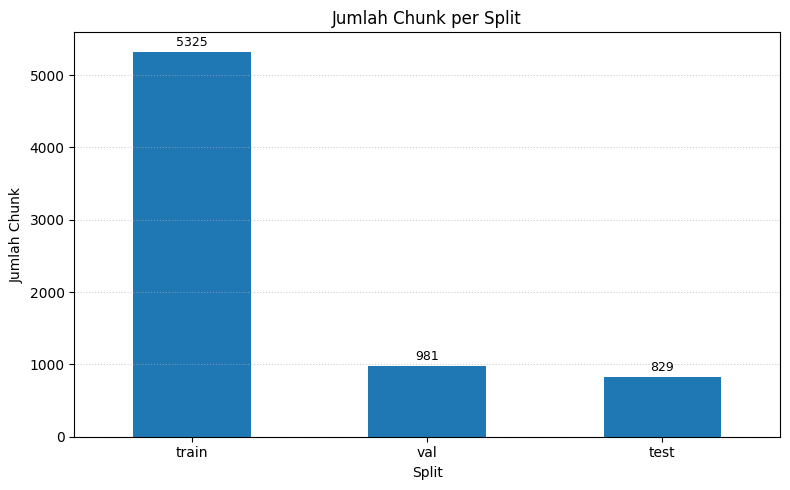


Tabel distribusi binary label:


binary_label,normal,abnormal
split,,
train,2954,2371
val,346,635
test,504,325


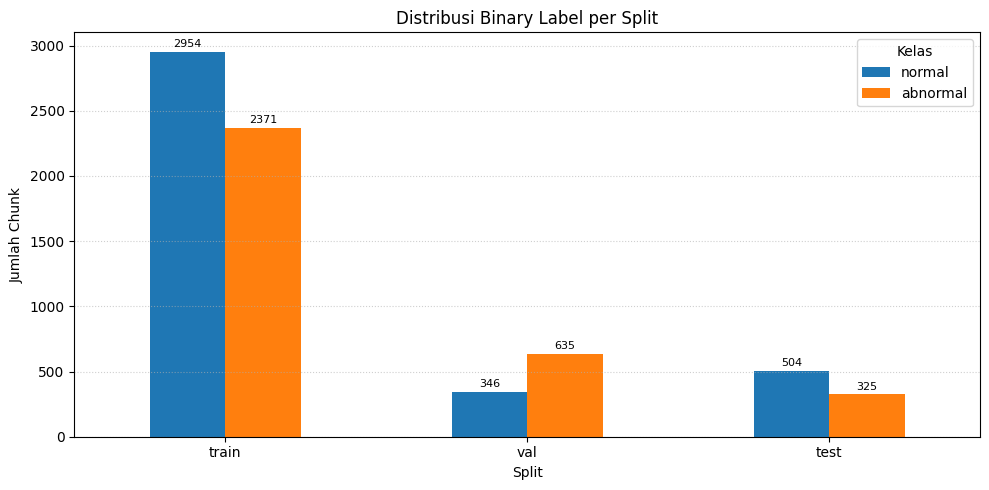


Tabel distribusi label sumber:


sound_4class,normal,crackle,wheeze,both
split,,,,
train,2954,1414,640,317
val,346,380,113,142
test,504,94,156,75


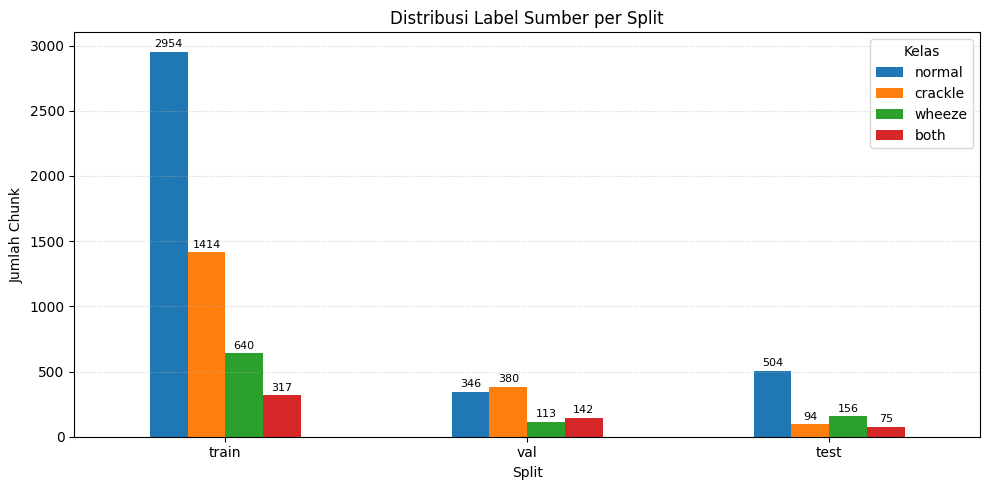


Tabel parent segment vs chunk output:


,parent_segment,chunk_output
split,,
train,5134,5325
val,956,981
test,808,829


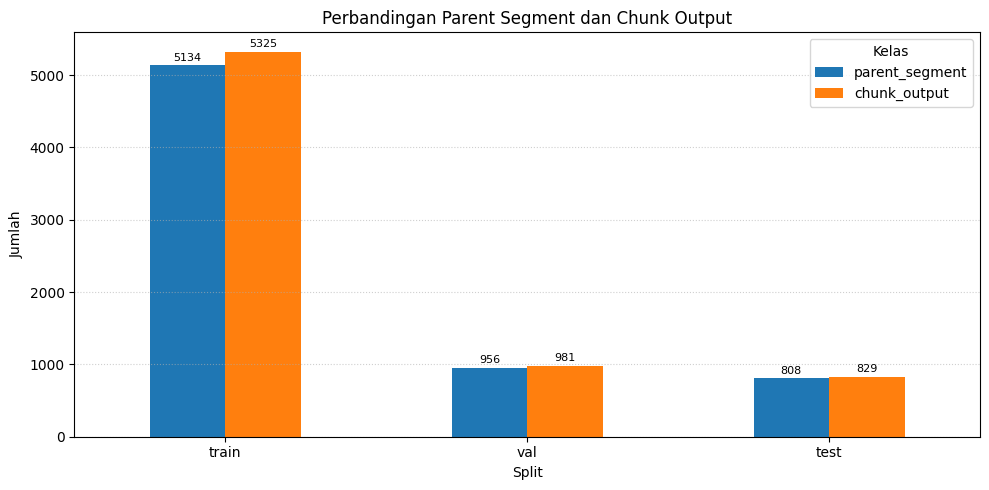


File ringkasan tersimpan:
Summary distribusi : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/summary_distribution_16k5s.csv
Binary label       : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/distribution_binary_label_16k5s.csv
Source label       : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/distribution_source_label_16k5s.csv

[OK] Cell distribusi ringkas selesai.


In [8]:
# ============================================================
# CELL 15: CEK DISTRIBUSI DATA PREPROCESSING 16k5s
# ============================================================
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. KONFIGURASI
# ============================================================

PREPROC_DIR = globals().get(
    "PREPROC_DIR",
    "paper_binary_16k_outputs/03_preprocessed_audio_16k5s"
)

PREPROC_DIR = Path(PREPROC_DIR)

SPLITS = ["train", "val", "test"]

BINARY_CLASSES = ["normal", "abnormal"]
SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]

TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_DURATION_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN = int(globals().get("TARGET_LEN", TARGET_SR * TARGET_DURATION_SEC))


# ============================================================
# 1. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def load_metadata_split(split_name):
    meta_path = PREPROC_DIR / f"metadata_{split_name}_16k5s.csv"

    if not meta_path.exists():
        raise FileNotFoundError(f"Metadata tidak ditemukan: {meta_path}")

    df = pd.read_csv(meta_path)
    df.columns = [str(c).strip() for c in df.columns]

    if "file" not in df.columns and "audio_path" in df.columns:
        df["file"] = df["audio_path"]

    if "binary_label" not in df.columns:
        if "label_id" in df.columns:
            df["binary_label"] = df["label_id"].map({0: "normal", 1: "abnormal"})
        else:
            raise ValueError(f"{split_name}: kolom binary_label tidak ditemukan.")

    if "sound_4class" not in df.columns:
        if "sound" in df.columns:
            df["sound_4class"] = df["sound"]
        elif "original_sound" in df.columns:
            df["sound_4class"] = df["original_sound"]
        else:
            df["sound_4class"] = df["binary_label"]

    df["split"] = split_name
    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()
    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    return df


def make_count_table(df_all, label_col, class_order):
    table = (
        df_all
        .groupby(["split", label_col])
        .size()
        .unstack(fill_value=0)
        .reindex(index=SPLITS, fill_value=0)
    )

    for cls in class_order:
        if cls not in table.columns:
            table[cls] = 0

    table = table[class_order]

    return table


def plot_bar_table(table, title, ylabel="Jumlah"):
    ax = table.plot(
        kind="bar",
        figsize=(10, 5),
        rot=0
    )

    ax.set_title(title)
    ax.set_xlabel("Split")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle=":", alpha=0.6)
    ax.legend(title="Kelas")

    for container in ax.containers:
        ax.bar_label(container, fontsize=8, padding=2)

    plt.tight_layout()
    plt.show()


# ============================================================
# 2. LOAD SEMUA METADATA
# ============================================================

dfs = []

for split_name in SPLITS:
    df_split = load_metadata_split(split_name)
    dfs.append(df_split)

df_all = pd.concat(dfs, ignore_index=True)

print("=" * 80)
print("CEK DISTRIBUSI DATA PREPROCESSING 16k5s")
print("=" * 80)
print("PREPROC_DIR       :", PREPROC_DIR)
print("Target SR         :", TARGET_SR)
print("Target durasi     :", TARGET_DURATION_SEC)
print("Target sample     :", TARGET_LEN)
print("Total data chunk  :", len(df_all))


# ============================================================
# 3. TABEL RINGKASAN PER SPLIT
# ============================================================

summary_rows = []

for split_name in SPLITS:
    df = df_all[df_all["split"] == split_name].copy()

    n_chunks = len(df)
    n_patients = df["patient_id"].nunique() if "patient_id" in df.columns else np.nan
    n_parent_segments = df["parent_sample_id"].nunique() if "parent_sample_id" in df.columns else n_chunks

    row = {
        "split": split_name,
        "n_chunks_output": int(n_chunks),
        "n_parent_segments": int(n_parent_segments) if pd.notna(n_parent_segments) else np.nan,
        "n_patients": int(n_patients) if pd.notna(n_patients) else np.nan,

        "normal": int((df["binary_label"] == "normal").sum()),
        "abnormal": int((df["binary_label"] == "abnormal").sum()),

        "source_normal": int((df["sound_4class"] == "normal").sum()),
        "source_crackle": int((df["sound_4class"] == "crackle").sum()),
        "source_wheeze": int((df["sound_4class"] == "wheeze").sum()),
        "source_both": int((df["sound_4class"] == "both").sum()),
        "source_abnormal_unspecified": int((df["sound_4class"] == "abnormal").sum()),

        "target_sr": TARGET_SR,
        "target_duration_sec": TARGET_DURATION_SEC,
        "target_len_samples": TARGET_LEN,
    }

    if "padding_ratio" in df.columns:
        row["mean_padding_ratio"] = float(df["padding_ratio"].mean())
        row["median_padding_ratio"] = float(df["padding_ratio"].median())
        row["max_padding_ratio"] = float(df["padding_ratio"].max())

    if "n_chunks_from_segment" in df.columns:
        row["mean_chunks_from_segment"] = float(df["n_chunks_from_segment"].mean())
        row["max_chunks_from_segment"] = int(df["n_chunks_from_segment"].max())

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

print("\nRingkasan data per split:")
safe_display(summary_df)


# ============================================================
# 4. DIAGRAM BAR: TOTAL CHUNK PER SPLIT
# ============================================================

chunk_table = (
    df_all
    .groupby("split")
    .size()
    .reindex(SPLITS, fill_value=0)
    .to_frame("jumlah_chunk")
)

ax = chunk_table.plot(
    kind="bar",
    figsize=(8, 5),
    rot=0,
    legend=False
)

ax.set_title("Jumlah Chunk per Split")
ax.set_xlabel("Split")
ax.set_ylabel("Jumlah Chunk")
ax.grid(axis="y", linestyle=":", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fontsize=9, padding=2)

plt.tight_layout()
plt.show()


# ============================================================
# 5. DIAGRAM BAR: DISTRIBUSI BINARY LABEL
# ============================================================

binary_table = make_count_table(
    df_all=df_all,
    label_col="binary_label",
    class_order=BINARY_CLASSES
)

print("\nTabel distribusi binary label:")
safe_display(binary_table)

plot_bar_table(
    table=binary_table,
    title="Distribusi Binary Label per Split",
    ylabel="Jumlah Chunk"
)


# ============================================================
# 6. DIAGRAM BAR: DISTRIBUSI LABEL SUMBER
# ============================================================

source_table = make_count_table(
    df_all=df_all,
    label_col="sound_4class",
    class_order=SOURCE_CLASSES
)

# Buang kolom yang semuanya 0 agar diagram tidak penuh label kosong
source_table_plot = source_table.loc[:, source_table.sum(axis=0) > 0]

print("\nTabel distribusi label sumber:")
safe_display(source_table_plot)

plot_bar_table(
    table=source_table_plot,
    title="Distribusi Label Sumber per Split",
    ylabel="Jumlah Chunk"
)


# ============================================================
# 7. DIAGRAM BAR: JUMLAH PARENT SEGMENT DAN CHUNK
# ============================================================

if "parent_sample_id" in df_all.columns:
    parent_table = []

    for split_name in SPLITS:
        df = df_all[df_all["split"] == split_name]

        parent_table.append({
            "split": split_name,
            "parent_segment": df["parent_sample_id"].nunique(),
            "chunk_output": len(df)
        })

    parent_table = pd.DataFrame(parent_table).set_index("split")

    print("\nTabel parent segment vs chunk output:")
    safe_display(parent_table)

    plot_bar_table(
        table=parent_table,
        title="Perbandingan Parent Segment dan Chunk Output",
        ylabel="Jumlah"
    )


# ============================================================
# 8. SIMPAN RINGKASAN
# ============================================================

summary_path = PREPROC_DIR / "summary_distribution_16k5s.csv"
summary_df.to_csv(summary_path, index=False)

binary_path = PREPROC_DIR / "distribution_binary_label_16k5s.csv"
binary_table.to_csv(binary_path)

source_path = PREPROC_DIR / "distribution_source_label_16k5s.csv"
source_table.to_csv(source_path)

print("\nFile ringkasan tersimpan:")
print("Summary distribusi :", summary_path)
print("Binary label       :", binary_path)
print("Source label       :", source_path)

print("\n[OK] Cell distribusi ringkas selesai.")


# ============================================================
# 9. SIMPAN KE GLOBALS
# ============================================================

globals()["df_distribution_16k5s"] = df_all
globals()["summary_distribution_16k5s"] = summary_df
globals()["binary_distribution_16k5s"] = binary_table
globals()["source_distribution_16k5s"] = source_table

PREVIEW WAVEFORM DAN LOG-MEL HASIL PREPROCESSING 16k5s
Metadata        : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_train_16k5s.csv
PREPROC_DIR     : paper_binary_16k_outputs/03_preprocessed_audio_16k5s
Split           : train
Total chunk     : 5325
Pasien unik     : 100
Target SR       : 16000
Target durasi   : 5.0
Target samples  : 80000
Parent segment  : 5134

Distribusi binary label:
binary_label
normal      2954
abnormal    2371
Name: count, dtype: int64

Distribusi label sumber:
sound_4class
normal      2954
crackle     1414
wheeze       640
both         317
abnormal       0
Name: count, dtype: int64

Parameter Log-Mel preview:
N_FFT      : 2048
HOP_LENGTH : 128
WIN_LENGTH : 2048
N_MELS     : 224
FMIN       : 0
FMAX       : 8000
IMAGE_SIZE : 224

Sample yang akan dipreview:


,patient_id,split,binary_label,label_id,sound_4class,parent_sample_id,sample_id,chunk_idx,n_chunks_from_segment,target_sr,target_sec,target_len_samples,processed_len_samples,processed_duration_sec,fix_strategy,padding_ratio,active_duration_sec_before_fix,active_dbfs_after_norm,processed_dbfs_after_fix,file
0,213,train,normal,0,normal,213_1p5_Al_mc_AKGC417L_s8.356_e10.643_seg1_s8....,213_1p5_Al_mc_AKGC417L_s8.356_e10.643_seg1_s8....,0,1,16000,5.0,80000,80000,5.0,sequential_5s_chunking_with_right_padding,0.542588,2.287063,-15.109145,-18.506064,paper_binary_16k_outputs/03_preprocessed_audio...
1,154,train,abnormal,1,crackle,154_4b4_Pl_mc_AKGC417L_s14.732_e16.851_seg7_s1...,154_4b4_Pl_mc_AKGC417L_s14.732_e16.851_seg7_s1...,0,1,16000,5.0,80000,80000,5.0,sequential_5s_chunking_with_right_padding,0.576187,2.119063,-15.149278,-18.877541,paper_binary_16k_outputs/03_preprocessed_audio...



BINARY LABEL : normal
SOURCE LABEL : normal
SPLIT        : train
patient_id   : 213
file         : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/train/fc3040b48bed4a6c_chunk000of001_pid213_binnormal_orignormal_16k5s.wav
parent id    : 213_1p5_Al_mc_AKGC417L_s8.356_e10.643_seg1_s8.356_e10.643
sample id    : 213_1p5_Al_mc_AKGC417L_s8.356_e10.643_seg1_s8.356_e10.643_chunk000
chunk        : 1/1
sr                : 16000
durasi            : 5.000000 detik
len sampel        : 80000
target sampel     : 80000
RMS               : 0.118767
dBFS file         : -18.5061
min/max amplitudo : -1.000000 / 0.988495
fix strategy                        : sequential_5s_chunking_with_right_padding
padding ratio                       : 0.542588
durasi aktif chunk sebelum padding  : 2.287063
durasi padding                      : 2.712937
durasi original segment             : 2.287063
active dBFS setelah normalisasi     : -15.109145
processed dBFS setelah fix          : -18.506064

Preview audio:


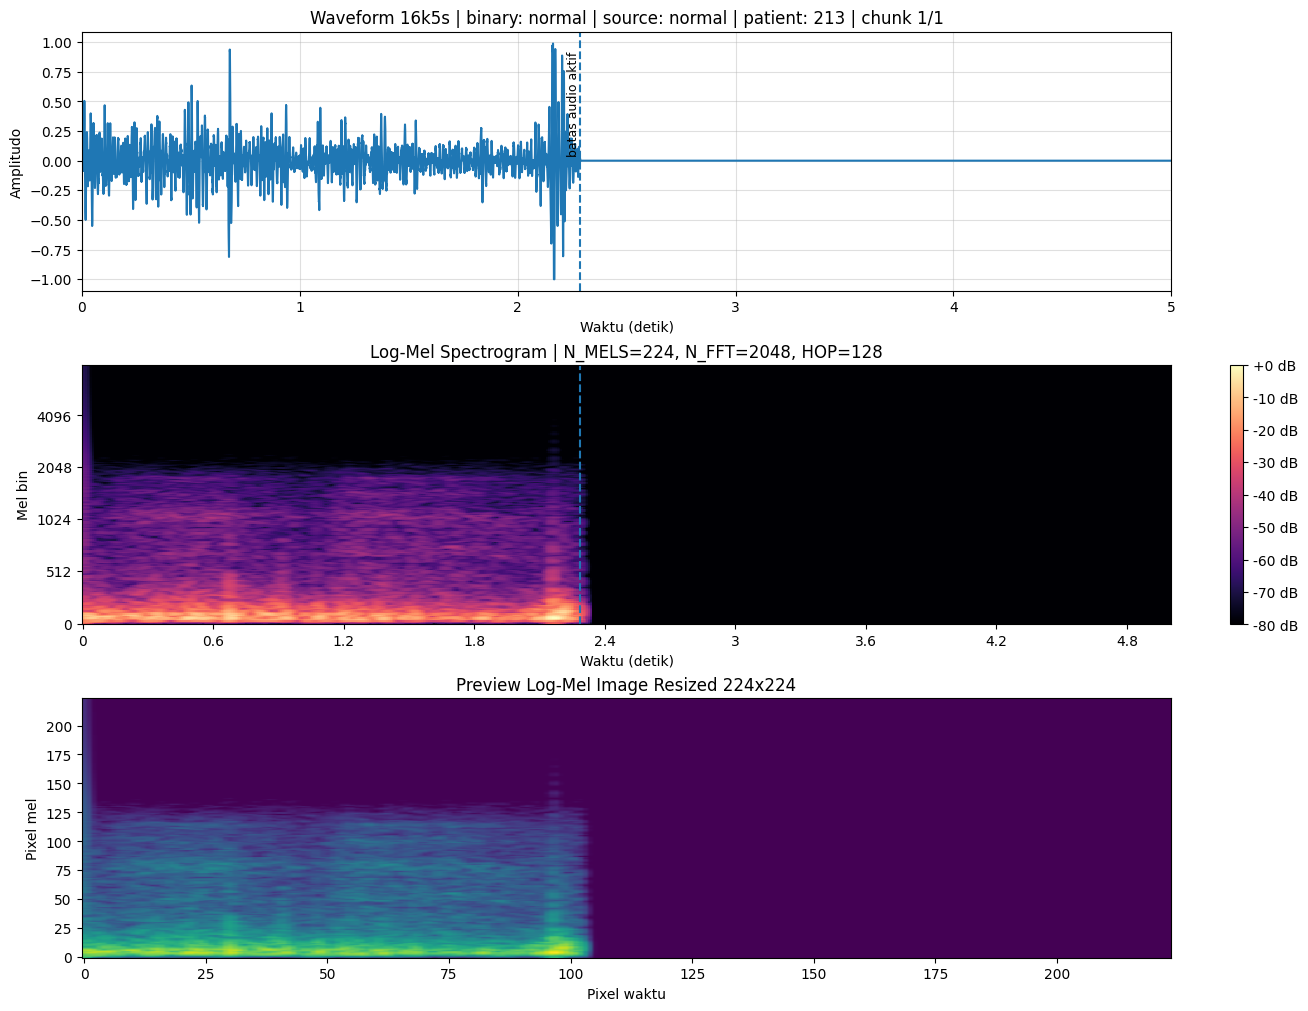


BINARY LABEL : abnormal
SOURCE LABEL : crackle
SPLIT        : train
patient_id   : 154
file         : paper_binary_16k_outputs/03_preprocessed_audio_16k5s/train/98a24876f206897c_chunk000of001_pid154_binabnormal_origcrackle_16k5s.wav
parent id    : 154_4b4_Pl_mc_AKGC417L_s14.732_e16.851_seg7_s14.732_e16.851
sample id    : 154_4b4_Pl_mc_AKGC417L_s14.732_e16.851_seg7_s14.732_e16.851_chunk000
chunk        : 1/1
sr                : 16000
durasi            : 5.000000 detik
len sampel        : 80000
target sampel     : 80000
RMS               : 0.113795
dBFS file         : -18.8775
min/max amplitudo : -1.000000 / 0.999969
fix strategy                        : sequential_5s_chunking_with_right_padding
padding ratio                       : 0.576187
durasi aktif chunk sebelum padding  : 2.119063
durasi padding                      : 2.880937
durasi original segment             : 2.119063
active dBFS setelah normalisasi     : -15.149278
processed dBFS setelah fix          : -18.877541

Preview a

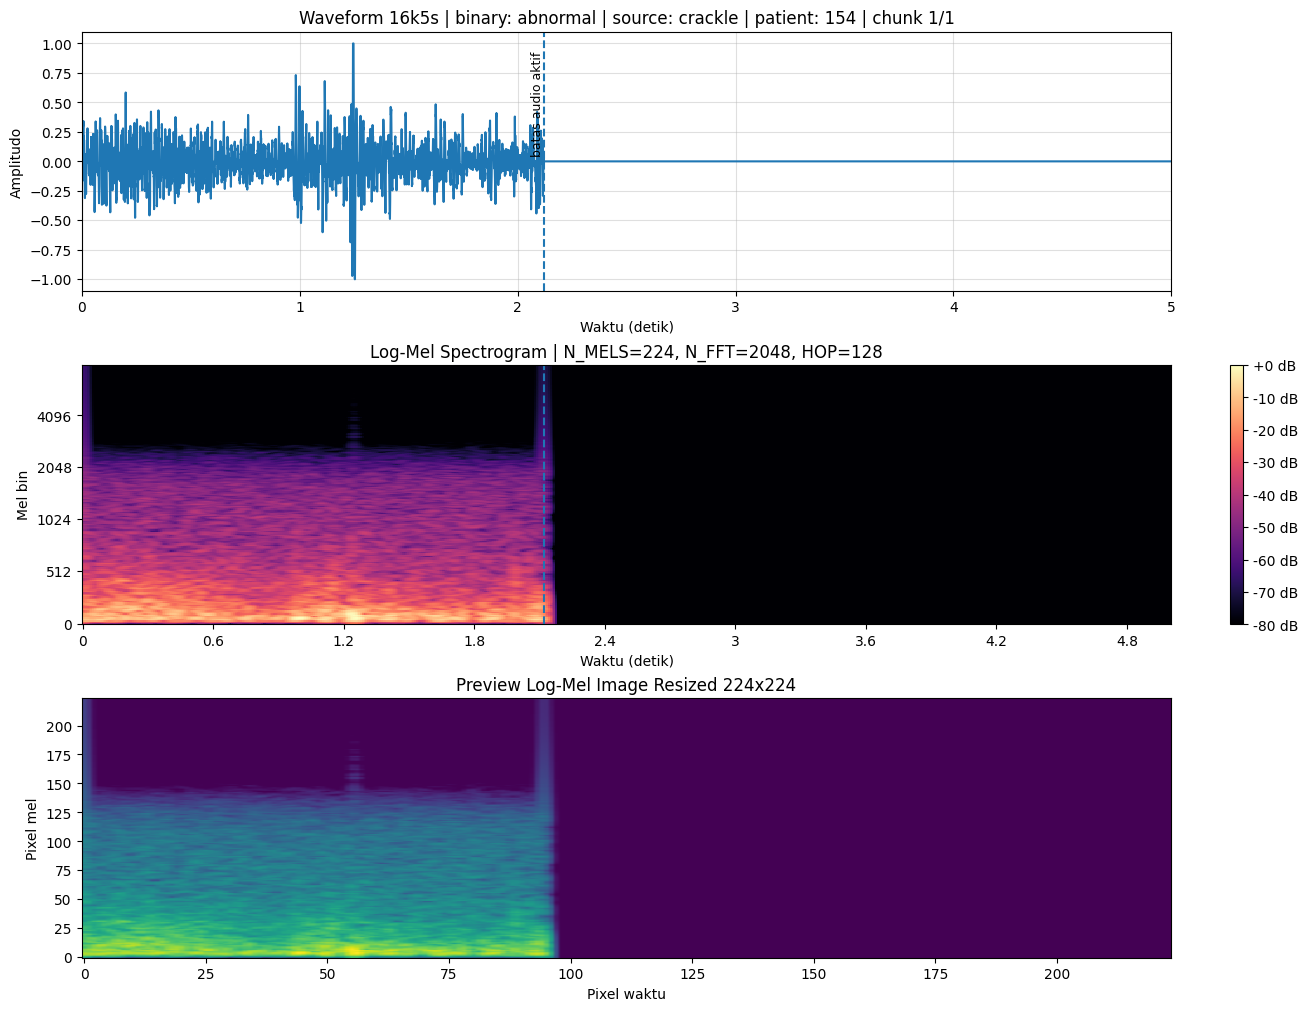


[OK] Preview waveform dan Log-Mel 16k5s selesai.


In [9]:
# ============================================================
# CELL 16: PREVIEW WAVEFORM DAN LOG-MEL HASIL PREPROCESSING 16k5s
# Pipeline: 16 kHz + fixed 5 detik + sequential chunking
# Target: Binary Normal-Abnormal
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import Audio, display


# ============================================================
# 0. KONFIGURASI
# ============================================================

PREPROC_DIR = globals().get(
    "PREPROC_DIR",
    "paper_binary_16k_outputs/03_preprocessed_audio_16k5s"
)

PREPROC_DIR = Path(PREPROC_DIR)

SPLIT = "train"          # "train" / "val" / "test"
N_PER_CLASS = 1
RANDOM_STATE = 42

TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_DURATION_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN_SAMPLES = int(globals().get("TARGET_LEN", TARGET_SR * TARGET_DURATION_SEC))

BINARY_CLASSES = ["normal", "abnormal"]
SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]

# Parameter Log-Mel sesuai arah konfigurasi paper
N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
N_MELS = 224
FMIN = 0
FMAX = 8000

IMAGE_SIZE = 224

meta_path = PREPROC_DIR / f"metadata_{SPLIT}_16k5s.csv"


# ============================================================
# 1. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def normalize_metadata_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "file" not in df.columns:
        if "audio_path" in df.columns:
            df["file"] = df["audio_path"].astype(str)
        else:
            raise ValueError("Kolom `file` atau `audio_path` tidak ditemukan pada metadata.")

    df["file"] = df["file"].astype(str).str.strip()

    if "binary_label" not in df.columns:
        if "label_id" in df.columns:
            df["binary_label"] = df["label_id"].map({0: "normal", 1: "abnormal"})
        else:
            raise ValueError("Kolom `binary_label` tidak ditemukan.")

    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    if "sound_4class" not in df.columns:
        if "sound" in df.columns:
            df["sound_4class"] = df["sound"].astype(str).str.strip().str.lower()
        elif "original_sound" in df.columns:
            df["sound_4class"] = df["original_sound"].astype(str).str.strip().str.lower()
        else:
            df["sound_4class"] = df["binary_label"]

    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "patient_id" not in df.columns:
        raise ValueError("Kolom `patient_id` tidak ditemukan.")

    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    if "split" not in df.columns:
        df["split"] = SPLIT

    df["split"] = df["split"].astype(str).str.strip().str.lower()

    return df


def compute_dbfs(y, eps=1e-10):
    if y is None or len(y) == 0:
        return np.nan

    rms = np.sqrt(np.mean(np.square(y)) + eps)
    dbfs = 20.0 * np.log10(rms + eps)

    return float(dbfs)


def make_logmel(y, sr):
    fmax_eff = min(FMAX, sr / 2)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=fmax_eff,
        power=2.0
    )

    mel_db = librosa.power_to_db(
        mel + 1e-10,
        ref=np.max
    )

    return mel_db


def logmel_to_resized_uint8_image(mel_db, image_size=IMAGE_SIZE):
    """
    Konversi Log-Mel dB menjadi image grayscale 224x224 untuk preview.
    Ini hanya preview. Cell konversi Log-Mel final nanti yang akan menyimpan image dataset.
    """
    mel_min = float(np.min(mel_db))
    mel_max = float(np.max(mel_db))

    mel_norm = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)
    mel_uint8 = (mel_norm * 255.0).clip(0, 255).astype(np.uint8)

    img = Image.fromarray(mel_uint8)
    img = img.resize((image_size, image_size), resample=Image.BILINEAR)

    return np.array(img)


def choose_samples(df, label_col="binary_label", n_per_class=1, random_state=42):
    selected_rows = []

    for cls in BINARY_CLASSES:
        df_cls = df[df[label_col] == cls].copy()

        if len(df_cls) == 0:
            print(f"[INFO] Kelas `{cls}` tidak ada pada split {SPLIT}.")
            continue

        sample_df = df_cls.sample(
            n=min(n_per_class, len(df_cls)),
            random_state=random_state
        )

        selected_rows.append(sample_df)

    if len(selected_rows) == 0:
        raise RuntimeError("Tidak ada sample yang bisa dipreview.")

    return pd.concat(selected_rows, ignore_index=True)


# ============================================================
# 2. LOAD METADATA
# ============================================================

if not meta_path.exists():
    print("=" * 80)
    print("METADATA PREPROCESSING 16k5s TIDAK DITEMUKAN")
    print("=" * 80)
    print("Path yang dicari:")
    print(meta_path)

    if PREPROC_DIR.exists():
        print(f"\nIsi folder {PREPROC_DIR}:")
        print(os.listdir(PREPROC_DIR))
    else:
        print(f"\nFolder {PREPROC_DIR} belum ada.")

    raise FileNotFoundError(f"Metadata tidak ditemukan: {meta_path}")

df = pd.read_csv(meta_path)
df = normalize_metadata_columns(df)

print("=" * 80)
print("PREVIEW WAVEFORM DAN LOG-MEL HASIL PREPROCESSING 16k5s")
print("=" * 80)
print("Metadata        :", meta_path)
print("PREPROC_DIR     :", PREPROC_DIR)
print("Split           :", SPLIT)
print("Total chunk     :", len(df))
print("Pasien unik     :", df["patient_id"].nunique())
print("Target SR       :", TARGET_SR)
print("Target durasi   :", TARGET_DURATION_SEC)
print("Target samples  :", TARGET_LEN_SAMPLES)

if "parent_sample_id" in df.columns:
    print("Parent segment  :", df["parent_sample_id"].nunique())

print("\nDistribusi binary label:")
print(df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi label sumber:")
print(df["sound_4class"].value_counts().reindex(SOURCE_CLASSES, fill_value=0))

print("\nParameter Log-Mel preview:")
print("N_FFT      :", N_FFT)
print("HOP_LENGTH :", HOP_LENGTH)
print("WIN_LENGTH :", WIN_LENGTH)
print("N_MELS     :", N_MELS)
print("FMIN       :", FMIN)
print("FMAX       :", FMAX)
print("IMAGE_SIZE :", IMAGE_SIZE)


# ============================================================
# 3. PILIH SAMPLE PREVIEW
# ============================================================

preview_df = choose_samples(
    df,
    label_col="binary_label",
    n_per_class=N_PER_CLASS,
    random_state=RANDOM_STATE
)

preview_cols = [
    "patient_id",
    "split",
    "binary_label",
    "label_id",
    "sound_4class",
    "parent_sample_id",
    "sample_id",
    "chunk_idx",
    "n_chunks_from_segment",
    "target_sr",
    "target_sec",
    "target_len_samples",
    "processed_len_samples",
    "processed_duration_sec",
    "fix_strategy",
    "padding_ratio",
    "active_duration_sec_before_fix",
    "active_dbfs_after_norm",
    "processed_dbfs_after_fix",
    "file"
]

preview_cols = [c for c in preview_cols if c in preview_df.columns]

print("\nSample yang akan dipreview:")
safe_display(preview_df[preview_cols])


# ============================================================
# 4. PREVIEW WAVEFORM DAN LOG-MEL
# ============================================================

for row_idx, sample in preview_df.iterrows():
    audio_path = str(sample["file"])

    binary_label = str(sample["binary_label"])
    source_label = str(sample["sound_4class"])
    pid = sample.get("patient_id", "NA")

    chunk_text = ""
    if "chunk_idx" in sample.index and "n_chunks_from_segment" in sample.index:
        chunk_text = f" | chunk {int(sample['chunk_idx']) + 1}/{int(sample['n_chunks_from_segment'])}"

    print("\n" + "=" * 80)
    print(f"BINARY LABEL : {binary_label}")
    print(f"SOURCE LABEL : {source_label}")
    print(f"SPLIT        : {SPLIT}")
    print(f"patient_id   : {pid}")
    print(f"file         : {audio_path}")

    if "parent_sample_id" in sample.index:
        print(f"parent id    : {sample['parent_sample_id']}")

    if "sample_id" in sample.index:
        print(f"sample id    : {sample['sample_id']}")

    if "chunk_idx" in sample.index and "n_chunks_from_segment" in sample.index:
        print(f"chunk        : {int(sample['chunk_idx']) + 1}/{int(sample['n_chunks_from_segment'])}")

    if not os.path.exists(audio_path):
        print("[WARNING] File audio tidak ditemukan, skip.")
        continue

    try:
        y, sr = librosa.load(
            audio_path,
            sr=None,
            mono=True
        )
    except Exception as e:
        print(f"[ERROR] Gagal load audio: {repr(e)}")
        continue

    dur = len(y) / sr if sr else 0.0
    rms = float(np.sqrt(np.mean(y ** 2))) if len(y) > 0 else 0.0
    dbfs = compute_dbfs(y)

    print(f"sr                : {sr}")
    print(f"durasi            : {dur:.6f} detik")
    print(f"len sampel        : {len(y)}")
    print(f"target sampel     : {TARGET_LEN_SAMPLES}")
    print(f"RMS               : {rms:.6f}")
    print(f"dBFS file         : {dbfs:.4f}")

    if len(y) > 0:
        print(f"min/max amplitudo : {float(y.min()):.6f} / {float(y.max()):.6f}")

    optional_info = [
        ("fix_strategy", "fix strategy"),
        ("padding_ratio", "padding ratio"),
        ("active_duration_sec_before_fix", "durasi aktif chunk sebelum padding"),
        ("padding_duration_sec", "durasi padding"),
        ("original_segment_duration_sec", "durasi original segment"),
        ("active_dbfs_after_norm", "active dBFS setelah normalisasi"),
        ("processed_dbfs_after_fix", "processed dBFS setelah fix"),
    ]

    for col, label in optional_info:
        if col in sample.index and pd.notna(sample[col]):
            value = sample[col]

            if isinstance(value, (float, int, np.floating, np.integer)):
                print(f"{label:<36}: {float(value):.6f}")
            else:
                print(f"{label:<36}: {value}")

    if sr != TARGET_SR:
        print(f"[WARNING] SR file bukan {TARGET_SR} Hz.")

    if len(y) != TARGET_LEN_SAMPLES:
        print(f"[WARNING] Panjang file bukan {TARGET_LEN_SAMPLES} sample.")

    print("\nPreview audio:")
    display(Audio(data=y, rate=sr, normalize=False))

    # ========================================================
    # Plot waveform, log-mel, dan resized log-mel image
    # ========================================================

    t = np.linspace(0, dur, num=len(y)) if len(y) > 0 else np.array([0.0])

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(13, 10),
        constrained_layout=True
    )

    # --------------------------------------------------------
    # 4.1 Waveform
    # --------------------------------------------------------

    ax = axes[0]

    if len(y) > 0:
        ax.plot(t, y)

    ax.set_title(
        f"Waveform 16k5s | binary: {binary_label} | source: {source_label} | patient: {pid}{chunk_text}"
    )
    ax.set_xlabel("Waktu (detik)")
    ax.set_ylabel("Amplitudo")
    ax.set_xlim(0, max(dur, 1e-6))
    ax.grid(alpha=0.4)

    # Tandai batas audio aktif chunk sebelum padding
    if "active_duration_sec_before_fix" in sample.index:
        active_dur = float(sample["active_duration_sec_before_fix"])

        if np.isfinite(active_dur) and 0 < active_dur < dur:
            ax.axvline(
                active_dur,
                linestyle="--",
                linewidth=1.5
            )
            ax.text(
                active_dur,
                ax.get_ylim()[1] * 0.85,
                "batas audio aktif",
                rotation=90,
                va="top",
                ha="right",
                fontsize=9
            )

    # --------------------------------------------------------
    # 4.2 Log-Mel Spectrogram
    # --------------------------------------------------------

    ax2 = axes[1]

    if len(y) > 0 and sr is not None and sr > 0:
        mel_db = make_logmel(y, sr)

        img = librosa.display.specshow(
            mel_db,
            sr=sr,
            hop_length=HOP_LENGTH,
            x_axis="time",
            y_axis="mel",
            fmin=FMIN,
            fmax=min(FMAX, sr / 2),
            ax=ax2
        )

        ax2.set_title(
            f"Log-Mel Spectrogram | N_MELS={N_MELS}, N_FFT={N_FFT}, HOP={HOP_LENGTH}"
        )
        ax2.set_xlabel("Waktu (detik)")
        ax2.set_ylabel("Mel bin")

        fig.colorbar(
            img,
            ax=ax2,
            format="%+2.0f dB"
        )

        if "active_duration_sec_before_fix" in sample.index:
            active_dur = float(sample["active_duration_sec_before_fix"])

            if np.isfinite(active_dur) and 0 < active_dur < dur:
                ax2.axvline(
                    active_dur,
                    linestyle="--",
                    linewidth=1.5
                )

    else:
        mel_db = None
        ax2.set_title("Log-Mel Spectrogram, audio kosong")
        ax2.axis("off")

    # --------------------------------------------------------
    # 4.3 Preview Log-Mel resized 224x224
    # --------------------------------------------------------

    ax3 = axes[2]

    if mel_db is not None:
        mel_img_224 = logmel_to_resized_uint8_image(
            mel_db,
            image_size=IMAGE_SIZE
        )

        ax3.imshow(
            mel_img_224,
            aspect="auto",
            origin="lower"
        )

        ax3.set_title(
            f"Preview Log-Mel Image Resized {IMAGE_SIZE}x{IMAGE_SIZE}"
        )
        ax3.set_xlabel("Pixel waktu")
        ax3.set_ylabel("Pixel mel")
    else:
        ax3.set_title("Preview Log-Mel Image kosong")
        ax3.axis("off")

    plt.show()


print("\n[OK] Preview waveform dan Log-Mel 16k5s selesai.")


# ============================================================
# 5. SIMPAN KE GLOBALS
# ============================================================

globals()["preview_preprocessing_df_16k5s"] = preview_df

# **Augmentasi Manual**

> **Pitch Shifting** dan
> **Time Stretching**

In [10]:
# ============================================================
# CELL: AUGMENTASI TRAIN BINARY 16 kHz + 5 DETIK
# Output binary :
# normal vs abnormal
# ============================================================
import os
import re
import math
import shutil
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf

from scipy.signal import resample_poly
from tqdm.auto import tqdm


# ============================================================
# 0. KONFIGURASI PATH
# ============================================================

PREPROC_DIR = Path(
    globals().get(
        "PREPROC_DIR",
        "paper_binary_16k_outputs/03_preprocessed_audio_16k5s"
    )
)

AUG_DIR = Path("paper_binary_16k_outputs/04_augmented_audio_manual_16k5s")
AUG_AUDIO_DIR = AUG_DIR / "train"

TRAIN_META_PATH = PREPROC_DIR / "metadata_train_16k5s.csv"

AUG_META_PATH = AUG_DIR / "metadata_train_manual_aug_only_16k5s.csv"
TRAIN_WITH_AUG_META_PATH = AUG_DIR / "metadata_train_with_manual_aug_16k5s.csv"

SUMMARY_AUG_PATH = AUG_DIR / "summary_manual_aug_binary_16k5s.csv"
SUMMARY_TRAIN_WITH_AUG_PATH = AUG_DIR / "summary_train_with_manual_aug_binary_16k5s.csv"
SUMMARY_AUG_4CLASS_PATH = AUG_DIR / "summary_manual_aug_4class_16k5s.csv"

CLEAN_OLD_AUG_OUTPUT = True

AUG_DIR.mkdir(parents=True, exist_ok=True)

if CLEAN_OLD_AUG_OUTPUT:
    files_to_delete = [
        AUG_META_PATH,
        TRAIN_WITH_AUG_META_PATH,
        SUMMARY_AUG_PATH,
        SUMMARY_TRAIN_WITH_AUG_PATH,
        SUMMARY_AUG_4CLASS_PATH,
    ]

    for p in files_to_delete:
        if p.exists():
            p.unlink()
            print("Deleted:", p)

    if AUG_AUDIO_DIR.exists():
        shutil.rmtree(AUG_AUDIO_DIR)
        print("Deleted folder:", AUG_AUDIO_DIR)

AUG_AUDIO_DIR.mkdir(parents=True, exist_ok=True)

if not TRAIN_META_PATH.exists():
    raise FileNotFoundError(
        f"Metadata train hasil preprocessing 16k5s tidak ditemukan: {TRAIN_META_PATH}\n"
        "Jalankan cell preprocessing audio 16k5s terlebih dahulu."
    )


# ============================================================
# 1. KONFIGURASI LABEL DAN AUGMENTASI
# ============================================================

BINARY_CLASSES = ["normal", "abnormal"]
VALID_4CLASS = ["normal", "crackle", "wheeze", "both"]

LABEL_TO_ID = {
    "normal": 0,
    "abnormal": 1
}

TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_LEN_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN = int(globals().get("TARGET_LEN", TARGET_SR * TARGET_LEN_SEC))

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

AUGMENT_STRATEGY = "explicit_subtype_operation_target"

# Target eksplisit sesuai keputusan metodologi.
AUGMENTATION_TARGETS = {
    ("both", "time_stretch"): 210,
    ("both", "pitch_shift"): 140,
    ("wheeze", "time_stretch"): 140,
    ("wheeze", "pitch_shift"): 93,
}

EXPECTED_TOTAL_TIME_STRETCH = 350
EXPECTED_TOTAL_PITCH_SHIFT = 233
EXPECTED_TOTAL_AUG = 583

TIME_STRETCH_MIN = 0.90
TIME_STRETCH_MAX = 1.10

PITCH_SHIFT_MIN = -2.0
PITCH_SHIFT_MAX = 2.0

# Hindari pitch shift terlalu dekat 0 agar benar-benar terjadi augmentasi.
MIN_ABS_PITCH_SHIFT = 0.5


# ============================================================
# 2. HELPER UMUM
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def sanitize_token(s):
    s = str(s).strip()
    s = s.replace("\\", "_").replace("/", "_").replace(" ", "_")
    s = re.sub(r"[^A-Za-z0-9_.+-]", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else "unknown"


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ["crackle", "wheeze", "both", "abnormal"]:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def infer_sound_4class(row):
    for col in ["sound_4class", "original_sound", "sound"]:
        if col in row.index and safe_str(row[col]):
            label = safe_str(row[col]).lower()
            if label in VALID_4CLASS:
                return label

    binary_label = safe_str(row.get("binary_label", "")).lower()

    if binary_label == "normal":
        return "normal"

    if binary_label == "abnormal":
        return "abnormal"

    return "unknown"


def safe_audio_array(y):
    if y is None:
        return None

    y = np.asarray(y, dtype=np.float64)

    if y.ndim > 1:
        y = y.mean(axis=1)

    if len(y) == 0:
        return None

    y = np.nan_to_num(
        y,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    if not np.all(np.isfinite(y)):
        return None

    max_abs = float(np.max(np.abs(y))) if len(y) > 0 else 0.0

    if not np.isfinite(max_abs):
        return None

    if max_abs > 10.0:
        y = y / (max_abs + 1e-12)

    return y.astype(np.float32, copy=False)


def resample_to_target(y, orig_sr, target_sr):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None

    orig_sr = int(orig_sr)
    target_sr = int(target_sr)

    if orig_sr == target_sr:
        return y.astype(np.float32, copy=False)

    gcd = math.gcd(orig_sr, target_sr)
    up = target_sr // gcd
    down = orig_sr // gcd

    try:
        y_rs = resample_poly(y, up, down)
    except Exception:
        return None

    y_rs = safe_audio_array(y_rs)

    if y_rs is None or len(y_rs) == 0:
        return None

    return y_rs.astype(np.float32, copy=False)


def make_rng_from_key(key, seed_base=RANDOM_STATE):
    key = str(key)
    digest = hashlib.md5(f"{seed_base}_{key}".encode("utf-8")).hexdigest()
    seed = int(digest[:8], 16)
    return np.random.default_rng(seed)


def make_short_file_id(sample_key, aug_idx):
    raw = f"{sample_key}_{aug_idx}"
    return hashlib.md5(raw.encode("utf-8")).hexdigest()[:16]


def compute_dbfs(y, eps=1e-10):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return np.nan

    rms = float(np.sqrt(np.mean(np.square(y, dtype=np.float64)) + eps))
    dbfs = float(20.0 * np.log10(rms + eps))

    return dbfs


def fix_audio_to_target_len(y, rng, target_len=TARGET_LEN):
    """
    Membuat hasil augmentasi menjadi tepat 5 detik.

    Aturan:
    - Jika lebih pendek dari 5 detik:
      right zero padding
    - Jika lebih panjang dari 5 detik:
      random crop deterministik berdasarkan rng

    Kenapa crop diperlukan?
    Time stretching rate < 1.0 membuat audio lebih panjang dari 5 detik.
    Kalau tetap di-split menjadi beberapa chunk, jumlah data augmentasi akan melebihi target.
    """

    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None, {}

    original_len = int(len(y))

    crop_start = 0
    crop_end = original_len
    padding_len = 0
    fix_strategy = "none"

    if original_len > target_len:
        max_start = original_len - target_len
        crop_start = int(rng.integers(0, max_start + 1))
        crop_end = crop_start + target_len
        y_fixed = y[crop_start:crop_end].astype(np.float32, copy=False)
        fix_strategy = "random_crop_to_5s"

    elif original_len < target_len:
        padding_len = target_len - original_len
        y_fixed = np.pad(
            y,
            (0, padding_len),
            mode="constant",
            constant_values=0.0
        ).astype(np.float32, copy=False)
        crop_start = 0
        crop_end = original_len
        fix_strategy = "right_zero_padding_to_5s"

    else:
        y_fixed = y.astype(np.float32, copy=False)
        crop_start = 0
        crop_end = original_len
        fix_strategy = "already_5s"

    if len(y_fixed) != target_len:
        raise RuntimeError(
            f"Length fixing gagal: {len(y_fixed)} != {target_len}"
        )

    info = {
        "aug_len_before_fix_samples": int(original_len),
        "aug_len_before_fix_sec": float(original_len / TARGET_SR),

        "aug_crop_start_sample_before_fix": int(crop_start),
        "aug_crop_end_sample_before_fix": int(crop_end),
        "aug_crop_start_sec_before_fix": float(crop_start / TARGET_SR),
        "aug_crop_end_sec_before_fix": float(crop_end / TARGET_SR),

        "aug_padding_len_samples": int(padding_len),
        "aug_padding_duration_sec": float(padding_len / TARGET_SR),
        "aug_padding_ratio": float(padding_len / target_len),

        "aug_length_fix_strategy": fix_strategy,
        "aug_padding_strategy": "right_zero_padding_if_short",
        "aug_crop_strategy": "random_crop_if_long",
        "aug_truncate_strategy": "none",
    }

    return y_fixed.astype(np.float32, copy=False), info


# ============================================================
# 3. FUNGSI AUGMENTASI
# ============================================================

def time_stretch_manual(y, rng):
    rate = float(rng.uniform(TIME_STRETCH_MIN, TIME_STRETCH_MAX))

    try:
        y_aug = librosa.effects.time_stretch(
            y.astype(np.float32),
            rate=rate
        )
    except TypeError:
        y_aug = librosa.effects.time_stretch(
            y.astype(np.float32),
            rate
        )

    y_aug = safe_audio_array(y_aug)

    if y_aug is None or len(y_aug) == 0:
        return None, None, None, {}

    y_aug = np.clip(y_aug, -1.0, 1.0).astype(np.float32, copy=False)

    y_fixed, length_info = fix_audio_to_target_len(
        y_aug,
        rng=rng,
        target_len=TARGET_LEN
    )

    return y_fixed, "time_stretch_rate", rate, length_info


def pitch_shift_manual(y, sr, rng):
    n_steps = float(rng.uniform(PITCH_SHIFT_MIN, PITCH_SHIFT_MAX))

    if abs(n_steps) < MIN_ABS_PITCH_SHIFT:
        n_steps = MIN_ABS_PITCH_SHIFT if n_steps >= 0 else -MIN_ABS_PITCH_SHIFT

    try:
        y_aug = librosa.effects.pitch_shift(
            y.astype(np.float32),
            sr=int(sr),
            n_steps=n_steps
        )
    except TypeError:
        y_aug = librosa.effects.pitch_shift(
            y.astype(np.float32),
            int(sr),
            n_steps
        )

    y_aug = safe_audio_array(y_aug)

    if y_aug is None or len(y_aug) == 0:
        return None, None, None, {}

    y_aug = np.clip(y_aug, -1.0, 1.0).astype(np.float32, copy=False)

    y_fixed, length_info = fix_audio_to_target_len(
        y_aug,
        rng=rng,
        target_len=TARGET_LEN
    )

    return y_fixed, "pitch_shift_steps", n_steps, length_info


def augment_audio(y, sr, aug_type, rng):
    y = safe_audio_array(y)

    if y is None or len(y) == 0:
        return None, None, None, {}

    if len(y) != TARGET_LEN:
        return None, None, None, {}

    if aug_type == "time_stretch":
        return time_stretch_manual(y, rng)

    if aug_type == "pitch_shift":
        return pitch_shift_manual(y, sr, rng)

    raise ValueError(f"aug_type tidak dikenal: {aug_type}")


# ============================================================
# 4. LOAD METADATA TRAIN HASIL PREPROCESSING 16k5s
# ============================================================

train_df = pd.read_csv(TRAIN_META_PATH).copy()
train_df.columns = [str(c).strip() for c in train_df.columns]

if "file" not in train_df.columns:
    if "audio_path" in train_df.columns:
        train_df["file"] = train_df["audio_path"].astype(str)
    else:
        raise AssertionError(
            "Kolom `file` atau `audio_path` tidak ditemukan pada metadata train."
        )

required_cols = ["file", "patient_id", "split"]
missing_cols = [c for c in required_cols if c not in train_df.columns]

if missing_cols:
    raise AssertionError(
        f"Kolom wajib tidak ada pada metadata train preprocessing 16k5s: {missing_cols}"
    )

train_df["file"] = train_df["file"].astype(str).str.strip()
train_df["split"] = train_df["split"].astype(str).str.strip().str.lower()

train_df = train_df[train_df["split"] == "train"].copy().reset_index(drop=True)

if "sound_4class" not in train_df.columns:
    train_df["sound_4class"] = train_df.apply(infer_sound_4class, axis=1)
else:
    train_df["sound_4class"] = train_df["sound_4class"].astype(str).str.strip().str.lower()

if "sound" not in train_df.columns:
    train_df["sound"] = train_df["sound_4class"]
else:
    train_df["sound"] = train_df["sound"].astype(str).str.strip().str.lower()

if "original_sound" not in train_df.columns:
    train_df["original_sound"] = train_df["sound_4class"]
else:
    train_df["original_sound"] = train_df["original_sound"].astype(str).str.strip().str.lower()

if "binary_label" not in train_df.columns:
    train_df["binary_label"] = train_df["sound_4class"].apply(to_binary_label)
else:
    train_df["binary_label"] = train_df["binary_label"].astype(str).str.strip().str.lower()

unknown_binary = sorted(set(train_df["binary_label"]) - set(BINARY_CLASSES))

if unknown_binary:
    raise AssertionError(f"Label binary tidak dikenal: {unknown_binary}")

unknown_4class = sorted(set(train_df["sound_4class"]) - set(VALID_4CLASS))

if unknown_4class:
    raise AssertionError(
        f"Label sound_4class tidak valid: {unknown_4class}. "
        "Pastikan kolom sound/original_sound masih berisi normal/crackle/wheeze/both."
    )

train_df["patient_id"] = pd.to_numeric(train_df["patient_id"], errors="coerce")
train_df = train_df.dropna(subset=["patient_id"]).copy()
train_df["patient_id"] = train_df["patient_id"].astype(int)
train_df = train_df[train_df["patient_id"] != -1].copy().reset_index(drop=True)

train_df["label_id"] = train_df["binary_label"].map(LABEL_TO_ID).astype(int)

# Pastikan sumber augmentasi hanya original, bukan hasil augmentasi lama.
if "is_augmented" in train_df.columns:
    train_df["is_augmented"] = (
        pd.to_numeric(train_df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )
    train_df = train_df[train_df["is_augmented"] == 0].copy().reset_index(drop=True)
else:
    train_df["is_augmented"] = 0

# Cek file audio.
train_df["file_exists"] = train_df["file"].apply(lambda p: os.path.exists(str(p)))
missing_audio = int((~train_df["file_exists"]).sum())

if missing_audio > 0:
    print(f"[WARNING] Ada {missing_audio} file audio train yang tidak ditemukan.")
    print("Contoh file hilang:")
    print(train_df.loc[~train_df["file_exists"], "file"].head(10).to_string(index=False))
    train_df = train_df[train_df["file_exists"]].copy().reset_index(drop=True)

if len(train_df) == 0:
    raise RuntimeError("Tidak ada data train valid untuk augmentasi 16k5s.")

print("=" * 80)
print("AUGMENTASI TRAIN BINARY 16k5s BERDASARKAN TARGET EKSPLISIT")
print("=" * 80)
print("Metadata train preprocessing:", TRAIN_META_PATH)
print("Output augmentasi          :", AUG_DIR)
print("Total train asli valid     :", len(train_df))
print("TARGET_SR                  :", TARGET_SR)
print("TARGET_LEN_SEC             :", TARGET_LEN_SEC)
print("TARGET_LEN samples         :", TARGET_LEN)
print("TIME_STRETCH range         :", TIME_STRETCH_MIN, "sampai", TIME_STRETCH_MAX)
print("PITCH_SHIFT range          :", PITCH_SHIFT_MIN, "sampai", PITCH_SHIFT_MAX)

print("\nDistribusi source label train:")
print(train_df["sound_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0))

print("\nDistribusi binary label train:")
print(train_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))


# ============================================================
# 5. VALIDASI RENCANA AUGMENTASI
# ============================================================

plan_rows = []

for (sound_cls, aug_type), target_n in AUGMENTATION_TARGETS.items():
    source_count = int((train_df["sound_4class"] == sound_cls).sum())

    if source_count == 0:
        raise RuntimeError(f"Tidak ada source untuk kelas {sound_cls}.")

    plan_rows.append({
        "sound_4class": sound_cls,
        "binary_label": "abnormal",
        "aug_type": aug_type,
        "target_aug_count": int(target_n),
        "available_source_count": int(source_count),
        "reuse_needed": bool(target_n > source_count),
        "max_reuse_per_source_est": int(np.ceil(target_n / source_count))
    })

plan_df = pd.DataFrame(plan_rows)

print("\nRencana augmentasi eksplisit:")
safe_display(plan_df)

# ============================================================
# 6. JALANKAN AUGMENTASI
# ============================================================

aug_rows = []
global_aug_idx = 0

skipped_aug = 0
skipped_read = 0
skipped_source_length = 0
skipped_empty_output = 0
skipped_write = 0
skipped_error = 0

for (sound_target, aug_type), n_to_make in AUGMENTATION_TARGETS.items():
    df_src = (
        train_df[
            (train_df["split"] == "train") &
            (train_df["sound_4class"] == sound_target) &
            (train_df["binary_label"] == "abnormal")
        ]
        .copy()
        .reset_index(drop=True)
    )

    if len(df_src) == 0:
        raise RuntimeError(f"Tidak ada data sumber untuk {sound_target}.")

    # Shuffle deterministik agar tidak selalu mengambil urutan metadata awal.
    rng_select = make_rng_from_key(f"select_{sound_target}_{aug_type}")
    selected_indices = rng_select.permutation(len(df_src))

    print("\n" + "=" * 80)
    print(f"Membuat augmentasi: sound={sound_target}, aug_type={aug_type}")
    print("Target data augmentasi:", n_to_make)
    print("Sumber tersedia       :", len(df_src))

    made_for_group = 0
    attempt = 0
    max_attempt = n_to_make * 10

    pbar = tqdm(total=n_to_make, ncols=100)

    while made_for_group < n_to_make and attempt < max_attempt:
        src_pos = int(selected_indices[attempt % len(selected_indices)])
        row = df_src.iloc[src_pos]
        attempt += 1

        src_path = str(row["file"])
        patient_id = int(row["patient_id"])

        sound_4class = str(row["sound_4class"]).strip().lower()
        sound = sound_4class
        original_sound = sound_4class
        binary_label = "abnormal"
        label_id = int(LABEL_TO_ID[binary_label])

        try:
            y, sr = sf.read(src_path, always_2d=False, dtype="float64")
            y = safe_audio_array(y)

            if y is None or len(y) == 0:
                skipped_aug += 1
                skipped_read += 1
                continue

            if int(sr) != TARGET_SR:
                y = resample_to_target(y, sr, TARGET_SR)

                if y is None or len(y) == 0:
                    skipped_aug += 1
                    skipped_read += 1
                    continue

                sr = TARGET_SR

            if len(y) != TARGET_LEN:
                skipped_aug += 1
                skipped_source_length += 1
                continue

            if "sample_id" in row.index and safe_str(row["sample_id"]):
                sample_key = sanitize_token(row["sample_id"])
            else:
                sample_key = sanitize_token(Path(src_path).stem)

            rng_key = (
                f"{sample_key}_{sound_target}_{aug_type}_"
                f"{global_aug_idx}_{made_for_group}_{attempt}"
            )
            rng = make_rng_from_key(rng_key)

            y_aug, param_name, param_value, length_info = augment_audio(
                y=y,
                sr=TARGET_SR,
                aug_type=aug_type,
                rng=rng
            )

            if y_aug is None or param_name is None:
                skipped_aug += 1
                skipped_empty_output += 1
                continue

            if len(y_aug) != TARGET_LEN:
                skipped_aug += 1
                skipped_empty_output += 1
                continue

            if not np.all(np.isfinite(y_aug)):
                skipped_aug += 1
                skipped_empty_output += 1
                continue

            y_aug = np.clip(y_aug, -1.0, 1.0).astype(np.float32, copy=False)

            if aug_type == "time_stretch":
                param_token = f"rate{float(param_value):.3f}"
            elif aug_type == "pitch_shift":
                param_token = f"step{float(param_value):+.2f}"
            else:
                raise ValueError(f"aug_type tidak valid: {aug_type}")

            short_id = make_short_file_id(sample_key, global_aug_idx)

            out_name = (
                f"{short_id}"
                f"_pid{patient_id}"
                f"_bin{binary_label}"
                f"_src{sound_4class}"
                f"_aug{global_aug_idx:06d}"
                f"_{aug_type}"
                f"_{sanitize_token(param_token)}"
                f"_16k5s.wav"
            )

            out_name = sanitize_token(out_name.replace(".wav", "")) + ".wav"
            out_path = AUG_AUDIO_DIR / out_name

            try:
                sf.write(
                    str(out_path),
                    y_aug,
                    TARGET_SR,
                    subtype="PCM_16"
                )
            except Exception:
                skipped_aug += 1
                skipped_write += 1
                continue

            aug_row = {}

            # Pertahankan metadata sumber.
            for col in train_df.columns:
                if col == "file_exists":
                    continue
                aug_row[col] = row[col]

            # Override kolom utama.
            aug_row["file"] = str(out_path)
            aug_row["audio_path"] = str(out_path)

            aug_row["sample_id"] = f"{sample_key}_aug{global_aug_idx:06d}"
            aug_row["aug_parent_sample_id"] = sample_key

            aug_row["sound"] = sound
            aug_row["sound_4class"] = sound_4class
            aug_row["original_sound"] = original_sound
            aug_row["binary_label"] = binary_label
            aug_row["label_id"] = label_id
            aug_row["patient_id"] = patient_id
            aug_row["split"] = "train"

            aug_row["source"] = "manual_aug_16k5s"
            aug_row["is_augmented"] = 1
            aug_row["aug_type"] = aug_type
            aug_row["augmentation_group"] = "manual_aug"

            # Provenance augmentasi.
            aug_row["orig_file"] = src_path
            aug_row["aug_source_file"] = src_path
            aug_row["aug_index"] = int(global_aug_idx)
            aug_row["aug_sound_target"] = sound_target
            aug_row["aug_binary_target"] = binary_label
            aug_row["aug_strategy"] = AUGMENT_STRATEGY
            aug_row["aug_param_name"] = param_name
            aug_row["aug_param_value"] = float(param_value)

            # Parameter spesifik augmentasi.
            if aug_type == "time_stretch":
                aug_row["time_stretch_rate"] = float(param_value)
                aug_row["pitch_shift_steps"] = np.nan
            elif aug_type == "pitch_shift":
                aug_row["time_stretch_rate"] = np.nan
                aug_row["pitch_shift_steps"] = float(param_value)

            aug_row["aug_sr"] = int(TARGET_SR)
            aug_row["aug_len_samples"] = int(len(y_aug))
            aug_row["aug_len_sec"] = float(TARGET_LEN_SEC)
            aug_row["aug_dbfs"] = float(compute_dbfs(y_aug))

            aug_row["target_sr"] = int(TARGET_SR)
            aug_row["target_sec"] = float(TARGET_LEN_SEC)
            aug_row["target_len_samples"] = int(TARGET_LEN)

            aug_row["processed_len_samples"] = int(len(y_aug))
            aug_row["processed_duration_sec"] = float(len(y_aug) / TARGET_SR)

            for k, v in length_info.items():
                aug_row[k] = v

            aug_rows.append(aug_row)

            made_for_group += 1
            global_aug_idx += 1
            pbar.update(1)

        except Exception as e:
            skipped_aug += 1
            skipped_error += 1

            if skipped_error <= 5:
                print("\nSkip augmentasi karena error:")
                print("File :", src_path)
                print("Error:", repr(e))

            continue

    pbar.close()

    if made_for_group != n_to_make:
        raise RuntimeError(
            f"Jumlah augmentasi untuk {sound_target} {aug_type} tidak tercapai. "
            f"Target={n_to_make}, dibuat={made_for_group}, attempt={attempt}."
        )


# ============================================================
# 7. SIMPAN METADATA AUGMENTASI
# ============================================================

aug_df = pd.DataFrame(aug_rows)

preferred_cols = [
    "file",
    "audio_path",
    "sample_id",
    "aug_parent_sample_id",

    "sound",
    "sound_4class",
    "original_sound",
    "binary_label",
    "label_id",
    "patient_id",
    "split",

    "source",
    "is_augmented",
    "aug_type",
    "augmentation_group",

    "orig_file",
    "aug_source_file",
    "aug_index",
    "aug_sound_target",
    "aug_binary_target",
    "aug_strategy",
    "aug_param_name",
    "aug_param_value",
    "time_stretch_rate",
    "pitch_shift_steps",

    "aug_sr",
    "aug_len_samples",
    "aug_len_sec",
    "aug_dbfs",

    "aug_len_before_fix_samples",
    "aug_len_before_fix_sec",
    "aug_crop_start_sample_before_fix",
    "aug_crop_end_sample_before_fix",
    "aug_crop_start_sec_before_fix",
    "aug_crop_end_sec_before_fix",
    "aug_padding_len_samples",
    "aug_padding_duration_sec",
    "aug_padding_ratio",
    "aug_length_fix_strategy",
    "aug_padding_strategy",
    "aug_crop_strategy",
    "aug_truncate_strategy",

    "target_sr",
    "target_sec",
    "target_len_samples",
    "processed_len_samples",
    "processed_duration_sec",
]

ordered_cols = (
    [c for c in preferred_cols if c in aug_df.columns] +
    [c for c in aug_df.columns if c not in preferred_cols]
)

aug_df = aug_df[ordered_cols]

aug_df.to_csv(AUG_META_PATH, index=False)

print("\n" + "=" * 80)
print("SELESAI MEMBUAT AUGMENTASI MANUAL 16k5s")
print("=" * 80)
print("Metadata augmentasi disimpan di :", AUG_META_PATH)
print("Total augmentasi dibuat         :", len(aug_df))
print("Skip augmentasi total           :", skipped_aug)
print("Skip read                       :", skipped_read)
print("Skip source length              :", skipped_source_length)
print("Skip empty output               :", skipped_empty_output)
print("Skip write                      :", skipped_write)
print("Skip error                      :", skipped_error)

print("\nDistribusi binary label augmentasi:")
print(aug_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi source label augmentasi:")
print(aug_df["sound_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0))

print("\nDistribusi aug_type:")
print(aug_df["aug_type"].value_counts().reindex(["time_stretch", "pitch_shift"], fill_value=0))

print("\nDistribusi sound_4class x aug_type:")
sound_aug_summary = (
    aug_df
    .groupby(["sound_4class", "aug_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["both", "wheeze"], columns=["time_stretch", "pitch_shift"], fill_value=0)
)
safe_display(sound_aug_summary)

print("\nRingkasan parameter time stretching:")
print(aug_df["time_stretch_rate"].dropna().describe())

print("\nRingkasan parameter pitch shifting:")
print(aug_df["pitch_shift_steps"].dropna().describe())

print("\nDistribusi aug_sr:")
print(aug_df["aug_sr"].value_counts(dropna=False).sort_index())

print("\nDistribusi aug_len_samples:")
print(aug_df["aug_len_samples"].value_counts(dropna=False).sort_index())

print("\nStrategi panjang augmentasi:")
print(aug_df["aug_length_fix_strategy"].value_counts(dropna=False))

print("\nContoh file augmentasi:")
print(os.path.basename(aug_df.iloc[0]["file"]))


# ============================================================
# 8. VALIDASI JUMLAH AUGMENTASI
# ============================================================

assert len(aug_df) == EXPECTED_TOTAL_AUG, (
    f"Total augmentasi salah: {len(aug_df)} != {EXPECTED_TOTAL_AUG}"
)

actual_time_stretch = int((aug_df["aug_type"] == "time_stretch").sum())
actual_pitch_shift = int((aug_df["aug_type"] == "pitch_shift").sum())

assert actual_time_stretch == EXPECTED_TOTAL_TIME_STRETCH, (
    f"Jumlah time_stretch salah: {actual_time_stretch} != {EXPECTED_TOTAL_TIME_STRETCH}"
)

assert actual_pitch_shift == EXPECTED_TOTAL_PITCH_SHIFT, (
    f"Jumlah pitch_shift salah: {actual_pitch_shift} != {EXPECTED_TOTAL_PITCH_SHIFT}"
)

expected_group_counts = {
    ("both", "time_stretch"): 210,
    ("both", "pitch_shift"): 140,
    ("wheeze", "time_stretch"): 140,
    ("wheeze", "pitch_shift"): 93,
}

for (sound_cls, aug_type), expected_n in expected_group_counts.items():
    actual_n = int(
        (
            (aug_df["sound_4class"] == sound_cls) &
            (aug_df["aug_type"] == aug_type)
        ).sum()
    )

    assert actual_n == expected_n, (
        f"Jumlah {sound_cls} {aug_type} salah: {actual_n} != {expected_n}"
    )

assert set(aug_df["binary_label"].unique().tolist()) == {"abnormal"}, (
    "Semua data augmentasi seharusnya binary_label = abnormal."
)

assert set(aug_df["sound_4class"].unique().tolist()).issubset({"both", "wheeze"}), (
    "Augmentasi hanya boleh berasal dari both dan wheeze."
)

assert set(aug_df["aug_sr"].astype(int).unique().tolist()) == {TARGET_SR}, (
    f"Ada file augmentasi dengan sampling rate bukan {TARGET_SR} Hz."
)

assert set(aug_df["aug_len_samples"].astype(int).unique().tolist()) == {TARGET_LEN}, (
    f"Ada file augmentasi dengan panjang sample bukan {TARGET_LEN}."
)

print("\n[OK] Validasi jumlah augmentasi sesuai target.")


# ============================================================
# 9. GABUNGKAN TRAIN ORIGINAL + AUGMENTASI
# ============================================================

train_original_df = train_df.drop(columns=["file_exists"], errors="ignore").copy()
train_original_df["is_augmented"] = 0

if "source" not in train_original_df.columns:
    train_original_df["source"] = "preprocessed_original_16k5s"

if "aug_type" not in train_original_df.columns:
    train_original_df["aug_type"] = "none"
else:
    train_original_df["aug_type"] = (
        train_original_df["aug_type"]
        .fillna("none")
        .astype(str)
    )

all_cols = sorted(set(train_original_df.columns) | set(aug_df.columns))

train_original_aligned = train_original_df.reindex(columns=all_cols)
aug_aligned = aug_df.reindex(columns=all_cols)

train_with_aug_df = pd.concat(
    [train_original_aligned, aug_aligned],
    ignore_index=True
)

train_with_aug_df.to_csv(TRAIN_WITH_AUG_META_PATH, index=False)

print("\nMetadata train gabungan original + augmentasi disimpan di:")
print(TRAIN_WITH_AUG_META_PATH)

print("\nTotal train original :", len(train_original_df))
print("Total augmentasi    :", len(aug_df))
print("Total train gabungan:", len(train_with_aug_df))

print("\nDistribusi binary label train original:")
print(train_original_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi binary label train gabungan:")
print(train_with_aug_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi 4-class train original:")
print(train_original_df["sound_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0))

print("\nDistribusi 4-class train gabungan:")
print(train_with_aug_df["sound_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0))

print("\nDistribusi is_augmented train gabungan:")
print(train_with_aug_df["is_augmented"].value_counts(dropna=False))


# ============================================================
# 10. SIMPAN SUMMARY
# ============================================================

summary_rows = []

for cls in BINARY_CLASSES:
    summary_rows.append({
        "binary_label": cls,
        "original_train_count": int((train_original_df["binary_label"] == cls).sum()),
        "augmented_count": int((aug_df["binary_label"] == cls).sum()),
        "train_with_aug_count": int((train_with_aug_df["binary_label"] == cls).sum()),
        "strategy": AUGMENT_STRATEGY,
        "target_sr": int(TARGET_SR),
        "target_len_sec": float(TARGET_LEN_SEC),
        "target_len_samples": int(TARGET_LEN),
        "time_stretch_min": float(TIME_STRETCH_MIN),
        "time_stretch_max": float(TIME_STRETCH_MAX),
        "pitch_shift_min": float(PITCH_SHIFT_MIN),
        "pitch_shift_max": float(PITCH_SHIFT_MAX),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(SUMMARY_AUG_PATH, index=False)

summary_train_rows = []

for cls in BINARY_CLASSES:
    df_cls = train_with_aug_df[train_with_aug_df["binary_label"] == cls].copy()
    is_aug = (
        pd.to_numeric(df_cls["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    summary_train_rows.append({
        "binary_label": cls,
        "total_count": int(len(df_cls)),
        "original_count": int((is_aug == 0).sum()),
        "augmented_count": int((is_aug == 1).sum()),
    })

summary_train_with_aug_df = pd.DataFrame(summary_train_rows)
summary_train_with_aug_df.to_csv(SUMMARY_TRAIN_WITH_AUG_PATH, index=False)

summary_4class_rows = []

for cls in VALID_4CLASS:
    df_cls = train_with_aug_df[train_with_aug_df["sound_4class"] == cls].copy()
    is_aug = (
        pd.to_numeric(df_cls["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    summary_4class_rows.append({
        "sound_4class": cls,
        "total_count": int(len(df_cls)),
        "original_count": int((is_aug == 0).sum()),
        "augmented_count": int((is_aug == 1).sum()),
    })

summary_4class_df = pd.DataFrame(summary_4class_rows)
summary_4class_df.to_csv(SUMMARY_AUG_4CLASS_PATH, index=False)

print("\nSummary binary augmentasi disimpan di:")
print(SUMMARY_AUG_PATH)
safe_display(summary_df)

print("\nSummary train gabungan binary disimpan di:")
print(SUMMARY_TRAIN_WITH_AUG_PATH)
safe_display(summary_train_with_aug_df)

print("\nSummary train gabungan 4-class disimpan di:")
print(SUMMARY_AUG_4CLASS_PATH)
safe_display(summary_4class_df)


# ============================================================
# 11. CEK FILE OUTPUT
# ============================================================

assert AUG_META_PATH.exists(), f"Metadata augmentasi gagal dibuat: {AUG_META_PATH}"
assert TRAIN_WITH_AUG_META_PATH.exists(), f"Metadata train gabungan gagal dibuat: {TRAIN_WITH_AUG_META_PATH}"

aug_df["file_exists"] = aug_df["file"].apply(lambda p: os.path.exists(str(p)))
missing_aug_files = int((~aug_df["file_exists"]).sum())

if missing_aug_files > 0:
    raise FileNotFoundError(
        f"Ada {missing_aug_files} file augmentasi yang tertulis di metadata tetapi tidak ada di disk."
    )

final_aug_types = sorted(aug_df["aug_type"].unique().tolist())

assert set(final_aug_types).issubset({"time_stretch", "pitch_shift"}), (
    f"Final aug_type masih salah: {final_aug_types}"
)

print("\nCek file augmentasi: aman.")
print("Semua file augmentasi yang tercatat di metadata ditemukan.")
print("Final aug_type:", final_aug_types)


# ============================================================
# 12. SIMPAN KE GLOBALS
# ============================================================

globals()["AUG_DIR"] = str(AUG_DIR)
globals()["AUG_AUDIO_DIR"] = str(AUG_AUDIO_DIR)
globals()["AUG_META_PATH"] = str(AUG_META_PATH)
globals()["TRAIN_WITH_AUG_META_PATH"] = str(TRAIN_WITH_AUG_META_PATH)

globals()["aug_df"] = aug_df
globals()["train_with_aug_df"] = train_with_aug_df
globals()["summary_manual_aug_binary_16k5s"] = summary_df
globals()["summary_train_with_aug_binary_16k5s"] = summary_train_with_aug_df
globals()["summary_manual_aug_4class_16k5s"] = summary_4class_df

print("\n[OK] Augmentasi manual train 16k5s selesai.")

Deleted: paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/metadata_train_manual_aug_only_16k5s.csv
Deleted: paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/metadata_train_with_manual_aug_16k5s.csv
Deleted: paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_manual_aug_binary_16k5s.csv
Deleted: paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_train_with_manual_aug_binary_16k5s.csv
Deleted: paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_manual_aug_4class_16k5s.csv
Deleted folder: paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/train
AUGMENTASI TRAIN BINARY 16k5s BERDASARKAN TARGET EKSPLISIT
Metadata train preprocessing: paper_binary_16k_outputs/03_preprocessed_audio_16k5s/metadata_train_16k5s.csv
Output augmentasi          : paper_binary_16k_outputs/04_augmented_audio_manual_16k5s
Total train asli valid     : 5325
TARGET_SR                  : 16000
TARGET_LEN_SEC             : 5.0
TARGET_LEN samples         : 80000


,sound_4class,binary_label,aug_type,target_aug_count,available_source_count,reuse_needed,max_reuse_per_source_est
0,both,abnormal,time_stretch,210,317,False,1
1,both,abnormal,pitch_shift,140,317,False,1
2,wheeze,abnormal,time_stretch,140,640,False,1
3,wheeze,abnormal,pitch_shift,93,640,False,1



Membuat augmentasi: sound=both, aug_type=time_stretch
Target data augmentasi: 210
Sumber tersedia       : 317


  0%|                                                                       | 0/210 [00:00<?, ?it/s]


Membuat augmentasi: sound=both, aug_type=pitch_shift
Target data augmentasi: 140
Sumber tersedia       : 317


...


Summary train gabungan binary disimpan di:
paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_train_with_manual_aug_binary_16k5s.csv


,binary_label,total_count,original_count,augmented_count
0,normal,2954,2954,0
1,abnormal,2954,2371,583



Summary train gabungan 4-class disimpan di:
paper_binary_16k_outputs/04_augmented_audio_manual_16k5s/summary_manual_aug_4class_16k5s.csv


,sound_4class,total_count,original_count,augmented_count
0,normal,2954,2954,0
1,crackle,1414,1414,0
2,wheeze,873,640,233
3,both,667,317,350



Cek file augmentasi: aman.
Semua file augmentasi yang tercatat di metadata ditemukan.
Final aug_type: ['pitch_shift', 'time_stretch']

[OK] Augmentasi manual train 16k5s selesai.


In [ ]:
# ============================================================
# CELL: PREVIEW HASIL AUGMENTASI MANUAL 16k5s
# Pipeline:
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

# ============================================================
# 0. KONFIGURASI
# ============================================================

# Paksa path pipeline terbaru.
# Jangan pakai globals().get("AUG_DIR", ...) karena bisa mengambil path 44k lama.
AUG_DIR = Path("paper_binary_16k_outputs/04_augmented_audio_manual_16k5s")
AUG_META_PATH = AUG_DIR / "metadata_train_manual_aug_only_16k5s.csv"

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
BINARY_CLASSES = ["normal", "abnormal"]
ALLOWED_AUG_TYPES = ["time_stretch", "pitch_shift"]

N_EXAMPLES_PER_AUG_TYPE = 2
N_BULK_CHECK = 50
RANDOM_STATE = 42


# ============================================================
# 1. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def normalize_metadata_columns(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "file" not in df.columns:
        if "audio_path" in df.columns:
            df["file"] = df["audio_path"].astype(str)
        else:
            raise ValueError("Kolom `file` atau `audio_path` tidak ditemukan.")

    df["file"] = df["file"].astype(str).str.strip()

    if "sound_4class" not in df.columns:
        if "sound" in df.columns:
            df["sound_4class"] = df["sound"].astype(str)
        elif "original_sound" in df.columns:
            df["sound_4class"] = df["original_sound"].astype(str)
        else:
            df["sound_4class"] = "unknown"

    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "sound" not in df.columns:
        df["sound"] = df["sound_4class"]

    df["sound"] = df["sound"].astype(str).str.strip().str.lower()

    if "binary_label" not in df.columns:
        if "label_id" in df.columns:
            df["binary_label"] = df["label_id"].map({0: "normal", 1: "abnormal"})
        else:
            raise ValueError("Kolom `binary_label` tidak ditemukan.")

    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    if "split" not in df.columns:
        df["split"] = "train"

    df["split"] = df["split"].astype(str).str.strip().str.lower()

    if "aug_type" not in df.columns:
        raise ValueError("Kolom `aug_type` tidak ditemukan.")

    df["aug_type"] = df["aug_type"].astype(str).str.strip().str.lower()

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 1

    df["is_augmented"] = (
        pd.to_numeric(df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    if "patient_id" not in df.columns:
        raise ValueError("Kolom `patient_id` tidak ditemukan.")

    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    return df


def compute_dbfs(y, eps=1e-10):
    if y is None or len(y) == 0:
        return np.nan

    y = np.asarray(y, dtype=np.float64)

    if y.ndim > 1:
        y = y.mean(axis=1)

    rms = np.sqrt(np.mean(np.square(y)) + eps)
    dbfs = 20.0 * np.log10(rms + eps)

    return float(dbfs)


def plot_bar_from_series(series, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(8, 4.8))

    x = np.arange(len(series))
    bars = ax.bar(x, series.values)

    ax.set_xticks(x)
    ax.set_xticklabels(series.index.astype(str), rotation=0)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


def print_folder_debug():
    print("\nDebug folder:")
    print("AUG_DIR:", AUG_DIR)
    print("AUG_DIR exists:", AUG_DIR.exists())

    if AUG_DIR.exists():
        print("\nIsi AUG_DIR:")
        print(os.listdir(AUG_DIR))
    else:
        parent = AUG_DIR.parent
        print("\nParent folder:", parent)
        print("Parent exists:", parent.exists())

        if parent.exists():
            print("Isi parent folder:")
            print(os.listdir(parent))


# ============================================================
# 2. VALIDASI METADATA AUGMENTASI
# ============================================================

if not AUG_META_PATH.exists():
    print("=" * 80)
    print("METADATA AUGMENTASI MANUAL 16k5s TIDAK DITEMUKAN")
    print("=" * 80)
    print("Path yang dicari:")
    print(AUG_META_PATH)

    print_folder_debug()

    raise FileNotFoundError(
        f"Metadata augmentasi 16k5s tidak ditemukan: {AUG_META_PATH}\n"
        "Jalankan ulang cell augmentasi manual 16k5s terlebih dahulu. "
        "Pastikan output metadata bernama metadata_train_manual_aug_only_16k5s.csv."
    )

aug_df = pd.read_csv(AUG_META_PATH)
aug_df = normalize_metadata_columns(aug_df)

print("=" * 80)
print("PREVIEW HASIL AUGMENTASI MANUAL 16k5s")
print("=" * 80)
print("Metadata augmentasi  :", AUG_META_PATH)
print("AUG_DIR              :", AUG_DIR)
print("Total data augmentasi:", len(aug_df))
print("Target SR            :", TARGET_SR)
print("Target durasi        :", TARGET_DURATION_SEC)
print("Target samples       :", TARGET_LEN_SAMPLES)

if len(aug_df) == 0:
    raise RuntimeError(
        "Metadata augmentasi kosong. Tidak ada data augmentasi untuk dipreview. "
        "Cek apakah train normal dan abnormal sudah seimbang sehingga augmentasi tidak dibuat."
    )


# ============================================================
# 3. VALIDASI LABEL DAN AUG_TYPE
# ============================================================

unknown_binary = sorted(set(aug_df["binary_label"]) - set(BINARY_CLASSES))
unknown_aug_type = sorted(set(aug_df["aug_type"]) - set(ALLOWED_AUG_TYPES))

if len(unknown_binary) > 0:
    raise AssertionError(f"Label binary tidak dikenal: {unknown_binary}")

if len(unknown_aug_type) > 0:
    raise AssertionError(
        f"aug_type tidak valid ditemukan: {unknown_aug_type}. "
        "Untuk skenario ini hanya boleh time_stretch dan pitch_shift."
    )

if not (aug_df["split"] == "train").all():
    raise AssertionError("Metadata augmentasi harus hanya berisi split train.")

if not (aug_df["is_augmented"] == 1).all():
    raise AssertionError("Metadata augmentasi harus memiliki is_augmented = 1.")


# ============================================================
# 4. DISTRIBUSI AUGMENTASI
# ============================================================

print("\nDistribusi binary label augmentasi:")
binary_counts = aug_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0)
print(binary_counts)

print("\nDistribusi label sumber augmentasi:")
source_counts = aug_df["sound_4class"].value_counts().reindex(SOURCE_CLASSES, fill_value=0)
print(source_counts)

print("\nDistribusi aug_type:")
aug_type_counts = aug_df["aug_type"].value_counts().reindex(ALLOWED_AUG_TYPES, fill_value=0)
print(aug_type_counts)

if "time_stretch_rate" in aug_df.columns:
    print("\nRingkasan time_stretch_rate:")
    print(aug_df["time_stretch_rate"].dropna().describe())

if "pitch_shift_steps" in aug_df.columns:
    print("\nDistribusi pitch_shift_steps:")
    print(aug_df["pitch_shift_steps"].dropna().value_counts().sort_index())

if "aug_n_chunks_from_augmented_audio" in aug_df.columns:
    print("\nDistribusi jumlah chunk dari hasil augmentasi:")
    print(aug_df["aug_n_chunks_from_augmented_audio"].value_counts(dropna=False).sort_index())

if "aug_length_fix_strategy" in aug_df.columns:
    print("\nStrategi panjang augmentasi:")
    print(aug_df["aug_length_fix_strategy"].value_counts(dropna=False))


# ============================================================
# 5. PLOT DISTRIBUSI AUGMENTASI
# ============================================================

plot_bar_from_series(
    binary_counts,
    title="Distribusi Binary Label Hasil Augmentasi Manual 16k5s",
    xlabel="Kelas Binary",
    ylabel="Jumlah Chunk Augmentasi"
)

plot_bar_from_series(
    aug_type_counts,
    title="Distribusi Jenis Augmentasi Manual 16k5s",
    xlabel="Jenis Augmentasi",
    ylabel="Jumlah Chunk"
)

source_counts_plot = source_counts[source_counts > 0]

if len(source_counts_plot) > 0:
    plot_bar_from_series(
        source_counts_plot,
        title="Distribusi Label Sumber Hasil Augmentasi Manual 16k5s",
        xlabel="Label Sumber",
        ylabel="Jumlah Chunk"
    )

if "aug_n_chunks_from_augmented_audio" in aug_df.columns:
    aug_chunk_counts = (
        aug_df["aug_n_chunks_from_augmented_audio"]
        .value_counts(dropna=False)
        .sort_index()
    )

    plot_bar_from_series(
        aug_chunk_counts,
        title="Distribusi Jumlah Chunk dari Satu Operasi Augmentasi",
        xlabel="Jumlah Chunk dari Audio Augmentasi",
        ylabel="Jumlah Output Chunk"
    )


# ============================================================
# 6. CEK KEBERADAAN FILE AUGMENTASI
# ============================================================

aug_df["file_exists"] = aug_df["file"].apply(os.path.exists)

print("\nCek keberadaan file augmentasi:")
print(aug_df["file_exists"].value_counts(dropna=False))

missing_files = aug_df[~aug_df["file_exists"]].copy()

if len(missing_files) > 0:
    print("\nContoh file augmentasi yang hilang:")

    missing_cols = [
        "file",
        "patient_id",
        "sound_4class",
        "binary_label",
        "aug_type"
    ]

    missing_cols = [c for c in missing_cols if c in missing_files.columns]

    safe_display(missing_files[missing_cols].head(10))

    raise FileNotFoundError(
        f"Ada {len(missing_files)} file augmentasi yang tidak ditemukan di disk."
    )


# ============================================================
# 7. BULK CHECK SR, DURASI, DAN PANJANG SAMPLE
# ============================================================

sample_n = min(N_BULK_CHECK, len(aug_df))
df_samp = aug_df.sample(sample_n, random_state=RANDOM_STATE)

check_rows = []
bad_files = 0

for idx, row in df_samp.iterrows():
    path = str(row["file"])

    try:
        info = sf.info(path)

        sr = int(info.samplerate)
        frames = int(info.frames)
        dur = frames / sr if sr else 0.0

        check_rows.append({
            "idx": idx,
            "file": path,
            "sound_4class": row["sound_4class"],
            "binary_label": row["binary_label"],
            "aug_type": row["aug_type"],
            "sr": sr,
            "frames": frames,
            "duration_sec": dur,
            "is_target_sr": sr == TARGET_SR,
            "is_target_len": frames == TARGET_LEN_SAMPLES,
            "is_target_duration": abs(dur - TARGET_DURATION_SEC) <= 1e-3,
        })

    except Exception as e:
        bad_files += 1
        check_rows.append({
            "idx": idx,
            "file": path,
            "sound_4class": row.get("sound_4class", "NA"),
            "binary_label": row.get("binary_label", "NA"),
            "aug_type": row.get("aug_type", "NA"),
            "error": repr(e),
        })

check_df = pd.DataFrame(check_rows)

print("=" * 80)
print(f"BULK CHECK {sample_n} FILE AUGMENTASI ACAK")
print("=" * 80)
print("Gagal baca file:", bad_files)

if len(check_df) > 0 and "sr" in check_df.columns:
    print("\nSR unik:")
    print(sorted(check_df["sr"].dropna().astype(int).unique().tolist()))

    print("\nFrames unik:")
    print(sorted(check_df["frames"].dropna().astype(int).unique().tolist())[:20])

    print("\nDurasi:")
    print(check_df["duration_sec"].dropna().describe())

    n_not_target_sr = int((check_df["sr"] != TARGET_SR).sum())
    n_not_len = int((check_df["frames"] != TARGET_LEN_SAMPLES).sum())
    n_not_5s = int((np.abs(check_df["duration_sec"] - TARGET_DURATION_SEC) > 1e-3).sum())

    print("\nValidasi target augmentasi 16k5s:")
    print(f"File bukan {TARGET_SR} Hz:", n_not_target_sr)
    print(f"File bukan {TARGET_LEN_SAMPLES} sample:", n_not_len)
    print(f"File bukan {TARGET_DURATION_SEC:.3f} detik:", n_not_5s)

    if n_not_target_sr > 0 or n_not_len > 0 or n_not_5s > 0:
        print("\n[WARNING] Ada file augmentasi yang tidak sesuai target 16k5s.")
        safe_display(
            check_df[
                (check_df["sr"] != TARGET_SR) |
                (check_df["frames"] != TARGET_LEN_SAMPLES) |
                (np.abs(check_df["duration_sec"] - TARGET_DURATION_SEC) > 1e-3)
            ].head(10)
        )
    else:
        print("\n[OK] Semua sampel bulk sesuai target 16k5s.")


# ============================================================
# 8. VALIDASI NO CROP DAN NO TRUNCATE PADA AUGMENTASI
# ============================================================

print("\nValidasi no crop dan no truncate pada augmentasi:")

if "aug_crop_strategy" in aug_df.columns:
    print("\naug_crop_strategy:")
    print(aug_df["aug_crop_strategy"].value_counts(dropna=False))

    n_crop = int((aug_df["aug_crop_strategy"].astype(str).str.lower() != "none").sum())

    if n_crop > 0:
        print(f"[WARNING] Ada {n_crop} baris augmentasi yang masih memakai crop.")
    else:
        print("[OK] Tidak ada crop pada augmentasi.")
else:
    print("Kolom aug_crop_strategy tidak ada.")

if "aug_truncate_strategy" in aug_df.columns:
    print("\naug_truncate_strategy:")
    print(aug_df["aug_truncate_strategy"].value_counts(dropna=False))

    n_truncate = int((aug_df["aug_truncate_strategy"].astype(str).str.lower() != "none").sum())

    if n_truncate > 0:
        print(f"[WARNING] Ada {n_truncate} baris augmentasi yang masih memakai truncate.")
    else:
        print("[OK] Tidak ada truncate pada augmentasi.")
else:
    print("Kolom aug_truncate_strategy tidak ada.")


# ============================================================
# 9. PREVIEW WAVEFORM BEBERAPA HASIL AUGMENTASI
# ============================================================

preview_rows = []

for aug_type in ALLOWED_AUG_TYPES:
    df_type = aug_df[aug_df["aug_type"] == aug_type].copy()

    if len(df_type) == 0:
        continue

    sample_type = df_type.sample(
        n=min(N_EXAMPLES_PER_AUG_TYPE, len(df_type)),
        random_state=RANDOM_STATE
    )

    preview_rows.append(sample_type)

if len(preview_rows) > 0:
    preview_df = pd.concat(preview_rows, ignore_index=True)
else:
    preview_df = aug_df.sample(
        n=min(N_EXAMPLES_PER_AUG_TYPE, len(aug_df)),
        random_state=RANDOM_STATE
    ).copy()

print("\nContoh metadata file augmentasi yang dipreview:")

preview_cols = [
    "patient_id",
    "sound_4class",
    "binary_label",
    "aug_type",
    "time_stretch_rate",
    "pitch_shift_steps",
    "aug_chunk_idx",
    "aug_n_chunks_from_augmented_audio",
    "aug_sr",
    "aug_len_samples",
    "aug_padding_ratio",
    "aug_length_fix_strategy",
    "file"
]

preview_cols = [c for c in preview_cols if c in preview_df.columns]
safe_display(preview_df[preview_cols])

for i, row in preview_df.iterrows():
    path = str(row["file"])

    if not os.path.exists(path):
        print(f"[SKIP] File tidak ditemukan: {path}")
        continue

    y, sr = sf.read(path, always_2d=False, dtype="float32")

    if isinstance(y, np.ndarray) and y.ndim > 1:
        y = y.mean(axis=1)

    y = np.asarray(y, dtype=np.float32)

    dur = len(y) / sr if sr else 0.0
    dbfs = compute_dbfs(y)

    t = np.linspace(0, dur, num=len(y)) if len(y) > 0 else np.array([0.0])

    chunk_info = ""

    if "aug_chunk_idx" in row.index and "aug_n_chunks_from_augmented_audio" in row.index:
        if pd.notna(row["aug_chunk_idx"]) and pd.notna(row["aug_n_chunks_from_augmented_audio"]):
            chunk_info = (
                f" | aug chunk "
                f"{int(row['aug_chunk_idx']) + 1}/"
                f"{int(row['aug_n_chunks_from_augmented_audio'])}"
            )

    title = (
        f"Augmentasi 16k5s | {row['aug_type']} | "
        f"{row['sound_4class']} -> {row['binary_label']} | "
        f"patient {int(row['patient_id'])}{chunk_info}"
    )

    print("\n" + "=" * 80)
    print(title)
    print("File:", path)
    print("SR:", sr)
    print("Samples:", len(y))
    print("Durasi:", f"{dur:.6f} detik")
    print("dBFS:", f"{dbfs:.4f}")

    if "time_stretch_rate" in row.index and pd.notna(row["time_stretch_rate"]):
        print("time_stretch_rate:", f"{float(row['time_stretch_rate']):.4f}")

    if "pitch_shift_steps" in row.index and pd.notna(row["pitch_shift_steps"]):
        print("pitch_shift_steps:", int(row["pitch_shift_steps"]))

    if "aug_padding_ratio" in row.index and pd.notna(row["aug_padding_ratio"]):
        print("aug_padding_ratio:", f"{float(row['aug_padding_ratio']):.4f}")

    if "aug_length_fix_strategy" in row.index and pd.notna(row["aug_length_fix_strategy"]):
        print("aug_length_fix_strategy:", row["aug_length_fix_strategy"])

    print("\nPreview audio:")
    display(Audio(data=y, rate=sr, normalize=False))

    fig, ax = plt.subplots(figsize=(12, 3.8))

    ax.plot(t, y)
    ax.set_title(title)
    ax.set_xlabel("Waktu (detik)")
    ax.set_ylabel("Amplitudo")
    ax.set_xlim(0, max(dur, 1e-6))
    ax.grid(alpha=0.4)

    info_text = [
        f"sr={sr}",
        f"dur={dur:.3f}s",
        f"samples={len(y)}",
        f"dBFS={dbfs:.2f}",
    ]

    if "time_stretch_rate" in row.index and pd.notna(row["time_stretch_rate"]):
        info_text.append(f"rate={float(row['time_stretch_rate']):.3f}")

    if "pitch_shift_steps" in row.index and pd.notna(row["pitch_shift_steps"]):
        info_text.append(f"steps={int(row['pitch_shift_steps'])}")

    if "aug_padding_ratio" in row.index and pd.notna(row["aug_padding_ratio"]):
        info_text.append(f"pad={float(row['aug_padding_ratio']):.3f}")

    ax.text(
        0.99,
        0.95,
        "\n".join(info_text),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    if "aug_active_duration_before_fix_sec" in row.index:
        active_dur = row["aug_active_duration_before_fix_sec"]

        if pd.notna(active_dur):
            active_dur = float(active_dur)

            if 0 < active_dur < dur:
                ax.axvline(
                    active_dur,
                    linestyle="--",
                    linewidth=1.5
                )
                ax.text(
                    active_dur,
                    ax.get_ylim()[1] * 0.85,
                    "batas audio aktif",
                    rotation=90,
                    va="top",
                    ha="right",
                    fontsize=9
                )

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. SIMPAN SUMMARY PREVIEW
# ============================================================

summary_binary = pd.DataFrame({
    "augmented_count": binary_counts
})

summary_source = pd.DataFrame({
    "augmented_count": source_counts
})

summary_aug_type = pd.DataFrame({
    "augmented_count": aug_type_counts
})

summary_binary_path = AUG_DIR / "summary_preview_aug_binary_16k5s.csv"
summary_source_path = AUG_DIR / "summary_preview_aug_source_16k5s.csv"
summary_aug_type_path = AUG_DIR / "summary_preview_aug_type_16k5s.csv"

summary_binary.to_csv(summary_binary_path)
summary_source.to_csv(summary_source_path)
summary_aug_type.to_csv(summary_aug_type_path)

print("\nSummary preview augmentasi disimpan di:")
print(" -", summary_binary_path)
print(" -", summary_source_path)
print(" -", summary_aug_type_path)

print("\n[OK] Preview hasil Augmentasi Manual 16k5s selesai.")


# ============================================================
# 11. SIMPAN KE GLOBALS
# ============================================================

globals()["AUG_DIR"] = str(AUG_DIR)
globals()["AUG_META_PATH"] = str(AUG_META_PATH)
globals()["preview_aug_df_16k5s"] = preview_df
globals()["aug_df_checked_16k5s"] = aug_df

# **Gabungkan data asli dengan augmentasi**

In [ ]:
# ============================================================
# CELL: GABUNGKAN TRAIN ASLI + TRAIN AUGMENTASI MANUAL 16k5s
# Versi diperbaiki untuk hasil augmentasi:
# - time_stretch : 304
# - pitch_shift  : 202
# - both         : 304 augmentasi
# - wheeze       : 202 augmentasi
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# 0. KONFIGURASI PATH
# ============================================================

PREPROC_DIR = Path("paper_binary_16k_outputs/03_preprocessed_audio_16k5s")
AUG_DIR = Path("paper_binary_16k_outputs/04_augmented_audio_manual_16k5s")

TRAIN_META_PATH = PREPROC_DIR / "metadata_train_16k5s.csv"
AUG_META_PATH = AUG_DIR / "metadata_train_manual_aug_only_16k5s.csv"

OUT_PATH = AUG_DIR / "metadata_train_with_manual_aug_16k5s.csv"

BINARY_SUMMARY_PATH = AUG_DIR / "summary_train_with_manual_aug_binary_16k5s.csv"
SOURCE_SUMMARY_PATH = AUG_DIR / "summary_train_with_manual_aug_source_16k5s.csv"
AUG_TYPE_SUMMARY_PATH = AUG_DIR / "summary_train_with_manual_aug_type_16k5s.csv"
AUG_DETAIL_SUMMARY_PATH = AUG_DIR / "summary_train_with_manual_aug_detail_16k5s.csv"

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

AUG_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. KONFIGURASI LABEL
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]

LABEL_TO_ID = {
    "normal": 0,
    "abnormal": 1
}

ALLOWED_AUG_TYPES_ORIGINAL = {"none"}
ALLOWED_AUG_TYPES_AUG = {"time_stretch", "pitch_shift"}
ALLOWED_AUG_TYPES_ALL = ALLOWED_AUG_TYPES_ORIGINAL | ALLOWED_AUG_TYPES_AUG

ALLOWED_AUG_LENGTH_FIX = {
    "already_5s",
    "right_zero_padding_to_5s",
    "random_crop_to_5s",
    "sequential_5s_chunking_with_right_padding"
}

ALLOWED_AUG_CROP_STRATEGY = {
    "none",
    "random_crop_if_long"
}

ALLOWED_AUG_TRUNCATE_STRATEGY = {
    "none"
}


# ============================================================
# 2. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ["crackle", "wheeze", "both", "abnormal"]:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def infer_sound_4class(row):
    for col in ["sound_4class", "original_sound", "sound"]:
        if col in row.index and safe_str(row[col]):
            value = safe_str(row[col]).lower()
            if value in SOURCE_CLASSES:
                return value

    binary_label = safe_str(row.get("binary_label", "")).lower()

    if binary_label == "normal":
        return "normal"

    return "unknown"


def normalize_file_columns(df, name):
    df = df.copy()

    if "file" not in df.columns:
        if "audio_path" in df.columns:
            df["file"] = df["audio_path"].astype(str)
        else:
            raise ValueError(f"{name}: kolom `file` atau `audio_path` tidak ditemukan.")

    df["file"] = df["file"].astype(str).str.strip()

    if "audio_path" not in df.columns:
        df["audio_path"] = df["file"]

    df["audio_path"] = df["audio_path"].astype(str).str.strip()

    return df


def normalize_metadata(df, name, is_augmented_default):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    df = normalize_file_columns(df, name)

    if "patient_id" not in df.columns:
        raise ValueError(f"{name}: kolom `patient_id` tidak ditemukan.")

    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
    df = df.dropna(subset=["patient_id"]).copy()
    df["patient_id"] = df["patient_id"].astype(int)
    df = df[df["patient_id"] != -1].copy()

    if "split" not in df.columns:
        df["split"] = "train"

    df["split"] = df["split"].astype(str).str.strip().str.lower()
    df = df[df["split"] == "train"].copy().reset_index(drop=True)

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df.apply(infer_sound_4class, axis=1)
    else:
        df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "sound" not in df.columns:
        df["sound"] = df["sound_4class"]
    else:
        df["sound"] = df["sound"].astype(str).str.strip().str.lower()

    if "original_sound" not in df.columns:
        df["original_sound"] = df["sound_4class"]
    else:
        df["original_sound"] = df["original_sound"].astype(str).str.strip().str.lower()

    unknown_sound = sorted(set(df["sound_4class"].unique()) - set(SOURCE_CLASSES))

    if len(unknown_sound) > 0:
        raise AssertionError(
            f"{name}: ada sound_4class tidak valid: {unknown_sound}. "
            "Kolom sound_4class harus normal/crackle/wheeze/both."
        )

    if "binary_label" not in df.columns:
        df["binary_label"] = df["sound_4class"].apply(to_binary_label)
    else:
        df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    expected_binary = df["sound_4class"].apply(to_binary_label)
    mismatch = expected_binary != df["binary_label"]

    if mismatch.any():
        print(
            f"[WARNING] {name}: {int(mismatch.sum())} binary_label tidak sesuai "
            "dengan sound_4class. Diperbaiki otomatis."
        )
        df.loc[mismatch, "binary_label"] = expected_binary.loc[mismatch]

    unknown_binary = sorted(set(df["binary_label"].unique()) - set(BINARY_CLASSES))

    if len(unknown_binary) > 0:
        raise AssertionError(f"{name}: binary_label tidak valid: {unknown_binary}")

    df["label_id"] = df["binary_label"].map(LABEL_TO_ID).astype(int)

    if "is_augmented" not in df.columns:
        df["is_augmented"] = int(is_augmented_default)
    else:
        df["is_augmented"] = (
            pd.to_numeric(df["is_augmented"], errors="coerce")
            .fillna(is_augmented_default)
            .astype(int)
        )

    if is_augmented_default == 0:
        df["is_augmented"] = 0
        df["source"] = "preprocessed_original_16k5s"
        df["aug_type"] = "none"
        df["augmentation_group"] = "original"
    else:
        df["is_augmented"] = 1
        df["source"] = "manual_aug_16k5s"

        if "aug_type" not in df.columns:
            raise AssertionError(f"{name}: kolom aug_type tidak ditemukan pada metadata augmentasi.")

        df["aug_type"] = df["aug_type"].astype(str).str.strip().str.lower()
        df["augmentation_group"] = "manual_aug"

    if "target_sr" not in df.columns:
        df["target_sr"] = TARGET_SR
    else:
        df["target_sr"] = (
            pd.to_numeric(df["target_sr"], errors="coerce")
            .fillna(TARGET_SR)
            .astype(int)
        )

    if "target_sec" not in df.columns:
        df["target_sec"] = TARGET_DURATION_SEC
    else:
        df["target_sec"] = (
            pd.to_numeric(df["target_sec"], errors="coerce")
            .fillna(TARGET_DURATION_SEC)
            .astype(float)
        )

    if "target_len_samples" not in df.columns:
        df["target_len_samples"] = TARGET_LEN_SAMPLES
    else:
        df["target_len_samples"] = (
            pd.to_numeric(df["target_len_samples"], errors="coerce")
            .fillna(TARGET_LEN_SAMPLES)
            .astype(int)
        )

    if "processed_len_samples" not in df.columns:
        df["processed_len_samples"] = TARGET_LEN_SAMPLES
    else:
        df["processed_len_samples"] = (
            pd.to_numeric(df["processed_len_samples"], errors="coerce")
            .fillna(TARGET_LEN_SAMPLES)
            .astype(int)
        )

    if "processed_duration_sec" not in df.columns:
        df["processed_duration_sec"] = TARGET_DURATION_SEC
    else:
        df["processed_duration_sec"] = (
            pd.to_numeric(df["processed_duration_sec"], errors="coerce")
            .fillna(TARGET_DURATION_SEC)
            .astype(float)
        )

    return df.reset_index(drop=True)


def validate_file_exists(df, name):
    df = df.copy()

    df["file_exists"] = df["file"].apply(lambda p: os.path.exists(str(p)))
    missing_count = int((~df["file_exists"]).sum())

    if missing_count > 0:
        print(f"\n{name}: ada {missing_count} file audio yang tidak ditemukan.")
        preview_cols = [
            "file",
            "patient_id",
            "sound_4class",
            "binary_label",
            "is_augmented",
            "aug_type"
        ]
        preview_cols = [c for c in preview_cols if c in df.columns]
        safe_display(df.loc[~df["file_exists"], preview_cols].head(10))

        raise FileNotFoundError(f"{name}: ada file audio yang hilang.")

    return df.drop(columns=["file_exists"], errors="ignore")


def validate_audio_values(df, name):
    df = df.copy()

    target_sr = pd.to_numeric(df["target_sr"], errors="coerce").fillna(-1).astype(int)
    bad_sr = int((target_sr != TARGET_SR).sum())

    if bad_sr > 0:
        raise AssertionError(f"{name}: ada {bad_sr} baris target_sr bukan {TARGET_SR}.")

    target_len = pd.to_numeric(df["target_len_samples"], errors="coerce").fillna(-1).astype(int)
    bad_len = int((target_len != TARGET_LEN_SAMPLES).sum())

    if bad_len > 0:
        raise AssertionError(
            f"{name}: ada {bad_len} baris target_len_samples bukan {TARGET_LEN_SAMPLES}."
        )

    processed_len = pd.to_numeric(df["processed_len_samples"], errors="coerce").fillna(-1).astype(int)
    bad_processed_len = int((processed_len != TARGET_LEN_SAMPLES).sum())

    if bad_processed_len > 0:
        raise AssertionError(
            f"{name}: ada {bad_processed_len} baris processed_len_samples bukan {TARGET_LEN_SAMPLES}."
        )

    if "aug_sr" in df.columns:
        aug_sr = pd.to_numeric(df["aug_sr"], errors="coerce").dropna().astype(int)

        if len(aug_sr) > 0:
            bad_aug_sr = int((aug_sr != TARGET_SR).sum())

            if bad_aug_sr > 0:
                raise AssertionError(f"{name}: ada {bad_aug_sr} aug_sr bukan {TARGET_SR}.")

    if "aug_len_samples" in df.columns:
        aug_len = pd.to_numeric(df["aug_len_samples"], errors="coerce").dropna().astype(int)

        if len(aug_len) > 0:
            bad_aug_len = int((aug_len != TARGET_LEN_SAMPLES).sum())

            if bad_aug_len > 0:
                raise AssertionError(
                    f"{name}: ada {bad_aug_len} aug_len_samples bukan {TARGET_LEN_SAMPLES}."
                )

    return df


# ============================================================
# 3. VALIDASI PATH
# ============================================================

if not TRAIN_META_PATH.exists():
    raise FileNotFoundError(
        f"Metadata train asli tidak ditemukan: {TRAIN_META_PATH}"
    )

if not AUG_META_PATH.exists():
    raise FileNotFoundError(
        f"Metadata augmentasi tidak ditemukan: {AUG_META_PATH}\n"
        "Jalankan cell generate augmentasi terlebih dahulu."
    )


# ============================================================
# 4. LOAD METADATA
# ============================================================

train_raw = pd.read_csv(TRAIN_META_PATH).copy()
aug_raw = pd.read_csv(AUG_META_PATH).copy()

print("=" * 80)
print("GABUNGKAN TRAIN ASLI + TRAIN AUGMENTASI MANUAL 16k5s")
print("=" * 80)
print("Train asli metadata:", TRAIN_META_PATH)
print("Train aug metadata :", AUG_META_PATH)
print("Output gabungan    :", OUT_PATH)

print("\nTrain asli sebelum proses:", len(train_raw))
print("Train aug sebelum proses :", len(aug_raw))


# ============================================================
# 5. NORMALISASI DAN VALIDASI
# ============================================================

train_df = normalize_metadata(
    train_raw,
    name="TRAIN_ORIGINAL_16k5s",
    is_augmented_default=0
)

aug_df = normalize_metadata(
    aug_raw,
    name="TRAIN_MANUAL_AUG_16k5s",
    is_augmented_default=1
)

print("\nTrain asli setelah filter split=train:", len(train_df))
print("Train aug setelah filter split=train :", len(aug_df))

train_df = validate_file_exists(train_df, "TRAIN_ORIGINAL_16k5s")
aug_df = validate_file_exists(aug_df, "TRAIN_MANUAL_AUG_16k5s")

print("\nCek file audio: aman")

train_df = validate_audio_values(train_df, "TRAIN_ORIGINAL_16k5s")
aug_df = validate_audio_values(aug_df, "TRAIN_MANUAL_AUG_16k5s")

print("Validasi parameter 16k5s: aman")


# ============================================================
# 6. VALIDASI KHUSUS AUGMENTASI
# ============================================================

invalid_aug_types = sorted(set(aug_df["aug_type"].unique()) - ALLOWED_AUG_TYPES_AUG)

if len(invalid_aug_types) > 0:
    raise AssertionError(
        f"Augmentasi mengandung aug_type tidak valid: {invalid_aug_types}. "
        "Hapus output augmentasi lama dan jalankan ulang cell generate augmentasi."
    )

if "aug_length_fix_strategy" in aug_df.columns:
    aug_length_fix = (
        aug_df["aug_length_fix_strategy"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    invalid_fix = sorted(set(aug_length_fix.unique()) - ALLOWED_AUG_LENGTH_FIX)

    if len(invalid_fix) > 0:
        raise AssertionError(
            f"aug_length_fix_strategy tidak valid: {invalid_fix}"
        )

if "aug_crop_strategy" in aug_df.columns:
    aug_crop = (
        aug_df["aug_crop_strategy"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    invalid_crop = sorted(set(aug_crop.unique()) - ALLOWED_AUG_CROP_STRATEGY)

    if len(invalid_crop) > 0:
        raise AssertionError(
            f"aug_crop_strategy tidak valid: {invalid_crop}"
        )

if "aug_truncate_strategy" in aug_df.columns:
    aug_trunc = (
        aug_df["aug_truncate_strategy"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )

    invalid_trunc = sorted(set(aug_trunc.unique()) - ALLOWED_AUG_TRUNCATE_STRATEGY)

    if len(invalid_trunc) > 0:
        raise AssertionError(
            f"aug_truncate_strategy tidak valid: {invalid_trunc}"
        )

print("Validasi augmentasi manual: aman")


# ============================================================
# 7. STANDARISASI KOLOM DAN GABUNG
# ============================================================

base_cols = [
    "file",
    "audio_path",
    "sample_id",
    "parent_sample_id",
    "aug_parent_sample_id",

    "sound",
    "sound_4class",
    "original_sound",
    "binary_label",
    "label_id",
    "patient_id",
    "split",

    "is_augmented",
    "source",
    "aug_type",
    "augmentation_group",
]

optional_cols = [
    # Source provenance
    "orig_file",
    "aug_source_file",
    "wav_source",
    "txt_source",
    "recording_stem",
    "segment_idx",
    "segment_key",
    "start_sec",
    "end_sec",
    "duration_sec",

    # Original chunk info
    "chunk_idx",
    "n_chunks_from_segment",
    "chunk_start_sample_before_fix",
    "chunk_end_sample_before_fix",
    "chunk_start_sec_before_fix",
    "chunk_end_sec_before_fix",
    "original_segment_len_samples",
    "original_segment_duration_sec",

    # Audio parameter
    "original_sr",
    "original_len_samples",
    "original_duration_sec",
    "target_sr",
    "target_sec",
    "target_len_samples",
    "target_dbfs",
    "apply_bandpass",
    "lowcut",
    "highcut",
    "filter_order",

    # Preprocessing fixed length
    "processed_len_samples",
    "processed_duration_sec",
    "fix_strategy",
    "padding_strategy",
    "crop_strategy",
    "truncate_strategy",
    "active_len_samples_before_fix",
    "active_duration_sec_before_fix",
    "padding_len_samples",
    "padding_duration_sec",
    "padding_ratio",
    "crop_len_samples",
    "crop_duration_sec",
    "crop_start_sample",
    "crop_end_sample",
    "kept_start_sample",
    "kept_end_sample",

    # dBFS audit
    "input_rms",
    "input_dbfs",
    "resampled_rms",
    "resampled_dbfs",
    "filtered_rms",
    "filtered_dbfs",
    "active_rms_after_norm",
    "active_dbfs_after_norm",
    "active_peak_after_norm",
    "processed_rms_after_fix",
    "processed_dbfs_after_fix",
    "processed_peak_after_fix",

    # Augmentation info
    "aug_index",
    "aug_sound_target",
    "aug_binary_target",
    "aug_strategy",
    "aug_param_name",
    "aug_param_value",
    "time_stretch_rate",
    "pitch_shift_steps",
    "aug_sr",
    "aug_len_samples",
    "aug_len_sec",
    "aug_dbfs",

    # Augmentation length fixing info
    "aug_len_before_fix_samples",
    "aug_len_before_fix_sec",
    "aug_crop_start_sample_before_fix",
    "aug_crop_end_sample_before_fix",
    "aug_crop_start_sec_before_fix",
    "aug_crop_end_sec_before_fix",
    "aug_padding_len_samples",
    "aug_padding_duration_sec",
    "aug_padding_ratio",
    "aug_length_fix_strategy",
    "aug_padding_strategy",
    "aug_crop_strategy",
    "aug_truncate_strategy",

    # Legacy augmentation chunking columns
    "aug_chunk_idx",
    "aug_n_chunks_from_augmented_audio",
    "aug_len_before_chunking_samples",
    "aug_len_before_chunking_sec",
    "aug_chunk_start_sample_before_fix",
    "aug_chunk_end_sample_before_fix",
    "aug_chunk_start_sec_before_fix",
    "aug_chunk_end_sec_before_fix",
    "aug_active_len_before_fix_samples",
    "aug_active_duration_before_fix_sec",

    # Extra metadata
    "disease",
    "cycle_id",
    "wav_id",
    "recording_id",
    "record_id",
    "device",
    "chest_location",
]

keep_cols = []

for col in base_cols + optional_cols:
    if col not in keep_cols:
        keep_cols.append(col)

for col in keep_cols:
    if col not in train_df.columns:
        train_df[col] = np.nan
    if col not in aug_df.columns:
        aug_df[col] = np.nan

train_core = train_df[keep_cols].copy()
aug_core = aug_df[keep_cols].copy()

combined_train = pd.concat(
    [train_core, aug_core],
    ignore_index=True
)

combined_train["split"] = "train"
combined_train["binary_label"] = combined_train["sound_4class"].apply(to_binary_label)
combined_train["label_id"] = combined_train["binary_label"].map(LABEL_TO_ID).astype(int)


# ============================================================
# 8. ASSERT KRITIS GABUNGAN
# ============================================================

assert len(combined_train) == len(train_df) + len(aug_df), (
    "Jumlah combined_train tidak sesuai train asli + augmentasi."
)

assert (combined_train["split"] == "train").all(), (
    "Ada data selain train yang ikut tergabung."
)

assert set(combined_train["sound_4class"].unique()).issubset(set(SOURCE_CLASSES)), (
    "Ada sound_4class di luar normal/crackle/wheeze/both."
)

assert set(combined_train["binary_label"].unique()).issubset(set(BINARY_CLASSES)), (
    "Ada binary_label di luar normal/abnormal."
)

expected_binary = combined_train["sound_4class"].apply(to_binary_label)

assert (expected_binary == combined_train["binary_label"]).all(), (
    "binary_label tidak konsisten dengan sound_4class."
)

assert (
    combined_train.loc[combined_train["is_augmented"] == 0, "aug_type"]
    .eq("none")
    .all()
), "Data original harus aug_type = none."

assert (
    combined_train.loc[combined_train["is_augmented"] == 1, "aug_type"]
    .isin(ALLOWED_AUG_TYPES_AUG)
    .all()
), "Data augmentasi harus aug_type time_stretch atau pitch_shift."

all_aug_types = set(combined_train["aug_type"].dropna().unique())

assert all_aug_types.issubset(ALLOWED_AUG_TYPES_ALL), (
    f"combined_train memiliki aug_type tidak valid: {sorted(all_aug_types - ALLOWED_AUG_TYPES_ALL)}"
)

target_sr_values = (
    pd.to_numeric(combined_train["target_sr"], errors="coerce")
    .fillna(-1)
    .astype(int)
)

assert (target_sr_values == TARGET_SR).all(), (
    f"Ada baris target_sr bukan {TARGET_SR}."
)

target_len_values = (
    pd.to_numeric(combined_train["target_len_samples"], errors="coerce")
    .fillna(-1)
    .astype(int)
)

assert (target_len_values == TARGET_LEN_SAMPLES).all(), (
    f"Ada baris target_len_samples bukan {TARGET_LEN_SAMPLES}."
)

duplicate_files = combined_train["file"].astype(str).duplicated(keep=False)
duplicate_count = int(duplicate_files.sum())

if duplicate_count > 0:
    print(f"\n[WARNING] Ada {duplicate_count} baris dengan path file duplikat.")
    safe_display(
        combined_train.loc[
            duplicate_files,
            ["file", "sound_4class", "binary_label", "is_augmented", "source", "aug_type"]
        ].head(20)
    )

print("\nAssert kritis gabungan: aman")


# ============================================================
# 9. RINGKASAN DISTRIBUSI
# ============================================================

orig_mask = combined_train["is_augmented"] == 0
aug_mask = combined_train["is_augmented"] == 1

orig_binary_counts = (
    combined_train.loc[orig_mask, "binary_label"]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

aug_binary_counts = (
    combined_train.loc[aug_mask, "binary_label"]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

total_binary_counts = orig_binary_counts + aug_binary_counts

binary_summary = pd.DataFrame({
    "original_train": orig_binary_counts,
    "manual_aug": aug_binary_counts,
    "total_train": total_binary_counts
}).astype(int)

orig_source_counts = (
    combined_train.loc[orig_mask, "sound_4class"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

aug_source_counts = (
    combined_train.loc[aug_mask, "sound_4class"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

total_source_counts = orig_source_counts + aug_source_counts

source_summary = pd.DataFrame({
    "original_train": orig_source_counts,
    "manual_aug": aug_source_counts,
    "total_train": total_source_counts
}).astype(int)

aug_type_summary = (
    combined_train["aug_type"]
    .value_counts(dropna=False)
    .rename_axis("aug_type")
    .reset_index(name="count")
)

aug_detail_summary = (
    combined_train.loc[aug_mask]
    .groupby(["sound_4class", "aug_type"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["both", "wheeze"], columns=["time_stretch", "pitch_shift"], fill_value=0)
)

print("\nRingkasan gabungan train 16k5s:")
print("Total data       :", len(combined_train))
print("Train asli       :", int(orig_mask.sum()))
print("Train augmentasi :", int(aug_mask.sum()))
print("Pasien unik      :", combined_train["patient_id"].nunique())
print("Target SR        :", TARGET_SR)
print("Target durasi    :", TARGET_DURATION_SEC)
print("Target samples   :", TARGET_LEN_SAMPLES)

print("\nDistribusi binary label:")
safe_display(binary_summary)

print("\nAudit distribusi 4-class:")
safe_display(source_summary)

print("\nDistribusi aug_type:")
safe_display(aug_type_summary)

print("\nDetail augmentasi sound_4class x aug_type:")
safe_display(aug_detail_summary)

normal_total = int(binary_summary.loc["normal", "total_train"])
abnormal_total = int(binary_summary.loc["abnormal", "total_train"])
gap = normal_total - abnormal_total

print("\nAudit balance binary setelah augmentasi:")
print("normal total   :", normal_total)
print("abnormal total :", abnormal_total)
print("gap normal - abnormal:", gap)

if gap > 0:
    print(
        f"[CATATAN] Binary train belum seimbang sempurna. "
        f"Masih kurang {gap} abnormal untuk menyamai normal."
    )
elif gap < 0:
    print(
        f"[CATATAN] Binary train condong ke abnormal sebanyak {abs(gap)} data."
    )
else:
    print("[OK] Binary train seimbang sempurna.")


# ============================================================
# 10. SIMPAN METADATA DAN SUMMARY
# ============================================================

combined_train.to_csv(OUT_PATH, index=False)
binary_summary.to_csv(BINARY_SUMMARY_PATH)
source_summary.to_csv(SOURCE_SUMMARY_PATH, index=True)
aug_type_summary.to_csv(AUG_TYPE_SUMMARY_PATH, index=False)
aug_detail_summary.to_csv(AUG_DETAIL_SUMMARY_PATH, index=True)

print("\nMetadata train gabungan 16k5s disimpan di:")
print(OUT_PATH)

print("\nSummary distribusi disimpan di:")
print(" -", BINARY_SUMMARY_PATH)
print(" -", SOURCE_SUMMARY_PATH)
print(" -", AUG_TYPE_SUMMARY_PATH)
print(" -", AUG_DETAIL_SUMMARY_PATH)


# ============================================================
# 11. SIMPAN KE GLOBALS
# ============================================================

globals()["PREPROC_DIR"] = str(PREPROC_DIR)
globals()["AUG_DIR"] = str(AUG_DIR)

globals()["TRAIN_META_PATH"] = str(TRAIN_META_PATH)
globals()["AUG_META_PATH"] = str(AUG_META_PATH)
globals()["TRAIN_META_WITH_AUG_PATH"] = str(OUT_PATH)
globals()["TRAIN_WITH_AUG_META_PATH"] = str(OUT_PATH)

globals()["combined_train"] = combined_train
globals()["train_with_aug_df"] = combined_train

globals()["binary_summary_train_with_manual_aug_16k5s"] = binary_summary
globals()["source_summary_train_with_manual_aug_16k5s"] = source_summary
globals()["aug_type_summary_train_with_manual_aug_16k5s"] = aug_type_summary
globals()["aug_detail_summary_train_with_manual_aug_16k5s"] = aug_detail_summary

print("\n[OK] Cell gabungkan train asli + augmentasi manual 16k5s selesai.")

# **Konversi Audio ke Citra log-Mel Spectrogram**

In [ ]:
# ============================================================
# CELL: KONVERSI AUDIO 16k5s -> LOG-MEL -> CITRA RGB/MAGMA 224x224
# ============================================================
import os
import gc
import re
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch

from PIL import Image
from tqdm.auto import tqdm
import matplotlib.cm as cm


# ============================================================
# 0. DEVICE
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ============================================================
# 1. KONFIGURASI INPUT METADATA 16k5s
# ============================================================

# Paksa path 16k5s. Jangan ambil dari globals lama karena bisa masih berisi path 44k.
PREPROC_DIR = Path("paper_binary_16k_outputs/03_preprocessed_audio_16k5s")
AUG_DIR = Path("paper_binary_16k_outputs/04_augmented_audio_manual_16k5s")

TRAIN_META_PATH = AUG_DIR / "metadata_train_with_manual_aug_16k5s.csv"
VAL_META_PATH = PREPROC_DIR / "metadata_val_16k5s.csv"
TEST_META_PATH = PREPROC_DIR / "metadata_test_16k5s.csv"

if not TRAIN_META_PATH.exists():
    raise FileNotFoundError(
        f"Train meta gabungan 16k5s tidak ditemukan: {TRAIN_META_PATH}\n"
        "Jalankan cell GABUNGKAN TRAIN ASLI + TRAIN AUGMENTASI MANUAL 16k5s terlebih dahulu."
    )

if not VAL_META_PATH.exists():
    raise FileNotFoundError(
        f"Val meta 16k5s tidak ditemukan: {VAL_META_PATH}\n"
        "Jalankan cell preprocessing audio 16k5s terlebih dahulu."
    )

if not TEST_META_PATH.exists():
    raise FileNotFoundError(
        f"Test meta 16k5s tidak ditemukan: {TEST_META_PATH}\n"
        "Jalankan cell preprocessing audio 16k5s terlebih dahulu."
    )


# ============================================================
# 2. KONFIGURASI OUTPUT 16k5s
# ============================================================

IMG_DIR = Path("paper_binary_16k_outputs/05_logmel_images_16k5s_magma")
META_OUT_DIR = Path("paper_binary_16k_outputs/06_metadata_images_16k5s")

META_OUT_DIR.mkdir(parents=True, exist_ok=True)

META_OUT_PATH = META_OUT_DIR / "metadata_manual_binary_16k5s_images_magma.csv"

CLEAN_OLD_IMAGE_OUTPUT = True

if CLEAN_OLD_IMAGE_OUTPUT and IMG_DIR.exists():
    shutil.rmtree(IMG_DIR)
    print("Deleted old image folder:", IMG_DIR)

IMG_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 3. PARAMETER EKSTRAKSI LOG-MEL 16k5s
# ============================================================

SR_TARGET = 16000
EXPECTED_SEC = 5.0
EXPECTED_LEN_SAMPLES = int(SR_TARGET * EXPECTED_SEC)

# Konfigurasi Log-Mel sesuai pipeline paper-style
N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
N_MELS = 224

FMIN = 0
FMAX = 8000

TARGET_SIZE = (224, 224)

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

VALID_SPLITS = {"train", "val", "test"}

ALLOWED_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}

LABEL_TO_ID = {
    "normal": 0,
    "abnormal": 1
}

ID_TO_LABEL = {
    0: "normal",
    1: "abnormal"
}

cmap = cm.get_cmap("magma")


# ============================================================
# 4. FUNGSI BANTU
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()


def sanitize_token(s):
    s = str(s).strip()
    s = s.replace("\\", "_").replace("/", "_").replace(" ", "_")
    s = re.sub(r"[^A-Za-z0-9_.+-]", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s if s else "unknown"


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def infer_sound_4class(row):
    if "sound_4class" in row.index and safe_str(row["sound_4class"]):
        return safe_str(row["sound_4class"]).lower()

    if "sound" in row.index and safe_str(row["sound"]):
        return safe_str(row["sound"]).lower()

    if "original_sound" in row.index and safe_str(row["original_sound"]):
        return safe_str(row["original_sound"]).lower()

    binary_label = safe_str(row.get("binary_label", "")).lower()

    if binary_label == "normal":
        return "normal"

    if binary_label == "abnormal":
        return "abnormal"

    return "unknown"


def minmax_normalize(x: np.ndarray, eps: float = 1e-10) -> np.ndarray:
    x = x.astype(np.float32)

    x_min = float(np.min(x))
    x_max = float(np.max(x))

    return np.clip(
        (x - x_min) / (x_max - x_min + eps),
        0.0,
        1.0
    )


def load_audio_16k_no_resample(wav_path: str):
    """
    Load audio hasil preprocessing 16k5s tanpa resampling ulang.
    Ini penting agar tidak mengubah data yang sudah dipreprocess.
    """
    if not os.path.exists(wav_path):
        raise FileNotFoundError(f"Audio tidak ditemukan: {wav_path}")

    y, sr = sf.read(
        wav_path,
        always_2d=False,
        dtype="float32"
    )

    if isinstance(y, np.ndarray) and y.ndim > 1:
        y = y.mean(axis=1)

    y = np.asarray(y, dtype=np.float32)

    if y is None or len(y) == 0:
        raise ValueError("Audio kosong.")

    if not np.all(np.isfinite(y)):
        y = np.nan_to_num(
            y,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        ).astype(np.float32)

    sr = int(sr)

    if sr != SR_TARGET:
        raise ValueError(
            f"Sampling rate tidak sesuai. File={wav_path}, sr={sr}, target={SR_TARGET}"
        )

    if len(y) != EXPECTED_LEN_SAMPLES:
        raise ValueError(
            f"Panjang audio tidak sesuai. File={wav_path}, "
            f"len={len(y)}, expected={EXPECTED_LEN_SAMPLES}"
        )

    return y, sr


def audio_to_logmel_norm(
    wav_path: str,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
    win_length: int = WIN_LENGTH,
    n_mels: int = N_MELS,
    fmin: int = FMIN,
    fmax: int = FMAX,
) -> np.ndarray:
    y, sr = load_audio_16k_no_resample(wav_path)

    fmax_eff = min(float(fmax), sr / 2.0)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax_eff,
        power=2.0,
    )

    mel_db = librosa.power_to_db(
        mel + 1e-10,
        ref=np.max
    )

    mel_norm = minmax_normalize(mel_db)

    del y, mel, mel_db

    return mel_norm


def logmel_to_magma_image(
    logmel_norm: np.ndarray,
    target_size=TARGET_SIZE
) -> Image.Image:
    s_color = cmap(logmel_norm)[:, :, :3]
    s_rgb = (s_color * 255.0).round().astype(np.uint8)

    img = Image.fromarray(s_rgb).resize(
        target_size,
        Image.BILINEAR
    )

    return img


def normalize_meta(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "file" not in df.columns:
        if "audio_path" in df.columns:
            df["file"] = df["audio_path"].astype(str)
        else:
            raise ValueError(f"{split_name}: kolom `file` atau `audio_path` tidak ditemukan.")

    df["file"] = df["file"].astype(str).str.strip()

    if "audio_path" not in df.columns:
        df["audio_path"] = df["file"]

    df["audio_path"] = df["audio_path"].astype(str).str.strip()

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df.apply(infer_sound_4class, axis=1)
    else:
        df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "sound" not in df.columns:
        df["sound"] = df["sound_4class"]

    df["sound"] = df["sound"].astype(str).str.strip().str.lower()

    unknown_source = sorted(set(df["sound"].unique()) - set(SOURCE_CLASSES))

    if unknown_source:
        raise ValueError(
            f"{split_name}: ada label sound tidak valid: {unknown_source}"
        )

    if "binary_label" not in df.columns:
        df["binary_label"] = df["sound"].apply(to_binary_label)
    else:
        df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    unknown_binary = sorted(set(df["binary_label"].unique()) - set(BINARY_CLASSES))

    if unknown_binary:
        raise ValueError(
            f"{split_name}: ada binary_label tidak valid: {unknown_binary}"
        )

    expected_binary = df["sound"].apply(to_binary_label)
    mismatch_mask = expected_binary != df["binary_label"]

    if mismatch_mask.any():
        print(
            f"[WARNING] {split_name}: ada {int(mismatch_mask.sum())} baris "
            "binary_label tidak sesuai sound. Diperbaiki berdasarkan sound."
        )
        df.loc[mismatch_mask, "binary_label"] = expected_binary.loc[mismatch_mask]

    if "label_id" not in df.columns:
        df["label_id"] = df["binary_label"].map(LABEL_TO_ID).astype(int)
    else:
        df["label_id"] = pd.to_numeric(df["label_id"], errors="coerce")
        df.loc[df["label_id"].isna(), "label_id"] = (
            df.loc[df["label_id"].isna(), "binary_label"].map(LABEL_TO_ID)
        )
        df["label_id"] = df["label_id"].astype(int)

    df["split"] = split_name

    if "patient_id" in df.columns:
        df = df.dropna(subset=["patient_id"]).copy()
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
        df = df.dropna(subset=["patient_id"]).copy()
        df["patient_id"] = df["patient_id"].astype(int)
        df = df[df["patient_id"] != -1].copy()

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0
    else:
        df["is_augmented"] = (
            pd.to_numeric(df["is_augmented"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    if "source" not in df.columns:
        if split_name == "train":
            df["source"] = np.where(
                df["is_augmented"] == 1,
                "manual_aug_16k5s",
                "preprocessed_original_16k5s"
            )
        else:
            df["source"] = "preprocessed_original_16k5s"
    else:
        df["source"] = df["source"].astype(str).str.strip().str.lower()

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"
    else:
        df["aug_type"] = (
            df["aug_type"]
            .fillna("none")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = np.where(
            df["is_augmented"] == 1,
            "manual_aug",
            "original"
        )
    else:
        df["augmentation_group"] = (
            df["augmentation_group"]
            .fillna("original")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "target_sr" not in df.columns:
        df["target_sr"] = SR_TARGET
    else:
        df["target_sr"] = (
            pd.to_numeric(df["target_sr"], errors="coerce")
            .fillna(SR_TARGET)
            .astype(int)
        )

    if "target_sec" not in df.columns:
        df["target_sec"] = EXPECTED_SEC
    else:
        df["target_sec"] = (
            pd.to_numeric(df["target_sec"], errors="coerce")
            .fillna(EXPECTED_SEC)
            .astype(float)
        )

    if "target_len_samples" not in df.columns:
        df["target_len_samples"] = EXPECTED_LEN_SAMPLES
    else:
        df["target_len_samples"] = (
            pd.to_numeric(df["target_len_samples"], errors="coerce")
            .fillna(EXPECTED_LEN_SAMPLES)
            .astype(int)
        )

    return df.reset_index(drop=True)


# ============================================================
# 5. LOAD METADATA
# ============================================================

train_df = pd.read_csv(TRAIN_META_PATH).copy()
val_df = pd.read_csv(VAL_META_PATH).copy()
test_df = pd.read_csv(TEST_META_PATH).copy()

print("=" * 90)
print("KONVERSI AUDIO 16k5s KE LOG-MEL MAGMA IMAGE")
print("=" * 90)
print("Train metadata:", TRAIN_META_PATH)
print("Val metadata  :", VAL_META_PATH)
print("Test metadata :", TEST_META_PATH)
print("Output image  :", IMG_DIR)
print("Output meta   :", META_OUT_PATH)

print("\nJumlah awal:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))


# ============================================================
# 6. VALIDASI DAN NORMALISASI METADATA
# ============================================================

train_df = normalize_meta(train_df, "train")
val_df = normalize_meta(val_df, "val")
test_df = normalize_meta(test_df, "test")


# ============================================================
# 7. ATURAN KHUSUS VAL DAN TEST
# ============================================================

val_df["is_augmented"] = 0
test_df["is_augmented"] = 0

val_df["source"] = "preprocessed_original_16k5s"
test_df["source"] = "preprocessed_original_16k5s"

val_df["aug_type"] = "none"
test_df["aug_type"] = "none"

val_df["augmentation_group"] = "original"
test_df["augmentation_group"] = "original"

assert (val_df["is_augmented"] == 0).all(), \
    "Validation tidak boleh berisi data augmentasi."

assert (test_df["is_augmented"] == 0).all(), \
    "Test tidak boleh berisi data augmentasi."

invalid_train_aug_types = sorted(set(train_df["aug_type"].unique()) - ALLOWED_AUG_TYPES)

if invalid_train_aug_types:
    raise AssertionError(
        f"Train memiliki aug_type tidak valid: {invalid_train_aug_types}\n"
        "Ini biasanya berarti metadata augmentasi lama masih dipakai. "
        "Jalankan ulang cell augmentasi manual 16k5s yang hanya memakai time_stretch dan pitch_shift."
    )

for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    bad_sr = df[df["target_sr"].astype(int) != SR_TARGET]

    if len(bad_sr) > 0:
        raise AssertionError(
            f"{split_name}: ada {len(bad_sr)} baris dengan target_sr bukan {SR_TARGET}. "
            "Jangan campur metadata 44k dengan pipeline 16k5s."
        )

    bad_len = df[df["target_len_samples"].astype(int) != EXPECTED_LEN_SAMPLES]

    if len(bad_len) > 0:
        raise AssertionError(
            f"{split_name}: ada {len(bad_len)} baris dengan target_len_samples bukan {EXPECTED_LEN_SAMPLES}. "
            "Jalankan ulang preprocessing 16k5s."
        )


# ============================================================
# 8. CEK FILE AUDIO
# ============================================================

for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df)
]:
    df["file_exists"] = df["file"].apply(lambda p: os.path.exists(str(p)))
    missing_files = int((~df["file_exists"]).sum())

    if missing_files > 0:
        print(f"\n[WARNING] {split_name}: ada {missing_files} file audio hilang.")
        print(df.loc[~df["file_exists"], "file"].head(10).to_string(index=False))

        raise FileNotFoundError(
            f"{split_name}: ditemukan {missing_files} file audio yang tidak ada di disk."
        )


# ============================================================
# 9. GABUNGKAN METADATA TRAIN, VAL, TEST
# ============================================================

meta_all = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

assert set(meta_all["split"].unique()).issubset(VALID_SPLITS), \
    "Ada split tidak valid."

assert set(meta_all["binary_label"].unique()).issubset(set(BINARY_CLASSES)), \
    "Ada binary_label di luar normal/abnormal."

assert set(meta_all["sound"].unique()).issubset(set(SOURCE_CLASSES)), \
    "Ada sound di luar label sumber."

print("\nTotal sampel train+val+test:", len(meta_all))

print("\nDistribusi split:")
print(meta_all["split"].value_counts())

print("\nDistribusi binary keseluruhan:")
print(meta_all["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi binary training:")
print(train_df["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nAudit distribusi label sumber keseluruhan:")
print(meta_all["sound"].value_counts().reindex(SOURCE_CLASSES, fill_value=0))

print("\nDistribusi is_augmented pada training:")
print(train_df["is_augmented"].value_counts(dropna=False))

print("\nDistribusi aug_type pada training:")
print(train_df["aug_type"].value_counts(dropna=False))

print("\nParameter Log-Mel 16k5s:")
print("SR_TARGET     :", SR_TARGET)
print("EXPECTED_SEC  :", EXPECTED_SEC)
print("EXPECTED_LEN  :", EXPECTED_LEN_SAMPLES)
print("N_FFT         :", N_FFT)
print("HOP_LENGTH    :", HOP_LENGTH)
print("WIN_LENGTH    :", WIN_LENGTH)
print("N_MELS        :", N_MELS)
print("FMIN          :", FMIN)
print("FMAX          :", FMAX)
print("TARGET_SIZE   :", TARGET_SIZE)


# ============================================================
# 10. GENERATE CITRA RGB/MAGMA
# ============================================================

image_paths = []
report_image_paths = []
image_ok = []

missing_audio = 0
convert_error = 0
BATCH_CLEAR = 200

for i, row in tqdm(
    meta_all.iterrows(),
    total=len(meta_all),
    desc="Generate log-mel magma binary 16k5s",
    ncols=100
):
    wav_path = str(row["file"])
    binary_cls = str(row["binary_label"]).strip().lower()
    source_cls = str(row["sound"]).strip().lower()
    split = str(row["split"]).strip().lower()
    is_aug = int(row["is_augmented"]) if pd.notna(row["is_augmented"]) else 0

    if split not in VALID_SPLITS:
        image_paths.append(None)
        report_image_paths.append(None)
        image_ok.append(0)
        convert_error += 1
        continue

    if binary_cls not in BINARY_CLASSES:
        image_paths.append(None)
        report_image_paths.append(None)
        image_ok.append(0)
        convert_error += 1
        continue

    if source_cls not in SOURCE_CLASSES:
        image_paths.append(None)
        report_image_paths.append(None)
        image_ok.append(0)
        convert_error += 1
        continue

    if not os.path.exists(wav_path):
        image_paths.append(None)
        report_image_paths.append(None)
        image_ok.append(0)
        missing_audio += 1
        continue

    base_name = Path(wav_path).stem
    base_name = sanitize_token(base_name)

    if split == "train":
        subfolder = "augmented" if is_aug == 1 else "original"
        out_dir = IMG_DIR / split / subfolder / binary_cls
    else:
        out_dir = IMG_DIR / split / "original" / binary_cls

    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / f"{i:07d}_{base_name}_magma.png"

    try:
        if not out_path.exists():
            logmel_norm = audio_to_logmel_norm(
                wav_path=wav_path,
                n_fft=N_FFT,
                hop_length=HOP_LENGTH,
                win_length=WIN_LENGTH,
                n_mels=N_MELS,
                fmin=FMIN,
                fmax=FMAX
            )

            img_magma = logmel_to_magma_image(
                logmel_norm,
                target_size=TARGET_SIZE
            )

            img_magma.save(out_path)

            del logmel_norm, img_magma

    except Exception as e:
        convert_error += 1
        out_path = None
        print(f"[ERROR] Gagal konversi {wav_path}: {repr(e)}")

    image_paths.append(str(out_path) if out_path is not None else None)
    report_image_paths.append(str(out_path) if out_path is not None else None)
    image_ok.append(
        1 if (out_path is not None and os.path.exists(str(out_path))) else 0
    )

    if (i + 1) % BATCH_CLEAR == 0:
        gc.collect()


# ============================================================
# 11. SIMPAN METADATA IMAGE
# ============================================================

meta_all["image_path"] = image_paths
meta_all["report_visual_path"] = report_image_paths
meta_all["image_ok"] = image_ok

meta_ok = (
    meta_all[meta_all["image_ok"] == 1]
    .copy()
    .reset_index(drop=True)
)

if len(meta_ok) == 0:
    raise RuntimeError("Tidak ada citra log-Mel 16k5s yang berhasil dibuat.")

assert set(meta_ok["binary_label"].unique()).issubset(set(BINARY_CLASSES)), \
    "Metadata image masih memiliki label di luar normal/abnormal."

assert set(meta_ok["split"].unique()).issubset(VALID_SPLITS), \
    "Metadata image memiliki split tidak valid."

assert (meta_ok["image_ok"] == 1).all(), \
    "Ada metadata image yang tidak valid."

meta_ok["image_sr"] = SR_TARGET
meta_ok["image_expected_sec"] = EXPECTED_SEC
meta_ok["image_expected_len_samples"] = EXPECTED_LEN_SAMPLES
meta_ok["image_n_fft"] = N_FFT
meta_ok["image_hop_length"] = HOP_LENGTH
meta_ok["image_win_length"] = WIN_LENGTH
meta_ok["image_n_mels"] = N_MELS
meta_ok["image_fmin"] = FMIN
meta_ok["image_fmax"] = FMAX
meta_ok["image_target_width"] = TARGET_SIZE[0]
meta_ok["image_target_height"] = TARGET_SIZE[1]
meta_ok["image_colormap"] = "magma"
meta_ok["image_mode"] = "rgb"

meta_ok.to_csv(META_OUT_PATH, index=False)

print("\nRingkasan konversi 16k5s:")
print("Audio missing :", missing_audio)
print("Error konversi:", convert_error)
print("Image OK      :", int(meta_all["image_ok"].sum()))
print("Metadata OK   :", len(meta_ok))

print("\nDistribusi binary image keseluruhan:")
print(meta_ok["binary_label"].value_counts().reindex(BINARY_CLASSES, fill_value=0))

print("\nDistribusi binary image per split:")
binary_split_table = pd.crosstab(
    meta_ok["split"],
    meta_ok["binary_label"]
).reindex(
    index=["train", "val", "test"],
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(binary_split_table)

print("\nAudit label sumber image per split:")
source_split_table = pd.crosstab(
    meta_ok["split"],
    meta_ok["sound"]
).reindex(
    index=["train", "val", "test"],
    columns=SOURCE_CLASSES,
    fill_value=0
)

safe_display(source_split_table)

print("\nDistribusi train original vs augmented:")
train_aug_table = pd.crosstab(
    meta_ok[meta_ok["split"] == "train"]["augmentation_group"],
    meta_ok[meta_ok["split"] == "train"]["binary_label"]
).reindex(
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(train_aug_table)

print("\nDistribusi aug_type pada train image:")
train_aug_type_table = pd.crosstab(
    meta_ok[meta_ok["split"] == "train"]["aug_type"],
    meta_ok[meta_ok["split"] == "train"]["binary_label"]
).reindex(
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(train_aug_type_table)

print("\nMetadata image 16k5s disimpan di:")
print(META_OUT_PATH)

print("\nContoh metadata image:")
safe_display(meta_ok.head())


# ============================================================
# 12. SIMPAN SUMMARY
# ============================================================

binary_split_summary_path = META_OUT_DIR / "summary_binary_split_16k5s_images_magma.csv"
source_split_summary_path = META_OUT_DIR / "summary_source_split_16k5s_images_magma.csv"
train_aug_summary_path = META_OUT_DIR / "summary_train_aug_16k5s_images_magma.csv"
train_aug_type_summary_path = META_OUT_DIR / "summary_train_aug_type_16k5s_images_magma.csv"

binary_split_table.to_csv(binary_split_summary_path)
source_split_table.to_csv(source_split_summary_path)
train_aug_table.to_csv(train_aug_summary_path)
train_aug_type_table.to_csv(train_aug_type_summary_path)

print("\nSummary image disimpan di:")
print(" -", binary_split_summary_path)
print(" -", source_split_summary_path)
print(" -", train_aug_summary_path)
print(" -", train_aug_type_summary_path)


# ============================================================
# 13. SIMPAN KE GLOBALS
# ============================================================

globals()["IMG_DIR"] = str(IMG_DIR)
globals()["META_OUT_DIR"] = str(META_OUT_DIR)
globals()["META_OUT_PATH"] = str(META_OUT_PATH)

globals()["metadata_images_16k5s"] = meta_ok
globals()["binary_split_table_16k5s"] = binary_split_table
globals()["source_split_table_16k5s"] = source_split_table
globals()["train_aug_table_16k5s"] = train_aug_table
globals()["train_aug_type_table_16k5s"] = train_aug_type_table

print("\n[OK] Konversi audio 16k5s ke Log-Mel image selesai.")

PREVIEW CITRA LOG-MEL SPECTROGRAM 16k5s
Metadata        : paper_binary_16k_outputs/06_metadata_images_16k5s/metadata_manual_binary_16k5s_images_magma.csv
Split preview   : train
Total image OK  : 7718
Image OK split  : 5908
Target SR       : 16000
Target durasi   : 5.0
Target samples  : 80000

Validasi parameter image 16k5s jika tersedia:

Distribusi image_sr:
image_sr
16000    5908
Name: count, dtype: int64

Distribusi image_expected_len_samples:
image_expected_len_samples
80000    5908
Name: count, dtype: int64

Distribusi image_n_fft:
image_n_fft
2048    5908
Name: count, dtype: int64

Distribusi image_hop_length:
image_hop_length
128    5908
Name: count, dtype: int64

Distribusi image_n_mels:
image_n_mels
224    5908
Name: count, dtype: int64

Distribusi image_fmax:
image_fmax
8000    5908
Name: count, dtype: int64

Distribusi image_target_width:
image_target_width
224    5908
Name: count, dtype: int64

Distribusi image_target_height:
image_target_height
224    5908
Name: count, dt

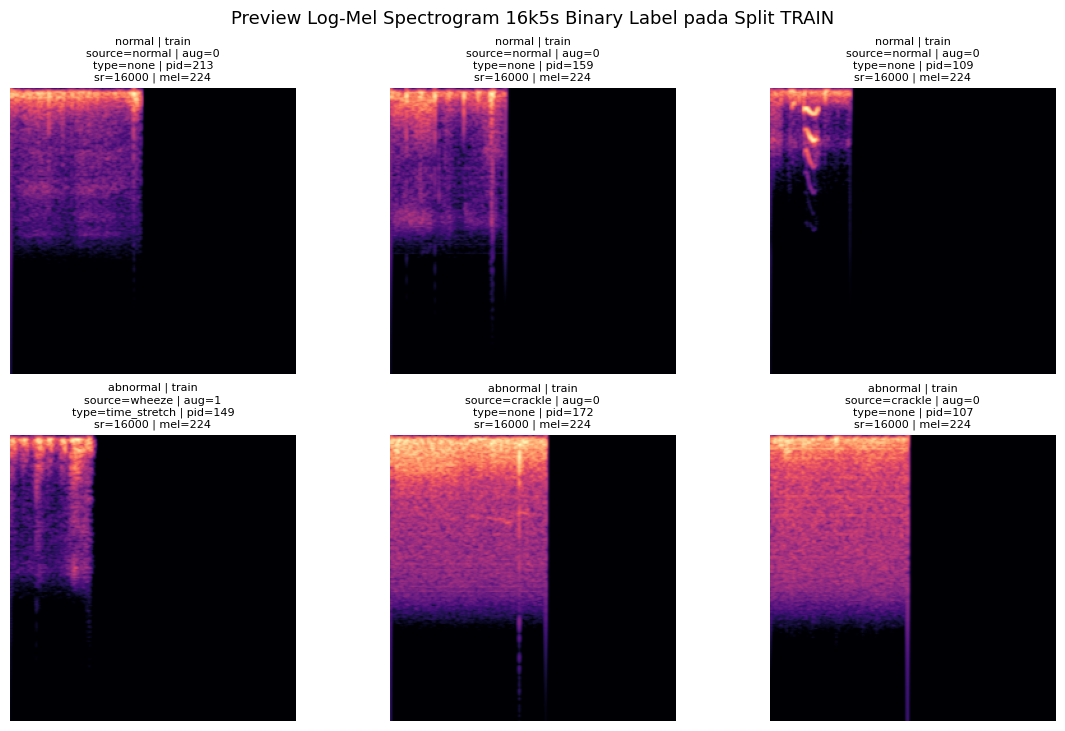

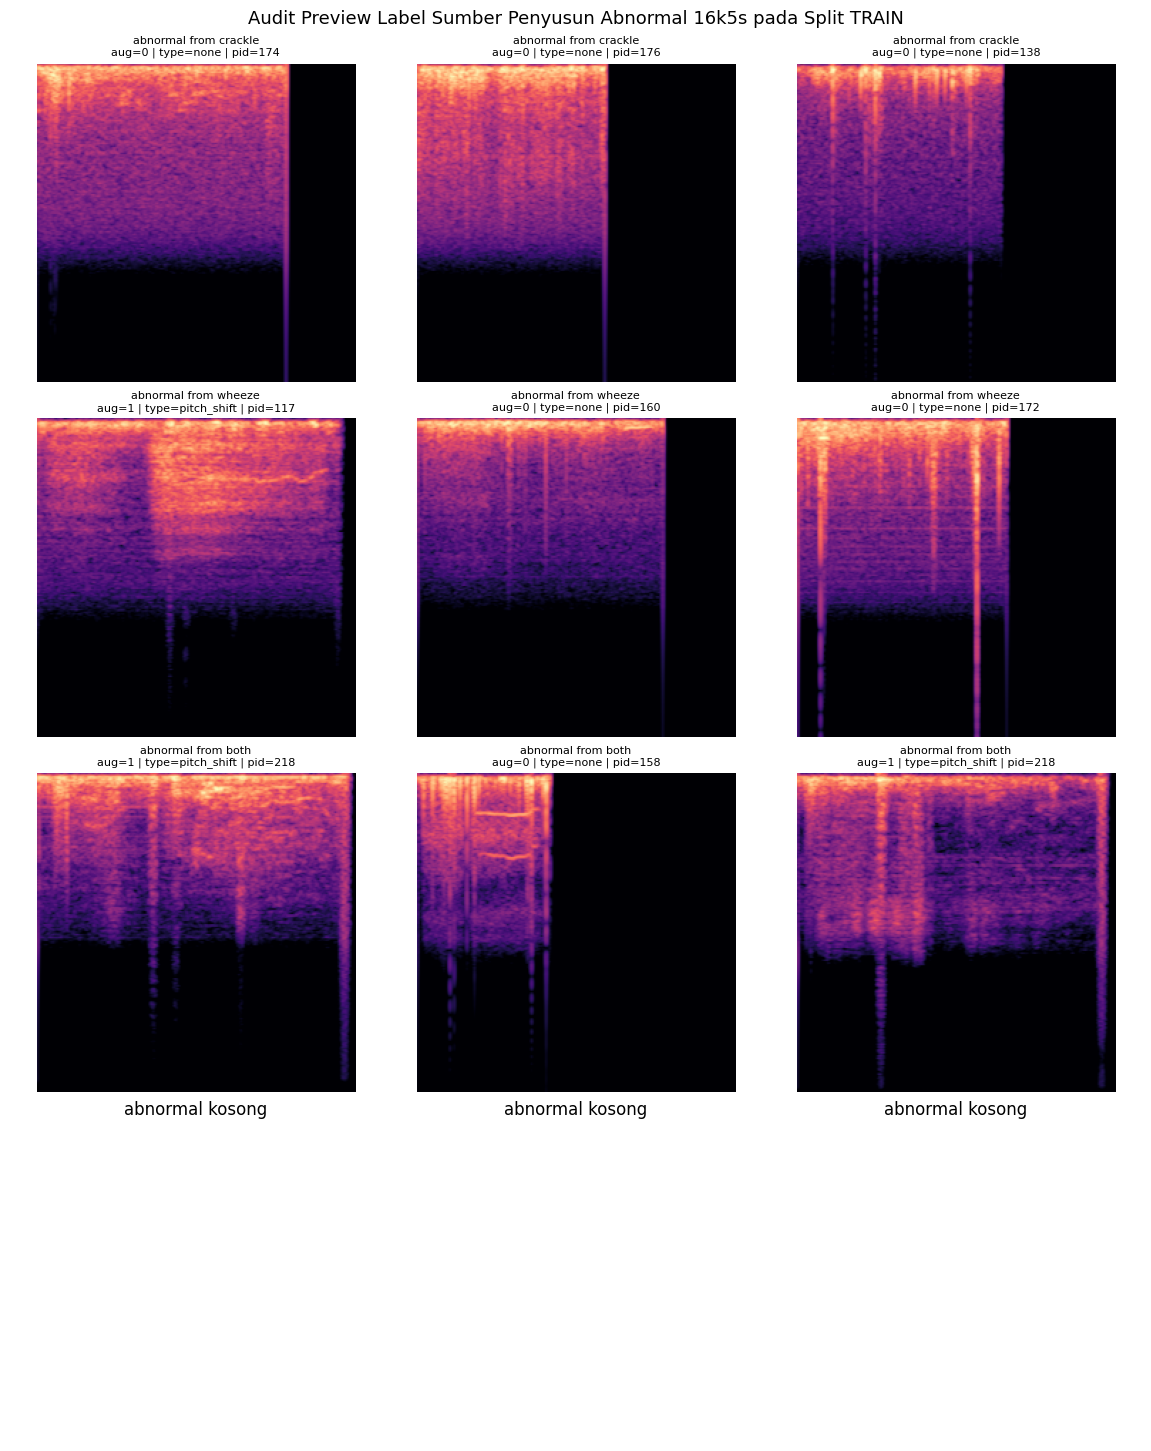

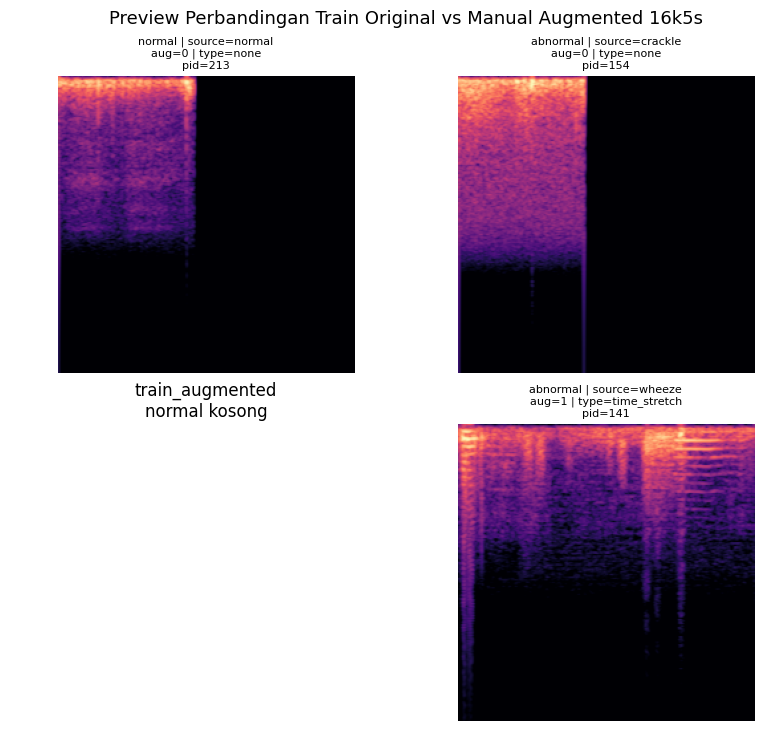

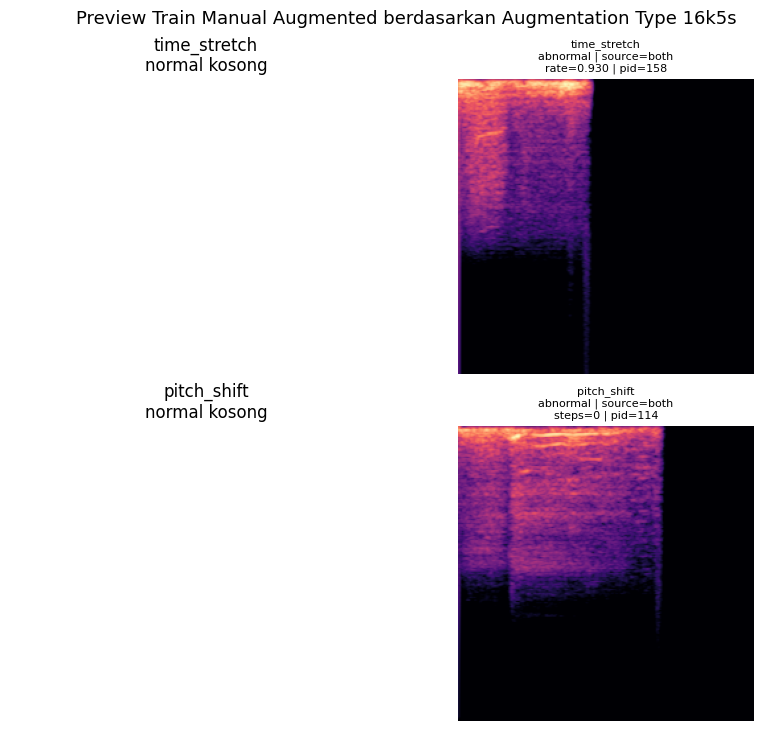


Contoh metadata image 16k5s:


,image_path,split,binary_label,sound,sound_4class,patient_id,is_augmented,augmentation_group,aug_type,time_stretch_rate,pitch_shift_steps,image_sr,image_n_fft,image_hop_length,image_n_mels,image_fmax,image_target_width,image_target_height
0,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224
1,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224
2,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224
3,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224
4,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224
5,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224
6,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224
7,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224
8,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224
9,paper_binary_16k_outputs/05_logmel_images_16k5...,train,normal,normal,normal,101,0,original,none,NaN,NaN,16000,2048,128,224,8000,224,224



[OK] Preview citra Log-Mel 16k5s selesai.


In [14]:
# ============================================================
# CELL: PREVIEW CITRA LOG-MEL SPECTROGRAM 16k5s
# Versi binary normal-abnormal
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# 0. KONFIGURASI
# ============================================================

# Paksa path 16k5s.
# Jangan ambil dari globals lama karena bisa masih menunjuk ke metadata 44k.
META_OUT_DIR = Path("paper_binary_16k_outputs/06_metadata_images_16k5s")
META_IMG_PATH = META_OUT_DIR / "metadata_manual_binary_16k5s_images_magma.csv"

if not META_IMG_PATH.exists():
    raise FileNotFoundError(
        f"Metadata image 16k5s tidak ditemukan: {META_IMG_PATH}\n"
        "Jalankan cell Konversi Audio 16k5s ke Citra Log-Mel Spectrogram terlebih dahulu."
    )

SPLIT_TO_PREVIEW = "train"   # pilihan: "train", "val", "test"
N_PER_CLASS = 3
RANDOM_STATE = 42

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

BINARY_CLASSES = ["normal", "abnormal"]
SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
ABNORMAL_SOURCE_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

VALID_SPLITS = {"train", "val", "test"}
ALLOWED_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}

EXPECTED_IMAGE_N_FFT = 2048
EXPECTED_IMAGE_HOP_LENGTH = 128
EXPECTED_IMAGE_N_MELS = 224
EXPECTED_IMAGE_FMAX = 8000
EXPECTED_IMAGE_SIZE = 224


# ============================================================
# 1. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def normalize_image_metadata(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    required_cols = [
        "image_path",
        "split",
        "binary_label"
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise AssertionError(
            f"Metadata image 16k5s tidak memiliki kolom wajib: {missing_cols}"
        )

    df["image_path"] = df["image_path"].astype(str).str.strip()
    df["split"] = df["split"].astype(str).str.strip().str.lower()
    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    if "sound" not in df.columns:
        if "sound_4class" in df.columns:
            df["sound"] = df["sound_4class"]
        else:
            df["sound"] = df["binary_label"]

    df["sound"] = df["sound"].astype(str).str.strip().str.lower()

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df["sound"]

    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0

    df["is_augmented"] = (
        pd.to_numeric(df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = np.where(
            df["is_augmented"] == 1,
            "manual_aug",
            "original"
        )

    df["augmentation_group"] = (
        df["augmentation_group"]
        .fillna("original")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"

    df["aug_type"] = (
        df["aug_type"]
        .fillna("none")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    if "image_ok" in df.columns:
        df["image_ok"] = (
            pd.to_numeric(df["image_ok"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    return df


def validate_basic_labels(df):
    unknown_split = sorted(set(df["split"].unique()) - VALID_SPLITS)

    if unknown_split:
        raise AssertionError(f"Split tidak valid ditemukan: {unknown_split}")

    unknown_binary = sorted(set(df["binary_label"].unique()) - set(BINARY_CLASSES))

    if unknown_binary:
        raise AssertionError(f"Binary label tidak valid ditemukan: {unknown_binary}")

    unknown_source = sorted(set(df["sound"].unique()) - set(SOURCE_CLASSES))

    if unknown_source:
        raise AssertionError(f"Label sumber sound tidak valid ditemukan: {unknown_source}")

    unknown_aug = sorted(set(df["aug_type"].unique()) - ALLOWED_AUG_TYPES)

    if unknown_aug:
        raise AssertionError(
            f"aug_type tidak valid ditemukan: {unknown_aug}. "
            "Untuk skenario ini hanya boleh none, time_stretch, dan pitch_shift."
        )


def check_optional_image_params(df_split):
    print("\nValidasi parameter image 16k5s jika tersedia:")

    if "image_sr" in df_split.columns:
        print("\nDistribusi image_sr:")
        print(df_split["image_sr"].value_counts(dropna=False).sort_index())

        bad_sr = df_split[
            pd.to_numeric(df_split["image_sr"], errors="coerce")
            .fillna(-1)
            .astype(int) != TARGET_SR
        ]

        if len(bad_sr) > 0:
            raise AssertionError(
                f"Ada {len(bad_sr)} image dengan image_sr bukan {TARGET_SR}."
            )

    if "image_expected_len_samples" in df_split.columns:
        print("\nDistribusi image_expected_len_samples:")
        print(df_split["image_expected_len_samples"].value_counts(dropna=False).sort_index())

        bad_len = df_split[
            pd.to_numeric(df_split["image_expected_len_samples"], errors="coerce")
            .fillna(-1)
            .astype(int) != TARGET_LEN_SAMPLES
        ]

        if len(bad_len) > 0:
            raise AssertionError(
                f"Ada {len(bad_len)} image dengan expected_len bukan {TARGET_LEN_SAMPLES}."
            )

    if "image_n_fft" in df_split.columns:
        print("\nDistribusi image_n_fft:")
        print(df_split["image_n_fft"].value_counts(dropna=False).sort_index())

    if "image_hop_length" in df_split.columns:
        print("\nDistribusi image_hop_length:")
        print(df_split["image_hop_length"].value_counts(dropna=False).sort_index())

    if "image_n_mels" in df_split.columns:
        print("\nDistribusi image_n_mels:")
        print(df_split["image_n_mels"].value_counts(dropna=False).sort_index())

    if "image_fmax" in df_split.columns:
        print("\nDistribusi image_fmax:")
        print(df_split["image_fmax"].value_counts(dropna=False).sort_index())

    if "image_target_width" in df_split.columns:
        print("\nDistribusi image_target_width:")
        print(df_split["image_target_width"].value_counts(dropna=False).sort_index())

    if "image_target_height" in df_split.columns:
        print("\nDistribusi image_target_height:")
        print(df_split["image_target_height"].value_counts(dropna=False).sort_index())


def load_rgb_image(path):
    return Image.open(path).convert("RGB")


def build_title(row, split_name, binary_cls=None, compact=False):
    if binary_cls is None:
        binary_cls = row["binary_label"]

    pid = row["patient_id"] if "patient_id" in row.index and pd.notna(row["patient_id"]) else "NA"
    source_label = row["sound"] if "sound" in row.index else "NA"

    is_aug = 0
    if "is_augmented" in row.index and pd.notna(row["is_augmented"]):
        is_aug = int(row["is_augmented"])

    aug_type = "none"
    if "aug_type" in row.index and pd.notna(row["aug_type"]):
        aug_type = str(row["aug_type"])

    image_sr = "NA"
    if "image_sr" in row.index and pd.notna(row["image_sr"]):
        image_sr = int(row["image_sr"])

    n_mels = "NA"
    if "image_n_mels" in row.index and pd.notna(row["image_n_mels"]):
        n_mels = int(row["image_n_mels"])

    if compact:
        return (
            f"{binary_cls} | source={source_label}\n"
            f"aug={is_aug} | type={aug_type}\n"
            f"pid={pid}"
        )

    return (
        f"{binary_cls} | {split_name}\n"
        f"source={source_label} | aug={is_aug}\n"
        f"type={aug_type} | pid={pid}\n"
        f"sr={image_sr} | mel={n_mels}"
    )


# ============================================================
# 2. LOAD METADATA IMAGE
# ============================================================

df = pd.read_csv(META_IMG_PATH).copy()
df = normalize_image_metadata(df)
validate_basic_labels(df)

if "image_ok" in df.columns:
    df = df[df["image_ok"] == 1].copy()

df = df[df["image_path"].notna()].copy()
df = df[df["image_path"].astype(str).str.len() > 0].copy()

df["image_exists"] = df["image_path"].apply(lambda p: os.path.exists(str(p)))

missing_images = int((~df["image_exists"]).sum())

if missing_images > 0:
    print(f"[WARNING] Ada {missing_images} file image yang tidak ditemukan.")
    print("Contoh file hilang:")
    print(df.loc[~df["image_exists"], "image_path"].head(10).to_string(index=False))

df = df[df["image_exists"]].copy().reset_index(drop=True)

df_split = df[df["split"] == SPLIT_TO_PREVIEW].copy().reset_index(drop=True)

if len(df_split) == 0:
    raise RuntimeError(
        f"Tidak ada image valid untuk split: {SPLIT_TO_PREVIEW}"
    )


# ============================================================
# 3. RINGKASAN METADATA
# ============================================================

print("=" * 90)
print("PREVIEW CITRA LOG-MEL SPECTROGRAM 16k5s")
print("=" * 90)
print("Metadata        :", META_IMG_PATH)
print("Split preview   :", SPLIT_TO_PREVIEW)
print("Total image OK  :", len(df))
print("Image OK split  :", len(df_split))
print("Target SR       :", TARGET_SR)
print("Target durasi   :", TARGET_DURATION_SEC)
print("Target samples  :", TARGET_LEN_SAMPLES)

check_optional_image_params(df_split)

print("\nDistribusi binary label pada split preview:")
binary_counts = (
    df_split["binary_label"]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
)
print(binary_counts)

print("\nAudit distribusi label sumber pada split preview:")
source_counts = (
    df_split["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
)
print(source_counts)

print("\nDistribusi original vs augmented:")
print(df_split["is_augmented"].value_counts(dropna=False).sort_index())

print("\nDistribusi augmentation_group:")
print(df_split["augmentation_group"].value_counts(dropna=False))

print("\nDistribusi aug_type:")
print(df_split["aug_type"].value_counts(dropna=False))


# ============================================================
# 4. PREVIEW UTAMA BERDASARKAN BINARY_LABEL
# 1 baris = 1 kelas binary
# ============================================================

rows = len(BINARY_CLASSES)
cols = N_PER_CLASS

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(3.8 * cols, 3.6 * rows),
    constrained_layout=True
)

if rows == 1 and cols == 1:
    axes = np.array([[axes]])
elif rows == 1:
    axes = np.expand_dims(axes, axis=0)
elif cols == 1:
    axes = np.expand_dims(axes, axis=1)

for r, binary_cls in enumerate(BINARY_CLASSES):
    df_cls = df_split[df_split["binary_label"] == binary_cls].copy()

    if len(df_cls) == 0:
        for c in range(cols):
            ax = axes[r, c]
            ax.axis("off")
            ax.set_title(f"{binary_cls} kosong")
        continue

    samp = df_cls.sample(
        n=min(cols, len(df_cls)),
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    for c in range(cols):
        ax = axes[r, c]
        ax.axis("off")

        if c >= len(samp):
            ax.set_title(binary_cls)
            continue

        row = samp.iloc[c]
        img_path = str(row["image_path"])

        if not os.path.exists(img_path):
            ax.set_title(f"{binary_cls}\nfile hilang")
            continue

        img = load_rgb_image(img_path)
        ax.imshow(img)

        title = build_title(
            row=row,
            split_name=SPLIT_TO_PREVIEW,
            binary_cls=binary_cls,
            compact=False
        )

        ax.set_title(title, fontsize=8)

plt.suptitle(
    f"Preview Log-Mel Spectrogram 16k5s Binary Label pada Split {SPLIT_TO_PREVIEW.upper()}",
    fontsize=13
)

plt.show()


# ============================================================
# 5. PREVIEW AUDIT LABEL SUMBER PADA KELAS ABNORMAL
# ============================================================

df_abnormal = df_split[df_split["binary_label"] == "abnormal"].copy()

if len(df_abnormal) > 0:
    rows = len(ABNORMAL_SOURCE_CLASSES)
    cols = N_PER_CLASS

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(3.8 * cols, 3.6 * rows),
        constrained_layout=True
    )

    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.expand_dims(axes, axis=0)
    elif cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for r, source_cls in enumerate(ABNORMAL_SOURCE_CLASSES):
        df_src = df_abnormal[df_abnormal["sound"] == source_cls].copy()

        if len(df_src) == 0:
            for c in range(cols):
                ax = axes[r, c]
                ax.axis("off")
                ax.set_title(f"{source_cls} kosong")
            continue

        samp = df_src.sample(
            n=min(cols, len(df_src)),
            random_state=RANDOM_STATE
        ).reset_index(drop=True)

        for c in range(cols):
            ax = axes[r, c]
            ax.axis("off")

            if c >= len(samp):
                ax.set_title(source_cls)
                continue

            row = samp.iloc[c]
            img_path = str(row["image_path"])

            if not os.path.exists(img_path):
                ax.set_title(f"{source_cls}\nfile hilang")
                continue

            img = load_rgb_image(img_path)
            ax.imshow(img)

            pid = row["patient_id"] if "patient_id" in row.index and pd.notna(row["patient_id"]) else "NA"

            is_aug = 0
            if "is_augmented" in row.index and pd.notna(row["is_augmented"]):
                is_aug = int(row["is_augmented"])

            aug_type = "none"
            if "aug_type" in row.index and pd.notna(row["aug_type"]):
                aug_type = str(row["aug_type"])

            title = (
                f"abnormal from {source_cls}\n"
                f"aug={is_aug} | type={aug_type} | pid={pid}"
            )

            ax.set_title(title, fontsize=8)

    plt.suptitle(
        f"Audit Preview Label Sumber Penyusun Abnormal 16k5s pada Split {SPLIT_TO_PREVIEW.upper()}",
        fontsize=13
    )

    plt.show()

else:
    print("\nTidak ada data abnormal pada split ini untuk audit preview.")


# ============================================================
# 6. PREVIEW KHUSUS TRAIN ORIGINAL VS AUGMENTED
# ============================================================

if SPLIT_TO_PREVIEW == "train":
    preview_groups = [
        ("train_original", df_split[df_split["is_augmented"] == 0].copy()),
        ("train_augmented", df_split[df_split["is_augmented"] == 1].copy()),
    ]

    rows = len(preview_groups)
    cols = len(BINARY_CLASSES)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4.0 * cols, 3.6 * rows),
        constrained_layout=True
    )

    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.expand_dims(axes, axis=0)
    elif cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for r, (group_name, group_df) in enumerate(preview_groups):
        for c, binary_cls in enumerate(BINARY_CLASSES):
            ax = axes[r, c]
            ax.axis("off")

            df_cell = group_df[group_df["binary_label"] == binary_cls].copy()

            if len(df_cell) == 0:
                ax.set_title(f"{group_name}\n{binary_cls} kosong")
                continue

            row = df_cell.sample(n=1, random_state=RANDOM_STATE).iloc[0]
            img_path = str(row["image_path"])

            if not os.path.exists(img_path):
                ax.set_title(f"{group_name}\n{binary_cls} file hilang")
                continue

            img = load_rgb_image(img_path)
            ax.imshow(img)

            ax.set_title(
                build_title(
                    row=row,
                    split_name=SPLIT_TO_PREVIEW,
                    binary_cls=binary_cls,
                    compact=True
                ),
                fontsize=8
            )

    plt.suptitle(
        "Preview Perbandingan Train Original vs Manual Augmented 16k5s",
        fontsize=13
    )

    plt.show()


# ============================================================
# 7. PREVIEW KHUSUS AUG_TYPE PADA TRAIN
# ============================================================

if SPLIT_TO_PREVIEW == "train" and (df_split["is_augmented"] == 1).any():
    df_aug = df_split[df_split["is_augmented"] == 1].copy()

    aug_types_present = [
        aug_type for aug_type in ["time_stretch", "pitch_shift"]
        if aug_type in set(df_aug["aug_type"])
    ]

    if len(aug_types_present) > 0:
        rows = len(aug_types_present)
        cols = len(BINARY_CLASSES)

        fig, axes = plt.subplots(
            rows,
            cols,
            figsize=(4.0 * cols, 3.6 * rows),
            constrained_layout=True
        )

        if rows == 1 and cols == 1:
            axes = np.array([[axes]])
        elif rows == 1:
            axes = np.expand_dims(axes, axis=0)
        elif cols == 1:
            axes = np.expand_dims(axes, axis=1)

        for r, aug_type in enumerate(aug_types_present):
            for c, binary_cls in enumerate(BINARY_CLASSES):
                ax = axes[r, c]
                ax.axis("off")

                df_cell = df_aug[
                    (df_aug["aug_type"] == aug_type) &
                    (df_aug["binary_label"] == binary_cls)
                ].copy()

                if len(df_cell) == 0:
                    ax.set_title(f"{aug_type}\n{binary_cls} kosong")
                    continue

                row = df_cell.sample(n=1, random_state=RANDOM_STATE).iloc[0]
                img_path = str(row["image_path"])

                if not os.path.exists(img_path):
                    ax.set_title(f"{aug_type}\n{binary_cls} file hilang")
                    continue

                img = load_rgb_image(img_path)
                ax.imshow(img)

                source_label = row["sound"] if "sound" in row.index else "NA"
                pid = row["patient_id"] if "patient_id" in row.index and pd.notna(row["patient_id"]) else "NA"

                extra = ""

                if aug_type == "time_stretch" and "time_stretch_rate" in row.index:
                    if pd.notna(row["time_stretch_rate"]):
                        extra = f"rate={float(row['time_stretch_rate']):.3f}"

                if aug_type == "pitch_shift" and "pitch_shift_steps" in row.index:
                    if pd.notna(row["pitch_shift_steps"]):
                        extra = f"steps={int(row['pitch_shift_steps'])}"

                ax.set_title(
                    f"{aug_type}\n{binary_cls} | source={source_label}\n"
                    f"{extra} | pid={pid}",
                    fontsize=8
                )

        plt.suptitle(
            "Preview Train Manual Augmented berdasarkan Augmentation Type 16k5s",
            fontsize=13
        )

        plt.show()


# ============================================================
# 8. TABEL CONTOH METADATA YANG DIPREVIEW
# ============================================================

preview_cols = [
    "image_path",
    "split",
    "binary_label",
    "sound",
    "sound_4class",
    "patient_id",
    "is_augmented",
    "augmentation_group",
    "aug_type",
    "time_stretch_rate",
    "pitch_shift_steps",
    "image_sr",
    "image_n_fft",
    "image_hop_length",
    "image_n_mels",
    "image_fmax",
    "image_target_width",
    "image_target_height",
]

preview_cols = [c for c in preview_cols if c in df_split.columns]

print("\nContoh metadata image 16k5s:")
safe_display(df_split[preview_cols].head(10))


# ============================================================
# 9. SIMPAN KE GLOBALS
# ============================================================

globals()["META_IMG_PATH"] = str(META_IMG_PATH)
globals()["preview_logmel_image_df_16k5s"] = df_split

print("\n[OK] Preview citra Log-Mel 16k5s selesai.")

# **Setup import HyperParameter**

In [ ]:
# ============================================================
# CELL 25: GLOBAL CONFIG DAN HYPERPARAMETER
# ViT-B/16 + Time-Frequency Attention Pooling
# Binary Normal-Abnormal ICBHI 2017
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch

# ============================================================
# 0. BERSIHKAN GLOBAL LAMA DARI SKENARIO SEBELUMNYA
# ============================================================

stale_keys = [
    # BiLSTM
    "BILSTM_INPUT_DIM",
    "BILSTM_HIDDEN_SIZE",
    "BILSTM_NUM_LAYERS",
    "BILSTM_BIDIRECTIONAL",
    "BILSTM_DROPOUT",
    "BILSTM_POOLING",
    "BILSTM_OUTPUT_DIM",
    "ViTBiLSTMClassifier",

    # Temporal Attention lama
    "TEMP_ATTN_INPUT_DIM",
    "TEMP_ATTN_HIDDEN_DIM",
    "TEMP_ATTN_DROPOUT",
    "TEMP_ATTN_POOLING",
    "TEMP_ATTN_NUM_TOKENS",
    "TEMP_ATTN_ACTIVATION",
    "TemporalAttentionPooling",
    "ViTTemporalAttentionClassifier",

    # Time-Frequency Attention lama
    "TimeFrequencyAttentionPooling",
    "ViTTimeFrequencyAttentionClassifier",

    # Runtime object lama
    "model",
    "criterion",
    "optimizer",
    "scheduler",
    "scaler",
    "history",
    "hist_df",
    "best_metrics",
    "best_epoch",

    # Loss / weight lama
    "CLASS_WEIGHTS_TENSOR",
    "CLASS_WEIGHTS_LIST",
    "CLASS_WEIGHTS_USED_DICT",
    "MANUAL_CLASS_WEIGHTS",
    "AUTO_CLASS_WEIGHTS",
    "class_weight_audit_df",
    "weight_tensor",
    "weight_tensor_for_loss",
]

for key in stale_keys:
    if key in globals():
        globals().pop(key)


# ============================================================
# 1. PATH METADATA CITRA LOG-MEL 16k5s
# ============================================================

META_CSV = (
    "paper_binary_16k_outputs/"
    "06_metadata_images_16k5s/"
    "metadata_manual_binary_16k5s_images_magma.csv"
)

if not os.path.exists(META_CSV):
    raise FileNotFoundError(
        f"Metadata image 16k5s tidak ditemukan: {META_CSV}\n"
        "Jalankan cell Konversi Audio 16k5s ke Log-Mel Image terlebih dahulu."
    )


# ============================================================
# 2. IDENTITAS SKENARIO
# ============================================================
SCENARIO_NAME = (
    "vit_time_frequency_attention_binary_sr16k5s_logmel224_"
    "wce080120_full12_llrd085_nowarmup_nospecaug_"
    "bb5e6_head7e5_"
    "ls000_do020_tfap256_tfapdo010_"
    "sensharmconstr_sp050_ckpt_"
    "cosine_wd1e4_"
    "thr050"
)

SAVE_DIR = Path("checkpoints_vit_time_frequency_attention") / SCENARIO_NAME
RESULT_DIR = Path("results_vit_time_frequency_attention") / SCENARIO_NAME

SAVE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = SAVE_DIR / f"{SCENARIO_NAME}_best_valsensitivity.pth"
LAST_MODEL_PATH = SAVE_DIR / f"{SCENARIO_NAME}_last.pth"
HISTORY_CSV_PATH = SAVE_DIR / f"{SCENARIO_NAME}_history.csv"
LEARNING_CURVE_PATH = SAVE_DIR / f"{SCENARIO_NAME}_learning_curve.png"
RUN_CONFIG_PATH = SAVE_DIR / f"{SCENARIO_NAME}_run_config.csv"


# ============================================================
# 3. LABEL
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

CLASSES = ["normal", "abnormal"]
BINARY_CLASSES = CLASSES

label2id = {
    "normal": 0,
    "abnormal": 1,
}

id2label = {
    0: "normal",
    1: "abnormal",
}

NUM_CLASSES = len(CLASSES)

LABEL_COL = "binary_label"

POS_LABEL = "abnormal"
NEG_LABEL = "normal"

POS_LABEL_ID = label2id[POS_LABEL]
NEG_LABEL_ID = label2id[NEG_LABEL]


# ============================================================
# 4. KONFIGURASI PREPROCESSING DAN LOG-MEL 16k5s
# ============================================================

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

N_MELS = 224

# Dipertahankan sesuai metadata/citra yang sudah dibuat.
# Mengubah FMIN/FMAX berarti wajib konversi ulang citra.
FMIN = 0
FMAX = 8000

N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048

IMAGE_SIZE = 224
IMAGE_COLORMAP = "magma"
IMAGE_MODE = "rgb"

PREPROCESSING_PIPELINE = (
    "vit_time_frequency_attention_"
    "resample_16khz_bandpass_50_2000hz_rms_norm_minus15dbfs_"
    "sequential_5s_chunking_logmel_magma_224_f0_8000"
)


# ============================================================
# 5. IDENTITAS MODEL
# ============================================================

MODEL_FAMILY = "ViT-TimeFrequencyAttention"
MODEL_NAME = "ViT-B/16 + Time-Frequency Attention Pooling"

MODEL_CLAIM = (
    "Hybrid ViT-B/16 and Time-Frequency Attention Pooling model using all "
    "patch-token representations from Log-Mel spectrogram images for binary "
    "normal-abnormal respiratory sound classification."
)

VIT_BACKBONE_NAME = "vit_b_16"
VIT_WEIGHTS_NAME = "IMAGENET1K_V1"
VIT_PATCH_SIZE = 16
VIT_IMAGE_SIZE = 224
VIT_PATCH_GRID_SIZE = VIT_IMAGE_SIZE // VIT_PATCH_SIZE
VIT_NUM_PATCHES = VIT_PATCH_GRID_SIZE * VIT_PATCH_GRID_SIZE
VIT_EMBED_DIM = 768

# Time-Frequency Attention membaca semua token patch ViT.
# Input token: [B, 196, 768].
TF_ATTN_INPUT_DIM = VIT_EMBED_DIM
TF_ATTN_HIDDEN_DIM = 256
TF_ATTN_DROPOUT = 0.10
TF_ATTN_POOLING = "mlp_attention"
TF_ATTN_NUM_PATCHES = VIT_NUM_PATCHES
TF_ATTN_ACTIVATION = "tanh"

CLASSIFIER_INPUT_DIM = TF_ATTN_INPUT_DIM


# ============================================================
# 6. HYPERPARAMETER TRAINING
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

AMP_ENABLED = True
BATCH_SIZE = 32
NUM_EPOCHS = 50

PATIENCE = 10
EARLY_STOP_MIN_DELTA = 1e-4

NUM_WORKERS = 0

# Full-layer ViT tetap digunakan.
UNFREEZE_LAST_N_BLOCKS = 12

OPTIMIZER_NAME = "AdamW"

LR_BACKBONE = 5e-6
LR_HEAD = 7e-5
LEARNING_RATE = LR_BACKBONE

WEIGHT_DECAY = 1e-4

USE_LAYER_WISE_LR_DECAY = True
LAYER_LR_DECAY = 0.85
LLRD_DECAY = LAYER_LR_DECAY

SCHEDULER_NAME = "CosineAnnealingLR"
WARMUP_EPOCHS = 0
ETA_MIN = 1e-7

HEAD_DROPOUT = 0.20
LABEL_SMOOTHING = 0.0

MAX_GRAD_NORM = 1.0


# ============================================================
# 7. LOSS DAN CLASS WEIGHT
# Sensitivity-oriented Weighted CE.
# Jangan ada blok LOSS_NAME lain setelah bagian ini.
# ============================================================

LOSS_NAME = "weighted_ce"

USE_CLASS_WEIGHT = True
MANUAL_CLASS_WEIGHT = True
CLASS_WEIGHT_METHOD = "manual"
CLASS_WEIGHT_METHOD_EFFECTIVE = "manual"

NORMAL_WEIGHT = 0.82
ABNORMAL_WEIGHT = 1.18

MANUAL_CLASS_WEIGHTS = {
    "normal": float(NORMAL_WEIGHT),
    "abnormal": float(ABNORMAL_WEIGHT),
}

CLASS_WEIGHTS_USED_DICT = MANUAL_CLASS_WEIGHTS.copy()

CLASS_WEIGHTS_LIST = [
    float(CLASS_WEIGHTS_USED_DICT["normal"]),
    float(CLASS_WEIGHTS_USED_DICT["abnormal"]),
]

CLASS_WEIGHTS_TENSOR = torch.tensor(
    CLASS_WEIGHTS_LIST,
    dtype=torch.float32,
    device=DEVICE,
)

# Focal tidak digunakan pada run ini.
FOCAL_ALPHA_NORMAL = 0.50
FOCAL_ALPHA_ABNORMAL = 0.50
FOCAL_GAMMA = 1.0

USE_WEIGHTED_RANDOM_SAMPLER = False
SAMPLER_SEED = 42
SHUFFLE_TRAIN = True

# ============================================================
# 8. SPEC AUGMENT CONFIG
# ============================================================

USE_SPEC_AUGMENT = False

SPEC_AUGMENT_P = 0.0
SPEC_TIME_MASK_MAX = 0
SPEC_FREQ_MASK_MAX = 0
SPEC_N_TIME_MASKS = 0
SPEC_N_FREQ_MASKS = 0


# ============================================================
# 9. CHECKPOINT, EARLY STOPPING, THRESHOLD
# ============================================================
CHECKPOINT_MONITOR = "val_sens_harmonic_constrained_score"
EARLY_STOPPING_MONITOR = "val_sens_harmonic_constrained_score"
CHECKPOINT_MODE = "max"

SAVE_BEST_BY = "maximum_validation_sensitivity_harmonic_constrained_score"
VALIDATE_EVERY_EPOCH = True

# Variabel ini tetap disimpan untuk kompatibilitas dengan Cell 37,
# tetapi monitor utama run ini adalah val_sensitivity_abnormal.
SENS_HARMONIC_SENS_WEIGHT = 0.88
SENS_HARMONIC_HARM_WEIGHT = 0.12

FINAL_SCORE_SENS_WEIGHT = 0.82
FINAL_SCORE_HARM_WEIGHT = 0.18

if abs(FINAL_SCORE_SENS_WEIGHT + FINAL_SCORE_HARM_WEIGHT - 1.0) > 1e-8:
    raise AssertionError(
        "FINAL_SCORE_SENS_WEIGHT + FINAL_SCORE_HARM_WEIGHT harus 1.0."
    )

MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT = 0.52
MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD = 0.50
MIN_SP_FINAL = 0.50
SPECIFICITY_SAFE_MIN = 0.50

DEFAULT_TEST_THRESHOLD = 0.50

ENABLE_THRESHOLD_TUNING = False
PRIMARY_OPERATING_POINT = "fixed_threshold_0_50"

THRESHOLD_SELECTION_METRIC = "none"
THRESHOLD_MIN = 0.50
THRESHOLD_MAX = 0.50
THRESHOLD_STEP = 0.0

TARGET_SENSITIVITY_ABNORMAL = 0.80


# ============================================================
# 10. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def normalize_metadata_for_config(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    required_min_cols = ["image_path", "split", LABEL_COL]
    missing_min_cols = [c for c in required_min_cols if c not in df.columns]

    if missing_min_cols:
        raise ValueError(f"Metadata image kehilangan kolom wajib: {missing_min_cols}")

    if "sound" not in df.columns:
        if "sound_4class" in df.columns:
            df["sound"] = df["sound_4class"]
        else:
            df["sound"] = df[LABEL_COL]

    df["image_path"] = df["image_path"].astype(str).str.strip()
    df["split"] = df["split"].astype(str).str.strip().str.lower()
    df["sound"] = df["sound"].astype(str).str.strip().str.lower()
    df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df["sound"]
    else:
        df["sound_4class"] = (
            df["sound_4class"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "image_ok" not in df.columns:
        df["image_ok"] = 1
    else:
        df["image_ok"] = (
            pd.to_numeric(df["image_ok"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0
    else:
        df["is_augmented"] = (
            pd.to_numeric(df["is_augmented"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = np.where(
            df["is_augmented"] == 1,
            "manual_aug",
            "original",
        )
    else:
        df["augmentation_group"] = (
            df["augmentation_group"]
            .fillna("original")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"
    else:
        df["aug_type"] = (
            df["aug_type"]
            .fillna("none")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    return df


# ============================================================
# 11. VALIDASI METADATA RINGKAS
# ============================================================

df_check = pd.read_csv(META_CSV, low_memory=False).copy()
df_check = normalize_metadata_for_config(df_check)

required_cols = [
    "image_path",
    "split",
    "sound",
    LABEL_COL,
    "image_ok",
]

missing_cols = [c for c in required_cols if c not in df_check.columns]

if missing_cols:
    raise ValueError(f"Metadata image kehilangan kolom wajib: {missing_cols}")

df_check = df_check[df_check["image_ok"] == 1].copy().reset_index(drop=True)

if len(df_check) == 0:
    raise RuntimeError("Metadata image kosong setelah filter image_ok == 1.")

unknown_source_labels = sorted(set(df_check["sound"].unique()) - set(SOURCE_CLASSES))
if unknown_source_labels:
    raise ValueError(
        f"Ada label sumber tidak valid pada metadata: {unknown_source_labels}"
    )

unknown_binary_labels = sorted(set(df_check[LABEL_COL].unique()) - set(CLASSES))
if unknown_binary_labels:
    raise ValueError(
        f"Ada binary_label tidak valid pada metadata: {unknown_binary_labels}"
    )

valid_splits = {"train", "val", "test"}
unknown_splits = sorted(set(df_check["split"].unique()) - valid_splits)

if unknown_splits:
    raise ValueError(f"Ada split tidak valid pada metadata: {unknown_splits}")

expected_binary = df_check["sound"].apply(to_binary_label)
mismatch_mask = expected_binary != df_check[LABEL_COL]

if mismatch_mask.any():
    safe_display(
        df_check.loc[
            mismatch_mask,
            ["image_path", "split", "sound", LABEL_COL],
        ].head(10)
    )
    raise ValueError(
        f"Ada {int(mismatch_mask.sum())} baris binary_label tidak konsisten dengan sound."
    )

df_check["image_exists"] = df_check["image_path"].astype(str).apply(os.path.exists)
missing_images = int((~df_check["image_exists"]).sum())

if missing_images > 0:
    print(f"[WARNING] Ada {missing_images} image_path yang tidak ditemukan.")
    print(
        df_check.loc[~df_check["image_exists"], "image_path"]
        .head(10)
        .to_string(index=False)
    )
    raise FileNotFoundError(f"Ada {missing_images} file citra yang tidak ditemukan.")


# ============================================================
# 12. VALIDASI PARAMETER IMAGE JIKA ADA
# ============================================================

numeric_expected = {
    "image_sr": TARGET_SR,
    "image_expected_len_samples": TARGET_LEN_SAMPLES,
    "image_n_mels": N_MELS,
    "image_n_fft": N_FFT,
    "image_hop_length": HOP_LENGTH,
    "image_win_length": WIN_LENGTH,
    "image_fmax": FMAX,
    "image_target_width": IMAGE_SIZE,
    "image_target_height": IMAGE_SIZE,
}

for col, expected_value in numeric_expected.items():
    if col in df_check.columns:
        values = pd.to_numeric(df_check[col], errors="coerce")
        bad_mask = values.fillna(-999999).astype(float) != float(expected_value)

        if bad_mask.any():
            safe_display(
                df_check.loc[
                    bad_mask,
                    ["image_path", "split", "sound", LABEL_COL, col],
                ].head(10)
            )
            raise AssertionError(
                f"Ada {int(bad_mask.sum())} baris dengan {col} bukan {expected_value}."
            )

if "image_fmin" in df_check.columns:
    values = pd.to_numeric(df_check["image_fmin"], errors="coerce")
    bad_mask = values.fillna(-999999).astype(float) != float(FMIN)

    if bad_mask.any():
        raise AssertionError(
            f"Ada {int(bad_mask.sum())} baris dengan image_fmin bukan {FMIN}."
        )

if "image_expected_sec" in df_check.columns:
    values = pd.to_numeric(df_check["image_expected_sec"], errors="coerce")
    bad_mask = np.abs(values.fillna(-999999) - TARGET_DURATION_SEC) > 1e-6

    if bad_mask.any():
        raise AssertionError(
            f"Ada {int(bad_mask.sum())} baris dengan image_expected_sec bukan "
            f"{TARGET_DURATION_SEC}."
        )


# ============================================================
# 13. VALIDASI VAL/TEST TIDAK DIAUGMENTASI
# ============================================================

non_train_aug = df_check[
    (df_check["split"].isin(["val", "test"])) &
    (df_check["is_augmented"] != 0)
]

if len(non_train_aug) > 0:
    raise AssertionError(
        f"Ada {len(non_train_aug)} data val/test yang terdeteksi augmentasi. "
        "Val dan test tidak boleh diaugmentasi."
    )


# ============================================================
# 14. CLASS WEIGHT AUDIT
# ============================================================

train_check = df_check[df_check["split"] == "train"].copy()

if len(train_check) == 0:
    raise RuntimeError("Tidak ada data train pada metadata image 16k5s.")

train_class_counts = (
    train_check[LABEL_COL]
    .value_counts()
    .reindex(CLASSES, fill_value=0)
    .astype(int)
)

if (train_class_counts <= 0).any():
    raise ValueError(
        "Ada kelas training dengan jumlah 0.\n"
        f"Distribusi train: {train_class_counts.to_dict()}"
    )

total_train = int(train_class_counts.sum())

auto_class_weights_series = (
    total_train / (NUM_CLASSES * train_class_counts.astype(float))
)

AUTO_CLASS_WEIGHTS = {
    cls: float(auto_class_weights_series.loc[cls])
    for cls in CLASSES
}

class_weight_audit_df = pd.DataFrame({
    "class_id": [label2id[c] for c in CLASSES],
    "class_name": CLASSES,
    "n_train": [int(train_class_counts.loc[c]) for c in CLASSES],
    "train_ratio": [
        float(train_class_counts.loc[c] / total_train)
        for c in CLASSES
    ],
    "auto_balanced_weight": [
        float(AUTO_CLASS_WEIGHTS[c])
        for c in CLASSES
    ],
    "manual_weight_used": [
        float(CLASS_WEIGHTS_USED_DICT[c])
        for c in CLASSES
    ],
    "used_in_loss": [
        bool(USE_CLASS_WEIGHT)
        for _ in CLASSES
    ],
    "class_weight_method_effective": [
        CLASS_WEIGHT_METHOD_EFFECTIVE
        for _ in CLASSES
    ],
})


# ============================================================
# 15. DISTRIBUSI DATA UNTUK AUDIT
# ============================================================

split_dist_binary = (
    df_check
    .groupby(["split", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["train", "val", "test"], columns=CLASSES, fill_value=0)
)

split_dist_source = (
    df_check
    .groupby(["split", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["train", "val", "test"], columns=SOURCE_CLASSES, fill_value=0)
)

train_aug_dist = (
    df_check[df_check["split"] == "train"]
    .groupby(["augmentation_group", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=CLASSES, fill_value=0)
)

train_aug_type_dist = (
    df_check[df_check["split"] == "train"]
    .groupby(["aug_type", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CLASSES, fill_value=0)
)


# ============================================================
# 16. SIMPAN KONFIGURASI RUN
# ============================================================

run_config = {
    "meta_csv": META_CSV,
    "scenario_name": SCENARIO_NAME,

    "model_family": MODEL_FAMILY,
    "model_name": MODEL_NAME,
    "model_claim": MODEL_CLAIM,

    "vit_backbone_name": VIT_BACKBONE_NAME,
    "vit_weights_name": VIT_WEIGHTS_NAME,
    "vit_patch_size": VIT_PATCH_SIZE,
    "vit_image_size": VIT_IMAGE_SIZE,
    "vit_patch_grid_size": VIT_PATCH_GRID_SIZE,
    "vit_num_patches": VIT_NUM_PATCHES,
    "vit_embed_dim": VIT_EMBED_DIM,

    "tf_attn_input_dim": TF_ATTN_INPUT_DIM,
    "tf_attn_hidden_dim": TF_ATTN_HIDDEN_DIM,
    "tf_attn_dropout": TF_ATTN_DROPOUT,
    "tf_attn_pooling": TF_ATTN_POOLING,
    "tf_attn_num_patches": TF_ATTN_NUM_PATCHES,
    "tf_attn_activation": TF_ATTN_ACTIVATION,
    "classifier_input_dim": CLASSIFIER_INPUT_DIM,

    "preprocessing_pipeline": PREPROCESSING_PIPELINE,
    "target_sr": TARGET_SR,
    "target_duration_sec": TARGET_DURATION_SEC,
    "target_len_samples": TARGET_LEN_SAMPLES,

    "n_mels": N_MELS,
    "fmin": FMIN,
    "fmax": FMAX,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "win_length": WIN_LENGTH,
    "image_size": IMAGE_SIZE,
    "image_colormap": IMAGE_COLORMAP,
    "image_mode": IMAGE_MODE,

    "num_classes": NUM_CLASSES,
    "classes": ",".join(CLASSES),
    "label_col": LABEL_COL,
    "positive_label": POS_LABEL,
    "negative_label": NEG_LABEL,

    "optimizer": OPTIMIZER_NAME,
    "learning_rate": LEARNING_RATE,
    "lr_backbone": LR_BACKBONE,
    "lr_head": LR_HEAD,
    "weight_decay": WEIGHT_DECAY,

    "use_layer_wise_lr_decay": USE_LAYER_WISE_LR_DECAY,
    "layer_lr_decay": LAYER_LR_DECAY,

    "scheduler": SCHEDULER_NAME,
    "warmup_epochs": WARMUP_EPOCHS,
    "eta_min": ETA_MIN,

    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "patience": PATIENCE,
    "early_stop_min_delta": EARLY_STOP_MIN_DELTA,

    "unfreeze_last_n_blocks": UNFREEZE_LAST_N_BLOCKS,
    "head_dropout": HEAD_DROPOUT,
    "label_smoothing": LABEL_SMOOTHING,
    "max_grad_norm": MAX_GRAD_NORM,

    "loss_name": LOSS_NAME,
    "use_class_weight": USE_CLASS_WEIGHT,
    "manual_class_weight": MANUAL_CLASS_WEIGHT,
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_method_effective": CLASS_WEIGHT_METHOD_EFFECTIVE,
    "normal_weight": NORMAL_WEIGHT,
    "abnormal_weight": ABNORMAL_WEIGHT,
    "class_weights_used": str(CLASS_WEIGHTS_USED_DICT),
    "auto_class_weights_audit_only": str(AUTO_CLASS_WEIGHTS),

    "focal_alpha_normal": FOCAL_ALPHA_NORMAL,
    "focal_alpha_abnormal": FOCAL_ALPHA_ABNORMAL,
    "focal_gamma": FOCAL_GAMMA,

    "use_spec_augment": USE_SPEC_AUGMENT,
    "spec_augment_p": SPEC_AUGMENT_P,
    "spec_time_mask_max": SPEC_TIME_MASK_MAX,
    "spec_freq_mask_max": SPEC_FREQ_MASK_MAX,
    "spec_n_time_masks": SPEC_N_TIME_MASKS,
    "spec_n_freq_masks": SPEC_N_FREQ_MASKS,

    "shuffle_train": SHUFFLE_TRAIN,
    "use_weighted_random_sampler": USE_WEIGHTED_RANDOM_SAMPLER,
    "validate_every_epoch": VALIDATE_EVERY_EPOCH,

    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "checkpoint_monitor": CHECKPOINT_MONITOR,
    "checkpoint_mode": CHECKPOINT_MODE,
    "save_best_by": SAVE_BEST_BY,

    "sens_harmonic_sens_weight": SENS_HARMONIC_SENS_WEIGHT,
    "sens_harmonic_harm_weight": SENS_HARMONIC_HARM_WEIGHT,
    "final_score_sens_weight": FINAL_SCORE_SENS_WEIGHT,
    "final_score_harm_weight": FINAL_SCORE_HARM_WEIGHT,

    "default_test_threshold": DEFAULT_TEST_THRESHOLD,
    "enable_threshold_tuning": ENABLE_THRESHOLD_TUNING,
    "primary_operating_point": PRIMARY_OPERATING_POINT,
    "threshold_selection_metric": THRESHOLD_SELECTION_METRIC,
    "threshold_min": THRESHOLD_MIN,
    "threshold_max": THRESHOLD_MAX,
    "threshold_step": THRESHOLD_STEP,

    "target_sensitivity_abnormal": TARGET_SENSITIVITY_ABNORMAL,
    "min_specificity_normal_for_checkpoint": MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
    "min_specificity_normal_for_threshold": MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD,
    "min_sp_final": MIN_SP_FINAL,
    "specificity_safe_min": SPECIFICITY_SAFE_MIN,

    "best_model_path": str(BEST_MODEL_PATH),
    "last_model_path": str(LAST_MODEL_PATH),
    "history_csv_path": str(HISTORY_CSV_PATH),
    "learning_curve_path": str(LEARNING_CURVE_PATH),
}

run_config_df = pd.DataFrame([run_config])
run_config_df.to_csv(RUN_CONFIG_PATH, index=False)


# ============================================================
# 17. OUTPUT
# ============================================================

print("=" * 90)
print("GLOBAL CONFIG ViT-TIME-FREQUENCY ATTENTION BINARY NORMAL-ABNORMAL 16k5s")
print("=" * 90)

print("META_CSV                  :", META_CSV)
print("SCENARIO_NAME             :", SCENARIO_NAME)
print("MODEL_FAMILY              :", MODEL_FAMILY)
print("MODEL_NAME                :", MODEL_NAME)

print("\nPath:")
print("SAVE_DIR                  :", SAVE_DIR)
print("RESULT_DIR                :", RESULT_DIR)
print("BEST_MODEL_PATH           :", BEST_MODEL_PATH)
print("LAST_MODEL_PATH           :", LAST_MODEL_PATH)
print("HISTORY_CSV_PATH          :", HISTORY_CSV_PATH)
print("LEARNING_CURVE_PATH       :", LEARNING_CURVE_PATH)
print("RUN_CONFIG_PATH           :", RUN_CONFIG_PATH)

print("\nPreprocessing:")
print("TARGET_SR                 :", TARGET_SR)
print("TARGET_DURATION_SEC       :", TARGET_DURATION_SEC)
print("TARGET_LEN_SAMPLES        :", TARGET_LEN_SAMPLES)
print("N_MELS                    :", N_MELS)
print("FMIN                      :", FMIN)
print("FMAX                      :", FMAX)
print("N_FFT                     :", N_FFT)
print("HOP_LENGTH                :", HOP_LENGTH)
print("WIN_LENGTH                :", WIN_LENGTH)
print("IMAGE_SIZE                :", IMAGE_SIZE)

print("\nViT backbone:")
print("VIT_BACKBONE_NAME         :", VIT_BACKBONE_NAME)
print("VIT_WEIGHTS_NAME          :", VIT_WEIGHTS_NAME)
print("VIT_PATCH_SIZE            :", VIT_PATCH_SIZE)
print("VIT_PATCH_GRID_SIZE       :", VIT_PATCH_GRID_SIZE)
print("VIT_NUM_PATCHES           :", VIT_NUM_PATCHES)
print("VIT_EMBED_DIM             :", VIT_EMBED_DIM)

print("\nTime-Frequency Attention Pooling:")
print("TF_ATTN_INPUT_DIM         :", TF_ATTN_INPUT_DIM)
print("TF_ATTN_HIDDEN_DIM        :", TF_ATTN_HIDDEN_DIM)
print("TF_ATTN_DROPOUT           :", TF_ATTN_DROPOUT)
print("TF_ATTN_POOLING           :", TF_ATTN_POOLING)
print("TF_ATTN_NUM_PATCHES       :", TF_ATTN_NUM_PATCHES)
print("TF_ATTN_ACTIVATION        :", TF_ATTN_ACTIVATION)
print("CLASSIFIER_INPUT_DIM      :", CLASSIFIER_INPUT_DIM)

print("\nTraining:")
print("DEVICE                    :", DEVICE)
print("AMP_ENABLED               :", AMP_ENABLED)
print("BATCH_SIZE                :", BATCH_SIZE)
print("NUM_EPOCHS                :", NUM_EPOCHS)
print("PATIENCE                  :", PATIENCE)
print("UNFREEZE_LAST_N_BLOCKS    :", UNFREEZE_LAST_N_BLOCKS)
print("LEARNING_RATE             :", LEARNING_RATE)
print("LR_BACKBONE               :", LR_BACKBONE)
print("LR_HEAD                   :", LR_HEAD)
print("WEIGHT_DECAY              :", WEIGHT_DECAY)
print("USE_LLRD                  :", USE_LAYER_WISE_LR_DECAY)
print("LAYER_LR_DECAY            :", LAYER_LR_DECAY)
print("SCHEDULER_NAME            :", SCHEDULER_NAME)
print("WARMUP_EPOCHS             :", WARMUP_EPOCHS)
print("ETA_MIN                   :", ETA_MIN)
print("HEAD_DROPOUT              :", HEAD_DROPOUT)
print("LABEL_SMOOTHING           :", LABEL_SMOOTHING)

print("\nLoss:")
print("LOSS_NAME                 :", LOSS_NAME)
print("USE_CLASS_WEIGHT          :", USE_CLASS_WEIGHT)
print("MANUAL_CLASS_WEIGHT       :", MANUAL_CLASS_WEIGHT)
print("CLASS_WEIGHT_METHOD       :", CLASS_WEIGHT_METHOD)
print("CLASS_WEIGHT_EFFECTIVE    :", CLASS_WEIGHT_METHOD_EFFECTIVE)
print("CLASS_WEIGHT_USED         :", CLASS_WEIGHTS_USED_DICT)
print("CLASS_WEIGHTS_TENSOR      :", CLASS_WEIGHTS_TENSOR.detach().cpu().numpy().tolist())
print("AUTO_WEIGHT_AUDIT_ONLY    :", AUTO_CLASS_WEIGHTS)

print("\nSpecAugment:")
print("USE_SPEC_AUGMENT          :", USE_SPEC_AUGMENT)
print("SPEC_AUGMENT_P            :", SPEC_AUGMENT_P)
print("SPEC_TIME_MASK_MAX        :", SPEC_TIME_MASK_MAX)
print("SPEC_FREQ_MASK_MAX        :", SPEC_FREQ_MASK_MAX)

print("\nCheckpoint:")
print("CHECKPOINT_MONITOR        :", CHECKPOINT_MONITOR)
print("EARLY_STOPPING_MONITOR    :", EARLY_STOPPING_MONITOR)
print("CHECKPOINT_MODE           :", CHECKPOINT_MODE)
print("SAVE_BEST_BY              :", SAVE_BEST_BY)
print("MIN_SP_CHECKPOINT         :", MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT)

print("\nThreshold:")
print("DEFAULT_TEST_THRESHOLD    :", DEFAULT_TEST_THRESHOLD)
print("ENABLE_THRESHOLD_TUNING   :", ENABLE_THRESHOLD_TUNING)
print("PRIMARY_OPERATING_POINT   :", PRIMARY_OPERATING_POINT)
print("THRESHOLD_SELECTION_METRIC:", THRESHOLD_SELECTION_METRIC)
print("TARGET_SENSITIVITY_ABN    :", TARGET_SENSITIVITY_ABNORMAL)

print("\nClass weight audit:")
safe_display(class_weight_audit_df)

print("\nDistribusi split x binary label:")
safe_display(split_dist_binary)

print("\nDistribusi split x source label:")
safe_display(split_dist_source)

print("\nDistribusi train augmentation_group x binary label:")
safe_display(train_aug_dist)

print("\nDistribusi train aug_type x binary label:")
safe_display(train_aug_type_dist)

print("\n[OK] Global config ViT-Time-Frequency Attention sensitivity-oriented siap.")
print("[OK] Loss aktif: WeightedCrossEntropyLoss target normal=0.60, abnormal=1.40.")
print("[OK] Checkpoint aktif: val_sensitivity_abnormal.")
print("=" * 90)


# ============================================================
# 18. SIMPAN KE GLOBALS
# ============================================================

globals().update({
    "META_CSV": META_CSV,
    "SCENARIO_NAME": SCENARIO_NAME,
    "SAVE_DIR": SAVE_DIR,
    "RESULT_DIR": RESULT_DIR,
    "BEST_MODEL_PATH": str(BEST_MODEL_PATH),
    "LAST_MODEL_PATH": str(LAST_MODEL_PATH),
    "HISTORY_CSV_PATH": str(HISTORY_CSV_PATH),
    "LEARNING_CURVE_PATH": str(LEARNING_CURVE_PATH),
    "RUN_CONFIG_PATH": str(RUN_CONFIG_PATH),

    "MODEL_FAMILY": MODEL_FAMILY,
    "MODEL_NAME": MODEL_NAME,
    "MODEL_CLAIM": MODEL_CLAIM,

    "VIT_BACKBONE_NAME": VIT_BACKBONE_NAME,
    "VIT_WEIGHTS_NAME": VIT_WEIGHTS_NAME,
    "VIT_PATCH_SIZE": VIT_PATCH_SIZE,
    "VIT_IMAGE_SIZE": VIT_IMAGE_SIZE,
    "VIT_PATCH_GRID_SIZE": VIT_PATCH_GRID_SIZE,
    "VIT_NUM_PATCHES": VIT_NUM_PATCHES,
    "VIT_EMBED_DIM": VIT_EMBED_DIM,

    "TF_ATTN_INPUT_DIM": TF_ATTN_INPUT_DIM,
    "TF_ATTN_HIDDEN_DIM": TF_ATTN_HIDDEN_DIM,
    "TF_ATTN_DROPOUT": TF_ATTN_DROPOUT,
    "TF_ATTN_POOLING": TF_ATTN_POOLING,
    "TF_ATTN_NUM_PATCHES": TF_ATTN_NUM_PATCHES,
    "TF_ATTN_ACTIVATION": TF_ATTN_ACTIVATION,
    "CLASSIFIER_INPUT_DIM": CLASSIFIER_INPUT_DIM,

    "SOURCE_CLASSES": SOURCE_CLASSES,
    "ABNORMAL_CLASSES": ABNORMAL_CLASSES,
    "BINARY_CLASSES": BINARY_CLASSES,
    "CLASSES": CLASSES,
    "LABEL_COL": LABEL_COL,
    "label2id": label2id,
    "id2label": id2label,
    "NUM_CLASSES": NUM_CLASSES,
    "POS_LABEL": POS_LABEL,
    "NEG_LABEL": NEG_LABEL,
    "POS_LABEL_ID": POS_LABEL_ID,
    "NEG_LABEL_ID": NEG_LABEL_ID,

    "TARGET_SR": TARGET_SR,
    "TARGET_DURATION_SEC": TARGET_DURATION_SEC,
    "TARGET_LEN_SAMPLES": TARGET_LEN_SAMPLES,
    "N_MELS": N_MELS,
    "FMIN": FMIN,
    "FMAX": FMAX,
    "N_FFT": N_FFT,
    "HOP_LENGTH": HOP_LENGTH,
    "WIN_LENGTH": WIN_LENGTH,
    "IMAGE_SIZE": IMAGE_SIZE,
    "IMAGE_COLORMAP": IMAGE_COLORMAP,
    "IMAGE_MODE": IMAGE_MODE,
    "PREPROCESSING_PIPELINE": PREPROCESSING_PIPELINE,

    "DEVICE": DEVICE,
    "AMP_ENABLED": AMP_ENABLED,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "PATIENCE": PATIENCE,
    "EARLY_STOP_MIN_DELTA": EARLY_STOP_MIN_DELTA,
    "NUM_WORKERS": NUM_WORKERS,

    "UNFREEZE_LAST_N_BLOCKS": UNFREEZE_LAST_N_BLOCKS,
    "LEARNING_RATE": LEARNING_RATE,
    "LR_BACKBONE": LR_BACKBONE,
    "LR_HEAD": LR_HEAD,
    "WEIGHT_DECAY": WEIGHT_DECAY,

    "USE_LAYER_WISE_LR_DECAY": USE_LAYER_WISE_LR_DECAY,
    "LAYER_LR_DECAY": LAYER_LR_DECAY,
    "LLRD_DECAY": LLRD_DECAY,

    "SCHEDULER_NAME": SCHEDULER_NAME,
    "WARMUP_EPOCHS": WARMUP_EPOCHS,
    "ETA_MIN": ETA_MIN,

    "HEAD_DROPOUT": HEAD_DROPOUT,
    "LABEL_SMOOTHING": LABEL_SMOOTHING,
    "MAX_GRAD_NORM": MAX_GRAD_NORM,

    "LOSS_NAME": LOSS_NAME,
    "USE_CLASS_WEIGHT": USE_CLASS_WEIGHT,
    "MANUAL_CLASS_WEIGHT": MANUAL_CLASS_WEIGHT,
    "CLASS_WEIGHT_METHOD": CLASS_WEIGHT_METHOD,
    "CLASS_WEIGHT_METHOD_EFFECTIVE": CLASS_WEIGHT_METHOD_EFFECTIVE,
    "NORMAL_WEIGHT": NORMAL_WEIGHT,
    "ABNORMAL_WEIGHT": ABNORMAL_WEIGHT,
    "MANUAL_CLASS_WEIGHTS": MANUAL_CLASS_WEIGHTS,
    "CLASS_WEIGHTS_USED_DICT": CLASS_WEIGHTS_USED_DICT,
    "AUTO_CLASS_WEIGHTS": AUTO_CLASS_WEIGHTS,
    "CLASS_WEIGHTS_LIST": CLASS_WEIGHTS_LIST,
    "CLASS_WEIGHTS_TENSOR": CLASS_WEIGHTS_TENSOR,
    "class_weight_audit_df": class_weight_audit_df,

    "FOCAL_ALPHA_NORMAL": FOCAL_ALPHA_NORMAL,
    "FOCAL_ALPHA_ABNORMAL": FOCAL_ALPHA_ABNORMAL,
    "FOCAL_GAMMA": FOCAL_GAMMA,

    "OPTIMIZER_NAME": OPTIMIZER_NAME,
    "USE_WEIGHTED_RANDOM_SAMPLER": USE_WEIGHTED_RANDOM_SAMPLER,
    "SAMPLER_SEED": SAMPLER_SEED,
    "SHUFFLE_TRAIN": SHUFFLE_TRAIN,

    "USE_SPEC_AUGMENT": USE_SPEC_AUGMENT,
    "SPEC_AUGMENT_P": SPEC_AUGMENT_P,
    "SPEC_TIME_MASK_MAX": SPEC_TIME_MASK_MAX,
    "SPEC_FREQ_MASK_MAX": SPEC_FREQ_MASK_MAX,
    "SPEC_N_TIME_MASKS": SPEC_N_TIME_MASKS,
    "SPEC_N_FREQ_MASKS": SPEC_N_FREQ_MASKS,

    "CHECKPOINT_MONITOR": CHECKPOINT_MONITOR,
    "EARLY_STOPPING_MONITOR": EARLY_STOPPING_MONITOR,
    "CHECKPOINT_MODE": CHECKPOINT_MODE,
    "SAVE_BEST_BY": SAVE_BEST_BY,
    "VALIDATE_EVERY_EPOCH": VALIDATE_EVERY_EPOCH,

    "SENS_HARMONIC_SENS_WEIGHT": SENS_HARMONIC_SENS_WEIGHT,
    "SENS_HARMONIC_HARM_WEIGHT": SENS_HARMONIC_HARM_WEIGHT,
    "FINAL_SCORE_SENS_WEIGHT": FINAL_SCORE_SENS_WEIGHT,
    "FINAL_SCORE_HARM_WEIGHT": FINAL_SCORE_HARM_WEIGHT,

    "ENABLE_THRESHOLD_TUNING": ENABLE_THRESHOLD_TUNING,
    "PRIMARY_OPERATING_POINT": PRIMARY_OPERATING_POINT,
    "DEFAULT_TEST_THRESHOLD": DEFAULT_TEST_THRESHOLD,
    "THRESHOLD_SELECTION_METRIC": THRESHOLD_SELECTION_METRIC,
    "THRESHOLD_MIN": THRESHOLD_MIN,
    "THRESHOLD_MAX": THRESHOLD_MAX,
    "THRESHOLD_STEP": THRESHOLD_STEP,

    "TARGET_SENSITIVITY_ABNORMAL": TARGET_SENSITIVITY_ABNORMAL,
    "MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT": MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
    "MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD": MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD,
    "MIN_SP_FINAL": MIN_SP_FINAL,
    "SPECIFICITY_SAFE_MIN": SPECIFICITY_SAFE_MIN,

    "df_check_config": df_check,
    "train_class_counts": train_class_counts,
    "split_dist_binary": split_dist_binary,
    "split_dist_source": split_dist_source,
    "train_aug_dist": train_aug_dist,
    "train_aug_type_dist": train_aug_type_dist,
    "run_config_df": run_config_df,
})

# **Load Metadata**

In [ ]:
# ============================================================
# CELL: LOAD METADATA HASIL KONVERSI CITRA 16k5s
# SKENARIO: BINARY NORMAL-ABNORMAL + AUGMENTASI MANUAL + SR 16k + LOG-MEL 224
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch

# ============================================================
# 0. HELPER DISPLAY
# ============================================================

def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)


# ============================================================
# 1. KONFIGURASI METADATA 16k5s
# ============================================================

DEFAULT_META_CSV = (
    "paper_binary_16k_outputs/"
    "06_metadata_images_16k5s/"
    "metadata_manual_binary_16k5s_images_magma.csv"
)

META_CSV = DEFAULT_META_CSV
META_CSV = str(META_CSV)

if "16k5s" not in META_CSV.lower():
    raise ValueError(
        f"META_CSV saat ini bukan metadata 16k5s: {META_CSV}\n"
        f"Gunakan metadata 16k5s: {DEFAULT_META_CSV}"
    )

if "binary" not in META_CSV.lower():
    raise ValueError(
        f"META_CSV saat ini bukan metadata binary: {META_CSV}\n"
        f"Gunakan metadata binary 16k5s: {DEFAULT_META_CSV}"
    )

if not os.path.exists(META_CSV):
    raise FileNotFoundError(
        f"Metadata image binary 16k5s tidak ditemukan: {META_CSV}\n"
        "Jalankan cell Konversi Audio 16k5s ke Citra Log-Mel terlebih dahulu."
    )


# ============================================================
# 2. KONFIGURASI LABEL DAN PARAMETER 16k5s
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
FOUR_CLASS_CLASSES = ["normal", "crackle", "wheeze", "both"]

BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

CLASSES = BINARY_CLASSES
LABEL_COL = "binary_label"

label2id = {
    "normal": 0,
    "abnormal": 1,
}

id2label = {
    0: "normal",
    1: "abnormal",
}

NUM_CLASSES = len(CLASSES)

POS_LABEL = "abnormal"
NEG_LABEL = "normal"

POS_LABEL_ID = label2id[POS_LABEL]
NEG_LABEL_ID = label2id[NEG_LABEL]

VALID_SPLITS = ["train", "val", "test"]
VALID_AUGMENTATION_GROUPS = {"original", "manual_aug"}
VALID_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

N_MELS = 224
FMIN = 0
FMAX = 8000

N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048

IMAGE_SIZE = 224
IMAGE_COLORMAP = "magma"
IMAGE_MODE = "rgb"

REQUIRE_MANUAL_AUG_IN_TRAIN = True


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


def clean_text_series(series):
    return (
        series
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "nan": "",
            "none": "",
            "null": "",
            "na": "",
            "n/a": "",
        })
    )


def fill_empty_from_priority(df, target_col, source_cols):
    df = df.copy()

    if target_col not in df.columns:
        df[target_col] = ""

    df[target_col] = clean_text_series(df[target_col])

    for src in source_cols:
        if src not in df.columns:
            continue

        src_clean = clean_text_series(df[src])
        empty_mask = df[target_col].eq("")
        df.loc[empty_mask, target_col] = src_clean.loc[empty_mask]

    return df


def get_single_numeric_value(df, col):
    if col not in df.columns:
        return None

    values = (
        pd.to_numeric(df[col], errors="coerce")
        .dropna()
        .astype(float)
        .unique()
        .tolist()
    )

    values = sorted(values)

    if len(values) == 0:
        return None

    if len(values) > 1:
        raise AssertionError(
            f"Kolom {col} punya lebih dari satu nilai: {values}. "
            "Metadata image tidak konsisten. Jangan lanjut training."
        )

    return values[0]


# ============================================================
# 3. LOAD METADATA
# ============================================================

full_df = pd.read_csv(META_CSV).copy()
full_df.columns = [str(c).strip() for c in full_df.columns]

print("=" * 90)
print("LOAD METADATA IMAGE BINARY NORMAL-ABNORMAL 16k5s")
print("=" * 90)
print("META_CSV:", META_CSV)
print("\nKolom metadata awal:")
print(list(full_df.columns))


# ============================================================
# 4. NORMALISASI NAMA KOLOM PATH GAMBAR
# ============================================================

path_candidates = [
    "image_path",
    "report_visual_path",
    "img_path",
    "image_file",
    "file_path",
    "spectrogram_path",
    "mel_path",
    "logmel_path",
    "path",
]

existing_path_cols = [c for c in path_candidates if c in full_df.columns]

if "image_path" not in full_df.columns:
    if len(existing_path_cols) == 0:
        raise ValueError(
            "Tidak menemukan kolom path gambar. "
            f"Kandidat yang dicari: {path_candidates}. "
            f"Kolom tersedia: {list(full_df.columns)}"
        )

    source_path_col = existing_path_cols[0]
    full_df["image_path"] = full_df[source_path_col]
    print(f"[INFO] Kolom image_path dibuat dari kolom '{source_path_col}'.")

if "report_visual_path" not in full_df.columns:
    full_df["report_visual_path"] = full_df["image_path"]


# ============================================================
# 5. VALIDASI KOLOM WAJIB
# ============================================================

required_base_cols = [
    "image_path",
    "split",
    "binary_label",
]

missing_base_cols = [c for c in required_base_cols if c not in full_df.columns]

if missing_base_cols:
    raise ValueError(
        f"Metadata kurang kolom wajib: {missing_base_cols}. "
        f"Kolom tersedia: {list(full_df.columns)}"
    )

if "sound" not in full_df.columns:
    if "sound_4class" in full_df.columns:
        full_df["sound"] = full_df["sound_4class"]
    elif "original_sound" in full_df.columns:
        full_df["sound"] = full_df["original_sound"]
    else:
        full_df["sound"] = full_df["binary_label"]

if "sound_4class" not in full_df.columns:
    if "original_sound" in full_df.columns:
        full_df["sound_4class"] = full_df["original_sound"]
    else:
        full_df["sound_4class"] = full_df["sound"]

if "original_sound" not in full_df.columns:
    full_df["original_sound"] = full_df["sound_4class"]

if "image_ok" not in full_df.columns:
    print("[WARN] Kolom image_ok tidak ditemukan. Semua baris dianggap valid.")
    full_df["image_ok"] = 1

if "patient_id" not in full_df.columns:
    print("[WARN] Kolom patient_id tidak ditemukan.")
    full_df["patient_id"] = np.nan

if "is_augmented" not in full_df.columns:
    full_df["is_augmented"] = 0

if "augmentation_group" not in full_df.columns:
    full_df["augmentation_group"] = np.nan

if "source" not in full_df.columns:
    full_df["source"] = ""

if "aug_type" not in full_df.columns:
    full_df["aug_type"] = "none"

if "file" not in full_df.columns:
    full_df["file"] = ""


# ============================================================
# 6. NORMALISASI ISI KOLOM
# ============================================================

full_df["image_path"] = full_df["image_path"].fillna("").astype(str).str.strip()
full_df["report_visual_path"] = full_df["report_visual_path"].fillna("").astype(str).str.strip()

full_df["split"] = clean_text_series(full_df["split"])

full_df["sound"] = clean_text_series(full_df["sound"])
full_df["sound_4class"] = clean_text_series(full_df["sound_4class"])
full_df["original_sound"] = clean_text_series(full_df["original_sound"])
full_df["binary_label"] = clean_text_series(full_df["binary_label"])

# Perbaikan utama:
# Isi sound, sound_4class, original_sound yang kosong atau "nan" dari kolom lain.
full_df = fill_empty_from_priority(
    full_df,
    target_col="sound",
    source_cols=["sound_4class", "original_sound", "binary_label"]
)

full_df = fill_empty_from_priority(
    full_df,
    target_col="sound_4class",
    source_cols=["sound", "original_sound", "binary_label"]
)

full_df = fill_empty_from_priority(
    full_df,
    target_col="original_sound",
    source_cols=["sound_4class", "sound", "binary_label"]
)

# Jika original_sound masih "abnormal" tetapi sound_4class punya subtype asli,
# gunakan subtype agar audit crackle/wheeze/both tetap benar.
mask_original_abnormal_with_subtype = (
    full_df["original_sound"].eq("abnormal")
    & full_df["sound_4class"].isin(["crackle", "wheeze", "both"])
)

full_df.loc[mask_original_abnormal_with_subtype, "original_sound"] = full_df.loc[
    mask_original_abnormal_with_subtype,
    "sound_4class"
]

# Jika sound_4class masih abnormal tetapi original_sound punya subtype asli,
# pulihkan sound_4class dari original_sound.
mask_sound4_abnormal_with_original_subtype = (
    full_df["sound_4class"].eq("abnormal")
    & full_df["original_sound"].isin(["crackle", "wheeze", "both"])
)

full_df.loc[mask_sound4_abnormal_with_original_subtype, "sound_4class"] = full_df.loc[
    mask_sound4_abnormal_with_original_subtype,
    "original_sound"
]

# Isi binary_label kosong dari sound_4class.
missing_binary = full_df["binary_label"].eq("")

if missing_binary.any():
    full_df.loc[missing_binary, "binary_label"] = full_df.loc[
        missing_binary,
        "sound_4class"
    ].apply(to_binary_label)

# Final cleanup label.
for col in ["sound", "sound_4class", "original_sound", "binary_label"]:
    full_df[col] = clean_text_series(full_df[col])

# Kalau sound kosong setelah semua recovery, hentikan.
for col in ["sound", "sound_4class", "original_sound", "binary_label"]:
    empty_count = int(full_df[col].eq("").sum())

    if empty_count > 0:
        safe_display(
            full_df.loc[
                full_df[col].eq(""),
                ["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]
            ].head(20)
        )

        raise ValueError(
            f"Ada {empty_count} baris dengan kolom {col} kosong setelah normalisasi."
        )

full_df["source"] = (
    full_df["source"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

full_df["aug_type"] = (
    full_df["aug_type"]
    .fillna("none")
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "nan": "none",
        "": "none",
    })
)

full_df["file"] = (
    full_df["file"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# image_ok bisa boolean, int, atau string.
if full_df["image_ok"].dtype == bool:
    full_df["image_ok"] = full_df["image_ok"].astype(bool)
else:
    full_df["image_ok"] = (
        full_df["image_ok"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
    )

full_df["is_augmented"] = (
    pd.to_numeric(full_df["is_augmented"], errors="coerce")
    .fillna(0)
    .astype(int)
)

full_df["patient_id"] = pd.to_numeric(
    full_df["patient_id"],
    errors="coerce"
)


# ============================================================
# 6B. AUTO-SYNC FMAX DARI METADATA IMAGE
# ============================================================

metadata_fmax = get_single_numeric_value(full_df, "image_fmax")

if metadata_fmax is not None:
    metadata_fmax = int(round(metadata_fmax))

    if FMAX != metadata_fmax:
        print(
            f"[AUTO-CONFIG] FMAX config ({FMAX}) disesuaikan ke metadata image ({metadata_fmax})."
        )

    FMAX = metadata_fmax


# ============================================================
# 6C. NORMALISASI KOLOM PARAMETER IMAGE 16k5s JIKA TERSEDIA
# ============================================================

image_param_defaults = {
    "image_sr": TARGET_SR,
    "image_expected_len_samples": TARGET_LEN_SAMPLES,
    "image_expected_sec": TARGET_DURATION_SEC,
    "image_n_mels": N_MELS,
    "image_fmin": FMIN,
    "image_fmax": FMAX,
    "image_n_fft": N_FFT,
    "image_hop_length": HOP_LENGTH,
    "image_win_length": WIN_LENGTH,
    "image_target_width": IMAGE_SIZE,
    "image_target_height": IMAGE_SIZE,
}

for col, default_value in image_param_defaults.items():
    if col in full_df.columns:
        full_df[col] = pd.to_numeric(
            full_df[col],
            errors="coerce"
        ).fillna(default_value)


# ============================================================
# 7. VALIDASI LABEL DAN SPLIT
# ============================================================

unknown_source = sorted(set(full_df["sound"]) - set(SOURCE_CLASSES))
if unknown_source:
    bad = full_df[~full_df["sound"].isin(SOURCE_CLASSES)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada label sound tidak valid: {unknown_source}")

unknown_sound_4class = sorted(set(full_df["sound_4class"]) - set(SOURCE_CLASSES))
if unknown_sound_4class:
    bad = full_df[~full_df["sound_4class"].isin(SOURCE_CLASSES)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada sound_4class tidak valid: {unknown_sound_4class}")

unknown_original = sorted(set(full_df["original_sound"]) - set(SOURCE_CLASSES))
if unknown_original:
    bad = full_df[~full_df["original_sound"].isin(SOURCE_CLASSES)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada original_sound tidak valid: {unknown_original}")

unknown_binary = sorted(set(full_df["binary_label"]) - set(BINARY_CLASSES))
if unknown_binary:
    bad = full_df[~full_df["binary_label"].isin(BINARY_CLASSES)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "sound_4class", "original_sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada binary_label tidak valid: {unknown_binary}")

unknown_splits = sorted(set(full_df["split"]) - set(VALID_SPLITS))
if unknown_splits:
    bad = full_df[~full_df["split"].isin(VALID_SPLITS)].copy()
    safe_display(
        bad[["image_path", "split", "sound", "binary_label"]].head(20)
    )
    raise ValueError(f"Ada split tidak valid: {unknown_splits}")

expected_binary = full_df["sound"].apply(to_binary_label)
mismatch_mask = expected_binary != full_df["binary_label"]

if mismatch_mask.any():
    bad_rows = full_df.loc[
        mismatch_mask,
        ["sound", "sound_4class", "original_sound", "binary_label", "image_path"]
    ].head(20)

    safe_display(bad_rows)

    raise ValueError(
        "Ada binary_label yang tidak konsisten dengan sound. "
        "Gunakan sound normal/crackle/wheeze/both atau pastikan binary_label sudah benar."
    )


# ============================================================
# 8. NORMALISASI AUGMENTATION GROUP
# ============================================================

def normalize_augmentation_group(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    raw_group = (
        df["augmentation_group"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "nan": "",
            "none": "original",
        })
    )

    inferred = pd.Series(
        ["original"] * len(df),
        index=df.index,
        dtype="object"
    )

    inferred[raw_group.isin(["manual", "manual_aug", "augmented"])] = "manual_aug"
    inferred[raw_group.isin(["original", "ori", "none"])] = "original"

    inferred[df["is_augmented"].eq(1)] = "manual_aug"
    inferred[df["is_augmented"].eq(0)] = "original"

    aug_text = (
        df["source"].fillna("").astype(str).str.lower()
        + " "
        + df["aug_type"].fillna("").astype(str).str.lower()
        + " "
        + df["file"].fillna("").astype(str).str.lower()
        + " "
        + df["image_path"].fillna("").astype(str).str.lower()
    )

    manual_mask = aug_text.str.contains(
        "manual_aug|time_stretch|pitch_shift",
        regex=True,
        na=False
    )

    inferred[manual_mask] = "manual_aug"

    # Val dan test wajib original.
    inferred[df["split"].isin(["val", "test"])] = "original"

    df["augmentation_group"] = inferred
    df["is_augmented"] = (df["augmentation_group"] == "manual_aug").astype(int)

    return df


full_df = normalize_augmentation_group(full_df)

bad_aug_groups = sorted(set(full_df["augmentation_group"]) - VALID_AUGMENTATION_GROUPS)
if bad_aug_groups:
    raise ValueError(
        f"Ada augmentation_group tidak valid: {bad_aug_groups}"
    )

# Original wajib aug_type none.
full_df.loc[full_df["augmentation_group"] == "original", "aug_type"] = "none"

unknown_aug_types = sorted(set(full_df["aug_type"]) - VALID_AUG_TYPES)
if unknown_aug_types:
    raise ValueError(
        f"Ada aug_type tidak valid: {unknown_aug_types}\n"
        "Metadata masih tercampur augmentasi lama. "
        "Jalankan ulang cell augmentasi manual 16k5s yang hanya memakai time_stretch dan pitch_shift."
    )

# Train augmented harus time_stretch atau pitch_shift.
train_aug_mask = (
    (full_df["split"] == "train")
    & (full_df["augmentation_group"] == "manual_aug")
)

bad_manual_aug_type = full_df[
    train_aug_mask
    & (~full_df["aug_type"].isin(["time_stretch", "pitch_shift"]))
]

if len(bad_manual_aug_type) > 0:
    safe_display(
        bad_manual_aug_type[
            ["image_path", "sound", "binary_label", "augmentation_group", "aug_type"]
        ].head(10)
    )

    raise ValueError(
        "Ada train manual_aug dengan aug_type bukan time_stretch atau pitch_shift."
    )


# ============================================================
# 9. FILTER IMAGE VALID
# ============================================================

full_df = full_df[full_df["image_ok"]].copy().reset_index(drop=True)

full_df = full_df[
    full_df["image_path"].notna()
    & (full_df["image_path"].astype(str).str.len() > 0)
].copy().reset_index(drop=True)

if len(full_df) == 0:
    raise RuntimeError("Metadata kosong setelah filter image_ok=True.")


# ============================================================
# 10. VALIDASI PARAMETER IMAGE 16k5s
# ============================================================

def assert_numeric_column_equals(df, col, expected_value, dtype="int", atol=1e-6):
    if col not in df.columns:
        return

    values = pd.to_numeric(df[col], errors="coerce")

    if dtype == "int":
        bad_mask = values.fillna(-999999).astype(int) != int(expected_value)
    else:
        bad_mask = np.abs(values.fillna(-999999).astype(float) - float(expected_value)) > atol

    if bad_mask.any():
        safe_display(
            df.loc[
                bad_mask,
                ["image_path", "split", "sound", "binary_label", col]
            ].head(20)
        )

        raise AssertionError(
            f"Ada {int(bad_mask.sum())} baris dengan {col} bukan {expected_value}."
        )


assert_numeric_column_equals(full_df, "image_sr", TARGET_SR, dtype="int")
assert_numeric_column_equals(full_df, "image_expected_len_samples", TARGET_LEN_SAMPLES, dtype="int")
assert_numeric_column_equals(full_df, "image_expected_sec", TARGET_DURATION_SEC, dtype="float")
assert_numeric_column_equals(full_df, "image_n_mels", N_MELS, dtype="int")
assert_numeric_column_equals(full_df, "image_fmin", FMIN, dtype="int")
assert_numeric_column_equals(full_df, "image_fmax", FMAX, dtype="int")
assert_numeric_column_equals(full_df, "image_n_fft", N_FFT, dtype="int")
assert_numeric_column_equals(full_df, "image_hop_length", HOP_LENGTH, dtype="int")
assert_numeric_column_equals(full_df, "image_win_length", WIN_LENGTH, dtype="int")
assert_numeric_column_equals(full_df, "image_target_width", IMAGE_SIZE, dtype="int")
assert_numeric_column_equals(full_df, "image_target_height", IMAGE_SIZE, dtype="int")

if "image_colormap" in full_df.columns:
    image_colormap_values = (
        full_df["image_colormap"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    bad_colormap = image_colormap_values != IMAGE_COLORMAP

    if bad_colormap.any():
        safe_display(
            full_df.loc[
                bad_colormap,
                ["image_path", "split", "sound", "binary_label", "image_colormap"]
            ].head(20)
        )

        raise AssertionError(
            f"Ada {int(bad_colormap.sum())} baris dengan image_colormap bukan {IMAGE_COLORMAP}."
        )

if "image_mode" in full_df.columns:
    image_mode_values = (
        full_df["image_mode"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    bad_mode = image_mode_values != IMAGE_MODE

    if bad_mode.any():
        safe_display(
            full_df.loc[
                bad_mode,
                ["image_path", "split", "sound", "binary_label", "image_mode"]
            ].head(20)
        )

        raise AssertionError(
            f"Ada {int(bad_mode.sum())} baris dengan image_mode bukan {IMAGE_MODE}."
        )


# ============================================================
# 11. RESOLVE PATH IMAGE
# ============================================================

def resolve_image_path(path_like):
    p = Path(str(path_like).strip())

    if p.is_absolute() and p.exists():
        return p

    candidates = [
        p,
        Path.cwd() / p,
    ]

    if "PROJECT_ROOT" in globals():
        candidates.append(Path(globals()["PROJECT_ROOT"]) / p)

    for c in candidates:
        if c.exists():
            return c.resolve()

    return p


full_df["image_path"] = full_df["image_path"].apply(
    lambda p: str(resolve_image_path(p))
)

full_df["report_visual_path"] = full_df["report_visual_path"].apply(
    lambda p: str(resolve_image_path(p))
)

full_df["image_exists"] = full_df["image_path"].apply(lambda p: Path(p).exists())

missing_image_count = int((~full_df["image_exists"]).sum())

if missing_image_count > 0:
    print(f"[ERROR] Ada {missing_image_count} image_path yang tidak ditemukan.")
    safe_display(
        full_df.loc[
            ~full_df["image_exists"],
            ["image_path", "binary_label", "sound", "split", "augmentation_group"]
        ].head(20)
    )
    raise FileNotFoundError("Ada image_path hilang. Jangan lanjut training.")


# ============================================================
# 12. SPLIT TRAIN / VAL / TEST
# ============================================================

train_df = full_df[full_df["split"] == "train"].copy().reset_index(drop=True)
val_df = full_df[full_df["split"] == "val"].copy().reset_index(drop=True)
test_df = full_df[full_df["split"] == "test"].copy().reset_index(drop=True)

if len(train_df) == 0:
    raise RuntimeError("train_df kosong.")

if len(val_df) == 0:
    raise RuntimeError("val_df kosong.")

if len(test_df) == 0:
    raise RuntimeError("test_df kosong.")


# ============================================================
# 13. VALIDASI SCENARIO BINARY MANUAL 16k5s
# ============================================================

manual_count = int((train_df["augmentation_group"] == "manual_aug").sum())

if manual_count <= 0:
    print("[WARNING] Tidak ada data manual_aug pada train_df.")
    print("Distribusi augmentation_group train:")
    print(train_df["augmentation_group"].value_counts(dropna=False))

    candidate_cols = [
        c for c in [
            "source",
            "aug_type",
            "file",
            "image_path",
            "is_augmented",
            "augmentation_group"
        ]
        if c in train_df.columns
    ]

    print("\nContoh kolom yang dipakai infer augmentasi:")
    safe_display(train_df[candidate_cols].head(20))

    if REQUIRE_MANUAL_AUG_IN_TRAIN:
        raise ValueError(
            "Skenario manual 16k5s tidak memiliki data manual_aug pada train_df. "
            "Periksa output cell augmentasi manual, gabung train, dan konversi image. "
            "Jika memang sengaja tidak memakai augmentasi, set REQUIRE_MANUAL_AUG_IN_TRAIN = False."
        )

for df_name, df_part in [("val_df", val_df), ("test_df", test_df)]:
    if not df_part["augmentation_group"].eq("original").all():
        raise ValueError(f"{df_name} harus original semua.")

    if not df_part["is_augmented"].eq(0).all():
        raise ValueError(f"{df_name} harus is_augmented=0 semua.")

train_binary_labels = set(train_df[LABEL_COL].unique())
val_binary_labels = set(val_df[LABEL_COL].unique())
test_binary_labels = set(test_df[LABEL_COL].unique())

if not train_binary_labels.issubset(set(BINARY_CLASSES)):
    raise ValueError(f"train_df memiliki label binary tidak valid: {train_binary_labels}")

if not val_binary_labels.issubset(set(BINARY_CLASSES)):
    raise ValueError(f"val_df memiliki label binary tidak valid: {val_binary_labels}")

if not test_binary_labels.issubset(set(BINARY_CLASSES)):
    raise ValueError(f"test_df memiliki label binary tidak valid: {test_binary_labels}")

if set(train_df[LABEL_COL].unique()) != set(BINARY_CLASSES):
    raise ValueError(
        f"Train set tidak memiliki dua kelas lengkap. Label train: {train_binary_labels}"
    )


# ============================================================
# 14. HITUNG CLASS WEIGHT OTOMATIS DARI TRAINING SET
# ============================================================

train_class_counts = (
    train_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

if (train_class_counts <= 0).any():
    raise ValueError(
        "Ada kelas training dengan jumlah 0. Weighted CE tidak bisa dihitung."
    )

total_train = int(train_class_counts.sum())

class_weights_series = (
    total_train / (len(BINARY_CLASSES) * train_class_counts.astype(float))
)

CLASS_WEIGHTS_LIST = [
    float(class_weights_series.loc[cls])
    for cls in BINARY_CLASSES
]

DEVICE = globals().get(
    "DEVICE",
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

CLASS_WEIGHTS_TENSOR = torch.tensor(
    CLASS_WEIGHTS_LIST,
    dtype=torch.float32
).to(DEVICE)

AUTO_CLASS_WEIGHTS = {
    cls: float(class_weights_series.loc[cls])
    for cls in BINARY_CLASSES
}


# ============================================================
# 15. OUTPUT RINGKAS
# ============================================================

split_binary_table = (
    full_df
    .groupby(["split", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=VALID_SPLITS, columns=BINARY_CLASSES, fill_value=0)
)

split_source_table = (
    full_df
    .groupby(["split", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=VALID_SPLITS, columns=SOURCE_CLASSES, fill_value=0)
)

split_sound4_table = (
    full_df
    .groupby(["split", "sound_4class"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=VALID_SPLITS, columns=SOURCE_CLASSES, fill_value=0)
)

train_aug_binary_table = (
    train_df
    .groupby(["augmentation_group", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=BINARY_CLASSES, fill_value=0)
)

train_aug_source_table = (
    train_df
    .groupby(["augmentation_group", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=SOURCE_CLASSES, fill_value=0)
)

train_aug_sound4_table = (
    train_df
    .groupby(["augmentation_group", "sound_4class"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=SOURCE_CLASSES, fill_value=0)
)

train_aug_type_table = (
    train_df
    .groupby(["aug_type", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=BINARY_CLASSES, fill_value=0)
)

print("=" * 90)
print("LOAD METADATA IMAGE BINARY AUGMENTASI MANUAL 16k5s")
print("=" * 90)
print("META_CSV   :", META_CSV)
print("LABEL_COL  :", LABEL_COL)
print("Full shape :", full_df.shape)
print("Train shape:", train_df.shape)
print("Val shape  :", val_df.shape)
print("Test shape :", test_df.shape)

print("\nParameter image:")
print("TARGET_SR          :", TARGET_SR)
print("TARGET_DURATION_SEC:", TARGET_DURATION_SEC)
print("TARGET_LEN_SAMPLES :", TARGET_LEN_SAMPLES)
print("N_MELS             :", N_MELS)
print("FMIN               :", FMIN)
print("FMAX               :", FMAX)
print("N_FFT              :", N_FFT)
print("HOP_LENGTH         :", HOP_LENGTH)
print("WIN_LENGTH         :", WIN_LENGTH)
print("IMAGE_SIZE         :", IMAGE_SIZE)
print("IMAGE_COLORMAP     :", IMAGE_COLORMAP)
print("IMAGE_MODE         :", IMAGE_MODE)

print("\nDistribusi split:")
print(full_df["split"].value_counts().reindex(VALID_SPLITS, fill_value=0))

print("\nDistribusi binary_label per split:")
safe_display(split_binary_table)

print("\nAudit distribusi sound per split:")
safe_display(split_source_table)

print("\nAudit distribusi sound_4class per split:")
safe_display(split_sound4_table)

print("\nDistribusi train berdasarkan augmentation_group x binary_label:")
safe_display(train_aug_binary_table)

print("\nAudit distribusi train berdasarkan augmentation_group x sound:")
safe_display(train_aug_source_table)

print("\nAudit distribusi train berdasarkan augmentation_group x sound_4class:")
safe_display(train_aug_sound4_table)

print("\nDistribusi train berdasarkan aug_type x binary_label:")
safe_display(train_aug_type_table)

print("\nDistribusi augmentation_group train:")
print(train_df["augmentation_group"].value_counts(dropna=False))

print("\nDistribusi aug_type train:")
print(train_df["aug_type"].value_counts(dropna=False))

print("\nDistribusi original_sound:")
print(full_df["original_sound"].value_counts(dropna=False))

print("\nClass count train untuk Weighted Cross Entropy:")
print(train_class_counts)

print("\nAuto class weights:")
print(AUTO_CLASS_WEIGHTS)

print("\nCLASS_WEIGHTS_LIST:")
print(CLASS_WEIGHTS_LIST)

print("\nKolom final:")
print(list(full_df.columns))

print("\nPreview train_df:")
safe_display(train_df.head())

print("\n[OK] Metadata image binary manual 16k5s berhasil dimuat.")
print("=" * 90)


# ============================================================
# 16. SIMPAN KE GLOBALS
# ============================================================

globals()["META_CSV"] = META_CSV

globals()["full_df"] = full_df
globals()["train_df"] = train_df
globals()["val_df"] = val_df
globals()["test_df"] = test_df

globals()["SOURCE_CLASSES"] = SOURCE_CLASSES
globals()["FOUR_CLASS_CLASSES"] = FOUR_CLASS_CLASSES
globals()["BINARY_CLASSES"] = BINARY_CLASSES
globals()["ABNORMAL_CLASSES"] = ABNORMAL_CLASSES
globals()["CLASSES"] = CLASSES
globals()["LABEL_COL"] = LABEL_COL

globals()["label2id"] = label2id
globals()["id2label"] = id2label
globals()["NUM_CLASSES"] = NUM_CLASSES
globals()["POS_LABEL"] = POS_LABEL
globals()["NEG_LABEL"] = NEG_LABEL
globals()["POS_LABEL_ID"] = POS_LABEL_ID
globals()["NEG_LABEL_ID"] = NEG_LABEL_ID

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

globals()["train_class_counts"] = train_class_counts
globals()["AUTO_CLASS_WEIGHTS"] = AUTO_CLASS_WEIGHTS
globals()["CLASS_WEIGHTS_LIST"] = CLASS_WEIGHTS_LIST
globals()["CLASS_WEIGHTS_TENSOR"] = CLASS_WEIGHTS_TENSOR

globals()["split_binary_table"] = split_binary_table
globals()["split_source_table"] = split_source_table
globals()["split_sound4_table"] = split_sound4_table
globals()["train_aug_binary_table"] = train_aug_binary_table
globals()["train_aug_source_table"] = train_aug_source_table
globals()["train_aug_sound4_table"] = train_aug_sound4_table
globals()["train_aug_type_table"] = train_aug_type_table

In [ ]:
# =========================================
# PATCH CELL: PERBAIKI augmentation_group, is_augmented, dan aug_type
# Letakkan setelah cell Load Metadata, sebelum cell Validasi Metadata
# =========================================
import os
import re
import numpy as np
import pandas as pd


# ============================================================
# 0. KONFIGURASI
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both"]

VALID_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"
    elif label in ABNORMAL_CLASSES:
        return "abnormal"
    else:
        raise ValueError(f"Label tidak dikenal: {label}")


def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)


# ============================================================
# 1. FUNGSI PERBAIKAN METADATA AUGMENTASI
# ============================================================

def repair_binary_manual_metadata(df: pd.DataFrame, df_name: str):
    if df is None or len(df) == 0:
        raise ValueError(f"{df_name} kosong.")

    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    required_cols = ["image_path", "split", "sound", "binary_label"]
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(
            f"{df_name} tidak memiliki kolom wajib: {missing_cols}"
        )

    # --------------------------------------------------------
    # Normalisasi kolom dasar
    # --------------------------------------------------------

    df["image_path"] = df["image_path"].astype(str).str.strip()

    if "file" not in df.columns:
        df["file"] = ""
    else:
        df["file"] = df["file"].fillna("").astype(str).str.strip()

    if "source" not in df.columns:
        df["source"] = ""
    else:
        df["source"] = df["source"].fillna("").astype(str).str.strip().str.lower()

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"
    else:
        df["aug_type"] = df["aug_type"].fillna("none").astype(str).str.strip().str.lower()

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = "original"
    else:
        df["augmentation_group"] = (
            df["augmentation_group"]
            .fillna("original")
            .astype(str)
            .str.strip()
            .str.lower()
        )

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0
    else:
        df["is_augmented"] = (
            pd.to_numeric(df["is_augmented"], errors="coerce")
            .fillna(0)
            .astype(int)
        )

    df["split"] = df["split"].astype(str).str.strip().str.lower()
    df["sound"] = df["sound"].astype(str).str.strip().str.lower()
    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()

    if "original_sound" not in df.columns:
        df["original_sound"] = df["sound"]
    else:
        df["original_sound"] = df["original_sound"].astype(str).str.strip().str.lower()

    # --------------------------------------------------------
    # Validasi label dasar
    # --------------------------------------------------------

    unknown_sound = sorted(set(df["sound"]) - set(SOURCE_CLASSES))
    if unknown_sound:
        raise ValueError(f"{df_name} memiliki sound tidak valid: {unknown_sound}")

    unknown_binary = sorted(set(df["binary_label"]) - set(BINARY_CLASSES))
    if unknown_binary:
        raise ValueError(f"{df_name} memiliki binary_label tidak valid: {unknown_binary}")

    expected_binary = df["sound"].apply(to_binary_label)
    mismatch_mask = expected_binary != df["binary_label"]

    if mismatch_mask.any():
        print(
            f"[WARNING] {df_name}: {int(mismatch_mask.sum())} baris binary_label "
            "tidak sesuai sound. Diperbaiki berdasarkan sound."
        )
        df.loc[mismatch_mask, "binary_label"] = expected_binary.loc[mismatch_mask]

    # --------------------------------------------------------
    # Buat teks bantu untuk infer augmentasi
    # Catatan penting:
    # Jangan pakai kata 'manual' dari root folder seperti
    # logmel_images_4k5s_magma_manual_binary sebagai bukti augmentasi.
    # Yang valid adalah subfolder /augmented/ atau aug_type time_stretch/pitch_shift.
    # --------------------------------------------------------

    image_path_norm = (
        df["image_path"]
        .fillna("")
        .astype(str)
        .str.replace("\\", "/", regex=False)
        .str.lower()
    )

    file_norm = (
        df["file"]
        .fillna("")
        .astype(str)
        .str.replace("\\", "/", regex=False)
        .str.lower()
    )

    source_norm = df["source"].fillna("").astype(str).str.lower()
    aug_type_norm = df["aug_type"].fillna("none").astype(str).str.lower()

    # Subfolder yang valid dari cell konversi log-Mel:
    # train/original/normal
    # train/augmented/abnormal
    path_has_augmented_subfolder = image_path_norm.str.contains(
        r"(^|/)train/augmented(/|$)|(^|/)augmented(/|$)",
        regex=True,
        na=False
    )

    path_has_original_subfolder = image_path_norm.str.contains(
        r"(^|/)train/original(/|$)|(^|/)original(/|$)",
        regex=True,
        na=False
    )

    # Infer aug_type dari path/file jika metadata hilang
    text_for_aug_type = image_path_norm + " " + file_norm

    inferred_time_stretch = text_for_aug_type.str.contains(
        r"time_stretch|time-stretch|stretch",
        regex=True,
        na=False
    )

    inferred_pitch_shift = text_for_aug_type.str.contains(
        r"pitch_shift|pitch-shift|pitch|semitone|step[+-]?\d",
        regex=True,
        na=False
    )

    # Perbaiki aug_type hanya kalau saat ini none/kosong
    empty_aug_type = aug_type_norm.isin(["", "nan", "none"])

    df.loc[empty_aug_type & inferred_time_stretch, "aug_type"] = "time_stretch"
    df.loc[empty_aug_type & inferred_pitch_shift, "aug_type"] = "pitch_shift"

    df["aug_type"] = df["aug_type"].fillna("none").astype(str).str.strip().str.lower()

    # --------------------------------------------------------
    # Aturan final augmentation_group
    # --------------------------------------------------------

    df["augmentation_group"] = "original"
    df["is_augmented"] = 0

    # Validation dan test wajib original
    train_mask = df["split"].eq("train")

    # Manual hanya jika:
    # 1. berada di subfolder augmented, atau
    # 2. aug_type time_stretch/pitch_shift, atau
    # 3. source manual_aug dan bukan path original
    manual_mask = (
        train_mask
        & (
            path_has_augmented_subfolder
            | df["aug_type"].isin(["time_stretch", "pitch_shift"])
            | ((source_norm == "manual_aug") & (~path_has_original_subfolder))
        )
    )

    # Original dipaksa jika path mengandung /original/
    manual_mask = manual_mask & (~path_has_original_subfolder)

    df.loc[manual_mask, "augmentation_group"] = "manual_aug"
    df.loc[manual_mask, "is_augmented"] = 1

    # Baris original harus aug_type none
    original_mask = df["augmentation_group"].eq("original")
    df.loc[original_mask, "aug_type"] = "none"
    df.loc[original_mask, "source"] = "original_44k5s"

    # Baris manual harus source manual_aug
    df.loc[manual_mask, "source"] = "manual_aug"

    # --------------------------------------------------------
    # Validasi akhir
    # --------------------------------------------------------

    bad_aug_type = sorted(set(df["aug_type"]) - VALID_AUG_TYPES)
    if bad_aug_type:
        raise ValueError(
            f"{df_name} masih memiliki aug_type tidak valid: {bad_aug_type}"
        )

    bad_manual_none = df[
        (df["augmentation_group"] == "manual_aug")
        & (df["aug_type"] == "none")
    ]

    if len(bad_manual_none) > 0:
        print(f"[ERROR] {df_name}: manual_aug tetapi aug_type none.")
        safe_display(
            bad_manual_none[
                ["image_path", "binary_label", "sound", "augmentation_group", "is_augmented", "aug_type", "source"]
            ].head(20)
        )
        raise ValueError(
            f"{df_name} masih memiliki manual_aug dengan aug_type none. "
            "Ini berarti metadata augmentasi tidak membawa nama time_stretch/pitch_shift."
        )

    bad_original_aug = df[
        (df["augmentation_group"] == "original")
        & (df["aug_type"] != "none")
    ]

    if len(bad_original_aug) > 0:
        print(f"[ERROR] {df_name}: original tetapi aug_type bukan none.")
        safe_display(
            bad_original_aug[
                ["image_path", "binary_label", "sound", "augmentation_group", "is_augmented", "aug_type", "source"]
            ].head(20)
        )
        raise ValueError(
            f"{df_name} masih memiliki original dengan aug_type bukan none."
        )

    print(f"{df_name} selesai diperbaiki.")
    print("Distribusi augmentation_group:")
    print(df["augmentation_group"].value_counts(dropna=False))

    print("\nDistribusi aug_type:")
    print(df["aug_type"].value_counts(dropna=False))

    return df.reset_index(drop=True)


# ============================================================
# 2. TERAPKAN KE full_df, train_df, val_df, test_df
# ============================================================

if "full_df" in globals():
    full_df = repair_binary_manual_metadata(full_df, "full_df")

    train_df = full_df[full_df["split"] == "train"].copy().reset_index(drop=True)
    val_df = full_df[full_df["split"] == "val"].copy().reset_index(drop=True)
    test_df = full_df[full_df["split"] == "test"].copy().reset_index(drop=True)

else:
    train_df = repair_binary_manual_metadata(train_df, "train_df")
    val_df = repair_binary_manual_metadata(val_df, "val_df")
    test_df = repair_binary_manual_metadata(test_df, "test_df")

    full_df = pd.concat(
        [train_df, val_df, test_df],
        ignore_index=True
    )


# ============================================================
# 3. RINGKASAN HASIL PATCH
# ============================================================

print("=" * 90)
print("RINGKASAN SETELAH PATCH AUGMENTATION METADATA")
print("=" * 90)

print("\nTrain augmentation_group:")
print(train_df["augmentation_group"].value_counts(dropna=False))

print("\nTrain aug_type:")
print(train_df["aug_type"].value_counts(dropna=False))

print("\nTrain augmentation_group x binary_label:")
train_group_binary = pd.crosstab(
    train_df["augmentation_group"],
    train_df["binary_label"]
).reindex(
    index=["original", "manual_aug"],
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(train_group_binary)

print("\nTrain aug_type x binary_label:")
train_aug_type_binary = pd.crosstab(
    train_df["aug_type"],
    train_df["binary_label"]
).reindex(
    index=["none", "time_stretch", "pitch_shift"],
    columns=BINARY_CLASSES,
    fill_value=0
)

safe_display(train_aug_type_binary)

print("\nContoh baris original:")
safe_display(
    train_df[train_df["augmentation_group"] == "original"][
        ["image_path", "binary_label", "sound", "augmentation_group", "is_augmented", "aug_type"]
    ].head(5)
)

print("\nContoh baris manual_aug:")
safe_display(
    train_df[train_df["augmentation_group"] == "manual_aug"][
        ["image_path", "binary_label", "sound", "augmentation_group", "is_augmented", "aug_type"]
    ].head(5)
)

print("\n[OK] Patch selesai. Sekarang jalankan ulang cell VALIDASI METADATA DAN DISTRIBUSI.")
print("=" * 90)


# ============================================================
# 4. SIMPAN KE GLOBALS
# ============================================================

globals()["full_df"] = full_df
globals()["train_df"] = train_df
globals()["val_df"] = val_df
globals()["test_df"] = test_df

# **Validasi Metadata**

In [18]:
# ============================================================
# CELL: VALIDASI METADATA DAN DISTRIBUSI 16k5s
# SKENARIO: BINARY NORMAL-ABNORMAL + AUGMENTASI MANUAL + SR 16k + LOG-MEL 224
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch

# ============================================================
# 0. HELPER
# ============================================================
def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)

# ============================================================
# 1. KONFIGURASI VALIDASI 16k5s
# ============================================================

VALID_SPLITS = {"train", "val", "test"}
VALID_AUG_GROUPS = {"original", "manual_aug"}
VALID_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

LABEL_COL = "binary_label"
CLASSES = BINARY_CLASSES

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

N_MELS = 224
FMIN = 0
FMAX = 8000
N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
IMAGE_SIZE = 224
IMAGE_COLORMAP = "magma"
IMAGE_MODE = "rgb"

REQUIRE_MANUAL_AUG_IN_TRAIN = True
REQUIRE_TIME_STRETCH_AND_PITCH_SHIFT = True

DEFAULT_META_CSV = (
    "paper_binary_16k_outputs/"
    "06_metadata_images_16k5s/"
    "metadata_manual_binary_16k5s_images_magma.csv"
)

DEVICE = globals().get(
    "DEVICE",
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


# ============================================================
# 2. FALLBACK LOAD METADATA JIKA train_df, val_df, test_df BELUM ADA
# ============================================================

if not all(name in globals() for name in ["train_df", "val_df", "test_df"]):
    META_CSV = DEFAULT_META_CSV

    if not os.path.exists(META_CSV):
        raise FileNotFoundError(
            f"Metadata image 16k5s tidak ditemukan: {META_CSV}\n"
            "Jalankan cell Load Metadata 16k5s atau cell Konversi Audio 16k5s ke Log-Mel Image terlebih dahulu."
        )

    full_df = pd.read_csv(META_CSV).copy()
    full_df.columns = [str(c).strip() for c in full_df.columns]

    if "sound" not in full_df.columns:
        if "sound_4class" in full_df.columns:
            full_df["sound"] = full_df["sound_4class"]
        else:
            full_df["sound"] = full_df[LABEL_COL]

    if "sound_4class" not in full_df.columns:
        full_df["sound_4class"] = full_df["sound"]

    if "original_sound" not in full_df.columns:
        full_df["original_sound"] = full_df["sound"]

    if "image_ok" not in full_df.columns:
        full_df["image_ok"] = 1

    if "is_augmented" not in full_df.columns:
        full_df["is_augmented"] = 0

    if "augmentation_group" not in full_df.columns:
        full_df["augmentation_group"] = np.where(
            pd.to_numeric(full_df["is_augmented"], errors="coerce").fillna(0).astype(int) == 1,
            "manual_aug",
            "original"
        )

    if "aug_type" not in full_df.columns:
        full_df["aug_type"] = "none"

    full_df["split"] = full_df["split"].astype(str).str.strip().str.lower()

    train_df = full_df[full_df["split"] == "train"].copy().reset_index(drop=True)
    val_df = full_df[full_df["split"] == "val"].copy().reset_index(drop=True)
    test_df = full_df[full_df["split"] == "test"].copy().reset_index(drop=True)

else:
    train_df = globals()["train_df"].copy()
    val_df = globals()["val_df"].copy()
    test_df = globals()["test_df"].copy()

    if "full_df" in globals():
        full_df = globals()["full_df"].copy()
    else:
        full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)


# ============================================================
# 3. FUNGSI VALIDASI METADATA
# ============================================================

def validate_metadata_binary_manual_16k5s(
    df: pd.DataFrame,
    df_name: str,
    expected_split: str
):
    if df is None or len(df) == 0:
        raise ValueError(f"{df_name} kosong.")

    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "sound" not in df.columns:
        if "sound_4class" in df.columns:
            df["sound"] = df["sound_4class"]
        else:
            df["sound"] = df[LABEL_COL]

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df["sound"]

    if "original_sound" not in df.columns:
        df["original_sound"] = df["sound"]

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = "original"

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"

    required_cols = [
        "image_path",
        "sound",
        "binary_label",
        "split",
        "is_augmented",
        "augmentation_group",
        "aug_type",
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(
            f"{df_name} tidak memiliki kolom wajib: {missing_cols}\n"
            f"Kolom tersedia: {list(df.columns)}\n"
            "Solusi: jalankan ulang cell Load Metadata 16k5s."
        )

    # --------------------------------------------------------
    # Normalisasi kolom inti
    # --------------------------------------------------------

    df["image_path"] = df["image_path"].astype(str).str.strip()

    if "report_visual_path" not in df.columns:
        df["report_visual_path"] = df["image_path"]

    df["report_visual_path"] = df["report_visual_path"].astype(str).str.strip()

    df["sound"] = (
        df["sound"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["sound_4class"] = (
        df["sound_4class"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["original_sound"] = (
        df["original_sound"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["binary_label"] = (
        df["binary_label"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["split"] = (
        df["split"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["augmentation_group"] = (
        df["augmentation_group"]
        .fillna("original")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["aug_type"] = (
        df["aug_type"]
        .fillna("none")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["is_augmented"] = (
        pd.to_numeric(df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(
            df["patient_id"],
            errors="coerce"
        )

    # --------------------------------------------------------
    # Normalisasi augmentation_group dari flag dan aug_type
    # --------------------------------------------------------

    df.loc[df["is_augmented"] == 1, "augmentation_group"] = "manual_aug"
    df.loc[df["is_augmented"] == 0, "augmentation_group"] = "original"

    aug_text = (
        df["augmentation_group"].fillna("").astype(str).str.lower()
        + " "
        + df["aug_type"].fillna("").astype(str).str.lower()
        + " "
        + df.get("source", "").astype(str).str.lower() if "source" in df.columns else ""
    )

    if isinstance(aug_text, pd.Series):
        manual_mask = aug_text.str.contains(
            "manual_aug|time_stretch|pitch_shift",
            regex=True,
            na=False
        )
        df.loc[manual_mask, "augmentation_group"] = "manual_aug"
        df.loc[manual_mask, "is_augmented"] = 1

    # Val dan test wajib original
    if expected_split in ["val", "test"]:
        df["augmentation_group"] = "original"
        df["is_augmented"] = 0
        df["aug_type"] = "none"

    # Original wajib aug_type none
    df.loc[df["augmentation_group"] == "original", "aug_type"] = "none"

    # --------------------------------------------------------
    # Validasi label
    # --------------------------------------------------------

    unknown_source = sorted(set(df["sound"]) - set(SOURCE_CLASSES))
    if unknown_source:
        raise ValueError(
            f"{df_name} memiliki sound tidak valid: {unknown_source}"
        )

    unknown_sound_4class = sorted(set(df["sound_4class"]) - set(SOURCE_CLASSES))
    if unknown_sound_4class:
        raise ValueError(
            f"{df_name} memiliki sound_4class tidak valid: {unknown_sound_4class}"
        )

    unknown_original = sorted(set(df["original_sound"]) - set(SOURCE_CLASSES))
    if unknown_original:
        raise ValueError(
            f"{df_name} memiliki original_sound tidak valid: {unknown_original}"
        )

    unknown_binary = sorted(set(df["binary_label"]) - set(BINARY_CLASSES))
    if unknown_binary:
        raise ValueError(
            f"{df_name} memiliki binary_label tidak valid: {unknown_binary}"
        )

    expected_binary = df["sound"].apply(to_binary_label)
    mismatch_mask = expected_binary != df["binary_label"]

    if mismatch_mask.any():
        bad_preview = df.loc[
            mismatch_mask,
            ["image_path", "sound", "binary_label", "split"]
        ].head(10)

        safe_display(bad_preview)

        raise ValueError(
            f"{df_name} memiliki binary_label tidak konsisten dengan sound. "
            f"Jumlah baris bermasalah: {int(mismatch_mask.sum())}"
        )

    # --------------------------------------------------------
    # Validasi split
    # --------------------------------------------------------

    bad_split = sorted(set(df["split"]) - VALID_SPLITS)
    if bad_split:
        raise ValueError(
            f"{df_name} memiliki split tidak valid: {bad_split}"
        )

    if not df["split"].eq(expected_split).all():
        bad_rows = df[df["split"] != expected_split][
            ["image_path", "split", "binary_label", "sound"]
        ].head(10)

        safe_display(bad_rows)

        raise ValueError(
            f"{df_name} seharusnya seluruh baris split={expected_split}."
        )

    # --------------------------------------------------------
    # Validasi augmentation_group dan aug_type
    # --------------------------------------------------------

    bad_aug_group = sorted(set(df["augmentation_group"]) - VALID_AUG_GROUPS)
    if bad_aug_group:
        raise ValueError(
            f"{df_name} memiliki augmentation_group tidak valid: {bad_aug_group}. "
            "Nilai valid hanya original dan manual_aug."
        )

    bad_aug_type = sorted(set(df["aug_type"]) - VALID_AUG_TYPES)
    if bad_aug_type:
        raise ValueError(
            f"{df_name} memiliki aug_type tidak valid: {bad_aug_type}\n"
            "Metadata masih tercampur augmentasi lama. "
            "Jalankan ulang cell augmentasi manual 16k5s yang hanya memakai "
            "time_stretch dan pitch_shift."
        )

    if expected_split in ["val", "test"]:
        if not df["augmentation_group"].eq("original").all():
            bad_rows = df[df["augmentation_group"] != "original"][
                ["image_path", "binary_label", "sound", "augmentation_group"]
            ].head(10)

            safe_display(bad_rows)

            raise ValueError(f"{df_name} harus original semua.")

        if not df["is_augmented"].eq(0).all():
            bad_rows = df[df["is_augmented"] != 0][
                ["image_path", "binary_label", "sound", "is_augmented"]
            ].head(10)

            safe_display(bad_rows)

            raise ValueError(f"{df_name} harus is_augmented=0 semua.")

        if not df["aug_type"].eq("none").all():
            bad_rows = df[df["aug_type"] != "none"][
                ["image_path", "binary_label", "sound", "aug_type"]
            ].head(10)

            safe_display(bad_rows)

            raise ValueError(f"{df_name} harus aug_type=none semua.")

    if expected_split == "train":
        bad_original_flag = df[
            (df["augmentation_group"] == "original")
            & (df["is_augmented"] != 0)
        ]

        if len(bad_original_flag) > 0:
            safe_display(
                bad_original_flag[
                    [
                        "image_path",
                        "binary_label",
                        "sound",
                        "split",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{df_name} memiliki original tetapi is_augmented != 0. "
                f"Jumlah: {len(bad_original_flag)}"
            )

        bad_manual_flag = df[
            (df["augmentation_group"] == "manual_aug")
            & (df["is_augmented"] != 1)
        ]

        if len(bad_manual_flag) > 0:
            safe_display(
                bad_manual_flag[
                    [
                        "image_path",
                        "binary_label",
                        "sound",
                        "split",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{df_name} memiliki manual_aug tetapi is_augmented != 1. "
                f"Jumlah: {len(bad_manual_flag)}"
            )

        bad_manual_aug_type = df[
            (df["augmentation_group"] == "manual_aug")
            & (~df["aug_type"].isin(["time_stretch", "pitch_shift"]))
        ]

        if len(bad_manual_aug_type) > 0:
            safe_display(
                bad_manual_aug_type[
                    [
                        "image_path",
                        "binary_label",
                        "sound",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{df_name} memiliki manual_aug dengan aug_type bukan "
                "time_stretch atau pitch_shift."
            )

        bad_original_aug_type = df[
            (df["augmentation_group"] == "original")
            & (df["aug_type"] != "none")
        ]

        if len(bad_original_aug_type) > 0:
            safe_display(
                bad_original_aug_type[
                    [
                        "image_path",
                        "binary_label",
                        "sound",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{df_name} memiliki original dengan aug_type bukan none."
            )

    # --------------------------------------------------------
    # Validasi parameter image 16k5s jika tersedia
    # --------------------------------------------------------

    numeric_expected = {
        "image_sr": TARGET_SR,
        "image_expected_len_samples": TARGET_LEN_SAMPLES,
        "image_n_mels": N_MELS,
        "image_n_fft": N_FFT,
        "image_hop_length": HOP_LENGTH,
        "image_win_length": WIN_LENGTH,
        "image_fmax": FMAX,
        "image_target_width": IMAGE_SIZE,
        "image_target_height": IMAGE_SIZE,
    }

    for col, expected_value in numeric_expected.items():
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce")

            bad_mask = values.fillna(-999999).astype(float) != float(expected_value)

            if bad_mask.any():
                bad_rows = df.loc[
                    bad_mask,
                    ["image_path", "split", "sound", "binary_label", col]
                ].head(10)

                safe_display(bad_rows)

                raise AssertionError(
                    f"{df_name} memiliki {int(bad_mask.sum())} baris "
                    f"dengan {col} bukan {expected_value}."
                )

    if "image_expected_sec" in df.columns:
        sec_values = pd.to_numeric(df["image_expected_sec"], errors="coerce")
        bad_sec = np.abs(sec_values.fillna(-999999) - TARGET_DURATION_SEC) > 1e-6

        if bad_sec.any():
            safe_display(
                df.loc[
                    bad_sec,
                    ["image_path", "split", "sound", "binary_label", "image_expected_sec"]
                ].head(10)
            )

            raise AssertionError(
                f"{df_name} memiliki {int(bad_sec.sum())} baris "
                f"dengan image_expected_sec bukan {TARGET_DURATION_SEC}."
            )

    if "image_fmin" in df.columns:
        fmin_values = pd.to_numeric(df["image_fmin"], errors="coerce")
        bad_fmin = fmin_values.fillna(-999999).astype(float) != float(FMIN)

        if bad_fmin.any():
            safe_display(
                df.loc[
                    bad_fmin,
                    ["image_path", "split", "sound", "binary_label", "image_fmin"]
                ].head(10)
            )

            raise AssertionError(
                f"{df_name} memiliki {int(bad_fmin.sum())} baris "
                f"dengan image_fmin bukan {FMIN}."
            )

    if "image_colormap" in df.columns:
        colormap_values = (
            df["image_colormap"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        bad_colormap = colormap_values != IMAGE_COLORMAP

        if bad_colormap.any():
            safe_display(
                df.loc[
                    bad_colormap,
                    ["image_path", "split", "sound", "binary_label", "image_colormap"]
                ].head(10)
            )

            raise AssertionError(
                f"{df_name} memiliki {int(bad_colormap.sum())} baris "
                f"dengan image_colormap bukan {IMAGE_COLORMAP}."
            )

    if "image_mode" in df.columns:
        image_mode_values = (
            df["image_mode"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        bad_mode = image_mode_values != IMAGE_MODE

        if bad_mode.any():
            safe_display(
                df.loc[
                    bad_mode,
                    ["image_path", "split", "sound", "binary_label", "image_mode"]
                ].head(10)
            )

            raise AssertionError(
                f"{df_name} memiliki {int(bad_mode.sum())} baris "
                f"dengan image_mode bukan {IMAGE_MODE}."
            )

    # --------------------------------------------------------
    # Validasi path image
    # --------------------------------------------------------

    missing_images = [
        p for p in df["image_path"].tolist()
        if not Path(str(p)).exists()
    ]

    if missing_images:
        print(f"[ERROR] {df_name} punya image_path hilang: {len(missing_images)}")
        for p in missing_images[:10]:
            print(" -", p)

        raise FileNotFoundError(
            f"{df_name} memiliki image_path hilang."
        )

    dup_count = int(df["image_path"].duplicated().sum())

    if dup_count > 0:
        dup_preview = df[df["image_path"].duplicated(keep=False)][
            [
                "image_path",
                "binary_label",
                "sound",
                "split",
                "augmentation_group",
                "aug_type",
            ]
        ].head(10)

        safe_display(dup_preview)

        raise ValueError(
            f"{df_name} memiliki image_path duplikat: {dup_count}"
        )

    print(f"{df_name} valid | jumlah data: {len(df)}")

    return df.reset_index(drop=True)


# ============================================================
# 4. VALIDASI TRAIN, VAL, TEST
# ============================================================

train_df = validate_metadata_binary_manual_16k5s(
    train_df,
    "train_df",
    "train"
)

val_df = validate_metadata_binary_manual_16k5s(
    val_df,
    "val_df",
    "val"
)

test_df = validate_metadata_binary_manual_16k5s(
    test_df,
    "test_df",
    "test"
)


# ============================================================
# 5. DISTRIBUSI BINARY LABEL
# ============================================================

print("=" * 90)
print("DISTRIBUSI BINARY LABEL PER SPLIT 16k5s")
print("=" * 90)

train_counts = (
    train_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

val_counts = (
    val_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

test_counts = (
    test_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

split_class_df = pd.DataFrame({
    "train": train_counts,
    "val": val_counts,
    "test": test_counts,
}).reindex(BINARY_CLASSES)

safe_display(split_class_df)


# ============================================================
# 6. AUDIT DISTRIBUSI LABEL ASLI
# ============================================================

print("\nAUDIT DISTRIBUSI LABEL ASLI sound PER SPLIT 16k5s")
print("=" * 90)

train_source_counts = (
    train_df["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

val_source_counts = (
    val_df["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

test_source_counts = (
    test_df["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

split_source_df = pd.DataFrame({
    "train": train_source_counts,
    "val": val_source_counts,
    "test": test_source_counts,
}).reindex(SOURCE_CLASSES)

safe_display(split_source_df)


# ============================================================
# 7. DISTRIBUSI TRAIN BERDASARKAN AUGMENTATION GROUP
# ============================================================

print("\nDISTRIBUSI TRAIN BERDASARKAN augmentation_group x binary_label")
print("=" * 90)

train_group_class_df = (
    train_df
    .groupby(["augmentation_group", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], fill_value=0)
    .reindex(columns=BINARY_CLASSES, fill_value=0)
    .astype(int)
)

safe_display(train_group_class_df)


print("\nAUDIT TRAIN BERDASARKAN augmentation_group x sound")
print("=" * 90)

train_group_source_df = (
    train_df
    .groupby(["augmentation_group", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], fill_value=0)
    .reindex(columns=SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

safe_display(train_group_source_df)


print("\nTotal augmentation_group train:")
train_aug_group_counts = (
    train_df["augmentation_group"]
    .value_counts()
    .reindex(["original", "manual_aug"], fill_value=0)
    .astype(int)
)

safe_display(train_aug_group_counts)


print("\nDistribusi aug_type train:")
train_aug_type_counts = (
    train_df["aug_type"]
    .value_counts()
    .reindex(["none", "time_stretch", "pitch_shift"], fill_value=0)
    .astype(int)
)

safe_display(train_aug_type_counts)


# ============================================================
# 8. VALIDASI AKHIR SKENARIO MANUAL 16k5s
# ============================================================

manual_count = int((train_df["augmentation_group"] == "manual_aug").sum())

if manual_count <= 0:
    message = (
        "train_df tidak memiliki data manual_aug. "
        "Skenario augmentasi manual 16k5s tidak valid untuk eksperimen dengan augmentasi."
    )

    if REQUIRE_MANUAL_AUG_IN_TRAIN:
        raise ValueError(message)
    else:
        print("[WARNING]", message)

time_stretch_count = int((train_df["aug_type"] == "time_stretch").sum())
pitch_shift_count = int((train_df["aug_type"] == "pitch_shift").sum())

if REQUIRE_TIME_STRETCH_AND_PITCH_SHIFT:
    if time_stretch_count <= 0:
        raise ValueError(
            "Tidak ada data time_stretch pada train_df. "
            "Cell augmentasi manual 16k5s belum sesuai metodologi."
        )

    if pitch_shift_count <= 0:
        raise ValueError(
            "Tidak ada data pitch_shift pada train_df. "
            "Cell augmentasi manual 16k5s belum sesuai metodologi."
        )

assert (val_df["augmentation_group"] == "original").all(), \
    "val_df masih mengandung data augmentasi."

assert (test_df["augmentation_group"] == "original").all(), \
    "test_df masih mengandung data augmentasi."

assert (val_df["is_augmented"] == 0).all(), \
    "val_df harus is_augmented=0."

assert (test_df["is_augmented"] == 0).all(), \
    "test_df harus is_augmented=0."

for name, df_part in [
    ("train_df", train_df),
    ("val_df", val_df),
    ("test_df", test_df)
]:
    missing_binary_classes = [
        cls for cls in BINARY_CLASSES
        if cls not in set(df_part[LABEL_COL].unique())
    ]

    if missing_binary_classes:
        print(
            f"[WARNING] {name} tidak memiliki kelas binary: {missing_binary_classes}"
        )

if set(train_df[LABEL_COL].unique()) != set(BINARY_CLASSES):
    raise ValueError(
        "train_df wajib memiliki kelas normal dan abnormal untuk Weighted CE."
    )


# ============================================================
# 9. HITUNG ULANG CLASS WEIGHT UNTUK WEIGHTED CE
# ============================================================

train_class_counts = (
    train_df[LABEL_COL]
    .value_counts()
    .reindex(BINARY_CLASSES, fill_value=0)
    .astype(int)
)

total_train = int(train_class_counts.sum())

class_weights_series = (
    total_train / (len(BINARY_CLASSES) * train_class_counts.astype(float))
)

AUTO_CLASS_WEIGHTS = {
    cls: float(class_weights_series.loc[cls])
    for cls in BINARY_CLASSES
}

CLASS_WEIGHTS_LIST = [
    AUTO_CLASS_WEIGHTS[cls]
    for cls in BINARY_CLASSES
]

CLASS_WEIGHTS_TENSOR = torch.tensor(
    CLASS_WEIGHTS_LIST,
    dtype=torch.float32
).to(DEVICE)

print("\nClass count train untuk Weighted Cross Entropy:")
print(train_class_counts)

print("\nAuto class weights:")
print(AUTO_CLASS_WEIGHTS)

print("\nCLASS_WEIGHTS_LIST:")
print(CLASS_WEIGHTS_LIST)


# ============================================================
# 10. VALIDASI PATIENT LEAKAGE JIKA patient_id ADA
# ============================================================

if "patient_id" in train_df.columns:
    train_pat = set(train_df["patient_id"].dropna().astype(int).unique())
    val_pat = set(val_df["patient_id"].dropna().astype(int).unique())
    test_pat = set(test_df["patient_id"].dropna().astype(int).unique())

    leak_train_val = train_pat & val_pat
    leak_train_test = train_pat & test_pat
    leak_val_test = val_pat & test_pat

    if leak_train_val or leak_train_test or leak_val_test:
        raise AssertionError(
            "Terdapat patient leakage antar split.\n"
            f"train-val leak : {sorted(list(leak_train_val))[:20]}\n"
            f"train-test leak: {sorted(list(leak_train_test))[:20]}\n"
            f"val-test leak  : {sorted(list(leak_val_test))[:20]}"
        )

    print("\nValidasi patient leakage: aman")


# ============================================================
# 11. VALIDASI RINGKAS PATH IMAGE
# ============================================================

for df_name, df_part in [
    ("train_df", train_df),
    ("val_df", val_df),
    ("test_df", test_df)
]:
    missing_count = int((~df_part["image_path"].astype(str).apply(lambda p: Path(p).exists())).sum())

    if missing_count > 0:
        raise FileNotFoundError(
            f"{df_name} masih memiliki {missing_count} image_path yang hilang."
        )

print("\nValidasi image_path: aman")


# ============================================================
# 12. OUTPUT AKHIR
# ============================================================

print("\n[OK] Metadata dan distribusi binary manual 16k5s valid.")
print("=" * 90)


# ============================================================
# 13. SIMPAN KE GLOBALS
# ============================================================

globals()["train_df"] = train_df
globals()["val_df"] = val_df
globals()["test_df"] = test_df

globals()["split_class_df"] = split_class_df
globals()["split_source_df"] = split_source_df
globals()["train_group_class_df"] = train_group_class_df
globals()["train_group_source_df"] = train_group_source_df
globals()["train_aug_group_counts"] = train_aug_group_counts
globals()["train_aug_type_counts"] = train_aug_type_counts

globals()["LABEL_COL"] = LABEL_COL
globals()["CLASSES"] = CLASSES
globals()["BINARY_CLASSES"] = BINARY_CLASSES
globals()["SOURCE_CLASSES"] = SOURCE_CLASSES
globals()["ABNORMAL_CLASSES"] = ABNORMAL_CLASSES

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

globals()["train_class_counts"] = train_class_counts
globals()["AUTO_CLASS_WEIGHTS"] = AUTO_CLASS_WEIGHTS
globals()["CLASS_WEIGHTS_LIST"] = CLASS_WEIGHTS_LIST
globals()["CLASS_WEIGHTS_TENSOR"] = CLASS_WEIGHTS_TENSOR

train_df valid | jumlah data: 5908
val_df valid | jumlah data: 981
test_df valid | jumlah data: 829
DISTRIBUSI BINARY LABEL PER SPLIT 16k5s


,train,val,test
binary_label,,,
normal,2954,346,504
abnormal,2954,635,325



AUDIT DISTRIBUSI LABEL ASLI sound PER SPLIT 16k5s


,train,val,test
sound,,,
normal,2954,346,504
crackle,1414,380,94
wheeze,873,113,156
both,667,142,75
abnormal,0,0,0



DISTRIBUSI TRAIN BERDASARKAN augmentation_group x binary_label


...


Total augmentation_group train:


,count
augmentation_group,
original,5325
manual_aug,583



Distribusi aug_type train:


,count
aug_type,
none,5325
time_stretch,350
pitch_shift,233



Class count train untuk Weighted Cross Entropy:
binary_label
normal      2954
abnormal    2954
Name: count, dtype: int64

Auto class weights:
{'normal': 1.0, 'abnormal': 1.0}

CLASS_WEIGHTS_LIST:
[1.0, 1.0]

Validasi patient leakage: aman

Validasi image_path: aman

[OK] Metadata dan distribusi binary manual 16k5s valid.


DISTRIBUSI METADATA 16k5s BINARY NORMAL-ABNORMAL
Total data: 7718
Train     : 5908
Val       : 981
Test      : 829
TARGET_SR : 16000
N_MELS    : 224
FMAX      : 8000

DISTRIBUSI TARGET UTAMA: BINARY NORMAL-ABNORMAL


split,train,val,test,total,train_percent,val_percent,test_percent
binary_label,,,,,,,
normal,2954,346,504,3804,50.0,35.270133,60.79614
abnormal,2954,635,325,3914,50.0,64.729867,39.20386


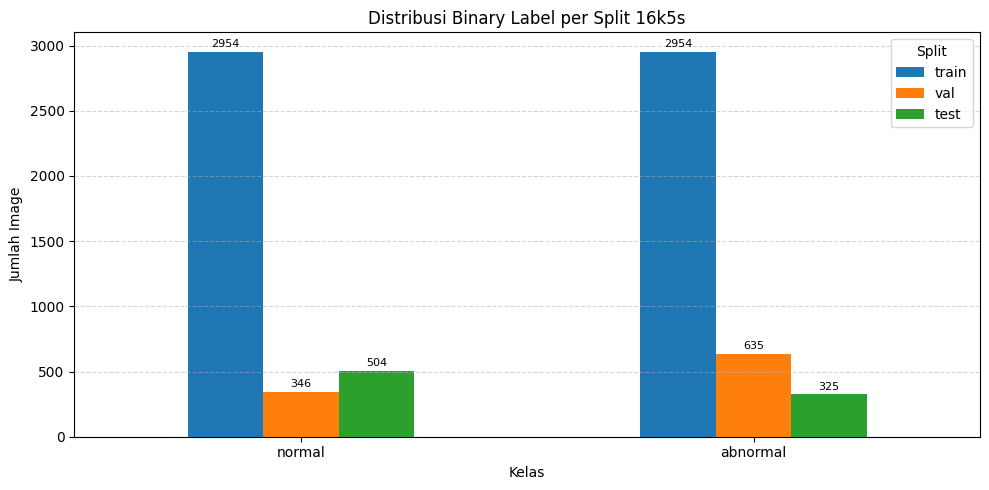


AUDIT DISTRIBUSI LABEL SUMBER sound


split,train,val,test,total
sound,,,,
normal,2954,346,504,3804
crackle,1414,380,94,1888
wheeze,873,113,156,1142
both,667,142,75,884
abnormal,0,0,0,0


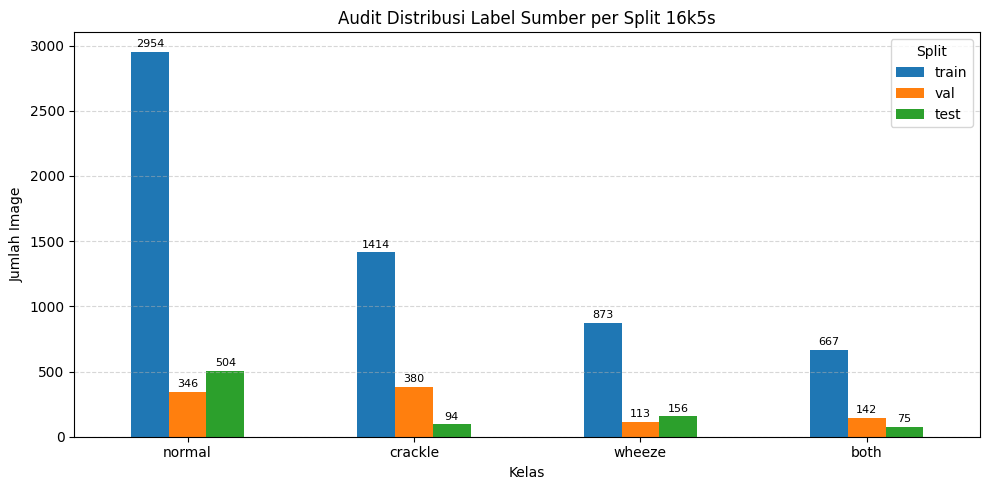


DISTRIBUSI TRAIN: ORIGINAL VS MANUAL AUGMENTATION


binary_label,normal,abnormal
augmentation_group,,
original,2954,2371
manual_aug,0,583


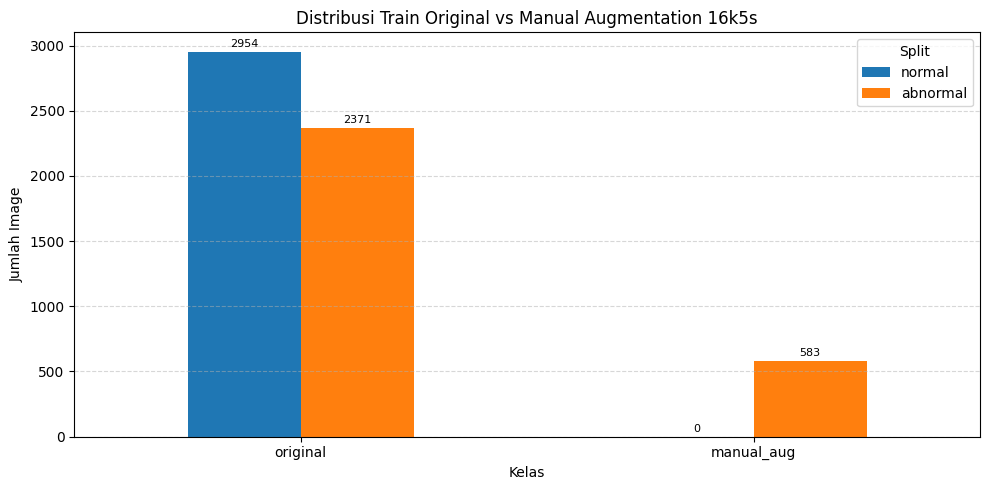


AUDIT TRAIN: ORIGINAL VS MANUAL AUGMENTATION BERDASARKAN sound


sound,normal,crackle,wheeze,both,abnormal
augmentation_group,,,,,
original,2954,1414,640,317,0
manual_aug,0,0,233,350,0



DISTRIBUSI JENIS AUGMENTASI PADA TRAIN


,count
aug_type,
none,5325
time_stretch,350
pitch_shift,233


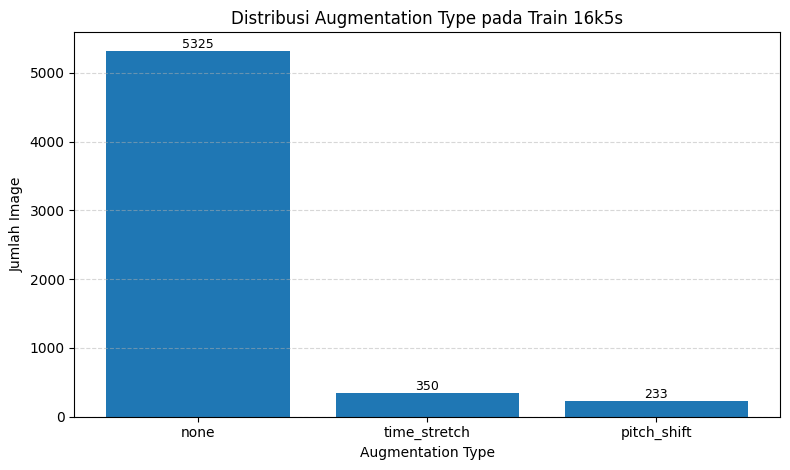


RINGKASAN JUMLAH DATA DAN PASIEN PER SPLIT


,split,n_samples,n_patients,normal,abnormal,original,manual_aug
0,train,5908,100,2954,2954,5325,583
1,val,981,13,346,635,981,0
2,test,829,13,504,325,829,0



Validasi patient leakage: aman

Validasi image_path: aman

Summary distribusi metadata disimpan di:
results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050

[OK] Distribusi metadata binary normal-abnormal 16k5s berhasil dicek.


In [19]:
# ============================================================
# CELL: CEK DISTRIBUSI METADATA 16k5s
# SKENARIO: BINARY NORMAL-ABNORMAL + AUGMENTASI MANUAL + SR 16k + LOG-MEL 224
# ============================================================
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0. HELPER
# ============================================================
def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)

def plot_grouped_bar(df, title, ylabel="Jumlah"):
    ax = df.plot(
        kind="bar",
        figsize=(10, 5),
        rot=0
    )

    ax.set_title(title)
    ax.set_xlabel("Kelas")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(title="Split")

    for container in ax.containers:
        ax.bar_label(container, fontsize=8, padding=2)

    plt.tight_layout()
    plt.show()


def plot_single_bar(series, title, xlabel="Kategori", ylabel="Jumlah"):
    fig, ax = plt.subplots(figsize=(8, 4.8))

    x = np.arange(len(series))
    bars = ax.bar(x, series.values)

    ax.set_xticks(x)
    ax.set_xticklabels(series.index.astype(str), rotation=0)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 1. VALIDASI DATAFRAME WAJIB
# ============================================================

required_vars = ["train_df", "val_df", "test_df"]
missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise RuntimeError(
        f"Variabel belum tersedia: {missing_vars}\n"
        "Jalankan cell Load Metadata 16k5s dan Validasi Metadata 16k5s terlebih dahulu."
    )

train_df = globals()["train_df"].copy()
val_df = globals()["val_df"].copy()
test_df = globals()["test_df"].copy()


# ============================================================
# 2. KONFIGURASI 16k5s
# ============================================================

SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
BINARY_CLASSES = ["normal", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

SPLITS = ["train", "val", "test"]

LABEL_COL = globals().get("LABEL_COL", "binary_label")

if LABEL_COL != "binary_label":
    raise ValueError(
        f"LABEL_COL saat ini adalah {LABEL_COL}. "
        "Untuk skenario binary normal-abnormal, LABEL_COL harus binary_label."
    )

TARGET_SR = 16000
TARGET_DURATION_SEC = 5.0
TARGET_LEN_SAMPLES = int(TARGET_SR * TARGET_DURATION_SEC)

N_MELS = 224
FMIN = 0
FMAX = 8000
N_FFT = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
IMAGE_SIZE = 224
IMAGE_COLORMAP = "magma"
IMAGE_MODE = "rgb"

VALID_AUGMENTATION_GROUPS = {"original", "manual_aug"}
VALID_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}


# ============================================================
# 3. NORMALISASI DAN VALIDASI KOLOM
# ============================================================

def normalize_and_validate_split_df(df, split_name):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "sound" not in df.columns:
        if "sound_4class" in df.columns:
            df["sound"] = df["sound_4class"]
        else:
            df["sound"] = df["binary_label"]

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df["sound"]

    required_cols = [
        "image_path",
        "sound",
        "binary_label",
        "split",
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(
            f"{split_name} kehilangan kolom wajib: {missing_cols}"
        )

    df["image_path"] = df["image_path"].astype(str).str.strip()
    df["sound"] = df["sound"].astype(str).str.strip().str.lower()
    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()
    df["binary_label"] = df["binary_label"].astype(str).str.strip().str.lower()
    df["split"] = df["split"].astype(str).str.strip().str.lower()

    unknown_sound = sorted(set(df["sound"]) - set(SOURCE_CLASSES))

    if unknown_sound:
        raise ValueError(
            f"{split_name} memiliki label sound tidak valid: {unknown_sound}"
        )

    unknown_binary = sorted(set(df["binary_label"]) - set(BINARY_CLASSES))

    if unknown_binary:
        raise ValueError(
            f"{split_name} memiliki binary_label tidak valid: {unknown_binary}"
        )

    if not df["split"].eq(split_name).all():
        bad_rows = df[df["split"] != split_name][
            ["image_path", "split", "sound", "binary_label"]
        ].head(10)

        safe_display(bad_rows)

        raise ValueError(
            f"{split_name} memiliki baris dengan split selain {split_name}."
        )

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0

    df["is_augmented"] = (
        pd.to_numeric(df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = np.where(
            df["is_augmented"] == 1,
            "manual_aug",
            "original"
        )

    df["augmentation_group"] = (
        df["augmentation_group"]
        .fillna("original")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"

    df["aug_type"] = (
        df["aug_type"]
        .fillna("none")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Val dan test harus original.
    if split_name in ["val", "test"]:
        df["is_augmented"] = 0
        df["augmentation_group"] = "original"
        df["aug_type"] = "none"

    # Original wajib none.
    df.loc[df["augmentation_group"] == "original", "aug_type"] = "none"

    unknown_aug_group = sorted(set(df["augmentation_group"]) - VALID_AUGMENTATION_GROUPS)

    if unknown_aug_group:
        raise ValueError(
            f"{split_name} memiliki augmentation_group tidak valid: {unknown_aug_group}"
        )

    unknown_aug_type = sorted(set(df["aug_type"]) - VALID_AUG_TYPES)

    if unknown_aug_type:
        raise ValueError(
            f"{split_name} memiliki aug_type tidak valid: {unknown_aug_type}"
        )

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    # Validasi parameter image jika tersedia.
    expected_numeric = {
        "image_sr": TARGET_SR,
        "image_expected_len_samples": TARGET_LEN_SAMPLES,
        "image_n_mels": N_MELS,
        "image_n_fft": N_FFT,
        "image_hop_length": HOP_LENGTH,
        "image_win_length": WIN_LENGTH,
        "image_fmax": FMAX,
        "image_target_width": IMAGE_SIZE,
        "image_target_height": IMAGE_SIZE,
    }

    for col, expected_value in expected_numeric.items():
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce")
            bad_mask = values.fillna(-999999).astype(float) != float(expected_value)

            if bad_mask.any():
                bad_rows = df.loc[
                    bad_mask,
                    ["image_path", "split", "sound", "binary_label", col]
                ].head(10)

                safe_display(bad_rows)

                raise AssertionError(
                    f"{split_name} memiliki {int(bad_mask.sum())} baris "
                    f"dengan {col} bukan {expected_value}."
                )

    if "image_expected_sec" in df.columns:
        values = pd.to_numeric(df["image_expected_sec"], errors="coerce")
        bad_mask = np.abs(values.fillna(-999999) - TARGET_DURATION_SEC) > 1e-6

        if bad_mask.any():
            bad_rows = df.loc[
                bad_mask,
                ["image_path", "split", "sound", "binary_label", "image_expected_sec"]
            ].head(10)

            safe_display(bad_rows)

            raise AssertionError(
                f"{split_name} memiliki {int(bad_mask.sum())} baris "
                f"dengan image_expected_sec bukan {TARGET_DURATION_SEC}."
            )

    if "image_colormap" in df.columns:
        values = (
            df["image_colormap"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        bad_mask = values != IMAGE_COLORMAP

        if bad_mask.any():
            bad_rows = df.loc[
                bad_mask,
                ["image_path", "split", "sound", "binary_label", "image_colormap"]
            ].head(10)

            safe_display(bad_rows)

            raise AssertionError(
                f"{split_name} memiliki {int(bad_mask.sum())} baris "
                f"dengan image_colormap bukan {IMAGE_COLORMAP}."
            )

    return df.reset_index(drop=True)


train_df = normalize_and_validate_split_df(train_df, "train")
val_df = normalize_and_validate_split_df(val_df, "val")
test_df = normalize_and_validate_split_df(test_df, "test")


# ============================================================
# 4. GABUNGKAN UNTUK RINGKASAN
# ============================================================

full_distribution_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print("=" * 90)
print("DISTRIBUSI METADATA 16k5s BINARY NORMAL-ABNORMAL")
print("=" * 90)
print("Total data:", len(full_distribution_df))
print("Train     :", len(train_df))
print("Val       :", len(val_df))
print("Test      :", len(test_df))
print("TARGET_SR :", TARGET_SR)
print("N_MELS    :", N_MELS)
print("FMAX      :", FMAX)


# ============================================================
# 5. DISTRIBUSI BINARY LABEL UTAMA
# ============================================================

binary_dist_df = (
    full_distribution_df
    .groupby(["split", "binary_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=SPLITS, columns=BINARY_CLASSES, fill_value=0)
)

binary_dist_df_t = binary_dist_df.T.copy()
binary_dist_df_t["total"] = binary_dist_df_t.sum(axis=1)

for split_name in SPLITS:
    split_total = max(binary_dist_df_t[split_name].sum(), 1)
    binary_dist_df_t[f"{split_name}_percent"] = (
        binary_dist_df_t[split_name] / split_total * 100.0
    )

print("\n" + "=" * 90)
print("DISTRIBUSI TARGET UTAMA: BINARY NORMAL-ABNORMAL")
print("=" * 90)
safe_display(binary_dist_df_t)

plot_grouped_bar(
    binary_dist_df_t[["train", "val", "test"]],
    title="Distribusi Binary Label per Split 16k5s",
    ylabel="Jumlah Image"
)


# ============================================================
# 6. AUDIT DISTRIBUSI LABEL SUMBER
# ============================================================

source_dist_df = (
    full_distribution_df
    .groupby(["split", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=SPLITS, columns=SOURCE_CLASSES, fill_value=0)
)

source_dist_df_t = source_dist_df.T.copy()
source_dist_df_t["total"] = source_dist_df_t.sum(axis=1)

print("\n" + "=" * 90)
print("AUDIT DISTRIBUSI LABEL SUMBER sound")
print("=" * 90)
safe_display(source_dist_df_t)

source_plot_df = source_dist_df_t[["train", "val", "test"]]
source_plot_df = source_plot_df.loc[source_plot_df.sum(axis=1) > 0]

plot_grouped_bar(
    source_plot_df,
    title="Audit Distribusi Label Sumber per Split 16k5s",
    ylabel="Jumlah Image"
)


# ============================================================
# 7. DISTRIBUSI ORIGINAL VS AUGMENTASI PADA TRAIN
# ============================================================

train_aug_binary_df = (
    train_df
    .groupby(["augmentation_group", "binary_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=BINARY_CLASSES, fill_value=0)
    .astype(int)
)

print("\n" + "=" * 90)
print("DISTRIBUSI TRAIN: ORIGINAL VS MANUAL AUGMENTATION")
print("=" * 90)
safe_display(train_aug_binary_df)

plot_grouped_bar(
    train_aug_binary_df,
    title="Distribusi Train Original vs Manual Augmentation 16k5s",
    ylabel="Jumlah Image"
)


train_aug_source_df = (
    train_df
    .groupby(["augmentation_group", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["original", "manual_aug"], columns=SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

print("\n" + "=" * 90)
print("AUDIT TRAIN: ORIGINAL VS MANUAL AUGMENTATION BERDASARKAN sound")
print("=" * 90)
safe_display(train_aug_source_df)


# ============================================================
# 8. DISTRIBUSI JENIS AUGMENTASI PADA TRAIN
# ============================================================

train_aug_type_df = (
    train_df["aug_type"]
    .value_counts()
    .reindex(["none", "time_stretch", "pitch_shift"], fill_value=0)
    .astype(int)
    .to_frame(name="count")
)

print("\n" + "=" * 90)
print("DISTRIBUSI JENIS AUGMENTASI PADA TRAIN")
print("=" * 90)
safe_display(train_aug_type_df)

plot_single_bar(
    train_aug_type_df["count"],
    title="Distribusi Augmentation Type pada Train 16k5s",
    xlabel="Augmentation Type",
    ylabel="Jumlah Image"
)


# ============================================================
# 9. RINGKASAN JUMLAH DATA DAN PASIEN PER SPLIT
# ============================================================

patient_summary = []

for split_name, df_split in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
]:
    row = {
        "split": split_name,
        "n_samples": int(len(df_split)),
        "n_patients": int(df_split["patient_id"].nunique()) if "patient_id" in df_split.columns else np.nan,
        "normal": int((df_split["binary_label"] == "normal").sum()),
        "abnormal": int((df_split["binary_label"] == "abnormal").sum()),
        "original": int((df_split["augmentation_group"] == "original").sum()) if "augmentation_group" in df_split.columns else np.nan,
        "manual_aug": int((df_split["augmentation_group"] == "manual_aug").sum()) if "augmentation_group" in df_split.columns else np.nan,
    }

    patient_summary.append(row)

patient_summary_df = pd.DataFrame(patient_summary)

print("\n" + "=" * 90)
print("RINGKASAN JUMLAH DATA DAN PASIEN PER SPLIT")
print("=" * 90)
safe_display(patient_summary_df)


# ============================================================
# 10. VALIDASI ANTI-LEAKAGE PATIENT
# ============================================================

if all("patient_id" in df.columns for df in [train_df, val_df, test_df]):
    train_patients = set(train_df["patient_id"].dropna().astype(int).unique())
    val_patients = set(val_df["patient_id"].dropna().astype(int).unique())
    test_patients = set(test_df["patient_id"].dropna().astype(int).unique())

    leak_train_val = train_patients & val_patients
    leak_train_test = train_patients & test_patients
    leak_val_test = val_patients & test_patients

    if leak_train_val or leak_train_test or leak_val_test:
        raise AssertionError(
            "Terdapat patient leakage antar split.\n"
            f"train-val leak : {sorted(list(leak_train_val))[:20]}\n"
            f"train-test leak: {sorted(list(leak_train_test))[:20]}\n"
            f"val-test leak  : {sorted(list(leak_val_test))[:20]}"
        )

    print("\nValidasi patient leakage: aman")


# ============================================================
# 11. VALIDASI IMAGE PATH
# ============================================================

for split_name, df_split in [
    ("train", train_df),
    ("val", val_df),
    ("test", test_df),
]:
    if "image_path" in df_split.columns:
        missing_images = df_split[
            ~df_split["image_path"].astype(str).apply(lambda p: Path(p).exists())
        ]

        if len(missing_images) > 0:
            print(f"\n[ERROR] {split_name}: ada {len(missing_images)} image_path hilang.")
            safe_display(
                missing_images[
                    ["image_path", "binary_label", "sound", "split", "augmentation_group"]
                ].head(10)
            )

            raise FileNotFoundError(
                f"{split_name}: ada image_path yang tidak ditemukan."
            )

print("\nValidasi image_path: aman")


# ============================================================
# 12. SIMPAN SUMMARY KE FILE JIKA RESULT_DIR ADA
# ============================================================

RESULT_DIR = globals().get("RESULT_DIR", None)

if RESULT_DIR is not None:
    RESULT_DIR = Path(RESULT_DIR)
    RESULT_DIR.mkdir(parents=True, exist_ok=True)

    binary_dist_df_t.to_csv(RESULT_DIR / "metadata_distribution_binary_16k5s.csv")
    source_dist_df_t.to_csv(RESULT_DIR / "metadata_distribution_source_16k5s.csv")
    train_aug_binary_df.to_csv(RESULT_DIR / "metadata_distribution_train_aug_binary_16k5s.csv")
    train_aug_source_df.to_csv(RESULT_DIR / "metadata_distribution_train_aug_source_16k5s.csv")
    train_aug_type_df.to_csv(RESULT_DIR / "metadata_distribution_train_aug_type_16k5s.csv")
    patient_summary_df.to_csv(RESULT_DIR / "metadata_distribution_patient_summary_16k5s.csv", index=False)

    print("\nSummary distribusi metadata disimpan di:")
    print(RESULT_DIR)


# ============================================================
# 13. SIMPAN KE GLOBALS
# ============================================================

globals()["train_df"] = train_df
globals()["val_df"] = val_df
globals()["test_df"] = test_df
globals()["full_distribution_df"] = full_distribution_df

globals()["binary_dist_df"] = binary_dist_df_t
globals()["source_dist_df"] = source_dist_df_t
globals()["train_aug_binary_df"] = train_aug_binary_df
globals()["train_aug_source_df"] = train_aug_source_df
globals()["train_aug_type_df"] = train_aug_type_df
globals()["patient_summary_df"] = patient_summary_df

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

print("\n[OK] Distribusi metadata binary normal-abnormal 16k5s berhasil dicek.")

# **Dataloader Model Vision Transformer**

In [20]:
# ============================================================
# CELL 33: TRANSFORM, DATASET, DATALOADER 16k5s
# SKENARIO: ViT + TIME-FREQUENCY ATTENTION POOLING
# BINARY NORMAL-ABNORMAL + AUGMENTASI MANUAL
# SR 16 kHz + LOG-MEL RGB 224 x 224
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm


# ============================================================
# 0. HELPER
# ============================================================

def safe_display(df):
    try:
        display(df)
    except NameError:
        print(df)


# ============================================================
# 1. DEVICE DAN VALIDASI KONFIGURASI
# ============================================================

DEVICE = globals().get(
    "DEVICE",
    torch.device("cuda" if torch.cuda.is_available() else "cpu")
)

print("=" * 90)
print("TRANSFORM, DATASET, DATALOADER 16k5s ViT-TIME-FREQUENCY ATTENTION")
print("=" * 90)
print("Device:", DEVICE)

required_globals = [
    "BATCH_SIZE",
    "NUM_WORKERS",
    "USE_WEIGHTED_RANDOM_SAMPLER",
    "SAMPLER_SEED",
    "SHUFFLE_TRAIN",
    "label2id",
    "id2label",
    "NUM_CLASSES",
    "CLASSES",
    "LABEL_COL",
    "train_df",
    "val_df",
    "test_df",
    "MODEL_FAMILY",
    "MODEL_NAME",
    "TF_ATTN_INPUT_DIM",
    "TF_ATTN_HIDDEN_DIM",
    "TF_ATTN_DROPOUT",
    "TF_ATTN_POOLING",
    "TF_ATTN_NUM_PATCHES",
]

missing_globals = [g for g in required_globals if g not in globals()]

if missing_globals:
    raise RuntimeError(
        f"Variabel global belum tersedia: {missing_globals}\n"
        "Jalankan Cell 25 Time-Frequency Attention, load metadata, validasi metadata, "
        "dan distribusi metadata 16k5s terlebih dahulu."
    )

MODEL_FAMILY = str(globals().get("MODEL_FAMILY", "ViT-TimeFrequencyAttention"))
MODEL_NAME = str(globals().get("MODEL_NAME", "ViT-B/16 + Time-Frequency Attention Pooling"))

model_family_lower = MODEL_FAMILY.lower()
model_name_lower = MODEL_NAME.lower()

is_tf_attention_model = (
    ("timefrequency" in model_family_lower)
    or ("time-frequency" in model_family_lower)
    or ("time frequency" in model_family_lower)
    or ("time-frequency" in model_name_lower)
    or ("time frequency" in model_name_lower)
)

if not is_tf_attention_model:
    raise AssertionError(
        f"MODEL_FAMILY atau MODEL_NAME belum sesuai Time-Frequency Attention. "
        f"MODEL_FAMILY={MODEL_FAMILY}, MODEL_NAME={MODEL_NAME}"
    )

if LABEL_COL != "binary_label":
    raise ValueError(
        f"LABEL_COL saat ini adalah {LABEL_COL}. "
        "Untuk eksperimen binary, LABEL_COL wajib 'binary_label'."
    )

if list(CLASSES) != ["normal", "abnormal"]:
    raise ValueError(
        f"CLASSES saat ini {CLASSES}. "
        "Untuk eksperimen binary, CLASSES wajib ['normal', 'abnormal']."
    )

if int(NUM_CLASSES) != 2:
    raise ValueError(
        f"NUM_CLASSES saat ini {NUM_CLASSES}. "
        "Untuk eksperimen binary, NUM_CLASSES wajib 2."
    )

BATCH_SIZE = int(BATCH_SIZE)
NUM_WORKERS = int(NUM_WORKERS)
SAMPLER_SEED = int(SAMPLER_SEED)

if BATCH_SIZE <= 0:
    raise ValueError(f"BATCH_SIZE tidak valid: {BATCH_SIZE}")

if NUM_WORKERS < 0:
    raise ValueError(f"NUM_WORKERS tidak valid: {NUM_WORKERS}")

if not bool(SHUFFLE_TRAIN) and not bool(USE_WEIGHTED_RANDOM_SAMPLER):
    raise AssertionError(
        "SHUFFLE_TRAIN sebaiknya True jika WeightedRandomSampler tidak digunakan."
    )

USE_CLASS_WEIGHT = bool(globals().get("USE_CLASS_WEIGHT", False))

if bool(USE_WEIGHTED_RANDOM_SAMPLER) and USE_CLASS_WEIGHT:
    raise AssertionError(
        "USE_WEIGHTED_RANDOM_SAMPLER=True dan USE_CLASS_WEIGHT=True akan "
        "menggandakan kompensasi imbalance. Gunakan salah satu saja."
    )


# ============================================================
# 2. KONFIGURASI TARGET 16k5s, LABEL, DAN TF ATTENTION
# ============================================================

TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_DURATION_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN_SAMPLES = int(
    globals().get(
        "TARGET_LEN_SAMPLES",
        TARGET_SR * TARGET_DURATION_SEC
    )
)

N_MELS = int(globals().get("N_MELS", 224))
FMIN = int(globals().get("FMIN", 0))
FMAX = int(globals().get("FMAX", 8000))
N_FFT = int(globals().get("N_FFT", 2048))
HOP_LENGTH = int(globals().get("HOP_LENGTH", 128))
WIN_LENGTH = int(globals().get("WIN_LENGTH", 2048))

IMAGE_SIZE = int(globals().get("IMAGE_SIZE", 224))
IMAGE_COLORMAP = str(globals().get("IMAGE_COLORMAP", "magma")).lower()
IMAGE_MODE = str(globals().get("IMAGE_MODE", "rgb")).lower()

VIT_PATCH_SIZE = int(globals().get("VIT_PATCH_SIZE", 16))
VIT_PATCH_GRID_SIZE = int(globals().get("VIT_PATCH_GRID_SIZE", IMAGE_SIZE // VIT_PATCH_SIZE))
VIT_NUM_PATCHES = int(globals().get("VIT_NUM_PATCHES", VIT_PATCH_GRID_SIZE * VIT_PATCH_GRID_SIZE))
VIT_EMBED_DIM = int(globals().get("VIT_EMBED_DIM", 768))

TF_ATTN_INPUT_DIM = int(globals().get("TF_ATTN_INPUT_DIM", 768))
TF_ATTN_HIDDEN_DIM = int(globals().get("TF_ATTN_HIDDEN_DIM", 256))
TF_ATTN_DROPOUT = float(globals().get("TF_ATTN_DROPOUT", 0.30))
TF_ATTN_POOLING = str(globals().get("TF_ATTN_POOLING", "mlp_attention"))
TF_ATTN_NUM_PATCHES = int(globals().get("TF_ATTN_NUM_PATCHES", 196))
TF_ATTN_ACTIVATION = str(globals().get("TF_ATTN_ACTIVATION", "tanh"))

BINARY_CLASSES = ["normal", "abnormal"]
SOURCE_CLASSES = ["normal", "crackle", "wheeze", "both", "abnormal"]
ABNORMAL_CLASSES = ["crackle", "wheeze", "both", "abnormal"]

VALID_SPLITS = {"train", "val", "test"}
VALID_AUG_GROUPS = {"original", "manual_aug"}
VALID_AUG_TYPES = {"none", "time_stretch", "pitch_shift"}

if TARGET_SR != 16000:
    raise AssertionError(
        f"TARGET_SR harus 16000 untuk pipeline 16k5s, saat ini {TARGET_SR}."
    )

if abs(TARGET_DURATION_SEC - 5.0) > 1e-12:
    raise AssertionError(
        f"TARGET_DURATION_SEC harus 5.0, saat ini {TARGET_DURATION_SEC}."
    )

if TARGET_LEN_SAMPLES != 80000:
    raise AssertionError(
        f"TARGET_LEN_SAMPLES harus 80000 untuk audio 16 kHz 5 detik, "
        f"saat ini {TARGET_LEN_SAMPLES}."
    )

if N_MELS != 224:
    raise AssertionError(
        f"N_MELS harus 224 untuk input Log-Mel 224, saat ini {N_MELS}."
    )

if FMIN != 0:
    raise AssertionError(
        f"FMIN harus 0 sesuai metadata citra yang sudah dibuat, saat ini {FMIN}. "
        "Jika ingin FMIN=50, citra harus dikonversi ulang."
    )

if FMAX != 8000:
    raise AssertionError(
        f"FMAX harus 8000 sesuai metadata citra yang sudah dibuat, saat ini {FMAX}. "
        "Jika ingin FMAX=2000, citra harus dikonversi ulang."
    )

if HOP_LENGTH != 128:
    raise AssertionError(
        f"HOP_LENGTH harus 128 untuk konfigurasi 16k5s, saat ini {HOP_LENGTH}."
    )

if IMAGE_SIZE != 224:
    raise AssertionError(
        f"IMAGE_SIZE harus 224 untuk ViT-B/16, saat ini {IMAGE_SIZE}."
    )

if VIT_PATCH_SIZE != 16:
    raise AssertionError(
        f"VIT_PATCH_SIZE harus 16 untuk ViT-B/16, saat ini {VIT_PATCH_SIZE}."
    )

if VIT_PATCH_GRID_SIZE != 14:
    raise AssertionError(
        f"VIT_PATCH_GRID_SIZE harus 14 untuk input 224x224 patch 16, "
        f"saat ini {VIT_PATCH_GRID_SIZE}."
    )

if VIT_NUM_PATCHES != 196:
    raise AssertionError(
        f"VIT_NUM_PATCHES harus 196 untuk grid 14x14, saat ini {VIT_NUM_PATCHES}."
    )

if VIT_EMBED_DIM != 768:
    raise AssertionError(
        f"VIT_EMBED_DIM harus 768 untuk ViT-B/16, saat ini {VIT_EMBED_DIM}."
    )

if TF_ATTN_INPUT_DIM != 768:
    raise AssertionError(
        f"TF_ATTN_INPUT_DIM harus 768 untuk ViT-B/16, saat ini {TF_ATTN_INPUT_DIM}."
    )

if TF_ATTN_INPUT_DIM != VIT_EMBED_DIM:
    raise AssertionError(
        f"TF_ATTN_INPUT_DIM harus sama dengan VIT_EMBED_DIM. "
        f"TF_ATTN_INPUT_DIM={TF_ATTN_INPUT_DIM}, VIT_EMBED_DIM={VIT_EMBED_DIM}"
    )

if TF_ATTN_NUM_PATCHES != VIT_NUM_PATCHES:
    raise AssertionError(
        f"TF_ATTN_NUM_PATCHES harus sama dengan VIT_NUM_PATCHES. "
        f"TF_ATTN_NUM_PATCHES={TF_ATTN_NUM_PATCHES}, VIT_NUM_PATCHES={VIT_NUM_PATCHES}"
    )


def to_binary_label(label):
    label = str(label).strip().lower()

    if label == "normal":
        return "normal"

    if label in ABNORMAL_CLASSES:
        return "abnormal"

    raise ValueError(f"Label tidak dikenal: {label}")


# ============================================================
# 3. VALIDASI DATAFRAME INPUT
# ============================================================

def validate_df_for_dataset_16k5s(df: pd.DataFrame, name: str, expected_split: str):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    if "sound" not in df.columns:
        if "sound_4class" in df.columns:
            df["sound"] = df["sound_4class"]
        else:
            df["sound"] = df[LABEL_COL]

    if "sound_4class" not in df.columns:
        df["sound_4class"] = df["sound"]

    if "original_sound" not in df.columns:
        df["original_sound"] = df["sound"]

    if "is_augmented" not in df.columns:
        df["is_augmented"] = 0

    if "augmentation_group" not in df.columns:
        df["augmentation_group"] = np.where(
            pd.to_numeric(df["is_augmented"], errors="coerce")
            .fillna(0)
            .astype(int) == 1,
            "manual_aug",
            "original"
        )

    if "aug_type" not in df.columns:
        df["aug_type"] = "none"

    required_cols = [
        "image_path",
        LABEL_COL,
        "sound",
        "split",
        "is_augmented",
        "augmentation_group",
        "aug_type",
    ]

    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(f"{name} kehilangan kolom wajib: {missing_cols}")

    df["image_path"] = df["image_path"].astype(str).str.strip()
    df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()
    df["sound"] = df["sound"].astype(str).str.strip().str.lower()
    df["sound_4class"] = df["sound_4class"].astype(str).str.strip().str.lower()
    df["original_sound"] = df["original_sound"].astype(str).str.strip().str.lower()
    df["split"] = df["split"].astype(str).str.strip().str.lower()

    df["augmentation_group"] = (
        df["augmentation_group"]
        .fillna("original")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["aug_type"] = (
        df["aug_type"]
        .fillna("none")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    df["is_augmented"] = (
        pd.to_numeric(df["is_augmented"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    if "patient_id" in df.columns:
        df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")

    unknown_binary = sorted(set(df[LABEL_COL]) - set(BINARY_CLASSES))
    if unknown_binary:
        raise ValueError(f"{name} memiliki binary_label tidak valid: {unknown_binary}")

    unknown_sound = sorted(set(df["sound"]) - set(SOURCE_CLASSES))
    if unknown_sound:
        raise ValueError(f"{name} memiliki sound tidak valid: {unknown_sound}")

    unknown_sound_4class = sorted(set(df["sound_4class"]) - set(SOURCE_CLASSES))
    if unknown_sound_4class:
        raise ValueError(
            f"{name} memiliki sound_4class tidak valid: {unknown_sound_4class}"
        )

    unknown_original = sorted(set(df["original_sound"]) - set(SOURCE_CLASSES))
    if unknown_original:
        raise ValueError(
            f"{name} memiliki original_sound tidak valid: {unknown_original}"
        )

    unknown_split = sorted(set(df["split"]) - VALID_SPLITS)
    if unknown_split:
        raise ValueError(f"{name} memiliki split tidak valid: {unknown_split}")

    if not df["split"].eq(expected_split).all():
        bad_rows = df[df["split"] != expected_split][
            ["image_path", "split", LABEL_COL, "sound"]
        ].head(10)

        safe_display(bad_rows)

        raise ValueError(
            f"{name} seharusnya seluruh baris split={expected_split}."
        )

    expected_binary = df["sound"].apply(to_binary_label)
    mismatch_mask = expected_binary != df[LABEL_COL]

    if mismatch_mask.any():
        bad_preview = df.loc[
            mismatch_mask,
            ["image_path", "sound", LABEL_COL, "split"]
        ].head(10)

        safe_display(bad_preview)

        raise ValueError(
            f"{name} memiliki binary_label tidak konsisten dengan sound. "
            f"Jumlah: {int(mismatch_mask.sum())}"
        )

    if expected_split in ["val", "test"]:
        df["augmentation_group"] = "original"
        df["is_augmented"] = 0
        df["aug_type"] = "none"

    df.loc[df["augmentation_group"] == "original", "aug_type"] = "none"

    bad_aug_group = sorted(set(df["augmentation_group"]) - VALID_AUG_GROUPS)
    if bad_aug_group:
        raise ValueError(
            f"{name} memiliki augmentation_group tidak valid: {bad_aug_group}"
        )

    bad_aug_type = sorted(set(df["aug_type"]) - VALID_AUG_TYPES)
    if bad_aug_type:
        raise ValueError(
            f"{name} memiliki aug_type tidak valid: {bad_aug_type}. "
            "Metadata masih tercampur augmentasi lama."
        )

    if expected_split == "train":
        bad_original = df[
            (df["augmentation_group"] == "original")
            & (
                (df["is_augmented"] != 0)
                | (df["aug_type"] != "none")
            )
        ]

        if len(bad_original) > 0:
            safe_display(
                bad_original[
                    [
                        "image_path",
                        LABEL_COL,
                        "sound",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{name} memiliki data original dengan is_augmented atau "
                "aug_type tidak konsisten."
            )

        bad_manual = df[
            (df["augmentation_group"] == "manual_aug")
            & (
                (df["is_augmented"] != 1)
                | (~df["aug_type"].isin(["time_stretch", "pitch_shift"]))
            )
        ]

        if len(bad_manual) > 0:
            safe_display(
                bad_manual[
                    [
                        "image_path",
                        LABEL_COL,
                        "sound",
                        "augmentation_group",
                        "is_augmented",
                        "aug_type",
                    ]
                ].head(10)
            )

            raise ValueError(
                f"{name} memiliki data manual_aug yang tidak sesuai metodologi."
            )

    expected_numeric = {
        "image_sr": TARGET_SR,
        "image_expected_len_samples": TARGET_LEN_SAMPLES,
        "image_n_mels": N_MELS,
        "image_n_fft": N_FFT,
        "image_hop_length": HOP_LENGTH,
        "image_win_length": WIN_LENGTH,
        "image_fmax": FMAX,
        "image_target_width": IMAGE_SIZE,
        "image_target_height": IMAGE_SIZE,
    }

    for col, expected_value in expected_numeric.items():
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce")
            bad_mask = values.fillna(-999999).astype(float) != float(expected_value)

            if bad_mask.any():
                safe_display(
                    df.loc[
                        bad_mask,
                        ["image_path", "split", "sound", LABEL_COL, col]
                    ].head(10)
                )

                raise AssertionError(
                    f"{name} memiliki {int(bad_mask.sum())} baris "
                    f"dengan {col} bukan {expected_value}."
                )

    if "image_fmin" in df.columns:
        fmin_values = pd.to_numeric(df["image_fmin"], errors="coerce")
        bad_fmin = fmin_values.fillna(-999999).astype(float) != float(FMIN)

        if bad_fmin.any():
            safe_display(
                df.loc[
                    bad_fmin,
                    ["image_path", "split", "sound", LABEL_COL, "image_fmin"]
                ].head(10)
            )

            raise AssertionError(
                f"{name} memiliki {int(bad_fmin.sum())} baris "
                f"dengan image_fmin bukan {FMIN}."
            )

    if "image_expected_sec" in df.columns:
        sec_values = pd.to_numeric(df["image_expected_sec"], errors="coerce")
        bad_sec = np.abs(sec_values.fillna(-999999) - TARGET_DURATION_SEC) > 1e-6

        if bad_sec.any():
            safe_display(
                df.loc[
                    bad_sec,
                    ["image_path", "split", "sound", LABEL_COL, "image_expected_sec"]
                ].head(10)
            )

            raise AssertionError(
                f"{name} memiliki {int(bad_sec.sum())} baris "
                f"dengan image_expected_sec bukan {TARGET_DURATION_SEC}."
            )

    if "image_colormap" in df.columns:
        cmap_values = (
            df["image_colormap"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        bad_cmap = cmap_values != IMAGE_COLORMAP

        if bad_cmap.any():
            safe_display(
                df.loc[
                    bad_cmap,
                    ["image_path", "split", "sound", LABEL_COL, "image_colormap"]
                ].head(10)
            )

            raise AssertionError(
                f"{name} memiliki {int(bad_cmap.sum())} baris "
                f"dengan image_colormap bukan {IMAGE_COLORMAP}."
            )

    if "image_mode" in df.columns:
        mode_values = (
            df["image_mode"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        bad_mode = mode_values != IMAGE_MODE

        if bad_mode.any():
            safe_display(
                df.loc[
                    bad_mode,
                    ["image_path", "split", "sound", LABEL_COL, "image_mode"]
                ].head(10)
            )

            raise AssertionError(
                f"{name} memiliki {int(bad_mode.sum())} baris "
                f"dengan image_mode bukan {IMAGE_MODE}."
            )

    missing_images = [
        p for p in df["image_path"].tolist()
        if not Path(str(p)).exists()
    ]

    if missing_images:
        print(f"[ERROR] {name} memiliki image_path hilang: {len(missing_images)}")
        for p in missing_images[:10]:
            print(" -", p)

        raise FileNotFoundError(
            f"{name} memiliki image_path hilang."
        )

    dup_count = int(df["image_path"].duplicated().sum())

    if dup_count > 0:
        safe_display(
            df[df["image_path"].duplicated(keep=False)][
                [
                    "image_path",
                    LABEL_COL,
                    "sound",
                    "split",
                    "augmentation_group",
                    "aug_type",
                ]
            ].head(10)
        )

        raise ValueError(
            f"{name} memiliki image_path duplikat: {dup_count}"
        )

    print(f"{name} valid untuk Dataset | jumlah data: {len(df)}")

    return df.reset_index(drop=True)


train_df = validate_df_for_dataset_16k5s(train_df, "train_df", "train")
val_df = validate_df_for_dataset_16k5s(val_df, "val_df", "val")
test_df = validate_df_for_dataset_16k5s(test_df, "test_df", "test")


# ============================================================
# 4. HITUNG MEAN DAN STD DARI TRAIN SET
# ============================================================

def compute_dataset_norm_stats(df, sample_size=2000, seed=42):
    rng = np.random.default_rng(seed)

    if "image_path" not in df.columns:
        raise ValueError(
            f"Kolom image_path tidak ditemukan. Kolom tersedia: {list(df.columns)}"
        )

    paths = df["image_path"].astype(str).values

    if len(paths) > sample_size:
        idx = rng.choice(
            len(paths),
            size=sample_size,
            replace=False
        )
        paths = paths[idx]

    to_tensor = transforms.ToTensor()

    channel_sum = np.zeros(3, dtype=np.float64)
    channel_sq_sum = np.zeros(3, dtype=np.float64)
    pixel_count = 0
    skipped = 0

    print(f"\nMenghitung mean/std dari {len(paths)} gambar train...")

    try:
        resample_bilinear = Image.Resampling.BILINEAR
    except AttributeError:
        resample_bilinear = Image.BILINEAR

    for path_str in tqdm(paths, desc="Stats", leave=False):
        p = Path(str(path_str))

        if not p.exists():
            skipped += 1
            continue

        try:
            with Image.open(str(p)) as img:
                img_rgb = img.convert("RGB").resize(
                    (IMAGE_SIZE, IMAGE_SIZE),
                    resample=resample_bilinear
                )

            t = to_tensor(img_rgb).numpy()
            pixels = t.reshape(3, -1)

            channel_sum += pixels.sum(axis=1)
            channel_sq_sum += (pixels ** 2).sum(axis=1)
            pixel_count += pixels.shape[1]

        except Exception:
            skipped += 1
            continue

    if pixel_count == 0:
        raise RuntimeError(
            "Tidak ada pixel valid untuk menghitung mean/std dataset."
        )

    mean = channel_sum / pixel_count
    var = channel_sq_sum / pixel_count - mean ** 2
    std = np.sqrt(np.maximum(var, 1e-12))

    if skipped > 0:
        print(f"[WARNING] Skip saat hitung mean/std: {skipped}")

    return mean.tolist(), std.tolist()


DATASET_MEAN, DATASET_STD = compute_dataset_norm_stats(
    train_df,
    sample_size=2000,
    seed=42,
)

print("\nNormalisasi yang digunakan:")
print(f"  Dataset mean : {[f'{v:.4f}' for v in DATASET_MEAN]}")
print(f"  Dataset std  : {[f'{v:.4f}' for v in DATASET_STD]}")


# ============================================================
# 5. SPEC AUGMENT TRANSFORM
# Class dipertahankan untuk kompatibilitas, tetapi tidak dipakai.
# ============================================================

class SpecAugmentTransform:
    def __init__(
        self,
        time_mask_max=0,
        freq_mask_max=0,
        n_time_masks=0,
        n_freq_masks=0,
        p=0.0,
    ):
        self.time_mask_max = int(time_mask_max)
        self.freq_mask_max = int(freq_mask_max)
        self.n_time_masks = int(n_time_masks)
        self.n_freq_masks = int(n_freq_masks)
        self.p = float(p)

    def __call__(self, img_tensor):
        if not torch.is_tensor(img_tensor):
            raise TypeError("SpecAugmentTransform membutuhkan input torch.Tensor.")

        if self.p <= 0:
            return img_tensor

        if torch.rand(1).item() > self.p:
            return img_tensor

        img_tensor = img_tensor.clone()

        c, h, w = img_tensor.shape

        for _ in range(self.n_freq_masks):
            if self.freq_mask_max <= 0:
                continue

            f = torch.randint(0, self.freq_mask_max + 1, (1,)).item()

            if f > 0 and h - f > 0:
                f0 = torch.randint(0, h - f + 1, (1,)).item()
                img_tensor[:, f0:f0 + f, :] = 0.0

        for _ in range(self.n_time_masks):
            if self.time_mask_max <= 0:
                continue

            t = torch.randint(0, self.time_mask_max + 1, (1,)).item()

            if t > 0 and w - t > 0:
                t0 = torch.randint(0, w - t + 1, (1,)).item()
                img_tensor[:, :, t0:t0 + t] = 0.0

        return img_tensor


# ============================================================
# 6. TRANSFORM ViT-TIME-FREQUENCY ATTENTION
# ============================================================
USE_SPEC_AUGMENT = bool(globals().get("USE_SPEC_AUGMENT", False))
if USE_SPEC_AUGMENT:
    raise AssertionError(
        "USE_SPEC_AUGMENT harus False untuk skenario ViT-Time-Frequency Attention threshold 0.50. "
        "Matikan SpecAugment di Cell 25 sebelum menjalankan Cell 33."
    )

SPEC_AUGMENT_P = 0.0
SPEC_TIME_MASK_MAX = 0
SPEC_FREQ_MASK_MAX = 0
SPEC_N_TIME_MASKS = 0
SPEC_N_FREQ_MASKS = 0

base_transform_steps = [
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=DATASET_MEAN,
        std=DATASET_STD,
    ),
]

train_transform = transforms.Compose(base_transform_steps)
eval_transform = transforms.Compose(base_transform_steps)

# Alias lama agar cell lain yang membaca vit_transforms tetap tidak error.
vit_transforms = eval_transform

print("\nTransform train ViT-Time-Frequency Attention:")
print(train_transform)

print("\nTransform eval ViT-Time-Frequency Attention:")
print(eval_transform)


# ============================================================
# 7. DATASET CLASS
# ============================================================
class LogMelImageDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        label2id: dict,
        label_col: str = "binary_label",
        transform=None,
        return_metadata: bool = False,
    ):
        self.df = df.reset_index(drop=True).copy()
        self.label2id = label2id
        self.label_col = label_col
        self.transform = transform
        self.return_metadata = return_metadata

        required_cols = ["image_path", self.label_col]
        missing_cols = [c for c in required_cols if c not in self.df.columns]

        if missing_cols:
            raise ValueError(
                f"Kolom wajib tidak ditemukan: {missing_cols}"
            )

        self.df["image_path"] = self.df["image_path"].astype(str).str.strip()
        self.df[self.label_col] = (
            self.df[self.label_col]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        unknown_labels = sorted(
            set(self.df[self.label_col]) - set(self.label2id.keys())
        )

        if unknown_labels:
            raise ValueError(
                f"Label tidak dikenal pada {self.label_col}: {unknown_labels}"
            )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = str(row["image_path"])
        label_str = str(row[self.label_col]).strip().lower()

        if label_str not in self.label2id:
            raise ValueError(f"Label tidak dikenal: {label_str}")

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image file tidak ditemukan: {img_path}")

        with Image.open(img_path) as img:
            image = img.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label_id = int(self.label2id[label_str])

        if not self.return_metadata:
            return image, label_id

        metadata = {
            "image_path": img_path,
            "label": label_str,
            "label_id": label_id,
        }

        metadata_cols = [
            "sound",
            "sound_4class",
            "original_sound",
            "patient_id",
            "split",
            "is_augmented",
            "augmentation_group",
            "aug_type",
            "file",
            "image_sr",
            "image_n_mels",
            "image_fmin",
            "image_fmax",
            "image_hop_length",
            "image_expected_len_samples",
        ]

        for col in metadata_cols:
            if col in row.index:
                metadata[col] = row[col]

        return image, label_id, metadata


# ============================================================
# 8. DATASET
# ============================================================
train_dataset = LogMelImageDataset(
    train_df,
    label2id,
    label_col=LABEL_COL,
    transform=train_transform,
    return_metadata=False,
)

val_dataset = LogMelImageDataset(
    val_df,
    label2id,
    label_col=LABEL_COL,
    transform=eval_transform,
    return_metadata=False,
)

test_dataset = LogMelImageDataset(
    test_df,
    label2id,
    label_col=LABEL_COL,
    transform=eval_transform,
    return_metadata=False,
)

print("\nJumlah sampel dataset:")
print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))


# ============================================================
# 9. DATALOADER HELPER
# ============================================================
def seed_worker(worker_id):
    worker_seed = SAMPLER_SEED + worker_id
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def make_loader(
    dataset,
    batch_size,
    shuffle,
    num_workers,
    sampler=None,
):
    generator = torch.Generator()
    generator.manual_seed(SAMPLER_SEED)

    kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": shuffle if sampler is None else False,
        "sampler": sampler,
        "num_workers": num_workers,
        "pin_memory": torch.cuda.is_available(),
        "drop_last": False,
        "generator": generator,
    }

    if num_workers > 0:
        kwargs["worker_init_fn"] = seed_worker
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2

    return DataLoader(**kwargs)


# ============================================================
# 10. WEIGHTED RANDOM SAMPLER
# ============================================================
train_sampler = None
sampler_audit_df = None

train_labels_str = (
    train_df[LABEL_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .values
)

train_labels_id = np.array(
    [label2id[x] for x in train_labels_str],
    dtype=np.int64
)

class_counts = np.bincount(
    train_labels_id,
    minlength=NUM_CLASSES,
).astype(np.int64)

if USE_WEIGHTED_RANDOM_SAMPLER:
    class_counts_sampler = class_counts.astype(np.float64)

    if np.any(class_counts_sampler <= 0):
        raise ValueError(
            "Ada kelas kosong pada train_df. WeightedRandomSampler tidak valid."
        )

    class_sample_weights = 1.0 / class_counts_sampler
    sample_weights = class_sample_weights[train_labels_id]
    sample_weights = torch.as_tensor(
        sample_weights,
        dtype=torch.double
    )

    sampler_generator = torch.Generator()
    sampler_generator.manual_seed(SAMPLER_SEED)

    train_sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=sampler_generator,
    )

    sampler_audit_df = pd.DataFrame({
        "class_id": list(range(NUM_CLASSES)),
        "class_name": [id2label[i] for i in range(NUM_CLASSES)],
        "n_train": class_counts_sampler.astype(int),
        "original_train_ratio": class_counts_sampler / class_counts_sampler.sum(),
        "class_sample_weight": class_sample_weights,
    })

    print("\nWeightedRandomSampler aktif:")
    safe_display(sampler_audit_df)

else:
    print("\nWeightedRandomSampler tidak digunakan. Train memakai shuffle biasa.")


# ============================================================
# 11. DATALOADER
# ============================================================

train_loader = make_loader(
    train_dataset,
    BATCH_SIZE,
    shuffle=bool(SHUFFLE_TRAIN),
    num_workers=NUM_WORKERS,
    sampler=train_sampler,
)

val_loader = make_loader(
    val_dataset,
    BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

test_loader = make_loader(
    test_dataset,
    BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print("\nJumlah batch:")
print("Train:", len(train_loader))
print("Val  :", len(val_loader))
print("Test :", len(test_loader))


# ============================================================
# 12. CEK SATU BATCH
# ============================================================

images, labels = next(iter(train_loader))

print("\nCek satu batch:")
print("Shape images      :", images.shape)
print("Shape labels      :", labels.shape)
print("Dtype images      :", images.dtype)
print("Dtype labels      :", labels.dtype)
print("Contoh label id   :", labels[:15].tolist())
print("Contoh label nama :", [id2label[int(x)] for x in labels[:10]])

assert images.ndim == 4 and images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE), (
    f"Shape image tidak sesuai input ViT-Time-Frequency Attention: {images.shape}"
)

assert labels.ndim == 1, (
    f"Shape labels tidak sesuai: {labels.shape}"
)

assert set(labels.detach().cpu().numpy().tolist()).issubset(set(range(NUM_CLASSES))), (
    "Ada label id di luar NUM_CLASSES."
)


# ============================================================
# 13. AUDIT DISTRIBUSI KELAS TARGET MODEL
# ============================================================

class_dist_df = pd.DataFrame({
    "class_id": list(range(NUM_CLASSES)),
    "class_name": [id2label[i] for i in range(NUM_CLASSES)],
    "n_train": class_counts,
    "train_ratio": class_counts / class_counts.sum(),
})

print("\nDistribusi binary label train:")
safe_display(class_dist_df)


# ============================================================
# 14. AUDIT DISTRIBUSI LABEL SUMBER DAN AUGMENTASI
# ============================================================

print("\nAudit distribusi label sumber sound pada train:")
source_train_counts = (
    train_df["sound"]
    .value_counts()
    .reindex(SOURCE_CLASSES, fill_value=0)
    .astype(int)
)

safe_display(source_train_counts)

print("\nDistribusi train berdasarkan augmentation_group x binary_label:")
train_group_class_df = (
    train_df
    .groupby(["augmentation_group", LABEL_COL])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=["original", "manual_aug"],
        columns=BINARY_CLASSES,
        fill_value=0
    )
    .astype(int)
)

safe_display(train_group_class_df)

print("\nDistribusi train berdasarkan augmentation_group x sound:")
train_group_source_df = (
    train_df
    .groupby(["augmentation_group", "sound"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=["original", "manual_aug"],
        columns=SOURCE_CLASSES,
        fill_value=0
    )
    .astype(int)
)

safe_display(train_group_source_df)

print("\nDistribusi aug_type train:")
train_aug_type_counts = (
    train_df["aug_type"]
    .value_counts()
    .reindex(["none", "time_stretch", "pitch_shift"], fill_value=0)
    .astype(int)
)

safe_display(train_aug_type_counts)

print("\nParameter image 16k5s:")
print("TARGET_SR           :", TARGET_SR)
print("TARGET_DURATION_SEC :", TARGET_DURATION_SEC)
print("TARGET_LEN_SAMPLES  :", TARGET_LEN_SAMPLES)
print("N_MELS              :", N_MELS)
print("FMIN                :", FMIN)
print("FMAX                :", FMAX)
print("N_FFT               :", N_FFT)
print("HOP_LENGTH          :", HOP_LENGTH)
print("WIN_LENGTH          :", WIN_LENGTH)
print("IMAGE_SIZE          :", IMAGE_SIZE)
print("IMAGE_COLORMAP      :", IMAGE_COLORMAP)
print("IMAGE_MODE          :", IMAGE_MODE)

print("\nTime-Frequency Attention Pooling:")
print("MODEL_FAMILY        :", MODEL_FAMILY)
print("MODEL_NAME          :", MODEL_NAME)
print("VIT_PATCH_GRID_SIZE :", VIT_PATCH_GRID_SIZE)
print("VIT_NUM_PATCHES     :", VIT_NUM_PATCHES)
print("VIT_EMBED_DIM       :", VIT_EMBED_DIM)
print("TF_ATTN_INPUT_DIM   :", TF_ATTN_INPUT_DIM)
print("TF_ATTN_HIDDEN_DIM  :", TF_ATTN_HIDDEN_DIM)
print("TF_ATTN_DROPOUT     :", TF_ATTN_DROPOUT)
print("TF_ATTN_POOLING     :", TF_ATTN_POOLING)
print("TF_ATTN_NUM_PATCHES :", TF_ATTN_NUM_PATCHES)
print("TF_ATTN_ACTIVATION  :", TF_ATTN_ACTIVATION)

print("\nSpecAugment:")
print("USE_SPEC_AUGMENT    :", USE_SPEC_AUGMENT)
print("SPEC_AUGMENT_P      :", SPEC_AUGMENT_P)
print("TIME_MASK_MAX       :", SPEC_TIME_MASK_MAX)
print("FREQ_MASK_MAX       :", SPEC_FREQ_MASK_MAX)
print("N_TIME_MASKS        :", SPEC_N_TIME_MASKS)
print("N_FREQ_MASKS        :", SPEC_N_FREQ_MASKS)

if USE_SPEC_AUGMENT:
    raise AssertionError("SpecAugment masih aktif. Ini tidak boleh untuk skenario ini.")

if SPEC_AUGMENT_P != 0.0:
    raise AssertionError("SPEC_AUGMENT_P harus 0.0 saat SpecAugment dimatikan.")

if any([
    SPEC_TIME_MASK_MAX != 0,
    SPEC_FREQ_MASK_MAX != 0,
    SPEC_N_TIME_MASKS != 0,
    SPEC_N_FREQ_MASKS != 0,
]):
    raise AssertionError(
        "Parameter SpecAugment harus 0 saat SpecAugment dimatikan."
    )

print("\n[OK] Transform, dataset, dataloader, dan audit distribusi binary 16k5s siap.")
print("[OK] SpecAugment nonaktif sepenuhnya untuk train, val, dan test.")
print("[OK] Cell 33 kompatibel untuk ViT + Time-Frequency Attention Pooling.")


# ============================================================
# 15. SIMPAN KE GLOBALS
# ============================================================

globals()["DEVICE"] = DEVICE
globals()["DATASET_MEAN"] = DATASET_MEAN
globals()["DATASET_STD"] = DATASET_STD

globals()["SpecAugmentTransform"] = SpecAugmentTransform
globals()["train_transform"] = train_transform
globals()["eval_transform"] = eval_transform
globals()["vit_transforms"] = vit_transforms

globals()["LogMelImageDataset"] = LogMelImageDataset

globals()["train_dataset"] = train_dataset
globals()["val_dataset"] = val_dataset
globals()["test_dataset"] = test_dataset

globals()["train_loader"] = train_loader
globals()["val_loader"] = val_loader
globals()["test_loader"] = test_loader

globals()["train_sampler"] = train_sampler
globals()["sampler_audit_df"] = sampler_audit_df

globals()["class_dist_df"] = class_dist_df
globals()["class_counts_train"] = class_counts
globals()["train_labels_id"] = train_labels_id

globals()["train_group_class_df"] = train_group_class_df
globals()["train_group_source_df"] = train_group_source_df
globals()["train_aug_type_counts"] = train_aug_type_counts

globals()["USE_SPEC_AUGMENT"] = USE_SPEC_AUGMENT
globals()["SPEC_AUGMENT_P"] = SPEC_AUGMENT_P
globals()["SPEC_TIME_MASK_MAX"] = SPEC_TIME_MASK_MAX
globals()["SPEC_FREQ_MASK_MAX"] = SPEC_FREQ_MASK_MAX
globals()["SPEC_N_TIME_MASKS"] = SPEC_N_TIME_MASKS
globals()["SPEC_N_FREQ_MASKS"] = SPEC_N_FREQ_MASKS

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

globals()["MODEL_FAMILY"] = MODEL_FAMILY
globals()["MODEL_NAME"] = MODEL_NAME

globals()["VIT_PATCH_SIZE"] = VIT_PATCH_SIZE
globals()["VIT_PATCH_GRID_SIZE"] = VIT_PATCH_GRID_SIZE
globals()["VIT_NUM_PATCHES"] = VIT_NUM_PATCHES
globals()["VIT_EMBED_DIM"] = VIT_EMBED_DIM

globals()["TF_ATTN_INPUT_DIM"] = TF_ATTN_INPUT_DIM
globals()["TF_ATTN_HIDDEN_DIM"] = TF_ATTN_HIDDEN_DIM
globals()["TF_ATTN_DROPOUT"] = TF_ATTN_DROPOUT
globals()["TF_ATTN_POOLING"] = TF_ATTN_POOLING
globals()["TF_ATTN_NUM_PATCHES"] = TF_ATTN_NUM_PATCHES
globals()["TF_ATTN_ACTIVATION"] = TF_ATTN_ACTIVATION

TRANSFORM, DATASET, DATALOADER 16k5s ViT-TIME-FREQUENCY ATTENTION
Device: cuda
train_df valid untuk Dataset | jumlah data: 5908
val_df valid untuk Dataset | jumlah data: 981
test_df valid untuk Dataset | jumlah data: 829

Menghitung mean/std dari 2000 gambar train...


Stats:   0%|          | 0/2000 [00:00<?, ?it/s]


Normalisasi yang digunakan:
  Dataset mean : ['0.1634', '0.0577', '0.1538']
  Dataset std  : ['0.2821', '0.1196', '0.2046']

Transform train ViT-Time-Frequency Attention:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.1633628827035427, 0.05771415266272973, 0.15376646214966871], std=[0.2821489424646732, 0.11962059334898477, 0.20458682746089846])
)

Transform eval ViT-Time-Frequency Attention:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.1633628827035427, 0.05771415266272973, 0.15376646214966871], std=[0.2821489424646732, 0.11962059334898477, 0.20458682746089846])
)

Jumlah sampel dataset:
Train: 5908
Val  : 981
Test : 829

WeightedRandomSampler tidak digunakan. Train memakai shuffle biasa.

Jumlah batch:
Train: 185
Val  : 31
Test : 26

Cek satu batch:
Shape images      : torch.Size([32, 3, 224, 224])
Shape labels      : to

,class_id,class_name,n_train,train_ratio
0,0,normal,2954,0.5
1,1,abnormal,2954,0.5



Audit distribusi label sumber sound pada train:


...


Distribusi train berdasarkan augmentation_group x sound:


sound,normal,crackle,wheeze,both,abnormal
augmentation_group,,,,,
original,2954,1414,640,317,0
manual_aug,0,0,233,350,0



Distribusi aug_type train:


,count
aug_type,
none,5325
time_stretch,350
pitch_shift,233



Parameter image 16k5s:
TARGET_SR           : 16000
TARGET_DURATION_SEC : 5.0
TARGET_LEN_SAMPLES  : 80000
N_MELS              : 224
FMIN                : 0
FMAX                : 8000
N_FFT               : 2048
HOP_LENGTH          : 128
WIN_LENGTH          : 2048
IMAGE_SIZE          : 224
IMAGE_COLORMAP      : magma
IMAGE_MODE          : rgb

Time-Frequency Attention Pooling:
MODEL_FAMILY        : ViT-TimeFrequencyAttention
MODEL_NAME          : ViT-B/16 + Time-Frequency Attention Pooling
VIT_PATCH_GRID_SIZE : 14
VIT_NUM_PATCHES     : 196
VIT_EMBED_DIM       : 768
TF_ATTN_INPUT_DIM   : 768
TF_ATTN_HIDDEN_DIM  : 256
TF_ATTN_DROPOUT     : 0.1
TF_ATTN_POOLING     : mlp_attention
TF_ATTN_NUM_PATCHES : 196
TF_ATTN_ACTIVATION  : tanh

SpecAugment:
USE_SPEC_AUGMENT    : False
SPEC_AUGMENT_P      : 0.0
TIME_MASK_MAX       : 0
FREQ_MASK_MAX       : 0
N_TIME_MASKS        : 0
N_FREQ_MASKS        : 0

[OK] Transform, dataset, dataloader, dan audit distribusi binary 16k5s siap.
[OK] SpecAugment nona

# **Setup & Inisialisasi Model ViT-Base**

In [ ]:
# ============================================================
# CELL 35: SETUP & INISIALISASI MODEL ViT-B/16 + TIME-FREQUENCY ATTENTION POOLING
# Full-layer ViT + Time-Frequency Attention Pooling + LLRD + Cosine
# Supports CE, Weighted CE, and Focal Loss
# Binary Normal-Abnormal ICBHI 2017, 16k5s Log-Mel RGB 224
# ============================================================

import os
import copy
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from tqdm.auto import tqdm

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

from torchvision.models import vit_b_16, ViT_B_16_Weights

try:
    from IPython.display import display
except ImportError:
    display = print


# ============================================================
# 0. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def count_params(params):
    return int(sum(p.numel() for p in params))


# ============================================================
# 1. VALIDASI GLOBAL WAJIB
# ============================================================

required_globals = [
    "NUM_CLASSES",
    "CLASSES",
    "LABEL_COL",
    "label2id",
    "id2label",
    "DEVICE",

    "NUM_EPOCHS",
    "PATIENCE",
    "AMP_ENABLED",
    "BATCH_SIZE",

    "train_loader",
    "val_loader",
    "test_loader",
    "train_dataset",
    "val_dataset",
    "test_dataset",

    "train_df",
    "val_df",
    "test_df",

    "LEARNING_RATE",
    "LR_BACKBONE",
    "LR_HEAD",
    "WEIGHT_DECAY",
    "HEAD_DROPOUT",
    "LABEL_SMOOTHING",
    "MAX_GRAD_NORM",

    "OPTIMIZER_NAME",
    "SCHEDULER_NAME",
    "ETA_MIN",
    "WARMUP_EPOCHS",

    "LOSS_NAME",
    "USE_CLASS_WEIGHT",
    "MANUAL_CLASS_WEIGHT",
    "CLASS_WEIGHT_METHOD",

    "CHECKPOINT_MONITOR",
    "EARLY_STOPPING_MONITOR",
    "CHECKPOINT_MODE",

    "BEST_MODEL_PATH",
    "LAST_MODEL_PATH",
    "HISTORY_CSV_PATH",
    "LEARNING_CURVE_PATH",

    "TF_ATTN_INPUT_DIM",
    "TF_ATTN_HIDDEN_DIM",
    "TF_ATTN_DROPOUT",
    "TF_ATTN_POOLING",
    "TF_ATTN_NUM_PATCHES",
    "TF_ATTN_ACTIVATION",
]

missing_globals = [g for g in required_globals if g not in globals()]

if missing_globals:
    raise NameError(
        f"Global berikut belum tersedia: {missing_globals}\n"
        "Jalankan Cell 25 Time-Frequency Attention, cell metadata, dan Cell 33 Dataloader terlebih dahulu."
    )


# ============================================================
# 2. VALIDASI KONFIGURASI EKSPERIMEN
# ============================================================

if LABEL_COL != "binary_label":
    raise ValueError(f"LABEL_COL harus binary_label. Saat ini: {LABEL_COL}")

if list(CLASSES) != ["normal", "abnormal"]:
    raise ValueError(f"CLASSES harus ['normal', 'abnormal']. Saat ini: {CLASSES}")

if int(NUM_CLASSES) != 2:
    raise ValueError(f"NUM_CLASSES harus 2. Saat ini: {NUM_CLASSES}")

POS_LABEL = globals().get("POS_LABEL", "abnormal")
NEG_LABEL = globals().get("NEG_LABEL", "normal")

POS_LABEL_ID = int(label2id[POS_LABEL])
NEG_LABEL_ID = int(label2id[NEG_LABEL])

if NEG_LABEL_ID != 0 or POS_LABEL_ID != 1:
    raise ValueError(
        f"Mapping label salah. normal harus 0 dan abnormal harus 1. "
        f"Saat ini normal={NEG_LABEL_ID}, abnormal={POS_LABEL_ID}"
    )

TARGET_SR = int(globals().get("TARGET_SR", 16000))
TARGET_DURATION_SEC = float(globals().get("TARGET_DURATION_SEC", 5.0))
TARGET_LEN_SAMPLES = int(
    globals().get(
        "TARGET_LEN_SAMPLES",
        TARGET_SR * TARGET_DURATION_SEC
    )
)

N_MELS = int(globals().get("N_MELS", 224))
FMIN = int(globals().get("FMIN", 0))
FMAX = int(globals().get("FMAX", TARGET_SR // 2))
N_FFT = int(globals().get("N_FFT", 2048))
HOP_LENGTH = int(globals().get("HOP_LENGTH", 128))
WIN_LENGTH = int(globals().get("WIN_LENGTH", 2048))
IMAGE_SIZE = int(globals().get("IMAGE_SIZE", 224))
IMAGE_COLORMAP = str(globals().get("IMAGE_COLORMAP", "magma")).lower()
IMAGE_MODE = str(globals().get("IMAGE_MODE", "rgb")).lower()

MODEL_FAMILY = globals().get("MODEL_FAMILY", "ViT-TimeFrequencyAttention")
MODEL_NAME = globals().get("MODEL_NAME", "ViT-B/16 + Time-Frequency Attention Pooling")
MODEL_CLAIM = globals().get(
    "MODEL_CLAIM",
    "Hybrid ViT-B/16 and Time-Frequency Attention Pooling using all patch-token representations.",
)

model_family_lower = str(MODEL_FAMILY).lower()
model_name_lower = str(MODEL_NAME).lower()

is_tf_attention_model = (
    ("timefrequency" in model_family_lower)
    or ("time-frequency" in model_family_lower)
    or ("time frequency" in model_family_lower)
    or ("time-frequency" in model_name_lower)
    or ("time frequency" in model_name_lower)
)

if not is_tf_attention_model:
    raise AssertionError(
        f"Identitas model belum sesuai Time-Frequency Attention. "
        f"MODEL_FAMILY={MODEL_FAMILY}, MODEL_NAME={MODEL_NAME}"
    )

assert TARGET_SR == 16000, f"TARGET_SR harus 16000. Saat ini: {TARGET_SR}"
assert TARGET_LEN_SAMPLES == 80000, f"TARGET_LEN_SAMPLES harus 80000. Saat ini: {TARGET_LEN_SAMPLES}"
assert N_MELS == 224, f"N_MELS harus 224. Saat ini: {N_MELS}"

assert FMIN == 0, (
    f"FMIN harus 0 sesuai metadata citra yang sudah dibuat. Saat ini: {FMIN}. "
    "Jika ingin FMIN=50, citra harus dikonversi ulang."
)

assert FMAX == 8000, (
    f"FMAX harus 8000 sesuai metadata citra yang sudah dibuat. Saat ini: {FMAX}. "
    "Jika ingin FMAX=2000, citra harus dikonversi ulang."
)

assert N_FFT == 2048, f"N_FFT harus 2048. Saat ini: {N_FFT}"
assert HOP_LENGTH == 128, f"HOP_LENGTH harus 128. Saat ini: {HOP_LENGTH}"
assert WIN_LENGTH == 2048, f"WIN_LENGTH harus 2048. Saat ini: {WIN_LENGTH}"
assert IMAGE_SIZE == 224, f"IMAGE_SIZE harus 224. Saat ini: {IMAGE_SIZE}"
assert IMAGE_COLORMAP == "magma", f"IMAGE_COLORMAP harus magma. Saat ini: {IMAGE_COLORMAP}"
assert IMAGE_MODE == "rgb", f"IMAGE_MODE harus rgb. Saat ini: {IMAGE_MODE}"

if int(PATIENCE) < 5:
    raise AssertionError(f"PATIENCE terlalu kecil untuk ViT full fine-tuning. Saat ini: {PATIENCE}")

if OPTIMIZER_NAME != "AdamW":
    raise AssertionError(f"OPTIMIZER_NAME harus AdamW. Saat ini: {OPTIMIZER_NAME}")

VALID_SCHEDULERS = {
    "CosineAnnealingLR",
    "LinearWarmupCosine",
}

if SCHEDULER_NAME not in VALID_SCHEDULERS:
    raise AssertionError(
        f"SCHEDULER_NAME harus salah satu dari {VALID_SCHEDULERS}. Saat ini: {SCHEDULER_NAME}"
    )

if SCHEDULER_NAME == "CosineAnnealingLR" and int(WARMUP_EPOCHS) != 0:
    raise AssertionError(
        f"Jika tanpa warmup memakai CosineAnnealingLR, WARMUP_EPOCHS harus 0. Saat ini: {WARMUP_EPOCHS}"
    )

if SCHEDULER_NAME == "LinearWarmupCosine" and int(WARMUP_EPOCHS) <= 0:
    raise AssertionError(
        "LinearWarmupCosine membutuhkan WARMUP_EPOCHS > 0. "
        "Jika tidak memakai warmup, gunakan SCHEDULER_NAME='CosineAnnealingLR'."
    )

if ETA_MIN is None:
    raise AssertionError("ETA_MIN wajib diisi untuk scheduler cosine.")

if float(LR_BACKBONE) <= 0 or float(LR_HEAD) <= 0:
    raise AssertionError("LR_BACKBONE dan LR_HEAD harus positif.")

if float(LR_HEAD) < float(LR_BACKBONE):
    raise AssertionError(
        f"LR_HEAD biasanya >= LR_BACKBONE untuk attention head dan classifier. "
        f"Saat ini LR_HEAD={LR_HEAD}, LR_BACKBONE={LR_BACKBONE}"
    )

LOSS_NAME = str(globals().get("LOSS_NAME", "ce")).lower().strip()
CLASS_WEIGHT_METHOD = str(globals().get("CLASS_WEIGHT_METHOD", "none")).lower().strip()
USE_CLASS_WEIGHT = bool(globals().get("USE_CLASS_WEIGHT", False))
MANUAL_CLASS_WEIGHT = bool(globals().get("MANUAL_CLASS_WEIGHT", False))

valid_losses = {"ce", "weighted_ce", "focal"}

if LOSS_NAME not in valid_losses:
    raise ValueError(f"LOSS_NAME tidak valid: {LOSS_NAME}. Pilihan: {valid_losses}")

if LOSS_NAME == "weighted_ce" and not USE_CLASS_WEIGHT:
    raise AssertionError("LOSS_NAME='weighted_ce' membutuhkan USE_CLASS_WEIGHT=True.")

if LOSS_NAME != "weighted_ce" and USE_CLASS_WEIGHT:
    raise AssertionError("USE_CLASS_WEIGHT=True hanya dipakai untuk LOSS_NAME='weighted_ce'.")

if LOSS_NAME == "weighted_ce" and MANUAL_CLASS_WEIGHT and CLASS_WEIGHT_METHOD != "manual":
    raise AssertionError(
        f"Jika MANUAL_CLASS_WEIGHT=True, CLASS_WEIGHT_METHOD harus 'manual'. "
        f"Saat ini: {CLASS_WEIGHT_METHOD}"
    )

if LOSS_NAME == "weighted_ce" and CLASS_WEIGHT_METHOD == "manual":
    if "NORMAL_WEIGHT" not in globals() or "ABNORMAL_WEIGHT" not in globals():
        raise AssertionError(
            "CLASS_WEIGHT_METHOD='manual' membutuhkan NORMAL_WEIGHT dan ABNORMAL_WEIGHT."
        )

    if float(NORMAL_WEIGHT) <= 0 or float(ABNORMAL_WEIGHT) <= 0:
        raise AssertionError(
            f"NORMAL_WEIGHT dan ABNORMAL_WEIGHT harus positif. "
            f"Saat ini normal={NORMAL_WEIGHT}, abnormal={ABNORMAL_WEIGHT}"
        )

CHECKPOINT_MONITOR = globals().get("CHECKPOINT_MONITOR", "val_loss")
EARLY_STOPPING_MONITOR = globals().get("EARLY_STOPPING_MONITOR", CHECKPOINT_MONITOR)
CHECKPOINT_MODE = globals().get("CHECKPOINT_MODE", "min")

VALID_MONITORS = {
    "val_loss",
    "val_accuracy",
    "val_acc",
    "val_sensitivity_abnormal",
    "val_specificity_normal",
    "val_precision_abnormal",
    "val_f1_abnormal",
    "val_balanced_score",
    "val_icbhi_score",
    "val_harmonic_score",
    "val_sensitivity_constrained_score",
    "val_sens_harmonic_constrained_score",
    "val_final_selection_score",
    "val_auc",
    "val_pr_auc",
}

if CHECKPOINT_MONITOR not in VALID_MONITORS:
    raise AssertionError(f"CHECKPOINT_MONITOR tidak valid: {CHECKPOINT_MONITOR}")

if EARLY_STOPPING_MONITOR not in VALID_MONITORS:
    raise AssertionError(f"EARLY_STOPPING_MONITOR tidak valid: {EARLY_STOPPING_MONITOR}")

if CHECKPOINT_MODE not in {"min", "max"}:
    raise AssertionError(f"CHECKPOINT_MODE harus 'min' atau 'max'. Saat ini: {CHECKPOINT_MODE}")

if CHECKPOINT_MONITOR == "val_loss" and CHECKPOINT_MODE != "min":
    raise AssertionError(
        "Jika CHECKPOINT_MONITOR='val_loss', CHECKPOINT_MODE harus 'min'."
    )

if CHECKPOINT_MONITOR != "val_loss" and CHECKPOINT_MODE != "max":
    raise AssertionError(
        f"Jika monitor bukan val_loss, CHECKPOINT_MODE biasanya harus 'max'. "
        f"Saat ini monitor={CHECKPOINT_MONITOR}, mode={CHECKPOINT_MODE}"
    )

USE_SPEC_AUGMENT = bool(globals().get("USE_SPEC_AUGMENT", False))
if USE_SPEC_AUGMENT:
    raise AssertionError(
        "USE_SPEC_AUGMENT masih True. Untuk skenario ini harus False."
    )


# ============================================================
# 3. RESET OBJECT LAMA
# ============================================================

for stale_key in [
    "optimizer",
    "scheduler",
    "scaler",
    "model",
    "criterion",
    "weight_tensor",
    "weight_tensor_for_loss",
    "auto_weight_tensor",
    "class_weights",
    "auto_class_weights",
    "final_class_weights",
    "class_weight_report",
    "unfrozen_block_names",
    "run_one_epoch",
    "binary_metrics_from_conf",
    "binary_metrics_from_outputs",
    "setup_summary_df",
    "optimizer_group_report_df",

    "ViTBiLSTMClassifier",
    "ViTTemporalAttentionClassifier",
    "TemporalAttentionPooling",
    "ViTTimeFrequencyAttentionClassifier",
    "TimeFrequencyAttentionPooling",
]:
    if stale_key in globals():
        globals().pop(stale_key)


# ============================================================
# 4. CLASS WEIGHT BUILDER
# ============================================================

def build_class_weight_for_loss(
    train_df: pd.DataFrame,
    classes: list,
    label_col: str,
    device,
    loss_name: str,
    use_class_weight: bool,
    manual_class_weight: bool,
    method: str,
    normal_weight: float = 1.0,
    abnormal_weight: float = 1.0,
    clip_min: float = 0.85,
    clip_max: float = 1.15,
):
    if label_col not in train_df.columns:
        raise ValueError(f"Kolom label {label_col} tidak ditemukan di train_df.")

    y_train = (
        train_df[label_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    unknown_labels = sorted(set(y_train.unique()) - set(classes))
    if unknown_labels:
        raise ValueError(f"Ada label train yang tidak valid: {unknown_labels}")

    class_counts = (
        y_train
        .value_counts()
        .reindex(classes, fill_value=0)
        .astype(np.float64)
    )

    if (class_counts <= 0).any():
        raise ValueError(
            "Ada kelas train dengan jumlah 0.\n"
            f"{class_counts}"
        )

    total_samples = float(class_counts.sum())
    n_classes = float(len(classes))

    raw_weights = total_samples / (n_classes * class_counts)
    raw_weights = raw_weights.astype(np.float32)

    normalized_weights = raw_weights / raw_weights.mean()

    loss_name = str(loss_name).lower().strip()
    method = str(method).lower().strip()

    auto_weight_dict = {
        cls: float(raw_weights.loc[cls])
        for cls in classes
    }

    if loss_name != "weighted_ce" or not bool(use_class_weight):
        final_weights = pd.Series(
            [1.0 for _ in classes],
            index=classes,
            dtype=np.float32,
        )
        effective_method = "none"
        used_in_loss = False
        weight_tensor = None

    elif bool(manual_class_weight) or method == "manual":
        manual_weights = {
            "normal": float(normal_weight),
            "abnormal": float(abnormal_weight),
        }

        final_weights = pd.Series(
            [manual_weights[cls] for cls in classes],
            index=classes,
            dtype=np.float32,
        )

        effective_method = "manual"
        used_in_loss = True

        weight_tensor = torch.tensor(
            final_weights.reindex(classes).values,
            dtype=torch.float32,
            device=device,
        )

    elif method in {"none", "", "balanced_clipped_from_train_distribution"}:
        final_weights = normalized_weights.clip(
            lower=float(clip_min),
            upper=float(clip_max),
        )
        effective_method = "balanced_clipped_from_train_distribution"
        used_in_loss = True

        weight_tensor = torch.tensor(
            final_weights.reindex(classes).values,
            dtype=torch.float32,
            device=device,
        )

    elif method == "balanced_from_train_distribution":
        final_weights = normalized_weights
        effective_method = "balanced_from_train_distribution"
        used_in_loss = True

        weight_tensor = torch.tensor(
            final_weights.reindex(classes).values,
            dtype=torch.float32,
            device=device,
        )

    else:
        raise ValueError(
            f"CLASS_WEIGHT_METHOD tidak valid untuk weighted_ce: {method}. "
            "Gunakan 'manual', 'balanced_clipped_from_train_distribution', "
            "atau 'balanced_from_train_distribution'."
        )

    final_weight_dict = {
        cls: float(final_weights.loc[cls])
        for cls in classes
    }

    report = pd.DataFrame({
        "class_id": [label2id[c] for c in classes],
        "class_name": classes,
        "n_train": class_counts.astype(int).values,
        "train_ratio": (class_counts / total_samples).values,
        "raw_balanced_weight": raw_weights.reindex(classes).values,
        "normalized_weight": normalized_weights.reindex(classes).values,
        "final_weight_used": final_weights.reindex(classes).values,
        "used_in_loss": used_in_loss,
        "class_weight_method_effective": effective_method,
    })

    return weight_tensor, final_weight_dict, auto_weight_dict, report, effective_method


CLASS_WEIGHT_CLIP_MIN = float(globals().get("CLASS_WEIGHT_CLIP_MIN", 0.85))
CLASS_WEIGHT_CLIP_MAX = float(globals().get("CLASS_WEIGHT_CLIP_MAX", 1.15))

weight_tensor_for_loss, CLASS_WEIGHTS_USED_DICT, AUTO_CLASS_WEIGHTS, class_weight_report, CLASS_WEIGHT_METHOD_EFFECTIVE = (
    build_class_weight_for_loss(
        train_df=train_df,
        classes=list(CLASSES),
        label_col=LABEL_COL,
        device=DEVICE,
        loss_name=LOSS_NAME,
        use_class_weight=USE_CLASS_WEIGHT,
        manual_class_weight=MANUAL_CLASS_WEIGHT,
        method=CLASS_WEIGHT_METHOD,
        normal_weight=float(globals().get("NORMAL_WEIGHT", 1.0)),
        abnormal_weight=float(globals().get("ABNORMAL_WEIGHT", 1.0)),
        clip_min=CLASS_WEIGHT_CLIP_MIN,
        clip_max=CLASS_WEIGHT_CLIP_MAX,
    )
)

CLASS_WEIGHTS_LIST = [
    CLASS_WEIGHTS_USED_DICT[cls]
    for cls in CLASSES
]

print("=" * 90)
print("CLASS WEIGHT REPORT")
print("=" * 90)
safe_display(class_weight_report)
print("CLASS_WEIGHT_METHOD_EFFECTIVE:", CLASS_WEIGHT_METHOD_EFFECTIVE)
print("CLASS_WEIGHTS_USED_DICT      :", CLASS_WEIGHTS_USED_DICT)
print("AUTO_CLASS_WEIGHTS audit     :", AUTO_CLASS_WEIGHTS)

if LOSS_NAME == "weighted_ce":
    if weight_tensor_for_loss is None:
        raise AssertionError("LOSS_NAME='weighted_ce', tetapi weight_tensor_for_loss masih None.")

    print("weight_tensor_for_loss       :", weight_tensor_for_loss.detach().cpu().numpy().tolist())

print("=" * 90)


# ============================================================
# 5. LOAD ViT-B/16 PRETRAINED DAN DEFINISI WRAPPER TIME-FREQUENCY ATTENTION
# ============================================================

try:
    vit_backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
    pretrained_source = "ImageNet-1K"
except Exception as e:
    raise RuntimeError(
        "Gagal memuat ViT_B_16_Weights.IMAGENET1K_V1. "
        "Jangan diam-diam memakai weights=None karena itu mengubah metodologi eksperimen. "
        f"Error asli: {repr(e)}"
    )


class TimeFrequencyAttentionPooling(nn.Module):
    def __init__(
        self,
        input_dim=768,
        hidden_dim=256,
        dropout=0.30,
        activation="tanh",
    ):
        super().__init__()

        self.input_dim = int(input_dim)
        self.hidden_dim = int(hidden_dim)
        self.dropout_p = float(dropout)
        self.activation_name = str(activation).lower().strip()

        if self.activation_name == "tanh":
            activation_layer = nn.Tanh()
        elif self.activation_name == "gelu":
            activation_layer = nn.GELU()
        elif self.activation_name == "relu":
            activation_layer = nn.ReLU()
        else:
            raise ValueError(
                f"TF_ATTN_ACTIVATION tidak valid: {activation}. "
                "Gunakan 'tanh', 'gelu', atau 'relu'."
            )

        self.score_net = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            activation_layer,
            nn.Dropout(p=self.dropout_p),
            nn.Linear(self.hidden_dim, 1),
        )

    def forward(self, patch_tokens):
        if patch_tokens.ndim != 3:
            raise ValueError(
                f"patch_tokens harus [B, N, D], tetapi dapat shape {patch_tokens.shape}"
            )

        scores = self.score_net(patch_tokens).squeeze(-1)
        attention_weights = torch.softmax(scores, dim=1)

        pooled_feature = torch.sum(
            patch_tokens * attention_weights.unsqueeze(-1),
            dim=1,
        )

        return pooled_feature, attention_weights


class ViTTimeFrequencyAttentionClassifier(nn.Module):
    def __init__(
        self,
        vit_model,
        num_classes=2,
        image_size=224,
        patch_size=16,
        embed_dim=768,
        tf_attn_hidden_dim=256,
        tf_attn_dropout=0.30,
        tf_attn_activation="tanh",
        head_dropout=0.45,
    ):
        super().__init__()

        self.vit = vit_model
        self.num_classes = int(num_classes)

        self.image_size = int(image_size)
        self.patch_size = int(patch_size)
        self.grid_size = self.image_size // self.patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.embed_dim = int(embed_dim)

        if self.image_size % self.patch_size != 0:
            raise ValueError(
                f"image_size={self.image_size} tidak habis dibagi patch_size={self.patch_size}."
            )

        # Heads bawaan ImageNet tidak dipakai karena kita mengambil patch token secara manual.
        if hasattr(self.vit, "heads"):
            self.vit.heads = nn.Identity()

        self.time_frequency_attention = TimeFrequencyAttentionPooling(
            input_dim=self.embed_dim,
            hidden_dim=int(tf_attn_hidden_dim),
            dropout=float(tf_attn_dropout),
            activation=str(tf_attn_activation),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(p=float(head_dropout)),
            nn.Linear(self.embed_dim, self.num_classes),
        )

    def extract_patch_tokens(self, x):
        patch_tokens = self.vit._process_input(x)

        batch_size = patch_tokens.shape[0]
        cls_token = self.vit.class_token.expand(batch_size, -1, -1)

        tokens_with_cls = torch.cat([cls_token, patch_tokens], dim=1)
        encoded_tokens = self.vit.encoder(tokens_with_cls)

        patch_tokens_encoded = encoded_tokens[:, 1:, :]

        expected_tokens = self.grid_size * self.grid_size

        if patch_tokens_encoded.shape[1] != expected_tokens:
            raise RuntimeError(
                f"Jumlah patch token tidak sesuai. "
                f"Dapat {patch_tokens_encoded.shape[1]}, seharusnya {expected_tokens}."
            )

        return patch_tokens_encoded

    def extract_patch_grid(self, x):
        patch_tokens = self.extract_patch_tokens(x)

        batch_size = patch_tokens.shape[0]

        patch_grid = patch_tokens.reshape(
            batch_size,
            self.grid_size,
            self.grid_size,
            self.embed_dim,
        )

        return patch_grid

    def forward(self, x, return_features=False):
        patch_tokens = self.extract_patch_tokens(x)

        pooled_feature, attention_weights = self.time_frequency_attention(
            patch_tokens
        )

        logits = self.classifier(pooled_feature)

        if return_features:
            patch_grid = patch_tokens.reshape(
                patch_tokens.shape[0],
                self.grid_size,
                self.grid_size,
                self.embed_dim,
            )

            attention_grid = attention_weights.reshape(
                attention_weights.shape[0],
                self.grid_size,
                self.grid_size,
            )

            return {
                "logits": logits,
                "features": pooled_feature,
                "patch_tokens": patch_tokens,
                "patch_grid": patch_grid,
                "attention_weights": attention_weights,
                "attention_grid": attention_grid,
            }

        return logits


VIT_PATCH_SIZE = int(globals().get("VIT_PATCH_SIZE", 16))
VIT_IMAGE_SIZE = int(globals().get("VIT_IMAGE_SIZE", IMAGE_SIZE))
VIT_PATCH_GRID_SIZE = int(
    globals().get("VIT_PATCH_GRID_SIZE", VIT_IMAGE_SIZE // VIT_PATCH_SIZE)
)
VIT_NUM_PATCHES = int(
    globals().get("VIT_NUM_PATCHES", VIT_PATCH_GRID_SIZE * VIT_PATCH_GRID_SIZE)
)
VIT_EMBED_DIM = int(globals().get("VIT_EMBED_DIM", 768))

TF_ATTN_INPUT_DIM = int(globals().get("TF_ATTN_INPUT_DIM", VIT_EMBED_DIM))
TF_ATTN_HIDDEN_DIM = int(globals().get("TF_ATTN_HIDDEN_DIM", 256))
TF_ATTN_DROPOUT = float(globals().get("TF_ATTN_DROPOUT", 0.30))
TF_ATTN_POOLING = str(globals().get("TF_ATTN_POOLING", "mlp_attention")).lower().strip()
TF_ATTN_NUM_PATCHES = int(globals().get("TF_ATTN_NUM_PATCHES", VIT_NUM_PATCHES))
TF_ATTN_ACTIVATION = str(globals().get("TF_ATTN_ACTIVATION", "tanh")).lower().strip()

if VIT_IMAGE_SIZE != IMAGE_SIZE:
    raise AssertionError(
        f"VIT_IMAGE_SIZE harus sama dengan IMAGE_SIZE. "
        f"VIT_IMAGE_SIZE={VIT_IMAGE_SIZE}, IMAGE_SIZE={IMAGE_SIZE}"
    )

if VIT_PATCH_SIZE != 16:
    raise AssertionError(f"VIT_PATCH_SIZE harus 16 untuk ViT-B/16. Saat ini: {VIT_PATCH_SIZE}")

if VIT_PATCH_GRID_SIZE != 14:
    raise AssertionError(
        f"VIT_PATCH_GRID_SIZE harus 14 untuk input 224 dan patch 16. Saat ini: {VIT_PATCH_GRID_SIZE}"
    )

if VIT_NUM_PATCHES != 196:
    raise AssertionError(f"VIT_NUM_PATCHES harus 196. Saat ini: {VIT_NUM_PATCHES}")

if TF_ATTN_INPUT_DIM != VIT_EMBED_DIM:
    raise AssertionError(
        f"TF_ATTN_INPUT_DIM harus sama dengan VIT_EMBED_DIM. "
        f"TF_ATTN_INPUT_DIM={TF_ATTN_INPUT_DIM}, VIT_EMBED_DIM={VIT_EMBED_DIM}"
    )

if TF_ATTN_NUM_PATCHES != VIT_NUM_PATCHES:
    raise AssertionError(
        f"TF_ATTN_NUM_PATCHES harus sama dengan VIT_NUM_PATCHES. "
        f"TF_ATTN_NUM_PATCHES={TF_ATTN_NUM_PATCHES}, VIT_NUM_PATCHES={VIT_NUM_PATCHES}"
    )

if TF_ATTN_POOLING != "mlp_attention":
    raise AssertionError(
        f"TF_ATTN_POOLING untuk cell ini harus 'mlp_attention'. Saat ini: {TF_ATTN_POOLING}"
    )

model = ViTTimeFrequencyAttentionClassifier(
    vit_model=vit_backbone,
    num_classes=NUM_CLASSES,
    image_size=IMAGE_SIZE,
    patch_size=VIT_PATCH_SIZE,
    embed_dim=VIT_EMBED_DIM,
    tf_attn_hidden_dim=TF_ATTN_HIDDEN_DIM,
    tf_attn_dropout=TF_ATTN_DROPOUT,
    tf_attn_activation=TF_ATTN_ACTIVATION,
    head_dropout=float(HEAD_DROPOUT),
)

model = model.to(DEVICE)

CLASSIFIER_INPUT_DIM = TF_ATTN_INPUT_DIM

print("\n[OK] Model ViT-B/16 + Time-Frequency Attention Pooling pretrained dimuat")
print(f"     Model family              : {MODEL_FAMILY}")
print(f"     Model name                : {MODEL_NAME}")
print(f"     Model claim               : {MODEL_CLAIM}")
print(f"     Pretrained source         : {pretrained_source}")
print(f"     Patch grid                : {VIT_PATCH_GRID_SIZE} x {VIT_PATCH_GRID_SIZE}")
print(f"     Patch tokens              : {VIT_NUM_PATCHES}")
print(f"     ViT embed dim             : {VIT_EMBED_DIM}")
print(f"     TF attention input        : {TF_ATTN_INPUT_DIM}")
print(f"     TF attention hidden       : {TF_ATTN_HIDDEN_DIM}")
print(f"     TF attention dropout      : {TF_ATTN_DROPOUT}")
print(f"     TF attention activation   : {TF_ATTN_ACTIVATION}")
print(f"     Classifier input dim      : {CLASSIFIER_INPUT_DIM}")
print(f"     Classifier                : Dropout({HEAD_DROPOUT}) + Linear({CLASSIFIER_INPUT_DIM}, {NUM_CLASSES})")


# ============================================================
# 6. FINE-TUNING STRATEGY
# ============================================================

total_blocks = len(model.vit.encoder.layers)
UNFREEZE_LAST_N_BLOCKS = int(globals().get("UNFREEZE_LAST_N_BLOCKS", total_blocks))

if UNFREEZE_LAST_N_BLOCKS < 0:
    raise ValueError(f"UNFREEZE_LAST_N_BLOCKS tidak valid: {UNFREEZE_LAST_N_BLOCKS}")

if UNFREEZE_LAST_N_BLOCKS > total_blocks:
    raise ValueError(
        f"UNFREEZE_LAST_N_BLOCKS={UNFREEZE_LAST_N_BLOCKS} "
        f"melebihi jumlah block ViT={total_blocks}"
    )

if UNFREEZE_LAST_N_BLOCKS == total_blocks:
    for param in model.parameters():
        param.requires_grad = True

    FINE_TUNE_MODE = "full_fine_tuning_vit_time_frequency_attention"
    unfrozen_block_names = [
        f"encoder_layer_{i}"
        for i in range(total_blocks)
    ]

else:
    for param in model.parameters():
        param.requires_grad = False

    for param in model.time_frequency_attention.parameters():
        param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

    start_block = total_blocks - UNFREEZE_LAST_N_BLOCKS
    unfrozen_block_names = []

    for i, layer in enumerate(model.vit.encoder.layers):
        if i >= start_block:
            for param in layer.parameters():
                param.requires_grad = True
            unfrozen_block_names.append(f"encoder_layer_{i}")

    if hasattr(model.vit, "class_token"):
        model.vit.class_token.requires_grad = True

    if hasattr(model.vit.encoder, "pos_embedding"):
        model.vit.encoder.pos_embedding.requires_grad = True

    FINE_TUNE_MODE = f"partial_fine_tuning_last_{UNFREEZE_LAST_N_BLOCKS}_blocks_vit_time_frequency_attention"

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

tf_attn_params = sum(p.numel() for p in model.time_frequency_attention.parameters())
classifier_params = sum(p.numel() for p in model.classifier.parameters())
vit_params = sum(p.numel() for p in model.vit.parameters())

print("\n[OK] Fine-tuning strategy")
print(f"     Total encoder blocks          : {total_blocks}")
print(f"     UNFREEZE_LAST_N_BLOCKS        : {UNFREEZE_LAST_N_BLOCKS}")
print(f"     Mode                          : {FINE_TUNE_MODE}")
print(f"     ViT parameters                : {vit_params:,}")
print(f"     Time-frequency attention params: {tf_attn_params:,}")
print(f"     Classifier parameters         : {classifier_params:,}")
print(f"     Total parameters              : {total_params:,}")
print(f"     Trainable parameters          : {trainable_params:,} ({trainable_params / total_params * 100:.2f}%)")
print(f"     Frozen parameters             : {frozen_params:,} ({frozen_params / total_params * 100:.2f}%)")


# ============================================================
# 7. LOSS FUNCTION
# ============================================================

class FocalLossWithLabelSmoothing(nn.Module):
    def __init__(
        self,
        alpha=None,
        gamma=2.0,
        label_smoothing=0.0,
        reduction="mean",
    ):
        super().__init__()

        self.gamma = float(gamma)
        self.label_smoothing = float(label_smoothing)
        self.reduction = reduction

        if alpha is None:
            self.alpha = None
        else:
            alpha_tensor = torch.tensor(alpha, dtype=torch.float32)
            self.register_buffer("alpha", alpha_tensor)

    def forward(self, logits, targets):
        targets = targets.long()

        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none",
            label_smoothing=self.label_smoothing,
        )

        pt = torch.exp(-ce_loss)
        focal_weight = (1.0 - pt) ** self.gamma

        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]
            focal_weight = alpha_t * focal_weight

        loss = focal_weight * ce_loss

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss


FOCAL_ALPHA_NORMAL = float(globals().get("FOCAL_ALPHA_NORMAL", 0.50))
FOCAL_ALPHA_ABNORMAL = float(globals().get("FOCAL_ALPHA_ABNORMAL", 0.50))
FOCAL_GAMMA = float(globals().get("FOCAL_GAMMA", 1.0))

if LOSS_NAME == "ce":
    criterion = nn.CrossEntropyLoss(
        weight=None,
        label_smoothing=float(LABEL_SMOOTHING),
    )
    criterion_runtime_name = "CrossEntropyLoss"
    criterion_weights_runtime = None

elif LOSS_NAME == "weighted_ce":
    criterion = nn.CrossEntropyLoss(
        weight=weight_tensor_for_loss,
        label_smoothing=float(LABEL_SMOOTHING),
    )
    criterion_runtime_name = "WeightedCrossEntropyLoss"
    criterion_weights_runtime = CLASS_WEIGHTS_USED_DICT

elif LOSS_NAME == "focal":
    focal_alpha = [
        float(FOCAL_ALPHA_NORMAL),
        float(FOCAL_ALPHA_ABNORMAL),
    ]

    criterion = FocalLossWithLabelSmoothing(
        alpha=focal_alpha,
        gamma=float(FOCAL_GAMMA),
        label_smoothing=float(LABEL_SMOOTHING),
        reduction="mean",
    )

    criterion_runtime_name = "FocalLossWithLabelSmoothing"
    criterion_weights_runtime = {
        "normal": float(FOCAL_ALPHA_NORMAL),
        "abnormal": float(FOCAL_ALPHA_ABNORMAL),
    }

else:
    raise ValueError(f"LOSS_NAME tidak valid: {LOSS_NAME}")

print("\n[OK] Loss function")
print("     Runtime loss          :", criterion_runtime_name)
print("     LOSS_NAME             :", LOSS_NAME)
print("     Label smoothing       :", LABEL_SMOOTHING)
print("     Criterion weights     :", criterion_weights_runtime)

if LOSS_NAME == "weighted_ce":
    if getattr(criterion, "weight", None) is None:
        raise AssertionError("Weighted CE aktif, tetapi criterion.weight masih None.")

    print("     criterion.weight      :", criterion.weight.detach().cpu().numpy().tolist())


# ============================================================
# 8. OPTIMIZER ADAMW DENGAN LLRD
# ============================================================

USE_LAYER_WISE_LR_DECAY = bool(globals().get("USE_LAYER_WISE_LR_DECAY", True))
LAYER_LR_DECAY = float(globals().get("LAYER_LR_DECAY", globals().get("LLRD_DECAY", 0.85)))

param_groups = []

tf_attention_param_ids = set(
    id(p)
    for p in model.time_frequency_attention.parameters()
    if p.requires_grad
)

classifier_param_ids = set(
    id(p)
    for p in model.classifier.parameters()
    if p.requires_grad
)

head_param_ids = tf_attention_param_ids | classifier_param_ids

encoder_block_param_ids = set()

for block in model.vit.encoder.layers:
    for p in block.parameters():
        if p.requires_grad:
            encoder_block_param_ids.add(id(p))

if USE_LAYER_WISE_LR_DECAY:
    early_vit_params = []

    for name, param in model.vit.named_parameters():
        if not param.requires_grad:
            continue

        if id(param) in encoder_block_param_ids:
            continue

        early_vit_params.append(param)

    if len(early_vit_params) > 0:
        early_lr = float(LR_BACKBONE) * (LAYER_LR_DECAY ** total_blocks)

        param_groups.append({
            "params": early_vit_params,
            "lr": float(early_lr),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "vit_embedding_pos_cls_norm",
        })

    for block_idx, block in enumerate(model.vit.encoder.layers):
        block_params = [
            p for p in block.parameters()
            if p.requires_grad
        ]

        if len(block_params) == 0:
            continue

        depth_from_last = total_blocks - 1 - block_idx
        block_lr = float(LR_BACKBONE) * (LAYER_LR_DECAY ** depth_from_last)

        param_groups.append({
            "params": block_params,
            "lr": float(block_lr),
            "weight_decay": float(WEIGHT_DECAY),
            "name": f"encoder_block_{block_idx:02d}",
        })

    tf_attention_params_for_optim = [
        p for p in model.time_frequency_attention.parameters()
        if p.requires_grad
    ]

    if len(tf_attention_params_for_optim) > 0:
        param_groups.append({
            "params": tf_attention_params_for_optim,
            "lr": float(LR_HEAD),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "time_frequency_attention_head",
        })

    classifier_params_for_optim = [
        p for p in model.classifier.parameters()
        if p.requires_grad
    ]

    if len(classifier_params_for_optim) > 0:
        param_groups.append({
            "params": classifier_params_for_optim,
            "lr": float(LR_HEAD),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "classification_head",
        })

else:
    vit_params_for_optim = [
        p for p in model.vit.parameters()
        if p.requires_grad
    ]

    tf_attention_params_for_optim = [
        p for p in model.time_frequency_attention.parameters()
        if p.requires_grad
    ]

    classifier_params_for_optim = [
        p for p in model.classifier.parameters()
        if p.requires_grad
    ]

    if len(vit_params_for_optim) > 0:
        param_groups.append({
            "params": vit_params_for_optim,
            "lr": float(LR_BACKBONE),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "vit_backbone",
        })

    if len(tf_attention_params_for_optim) > 0:
        param_groups.append({
            "params": tf_attention_params_for_optim,
            "lr": float(LR_HEAD),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "time_frequency_attention_head",
        })

    if len(classifier_params_for_optim) > 0:
        param_groups.append({
            "params": classifier_params_for_optim,
            "lr": float(LR_HEAD),
            "weight_decay": float(WEIGHT_DECAY),
            "name": "classification_head",
        })

if len(param_groups) == 0:
    raise RuntimeError("Tidak ada parameter trainable untuk optimizer.")

optimizer = optim.AdamW(
    param_groups,
    lr=float(LEARNING_RATE),
    weight_decay=float(WEIGHT_DECAY),
)

optimizer_group_report = []

for idx, pg in enumerate(optimizer.param_groups):
    optimizer_group_report.append({
        "group_id": idx,
        "group_name": pg.get("name", f"group_{idx}"),
        "lr": float(pg["lr"]),
        "weight_decay": float(pg["weight_decay"]),
        "n_params": count_params(pg["params"]),
    })

optimizer_group_report_df = pd.DataFrame(optimizer_group_report)

print("\n[OK] Optimizer: AdamW")
print(f"     Use LLRD                 : {USE_LAYER_WISE_LR_DECAY}")
print(f"     LAYER_LR_DECAY           : {LAYER_LR_DECAY}")
print(f"     LR backbone base         : {LR_BACKBONE:.2e}")
print(f"     LR head                  : {LR_HEAD:.2e}")
print(f"     Weight decay             : {WEIGHT_DECAY}")
print(f"     Trainable params         : {trainable_params:,}")
print("\nOptimizer parameter groups:")
safe_display(optimizer_group_report_df)

for required_group in ["time_frequency_attention_head", "classification_head"]:
    rows = optimizer_group_report_df[
        optimizer_group_report_df["group_name"] == required_group
    ]

    if len(rows) != 1:
        raise RuntimeError(f"{required_group} param group tidak ditemukan atau duplikat.")

    actual_lr = float(rows.iloc[0]["lr"])

    if abs(actual_lr - float(LR_HEAD)) > 1e-12:
        raise AssertionError(
            f"LR {required_group} tidak sesuai. Dapat {actual_lr}, seharusnya {LR_HEAD}."
        )


# ============================================================
# 9. SCHEDULER
# ============================================================

warmup_epochs = int(WARMUP_EPOCHS)
num_epochs = int(NUM_EPOCHS)
warmup_start_factor = float(globals().get("WARMUP_START_FACTOR", 1.0))

if SCHEDULER_NAME == "LinearWarmupCosine":
    warmup_scheduler = LinearLR(
        optimizer,
        start_factor=warmup_start_factor,
        end_factor=1.0,
        total_iters=warmup_epochs,
    )

    cosine_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=max(num_epochs - warmup_epochs, 1),
        eta_min=float(ETA_MIN),
    )

    scheduler = SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs],
    )

    scheduler_name_runtime = "LinearWarmup+CosineAnnealingLR"

elif SCHEDULER_NAME == "CosineAnnealingLR":
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=int(NUM_EPOCHS),
        eta_min=float(ETA_MIN),
    )

    scheduler_name_runtime = "CosineAnnealingLR"

else:
    raise ValueError(f"SCHEDULER_NAME tidak valid: {SCHEDULER_NAME}")

print("\n[OK] Scheduler")
print(f"     Config scheduler : {SCHEDULER_NAME}")
print(f"     Runtime scheduler: {scheduler_name_runtime}")
print(f"     Warmup epochs    : {warmup_epochs}")
print(f"     Warmup start     : {warmup_start_factor}")
print(f"     Total epochs     : {num_epochs}")
print(f"     eta_min          : {ETA_MIN}")


# ============================================================
# 10. AMP SCALER
# ============================================================

amp_is_active = bool(AMP_ENABLED and torch.cuda.is_available())

try:
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=amp_is_active,
    )
except TypeError:
    scaler = torch.cuda.amp.GradScaler(
        enabled=amp_is_active,
    )

print(f"\n[OK] GradScaler AMP: enabled={amp_is_active}")


# ============================================================
# 11. METRIK BINARY
# ============================================================

def binary_metrics_from_conf(conf: np.ndarray):
    conf = np.asarray(conf)

    if conf.shape != (2, 2):
        raise ValueError(
            f"Confusion matrix binary harus shape (2, 2), tetapi dapat {conf.shape}"
        )

    tn, fp, fn, tp = conf.ravel()

    sensitivity_abnormal = tp / (tp + fn + 1e-12)
    specificity_normal = tn / (tn + fp + 1e-12)
    precision_abnormal = tp / (tp + fp + 1e-12)

    f1_abnormal = (
        2.0 * precision_abnormal * sensitivity_abnormal /
        (precision_abnormal + sensitivity_abnormal + 1e-12)
    )

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    icbhi_score = (sensitivity_abnormal + specificity_normal) / 2.0
    balanced_score = icbhi_score

    harmonic_score = (
        2.0 * sensitivity_abnormal * specificity_normal /
        (sensitivity_abnormal + specificity_normal + 1e-12)
    )

    return {
        "acc": float(accuracy),
        "accuracy": float(accuracy),
        "sensitivity_abnormal": float(sensitivity_abnormal),
        "specificity_normal": float(specificity_normal),
        "precision_abnormal": float(precision_abnormal),
        "f1_abnormal": float(f1_abnormal),
        "balanced_score": float(balanced_score),
        "icbhi_score": float(icbhi_score),
        "harmonic_score": float(harmonic_score),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def binary_metrics_from_outputs(
    y_true,
    y_pred,
    y_prob_abnormal=None,
):
    conf = confusion_matrix(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
    )

    metrics = binary_metrics_from_conf(conf)
    metrics["confusion_matrix"] = conf

    if y_prob_abnormal is not None:
        try:
            metrics["auc"] = float(roc_auc_score(y_true, y_prob_abnormal))
        except Exception:
            metrics["auc"] = np.nan

        try:
            metrics["pr_auc"] = float(average_precision_score(y_true, y_prob_abnormal))
        except Exception:
            metrics["pr_auc"] = np.nan
    else:
        metrics["auc"] = np.nan
        metrics["pr_auc"] = np.nan

    return metrics


# ============================================================
# 12. TRAIN / EVAL SATU EPOCH
# ============================================================

def run_one_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scaler=None,
    device=DEVICE,
):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    all_true = []
    all_pred = []
    all_prob_abnormal = []

    dev_type = device.type if hasattr(device, "type") else str(device).split(":")[0]
    amp_active = bool(AMP_ENABLED and dev_type == "cuda" and torch.cuda.is_available())

    for images, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            try:
                autocast_context = torch.amp.autocast(
                    device_type=dev_type,
                    enabled=amp_active,
                )
            except TypeError:
                autocast_context = torch.cuda.amp.autocast(
                    enabled=amp_active,
                )

            with autocast_context:
                outputs = model(images)
                loss = criterion(outputs, labels)

            probs = torch.softmax(outputs.detach(), dim=1)
            prob_abnormal = probs[:, POS_LABEL_ID]
            preds = outputs.detach().argmax(dim=1)

            if is_train:
                if scaler is None:
                    loss.backward()

                    if MAX_GRAD_NORM is not None:
                        torch.nn.utils.clip_grad_norm_(
                            model.parameters(),
                            float(MAX_GRAD_NORM),
                        )

                    optimizer.step()

                else:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)

                    if MAX_GRAD_NORM is not None:
                        torch.nn.utils.clip_grad_norm_(
                            model.parameters(),
                            float(MAX_GRAD_NORM),
                        )

                    scaler.step(optimizer)
                    scaler.update()

        running_loss += float(loss.item()) * images.size(0)

        all_true.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())
        all_prob_abnormal.extend(prob_abnormal.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / max(len(loader.dataset), 1)

    metric_dict = binary_metrics_from_outputs(
        y_true=all_true,
        y_pred=all_pred,
        y_prob_abnormal=all_prob_abnormal,
    )

    return {
        "loss": float(epoch_loss),
        "acc": metric_dict["acc"],
        "accuracy": metric_dict["accuracy"],
        "sensitivity_abnormal": metric_dict["sensitivity_abnormal"],
        "specificity_normal": metric_dict["specificity_normal"],
        "precision_abnormal": metric_dict["precision_abnormal"],
        "f1_abnormal": metric_dict["f1_abnormal"],
        "balanced_score": metric_dict["balanced_score"],
        "icbhi_score": metric_dict["icbhi_score"],
        "harmonic_score": metric_dict["harmonic_score"],
        "auc": metric_dict["auc"],
        "pr_auc": metric_dict["pr_auc"],
        "tn": metric_dict["tn"],
        "fp": metric_dict["fp"],
        "fn": metric_dict["fn"],
        "tp": metric_dict["tp"],
        "confusion_matrix": metric_dict["confusion_matrix"],
        "y_true": all_true,
        "y_pred": all_pred,
        "y_prob_abnormal": all_prob_abnormal,
    }


# ============================================================
# 13. SANITY CHECK MODEL
# ============================================================

model.eval()

with torch.no_grad():
    batch_images, batch_labels = next(iter(train_loader))
    batch_images_small = batch_images[:4].to(DEVICE)
    batch_outputs = model(batch_images_small)
    batch_probs = torch.softmax(batch_outputs, dim=1)

    feature_debug = model(batch_images_small, return_features=True)

print("\nSanity check:")
print(f"  Input batch shape          : {tuple(batch_images.shape)}")
print(f"  Output shape               : {tuple(batch_outputs.shape)}")
print(f"  Prob shape                 : {tuple(batch_probs.shape)}")
print(f"  Label batch shape          : {tuple(batch_labels.shape)}")
print(f"  Patch tokens shape         : {tuple(feature_debug['patch_tokens'].shape)}")
print(f"  Patch grid shape           : {tuple(feature_debug['patch_grid'].shape)}")
print(f"  Attention weights shape    : {tuple(feature_debug['attention_weights'].shape)}")
print(f"  Attention grid shape       : {tuple(feature_debug['attention_grid'].shape)}")
print(f"  Feature shape              : {tuple(feature_debug['features'].shape)}")
print("  Contoh prob abnormal:")
print(f"  {batch_probs[:, POS_LABEL_ID].detach().cpu().numpy().round(4).tolist()}")

assert batch_images.ndim == 4 and batch_images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE), (
    f"Input batch harus berbentuk [B, 3, {IMAGE_SIZE}, {IMAGE_SIZE}], "
    f"tetapi dapat {tuple(batch_images.shape)}"
)

assert batch_outputs.shape[-1] == NUM_CLASSES, (
    f"Output model harus memiliki {NUM_CLASSES} kelas, "
    f"tetapi shape output adalah {tuple(batch_outputs.shape)}"
)

assert batch_outputs.shape[-1] == 2, (
    "Output model wajib binary dengan 2 logit: normal dan abnormal."
)

assert feature_debug["patch_tokens"].shape[1] == VIT_NUM_PATCHES, (
    f"Jumlah patch token harus {VIT_NUM_PATCHES}, "
    f"tetapi dapat {feature_debug['patch_tokens'].shape[1]}"
)

assert feature_debug["patch_tokens"].shape[2] == VIT_EMBED_DIM, (
    f"Dimensi patch token harus {VIT_EMBED_DIM}, "
    f"tetapi dapat {feature_debug['patch_tokens'].shape[2]}"
)

assert feature_debug["attention_weights"].shape[1] == VIT_NUM_PATCHES, (
    f"Jumlah attention weight harus {VIT_NUM_PATCHES}, "
    f"tetapi dapat {feature_debug['attention_weights'].shape[1]}"
)

attention_sum = feature_debug["attention_weights"].sum(dim=1)

assert torch.allclose(
    attention_sum,
    torch.ones_like(attention_sum),
    atol=1e-5,
), "Attention weights harus berjumlah 1 pada dimensi patch time-frequency."


# ============================================================
# 14. AUDIT RINGKAS KONFIGURASI
# ============================================================

setup_summary = {
    "scenario_name": globals().get("SCENARIO_NAME", "unknown_scenario"),
    "model_family": MODEL_FAMILY,
    "model_name": MODEL_NAME,
    "model_claim": MODEL_CLAIM,
    "pretrained": pretrained_source,

    "vit_backbone_name": "vit_b_16",
    "vit_weights": "IMAGENET1K_V1",
    "vit_patch_size": VIT_PATCH_SIZE,
    "vit_patch_grid_size": VIT_PATCH_GRID_SIZE,
    "vit_num_patches": VIT_NUM_PATCHES,
    "vit_embed_dim": VIT_EMBED_DIM,

    "tf_attn_input_dim": TF_ATTN_INPUT_DIM,
    "tf_attn_hidden_dim": TF_ATTN_HIDDEN_DIM,
    "tf_attn_dropout": TF_ATTN_DROPOUT,
    "tf_attn_pooling": TF_ATTN_POOLING,
    "tf_attn_num_patches": TF_ATTN_NUM_PATCHES,
    "tf_attn_activation": TF_ATTN_ACTIVATION,
    "classifier_input_dim": CLASSIFIER_INPUT_DIM,

    "num_classes": int(NUM_CLASSES),
    "classes": ",".join(CLASSES),
    "label_col": LABEL_COL,
    "positive_label": POS_LABEL,
    "negative_label": NEG_LABEL,

    "target_sr": TARGET_SR,
    "target_duration_sec": TARGET_DURATION_SEC,
    "target_len_samples": TARGET_LEN_SAMPLES,
    "n_mels": N_MELS,
    "fmin": FMIN,
    "fmax": FMAX,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "win_length": WIN_LENGTH,
    "image_size": IMAGE_SIZE,
    "image_colormap": IMAGE_COLORMAP,
    "image_mode": IMAGE_MODE,

    "fine_tune_mode": FINE_TUNE_MODE,
    "unfreeze_last_n_blocks": UNFREEZE_LAST_N_BLOCKS,
    "trainable_params": int(trainable_params),
    "frozen_params": int(frozen_params),
    "total_params": int(total_params),
    "vit_params": int(vit_params),
    "tf_attn_params": int(tf_attn_params),
    "classifier_params": int(classifier_params),

    "loss_name": LOSS_NAME,
    "loss_runtime": criterion_runtime_name,
    "use_class_weight": bool(LOSS_NAME == "weighted_ce"),
    "manual_class_weight": bool(MANUAL_CLASS_WEIGHT),
    "label_smoothing": float(LABEL_SMOOTHING),
    "class_weight_method": CLASS_WEIGHT_METHOD_EFFECTIVE,
    "class_weight_raw_auto_audit": AUTO_CLASS_WEIGHTS,
    "class_weight_used": CLASS_WEIGHTS_USED_DICT,
    "criterion_weights_runtime": criterion_weights_runtime,

    "optimizer": "AdamW",
    "learning_rate": float(LEARNING_RATE),
    "lr_backbone": float(LR_BACKBONE),
    "lr_head": float(LR_HEAD),
    "weight_decay": float(WEIGHT_DECAY),
    "use_layer_wise_lr_decay": bool(USE_LAYER_WISE_LR_DECAY),
    "layer_lr_decay": float(LAYER_LR_DECAY),

    "scheduler": scheduler_name_runtime,
    "scheduler_config": SCHEDULER_NAME,
    "warmup_epochs": int(WARMUP_EPOCHS),
    "warmup_start_factor": float(warmup_start_factor),
    "eta_min": float(ETA_MIN),
    "num_epochs": int(NUM_EPOCHS),

    "batch_size": int(BATCH_SIZE),
    "patience": int(PATIENCE),
    "amp_enabled": bool(AMP_ENABLED),
    "max_grad_norm": MAX_GRAD_NORM,

    "use_spec_augment": bool(USE_SPEC_AUGMENT),

    "checkpoint_monitor": CHECKPOINT_MONITOR,
    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "checkpoint_mode": CHECKPOINT_MODE,
    "best_model_path": str(BEST_MODEL_PATH),
    "last_model_path": str(LAST_MODEL_PATH),
}

setup_summary_df = pd.DataFrame([setup_summary])

print("\nSETUP SUMMARY:")
safe_display(setup_summary_df)

try:
    save_dir = Path(BEST_MODEL_PATH).parent
    save_dir.mkdir(parents=True, exist_ok=True)

    scenario_name = globals().get("SCENARIO_NAME", "unknown_scenario")

    setup_summary_path = save_dir / f"{scenario_name}_setup_model_summary.csv"
    class_weight_report_path = save_dir / f"{scenario_name}_class_weight_report.csv"
    optimizer_group_report_path = save_dir / f"{scenario_name}_optimizer_group_report.csv"

    setup_summary_df.to_csv(setup_summary_path, index=False)
    class_weight_report.to_csv(class_weight_report_path, index=False)
    optimizer_group_report_df.to_csv(optimizer_group_report_path, index=False)

    print("\nSetup summary disimpan di:")
    print(setup_summary_path)
    print("Class weight report disimpan di:")
    print(class_weight_report_path)
    print("Optimizer group report disimpan di:")
    print(optimizer_group_report_path)

except Exception as e:
    print("[WARNING] Gagal menyimpan setup summary:", repr(e))

print("\n[OK] Cell setup model ViT-Time-Frequency Attention 16k5s selesai. Lanjutkan ke cell Training Loop.")
print("=" * 90)


# ============================================================
# 15. SIMPAN KE GLOBALS
# ============================================================

globals()["TimeFrequencyAttentionPooling"] = TimeFrequencyAttentionPooling
globals()["ViTTimeFrequencyAttentionClassifier"] = ViTTimeFrequencyAttentionClassifier

globals()["model"] = model
globals()["criterion"] = criterion
globals()["criterion_runtime_name"] = criterion_runtime_name
globals()["criterion_weights_runtime"] = criterion_weights_runtime

globals()["optimizer"] = optimizer
globals()["scheduler"] = scheduler
globals()["scaler"] = scaler

globals()["run_one_epoch"] = run_one_epoch
globals()["binary_metrics_from_conf"] = binary_metrics_from_conf
globals()["binary_metrics_from_outputs"] = binary_metrics_from_outputs

globals()["weight_tensor"] = weight_tensor_for_loss if LOSS_NAME == "weighted_ce" else None
globals()["weight_tensor_for_loss"] = weight_tensor_for_loss if LOSS_NAME == "weighted_ce" else None
globals()["weight_tensor_audit"] = weight_tensor_for_loss

globals()["AUTO_CLASS_WEIGHTS"] = AUTO_CLASS_WEIGHTS
globals()["CLASS_WEIGHTS_USED_DICT"] = CLASS_WEIGHTS_USED_DICT
globals()["CLASS_WEIGHTS_LIST"] = CLASS_WEIGHTS_LIST
globals()["CLASS_WEIGHTS_TENSOR"] = weight_tensor_for_loss if LOSS_NAME == "weighted_ce" else None
globals()["CLASS_WEIGHT_METHOD_EFFECTIVE"] = CLASS_WEIGHT_METHOD_EFFECTIVE
globals()["class_weight_report"] = class_weight_report

globals()["UNFREEZE_LAST_N_BLOCKS"] = UNFREEZE_LAST_N_BLOCKS
globals()["FINE_TUNE_MODE"] = FINE_TUNE_MODE
globals()["unfrozen_block_names"] = unfrozen_block_names

globals()["MODEL_FAMILY"] = MODEL_FAMILY
globals()["MODEL_NAME"] = MODEL_NAME
globals()["MODEL_CLAIM"] = MODEL_CLAIM

globals()["POS_LABEL"] = POS_LABEL
globals()["NEG_LABEL"] = NEG_LABEL
globals()["POS_LABEL_ID"] = POS_LABEL_ID
globals()["NEG_LABEL_ID"] = NEG_LABEL_ID

globals()["TARGET_SR"] = TARGET_SR
globals()["TARGET_DURATION_SEC"] = TARGET_DURATION_SEC
globals()["TARGET_LEN_SAMPLES"] = TARGET_LEN_SAMPLES
globals()["N_MELS"] = N_MELS
globals()["FMIN"] = FMIN
globals()["FMAX"] = FMAX
globals()["N_FFT"] = N_FFT
globals()["HOP_LENGTH"] = HOP_LENGTH
globals()["WIN_LENGTH"] = WIN_LENGTH
globals()["IMAGE_SIZE"] = IMAGE_SIZE
globals()["IMAGE_COLORMAP"] = IMAGE_COLORMAP
globals()["IMAGE_MODE"] = IMAGE_MODE

globals()["VIT_PATCH_SIZE"] = VIT_PATCH_SIZE
globals()["VIT_IMAGE_SIZE"] = VIT_IMAGE_SIZE
globals()["VIT_PATCH_GRID_SIZE"] = VIT_PATCH_GRID_SIZE
globals()["VIT_NUM_PATCHES"] = VIT_NUM_PATCHES
globals()["VIT_EMBED_DIM"] = VIT_EMBED_DIM

globals()["TF_ATTN_INPUT_DIM"] = TF_ATTN_INPUT_DIM
globals()["TF_ATTN_HIDDEN_DIM"] = TF_ATTN_HIDDEN_DIM
globals()["TF_ATTN_DROPOUT"] = TF_ATTN_DROPOUT
globals()["TF_ATTN_POOLING"] = TF_ATTN_POOLING
globals()["TF_ATTN_NUM_PATCHES"] = TF_ATTN_NUM_PATCHES
globals()["TF_ATTN_ACTIVATION"] = TF_ATTN_ACTIVATION
globals()["CLASSIFIER_INPUT_DIM"] = CLASSIFIER_INPUT_DIM

globals()["USE_LAYER_WISE_LR_DECAY"] = USE_LAYER_WISE_LR_DECAY
globals()["LAYER_LR_DECAY"] = LAYER_LR_DECAY
globals()["optimizer_group_report_df"] = optimizer_group_report_df

globals()["SCHEDULER_NAME"] = SCHEDULER_NAME
globals()["scheduler_name_runtime"] = scheduler_name_runtime
globals()["WARMUP_EPOCHS"] = WARMUP_EPOCHS
globals()["WARMUP_START_FACTOR"] = warmup_start_factor

globals()["CHECKPOINT_MONITOR"] = CHECKPOINT_MONITOR
globals()["EARLY_STOPPING_MONITOR"] = EARLY_STOPPING_MONITOR
globals()["CHECKPOINT_MODE"] = CHECKPOINT_MODE

globals()["setup_summary_df"] = setup_summary_df
globals()["FocalLossWithLabelSmoothing"] = FocalLossWithLabelSmoothing

# **Training & Save Model**

CHECKPOINT & EARLY STOPPING POLICY
Checkpoint monitor              : val_sens_harmonic_constrained_score
Early stopping monitor          : val_sens_harmonic_constrained_score
Checkpoint mode                 : max
Early stopping mode             : max
Patience                        : 10
Early stop min delta            : 0.0001
Min specificity checkpoint      : 0.52
Min specificity threshold       : 0.5
Target sensitivity abnormal     : 0.8
Final score sensitivity weight  : 0.82
Final score harmonic weight     : 0.18
TRAINING ViT-TIME-FREQUENCY ATTENTION BINARY NORMAL-ABNORMAL 16k5s
SCENARIO_NAME                         : vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050
MODEL_FAMILY                          : ViT-TimeFrequencyAttention
MODEL_NAME                            : ViT-B/16 + Time-Frequency Attention Pooling
DEVICE                          

  0%|          | 0/185 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

Train | loss:0.6362  acc:0.5758  sens_abn:0.8389  spec_norm:0.3128  f1_abn:0.6642  icbhi:0.5758  harm:0.4557  final:0.0000  auc:0.6553  pr_auc:0.6691
  Val | loss:0.6445  acc:0.6106  sens_abn:0.6346  spec_norm:0.5665  f1_abn:0.6785  icbhi:0.6006  sens_cons:0.6346  sens_harm:0.6303  final:0.6282  constraint_pass:True  harm:0.5986  auc:0.6420  pr_auc:0.7375  | monitor val_sens_harmonic_constrained_score:0.6303  | early val_sens_harmonic_constrained_score:0.6303  | 79.4s
  Val CM | TN:196  FP:150  FN:232  TP:403
  [OK] Best model diperbarui berdasarkan val_sens_harmonic_constrained_score | val_sens_harmonic_constrained_score=0.6303 | loss=0.6445 | acc=0.6106 | sens=0.6346 | spec=0.5665 | final=0.6282 | icbhi=0.6006 | harm=0.5986

Epoch 2/50 | lr_min=7.106e-07 | lr_max=6.993e-05 | lr_tf_attn=6.993e-05 | lr_classifier=6.993e-05


  0%|          | 0/185 [00:00<?, ?it/s]

...

  0%|          | 0/31 [00:00<?, ?it/s]

Train | loss:0.1302  acc:0.9535  sens_abn:0.9661  spec_norm:0.9408  f1_abn:0.9540  icbhi:0.9535  harm:0.9533  final:0.9638  auc:0.9884  pr_auc:0.9888
  Val | loss:1.3802  acc:0.6177  sens_abn:0.6079  spec_norm:0.6358  f1_abn:0.6731  icbhi:0.6219  sens_cons:0.6079  sens_harm:0.6095  final:0.6103  constraint_pass:True  harm:0.6215  auc:0.6585  pr_auc:0.7706  | monitor val_sens_harmonic_constrained_score:0.6095  | early val_sens_harmonic_constrained_score:0.6095  | 91.5s
  Val CM | TN:220  FP:126  FN:249  TP:386
  [--] Early stopping monitor tidak membaik | monitor=val_sens_harmonic_constrained_score | current=0.6095 | best=0.6329 | counter=9/10

Epoch 15/50 | lr_min=6.004e-07 | lr_max=5.733e-05 | lr_tf_attn=5.733e-05 | lr_classifier=5.733e-05


  0%|          | 0/185 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

Train | loss:0.1020  acc:0.9655  sens_abn:0.9716  spec_norm:0.9594  f1_abn:0.9657  icbhi:0.9655  harm:0.9654  final:0.9705  auc:0.9924  pr_auc:0.9928
  Val | loss:1.9474  acc:0.5535  sens_abn:0.4693  spec_norm:0.7081  f1_abn:0.5764  icbhi:0.5887  sens_cons:0.4693  sens_harm:0.4807  final:0.4864  constraint_pass:True  harm:0.5645  auc:0.6252  pr_auc:0.7476  | monitor val_sens_harmonic_constrained_score:0.4807  | early val_sens_harmonic_constrained_score:0.4807  | 91.1s
  Val CM | TN:245  FP:101  FN:337  TP:298
  [--] Early stopping monitor tidak membaik | monitor=val_sens_harmonic_constrained_score | current=0.4807 | best=0.6329 | counter=10/10

Early stopping aktif di epoch 15. val_sens_harmonic_constrained_score tidak membaik selama 10 epoch berturut-turut.

Training selesai: vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050
Best epoch              

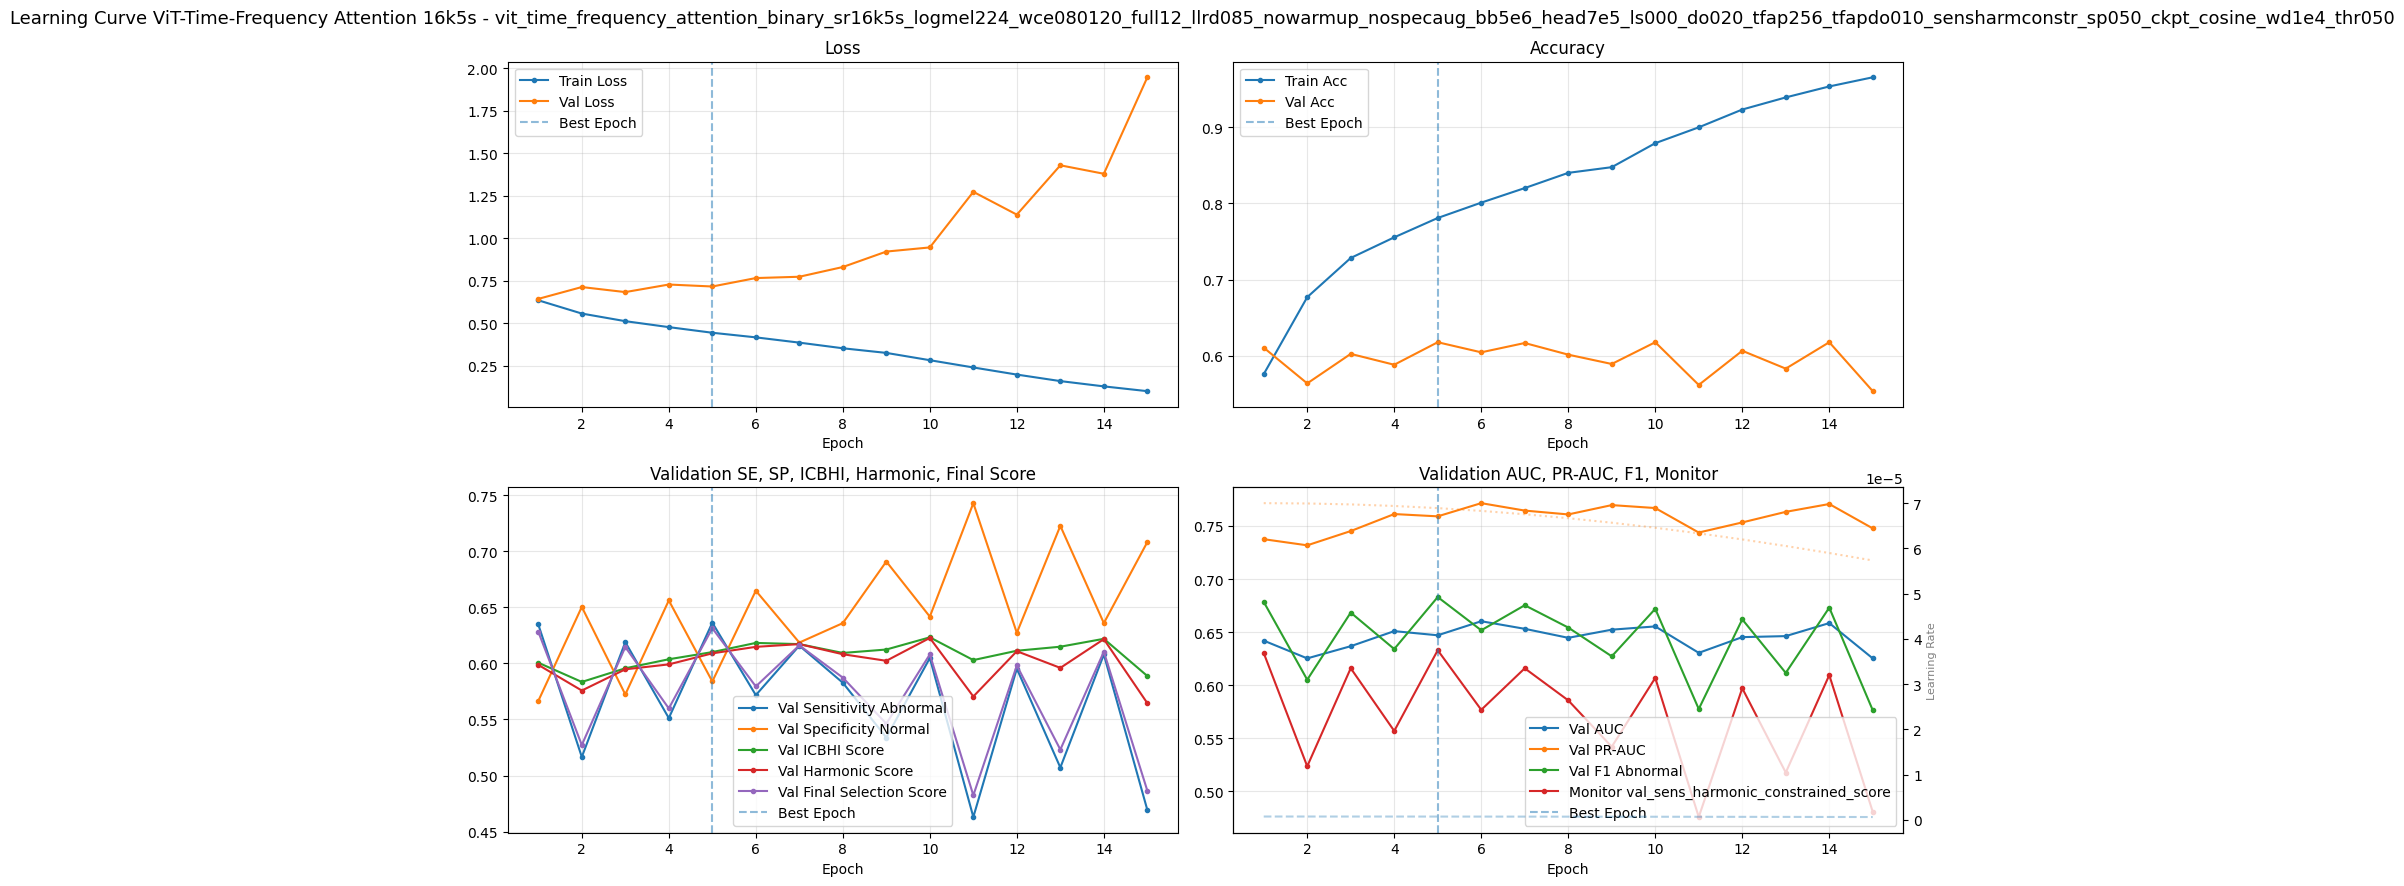

Learning curve disimpan di: checkpoints_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_learning_curve.png

[OK] Training loop ViT-Time-Frequency Attention 16k5s selesai dengan checkpoint monitor: val_sens_harmonic_constrained_score.


In [22]:
# ============================================================
# CELL 37: TRAINING LOOP + EARLY STOPPING
# ViT-B/16 + TIME-FREQUENCY ATTENTION POOLING 16k5s
# Full-layer ViT-B/16 + TF Attention Pooling + LLRD + Cosine
# Binary Normal-Abnormal ICBHI 2017
# ============================================================

import os
import time
import copy
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print


# ============================================================
# 0. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def json_safe_value(x):
    if isinstance(x, (np.integer,)):
        return int(x)

    if isinstance(x, (np.floating,)):
        x = float(x)
        if np.isnan(x):
            return None
        return x

    if isinstance(x, float):
        if np.isnan(x):
            return None
        return x

    if isinstance(x, np.ndarray):
        return x.tolist()

    if isinstance(x, torch.Tensor):
        return x.detach().cpu().tolist()

    if isinstance(x, Path):
        return str(x)

    if isinstance(x, dict):
        return {str(k): json_safe_value(v) for k, v in x.items()}

    if isinstance(x, (list, tuple)):
        return [json_safe_value(v) for v in x]

    return x


def json_safe_dict(d):
    return {str(k): json_safe_value(v) for k, v in d.items()}


def safe_float_or_nan(x):
    try:
        x = float(x)
        if np.isnan(x):
            return np.nan
        return x
    except Exception:
        return np.nan


def infer_monitor_mode(monitor_name):
    monitor_name = str(monitor_name).strip().lower()

    if monitor_name in {"val_loss", "train_loss"}:
        return "min"

    return "max"


def get_monitor_value(metric_row, monitor_name):
    if monitor_name not in metric_row:
        available = sorted(metric_row.keys())
        raise KeyError(
            f"Monitor {monitor_name} tidak ditemukan. "
            f"Monitor tersedia: {available}"
        )

    value = metric_row[monitor_name]

    try:
        value = float(value)
    except Exception:
        raise ValueError(
            f"Nilai monitor {monitor_name} tidak bisa dikonversi ke float: {value}"
        )

    if np.isnan(value):
        raise ValueError(f"Nilai monitor {monitor_name} adalah NaN.")

    return value


def init_best_value(mode):
    if mode == "min":
        return float("inf")

    if mode == "max":
        return -float("inf")

    raise ValueError(f"Mode monitor tidak valid: {mode}")


def is_improved(current_value, best_value, mode, min_delta):
    current_value = float(current_value)
    best_value = float(best_value)
    min_delta = float(min_delta)

    if mode == "min":
        return current_value < best_value - min_delta

    if mode == "max":
        return current_value > best_value + min_delta

    raise ValueError(f"Mode monitor tidak valid: {mode}")


def format_metric(x):
    try:
        x = float(x)
        if np.isnan(x):
            return "nan"
        return f"{x:.4f}"
    except Exception:
        return str(x)


def sensitivity_constrained_score(
    sensitivity_abnormal,
    specificity_normal,
    min_specificity_normal=None,
):
    sensitivity_abnormal = float(sensitivity_abnormal)
    specificity_normal = float(specificity_normal)

    if min_specificity_normal is None:
        min_specificity_normal = float(
            globals().get("MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT", 0.50)
        )

    if specificity_normal >= float(min_specificity_normal):
        return sensitivity_abnormal

    return 0.0


def sens_harmonic_constrained_score(
    sensitivity_abnormal,
    specificity_normal,
    harmonic_score,
    min_specificity_normal=None,
    sensitivity_weight=None,
    harmonic_weight=None,
):
    sensitivity_abnormal = float(sensitivity_abnormal)
    specificity_normal = float(specificity_normal)
    harmonic_score = float(harmonic_score)

    if min_specificity_normal is None:
        min_specificity_normal = float(
            globals().get("MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT", 0.50)
        )

    if sensitivity_weight is None:
        sensitivity_weight = float(
            globals().get("SENS_HARMONIC_SENS_WEIGHT", 0.70)
        )

    if harmonic_weight is None:
        harmonic_weight = float(
            globals().get("SENS_HARMONIC_HARM_WEIGHT", 0.30)
        )

    if specificity_normal < float(min_specificity_normal):
        return 0.0

    return (
        float(sensitivity_weight) * sensitivity_abnormal +
        float(harmonic_weight) * harmonic_score
    )


def final_selection_score(
    sensitivity_abnormal,
    specificity_normal,
    harmonic_score,
    min_specificity_normal=None,
    sensitivity_weight=None,
    harmonic_weight=None,
):
    sensitivity_abnormal = float(sensitivity_abnormal)
    specificity_normal = float(specificity_normal)
    harmonic_score = float(harmonic_score)

    if min_specificity_normal is None:
        min_specificity_normal = float(
            globals().get("MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT", 0.50)
        )

    if sensitivity_weight is None:
        sensitivity_weight = float(
            globals().get("FINAL_SCORE_SENS_WEIGHT", 0.60)
        )

    if harmonic_weight is None:
        harmonic_weight = float(
            globals().get("FINAL_SCORE_HARM_WEIGHT", 0.40)
        )

    if specificity_normal < float(min_specificity_normal):
        return 0.0

    return (
        float(sensitivity_weight) * sensitivity_abnormal +
        float(harmonic_weight) * harmonic_score
    )


# ============================================================
# 1. VALIDASI GLOBAL WAJIB
# ============================================================

required_globals = [
    "model",
    "optimizer",
    "scheduler",
    "scaler",
    "criterion",
    "run_one_epoch",

    "train_loader",
    "val_loader",

    "DEVICE",
    "SAVE_DIR",
    "SCENARIO_NAME",

    "NUM_EPOCHS",
    "PATIENCE",
    "BATCH_SIZE",

    "label2id",
    "id2label",
    "NUM_CLASSES",
    "CLASSES",
    "LABEL_COL",

    "BEST_MODEL_PATH",
    "LAST_MODEL_PATH",
    "HISTORY_CSV_PATH",
    "LEARNING_CURVE_PATH",

    "LEARNING_RATE",
    "LR_BACKBONE",
    "LR_HEAD",
    "WEIGHT_DECAY",

    "ETA_MIN",

    "LOSS_NAME",
    "USE_CLASS_WEIGHT",
    "CLASS_WEIGHT_METHOD",

    "CHECKPOINT_MONITOR",
    "EARLY_STOPPING_MONITOR",
    "CHECKPOINT_MODE",

    "TARGET_SR",
    "TARGET_DURATION_SEC",
    "TARGET_LEN_SAMPLES",
    "N_MELS",
    "FMIN",
    "FMAX",
    "N_FFT",
    "HOP_LENGTH",
    "WIN_LENGTH",
    "IMAGE_SIZE",

    "VIT_PATCH_SIZE",
    "VIT_PATCH_GRID_SIZE",
    "VIT_NUM_PATCHES",
    "VIT_EMBED_DIM",

    "TF_ATTN_INPUT_DIM",
    "TF_ATTN_HIDDEN_DIM",
    "TF_ATTN_DROPOUT",
    "TF_ATTN_POOLING",
    "TF_ATTN_NUM_PATCHES",
    "TF_ATTN_ACTIVATION",
    "CLASSIFIER_INPUT_DIM",
]

missing_globals = [g for g in required_globals if g not in globals()]

if missing_globals:
    raise RuntimeError(
        f"Global berikut belum tersedia: {missing_globals}\n"
        "Jalankan Cell 25, cell metadata, Cell 33, dan Cell 35 Time-Frequency Attention terlebih dahulu."
    )


# ============================================================
# 2. VALIDASI KONFIGURASI DATA, LABEL, DAN MODEL
# ============================================================

if LABEL_COL != "binary_label":
    raise ValueError(f"LABEL_COL harus binary_label. Saat ini: {LABEL_COL}")

if list(CLASSES) != ["normal", "abnormal"]:
    raise ValueError(f"CLASSES harus ['normal', 'abnormal']. Saat ini: {CLASSES}")

if int(NUM_CLASSES) != 2:
    raise ValueError(f"NUM_CLASSES harus 2. Saat ini: {NUM_CLASSES}")

POS_LABEL = globals().get("POS_LABEL", "abnormal")
NEG_LABEL = globals().get("NEG_LABEL", "normal")

POS_LABEL_ID = int(label2id[POS_LABEL])
NEG_LABEL_ID = int(label2id[NEG_LABEL])

if NEG_LABEL_ID != 0 or POS_LABEL_ID != 1:
    raise ValueError(
        f"Label mapping salah. normal harus 0 dan abnormal harus 1. "
        f"Saat ini normal={NEG_LABEL_ID}, abnormal={POS_LABEL_ID}"
    )

TARGET_SR = int(TARGET_SR)
TARGET_DURATION_SEC = float(TARGET_DURATION_SEC)
TARGET_LEN_SAMPLES = int(TARGET_LEN_SAMPLES)
N_MELS = int(N_MELS)
FMIN = int(FMIN)
FMAX = int(FMAX)
N_FFT = int(N_FFT)
HOP_LENGTH = int(HOP_LENGTH)
WIN_LENGTH = int(WIN_LENGTH)
IMAGE_SIZE = int(IMAGE_SIZE)

assert TARGET_SR == 16000, f"TARGET_SR harus 16000. Saat ini: {TARGET_SR}"

assert abs(TARGET_DURATION_SEC - 5.0) <= 1e-12, (
    f"TARGET_DURATION_SEC harus 5.0. Saat ini: {TARGET_DURATION_SEC}"
)

assert TARGET_LEN_SAMPLES == 80000, (
    f"TARGET_LEN_SAMPLES harus 80000. Saat ini: {TARGET_LEN_SAMPLES}"
)

assert N_MELS == 224, f"N_MELS harus 224. Saat ini: {N_MELS}"

assert FMIN == 0, (
    f"FMIN harus 0 sesuai metadata citra yang sudah dibuat. Saat ini: {FMIN}. "
    "Jika ingin FMIN=50, citra harus dikonversi ulang."
)

assert FMAX == 8000, (
    f"FMAX harus 8000 sesuai metadata citra yang sudah dibuat. Saat ini: {FMAX}. "
    "Jika ingin FMAX=2000, citra harus dikonversi ulang."
)

assert N_FFT == 2048, f"N_FFT harus 2048. Saat ini: {N_FFT}"
assert HOP_LENGTH == 128, f"HOP_LENGTH harus 128. Saat ini: {HOP_LENGTH}"
assert WIN_LENGTH == 2048, f"WIN_LENGTH harus 2048. Saat ini: {WIN_LENGTH}"
assert IMAGE_SIZE == 224, f"IMAGE_SIZE harus 224. Saat ini: {IMAGE_SIZE}"

USE_SPEC_AUGMENT = bool(globals().get("USE_SPEC_AUGMENT", False))
if USE_SPEC_AUGMENT:
    raise AssertionError(
        "USE_SPEC_AUGMENT harus False untuk skenario ViT-Time-Frequency Attention ini."
    )

MODEL_FAMILY = globals().get("MODEL_FAMILY", "ViT-TimeFrequencyAttention")
MODEL_NAME = globals().get("MODEL_NAME", "ViT-B/16 + Time-Frequency Attention Pooling")
MODEL_CLAIM = globals().get(
    "MODEL_CLAIM",
    "Hybrid ViT-B/16 and Time-Frequency Attention Pooling using all patch-token representations.",
)

model_family_lower = str(MODEL_FAMILY).lower()
model_name_lower = str(MODEL_NAME).lower()

is_tf_attention_model = (
    ("timefrequency" in model_family_lower)
    or ("time-frequency" in model_family_lower)
    or ("time frequency" in model_family_lower)
    or ("time-frequency" in model_name_lower)
    or ("time frequency" in model_name_lower)
)

if not is_tf_attention_model:
    raise AssertionError(
        f"Identitas model belum sesuai Time-Frequency Attention. "
        f"MODEL_FAMILY={MODEL_FAMILY}, MODEL_NAME={MODEL_NAME}"
    )

VIT_PATCH_SIZE = int(VIT_PATCH_SIZE)
VIT_PATCH_GRID_SIZE = int(VIT_PATCH_GRID_SIZE)
VIT_NUM_PATCHES = int(VIT_NUM_PATCHES)
VIT_EMBED_DIM = int(VIT_EMBED_DIM)

TF_ATTN_INPUT_DIM = int(TF_ATTN_INPUT_DIM)
TF_ATTN_HIDDEN_DIM = int(TF_ATTN_HIDDEN_DIM)
TF_ATTN_DROPOUT = float(TF_ATTN_DROPOUT)
TF_ATTN_POOLING = str(TF_ATTN_POOLING).lower().strip()
TF_ATTN_NUM_PATCHES = int(TF_ATTN_NUM_PATCHES)
TF_ATTN_ACTIVATION = str(TF_ATTN_ACTIVATION).lower().strip()
CLASSIFIER_INPUT_DIM = int(CLASSIFIER_INPUT_DIM)

assert VIT_PATCH_SIZE == 16, f"VIT_PATCH_SIZE harus 16. Saat ini: {VIT_PATCH_SIZE}"
assert VIT_PATCH_GRID_SIZE == 14, f"VIT_PATCH_GRID_SIZE harus 14. Saat ini: {VIT_PATCH_GRID_SIZE}"
assert VIT_NUM_PATCHES == 196, f"VIT_NUM_PATCHES harus 196. Saat ini: {VIT_NUM_PATCHES}"
assert VIT_EMBED_DIM == 768, f"VIT_EMBED_DIM harus 768. Saat ini: {VIT_EMBED_DIM}"

assert TF_ATTN_INPUT_DIM == VIT_EMBED_DIM, (
    f"TF_ATTN_INPUT_DIM harus sama dengan VIT_EMBED_DIM. "
    f"Saat ini TF_ATTN_INPUT_DIM={TF_ATTN_INPUT_DIM}, VIT_EMBED_DIM={VIT_EMBED_DIM}"
)

assert TF_ATTN_NUM_PATCHES == VIT_NUM_PATCHES, (
    f"TF_ATTN_NUM_PATCHES harus sama dengan VIT_NUM_PATCHES. "
    f"Saat ini TF_ATTN_NUM_PATCHES={TF_ATTN_NUM_PATCHES}, VIT_NUM_PATCHES={VIT_NUM_PATCHES}"
)

assert CLASSIFIER_INPUT_DIM == TF_ATTN_INPUT_DIM, (
    f"CLASSIFIER_INPUT_DIM harus {TF_ATTN_INPUT_DIM}. Saat ini: {CLASSIFIER_INPUT_DIM}"
)


# ============================================================
# 3. VALIDASI OPTIMIZER, LOSS, SCHEDULER
# ============================================================

optimizer_name = optimizer.__class__.__name__
scheduler_name = scheduler.__class__.__name__ if scheduler is not None else "None"
scheduler_name_runtime = globals().get("scheduler_name_runtime", scheduler_name)

criterion_name = globals().get(
    "criterion_runtime_name",
    criterion.__class__.__name__,
)

LOSS_NAME = str(LOSS_NAME).lower().strip()

if optimizer_name != "AdamW":
    raise AssertionError(f"Optimizer harus AdamW. Saat ini: {optimizer_name}")

valid_criterion_runtime = {
    "CrossEntropyLoss",
    "WeightedCrossEntropyLoss",
    "FocalLossWithLabelSmoothing",
}

if criterion_name not in valid_criterion_runtime:
    raise AssertionError(
        f"Loss runtime harus salah satu dari {valid_criterion_runtime}. "
        f"Saat ini: {criterion_name}"
    )

if LOSS_NAME == "ce":
    if bool(USE_CLASS_WEIGHT):
        raise AssertionError("USE_CLASS_WEIGHT harus False saat LOSS_NAME='ce'.")

    if getattr(criterion, "weight", None) is not None:
        raise AssertionError("criterion.weight harus None untuk CE baseline.")

elif LOSS_NAME == "weighted_ce":
    if not bool(USE_CLASS_WEIGHT):
        raise AssertionError("USE_CLASS_WEIGHT harus True saat LOSS_NAME='weighted_ce'.")

    if criterion_name != "WeightedCrossEntropyLoss":
        raise AssertionError(
            f"criterion_runtime_name harus WeightedCrossEntropyLoss untuk weighted_ce. "
            f"Saat ini: {criterion_name}"
        )

    if getattr(criterion, "weight", None) is None:
        raise AssertionError(
            "criterion.weight tidak boleh None untuk Weighted Cross Entropy."
        )

elif LOSS_NAME == "focal":
    if bool(USE_CLASS_WEIGHT):
        raise AssertionError("USE_CLASS_WEIGHT harus False saat LOSS_NAME='focal'.")

    if criterion_name != "FocalLossWithLabelSmoothing":
        raise AssertionError(
            f"criterion_runtime_name harus FocalLossWithLabelSmoothing untuk focal. "
            f"Saat ini: {criterion_name}"
        )

else:
    raise ValueError(
        f"LOSS_NAME tidak valid: {LOSS_NAME}. Gunakan 'ce', 'weighted_ce', atau 'focal'."
    )

valid_scheduler_runtime = {
    "CosineAnnealingLR",
    "SequentialLR",
}

if scheduler_name not in valid_scheduler_runtime:
    raise AssertionError(
        f"Scheduler runtime harus salah satu dari {valid_scheduler_runtime}. "
        f"Saat ini: {scheduler_name}."
    )

SCHEDULER_NAME = str(globals().get("SCHEDULER_NAME", scheduler_name_runtime))
WARMUP_EPOCHS = int(globals().get("WARMUP_EPOCHS", 0))

if SCHEDULER_NAME == "CosineAnnealingLR":
    if WARMUP_EPOCHS != 0:
        raise AssertionError(
            f"CosineAnnealingLR tanpa warmup membutuhkan WARMUP_EPOCHS=0. "
            f"Saat ini: {WARMUP_EPOCHS}"
        )

    if scheduler_name != "CosineAnnealingLR":
        raise AssertionError(
            f"Runtime scheduler harus CosineAnnealingLR. Saat ini: {scheduler_name}"
        )

elif SCHEDULER_NAME == "LinearWarmupCosine":
    if WARMUP_EPOCHS <= 0:
        raise AssertionError("LinearWarmupCosine membutuhkan WARMUP_EPOCHS > 0.")

    if scheduler_name != "SequentialLR":
        raise AssertionError(
            f"Runtime scheduler harus SequentialLR untuk LinearWarmupCosine. Saat ini: {scheduler_name}"
        )

else:
    raise ValueError(f"SCHEDULER_NAME tidak valid: {SCHEDULER_NAME}")

optimizer_lrs_start = [float(pg["lr"]) for pg in optimizer.param_groups]
optimizer_group_names = [
    str(pg.get("name", f"group_{i}"))
    for i, pg in enumerate(optimizer.param_groups)
]

if len(optimizer.param_groups) < 1:
    raise AssertionError("Optimizer tidak memiliki parameter group.")

if float(LR_BACKBONE) <= 0 or float(LR_HEAD) <= 0:
    raise AssertionError("LR_BACKBONE dan LR_HEAD harus positif.")

classifier_lrs = [
    float(pg["lr"])
    for pg in optimizer.param_groups
    if pg.get("name", "") == "classification_head"
]

tf_attention_lrs = [
    float(pg["lr"])
    for pg in optimizer.param_groups
    if pg.get("name", "") == "time_frequency_attention_head"
]

if len(classifier_lrs) != 1:
    raise AssertionError("classification_head param group tidak ditemukan atau duplikat.")

if len(tf_attention_lrs) != 1:
    raise AssertionError("time_frequency_attention_head param group tidak ditemukan atau duplikat.")

if abs(classifier_lrs[0] - float(LR_HEAD)) > 1e-12:
    raise AssertionError(
        f"LR classification_head tidak sesuai. Dapat {classifier_lrs[0]}, "
        f"seharusnya {LR_HEAD}."
    )

if abs(tf_attention_lrs[0] - float(LR_HEAD)) > 1e-12:
    raise AssertionError(
        f"LR time_frequency_attention_head tidak sesuai. Dapat {tf_attention_lrs[0]}, "
        f"seharusnya {LR_HEAD}."
    )


# ============================================================
# 4. PATH OUTPUT
# ============================================================

SAVE_DIR = Path(SAVE_DIR)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = Path(BEST_MODEL_PATH)
LAST_MODEL_PATH = Path(LAST_MODEL_PATH)
HISTORY_CSV_PATH = Path(HISTORY_CSV_PATH)
LEARNING_CURVE_PATH = Path(LEARNING_CURVE_PATH)


# ============================================================
# 5. KONFIGURASI CHECKPOINT DAN EARLY STOPPING
# ============================================================

CHECKPOINT_MONITOR = str(globals().get("CHECKPOINT_MONITOR", "val_loss"))
EARLY_STOPPING_MONITOR = str(globals().get("EARLY_STOPPING_MONITOR", CHECKPOINT_MONITOR))
CHECKPOINT_MODE = str(globals().get("CHECKPOINT_MODE", infer_monitor_mode(CHECKPOINT_MONITOR)))

EARLY_STOPPING_MODE = str(
    globals().get(
        "EARLY_STOPPING_MODE",
        infer_monitor_mode(EARLY_STOPPING_MONITOR),
    )
)

PATIENCE = int(globals().get("PATIENCE", 5))
EARLY_STOP_MIN_DELTA = float(globals().get("EARLY_STOP_MIN_DELTA", 1e-4))

if PATIENCE < 1:
    raise AssertionError(f"PATIENCE tidak valid: {PATIENCE}")

MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT = float(
    globals().get("MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT", 0.50)
)

MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD = float(
    globals().get(
        "MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD",
        globals().get("SPECIFICITY_SAFE_MIN", 0.50),
    )
)

TARGET_SENSITIVITY_ABNORMAL = float(
    globals().get("TARGET_SENSITIVITY_ABNORMAL", 0.80)
)

FINAL_SCORE_SENS_WEIGHT = float(
    globals().get("FINAL_SCORE_SENS_WEIGHT", 0.60)
)

FINAL_SCORE_HARM_WEIGHT = float(
    globals().get("FINAL_SCORE_HARM_WEIGHT", 0.40)
)

weight_sum = FINAL_SCORE_SENS_WEIGHT + FINAL_SCORE_HARM_WEIGHT

if abs(weight_sum - 1.0) > 1e-6:
    raise AssertionError(
        "FINAL_SCORE_SENS_WEIGHT + FINAL_SCORE_HARM_WEIGHT harus 1.0. "
        f"Saat ini: {FINAL_SCORE_SENS_WEIGHT} + {FINAL_SCORE_HARM_WEIGHT} = {weight_sum}."
    )

if not (0.0 <= MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT <= 1.0):
    raise AssertionError(
        f"MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT tidak valid: "
        f"{MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT}"
    )

if not (0.0 <= MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD <= 1.0):
    raise AssertionError(
        f"MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD tidak valid: "
        f"{MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD}"
    )

VALID_MONITORS = {
    "val_loss",
    "val_acc",
    "val_accuracy",
    "val_sensitivity_abnormal",
    "val_specificity_normal",
    "val_precision_abnormal",
    "val_f1_abnormal",
    "val_balanced_score",
    "val_icbhi_score",
    "val_harmonic_score",
    "val_sensitivity_constrained_score",
    "val_sens_harmonic_constrained_score",
    "val_final_selection_score",
    "val_auc",
    "val_pr_auc",
}

if CHECKPOINT_MONITOR not in VALID_MONITORS:
    raise AssertionError(f"CHECKPOINT_MONITOR tidak valid: {CHECKPOINT_MONITOR}")

if EARLY_STOPPING_MONITOR not in VALID_MONITORS:
    raise AssertionError(
        f"EARLY_STOPPING_MONITOR tidak valid: {EARLY_STOPPING_MONITOR}"
    )

expected_checkpoint_mode = infer_monitor_mode(CHECKPOINT_MONITOR)
expected_early_mode = infer_monitor_mode(EARLY_STOPPING_MONITOR)

if CHECKPOINT_MODE != expected_checkpoint_mode:
    raise AssertionError(
        f"CHECKPOINT_MODE tidak cocok. "
        f"Monitor {CHECKPOINT_MONITOR} harus mode {expected_checkpoint_mode}, "
        f"tetapi saat ini {CHECKPOINT_MODE}."
    )

if EARLY_STOPPING_MODE != expected_early_mode:
    raise AssertionError(
        f"EARLY_STOPPING_MODE tidak cocok. "
        f"Monitor {EARLY_STOPPING_MONITOR} harus mode {expected_early_mode}, "
        f"tetapi saat ini {EARLY_STOPPING_MODE}."
    )

monitor_suffix = str(CHECKPOINT_MONITOR).replace("val_", "").replace("_", "")

BEST_SUMMARY_PATH = SAVE_DIR / f"{SCENARIO_NAME}_best_{monitor_suffix}_summary.json"
TRAINING_CONFIG_PATH = SAVE_DIR / f"{SCENARIO_NAME}_training_config.json"
TRAINING_FINAL_SUMMARY_PATH = SAVE_DIR / f"{SCENARIO_NAME}_training_final_summary.json"

globals()["CHECKPOINT_MONITOR"] = CHECKPOINT_MONITOR
globals()["EARLY_STOPPING_MONITOR"] = EARLY_STOPPING_MONITOR
globals()["CHECKPOINT_MODE"] = CHECKPOINT_MODE
globals()["EARLY_STOPPING_MODE"] = EARLY_STOPPING_MODE
globals()["EARLY_STOP_MIN_DELTA"] = EARLY_STOP_MIN_DELTA
globals()["PATIENCE"] = PATIENCE
globals()["MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT"] = MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT
globals()["MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD"] = MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD
globals()["TARGET_SENSITIVITY_ABNORMAL"] = TARGET_SENSITIVITY_ABNORMAL
globals()["FINAL_SCORE_SENS_WEIGHT"] = FINAL_SCORE_SENS_WEIGHT
globals()["FINAL_SCORE_HARM_WEIGHT"] = FINAL_SCORE_HARM_WEIGHT

print("=" * 90)
print("CHECKPOINT & EARLY STOPPING POLICY")
print("=" * 90)
print("Checkpoint monitor              :", CHECKPOINT_MONITOR)
print("Early stopping monitor          :", EARLY_STOPPING_MONITOR)
print("Checkpoint mode                 :", CHECKPOINT_MODE)
print("Early stopping mode             :", EARLY_STOPPING_MODE)
print("Patience                        :", PATIENCE)
print("Early stop min delta            :", EARLY_STOP_MIN_DELTA)
print("Min specificity checkpoint      :", MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT)
print("Min specificity threshold       :", MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD)
print("Target sensitivity abnormal     :", TARGET_SENSITIVITY_ABNORMAL)
print("Final score sensitivity weight  :", FINAL_SCORE_SENS_WEIGHT)
print("Final score harmonic weight     :", FINAL_SCORE_HARM_WEIGHT)
print("=" * 90)


# ============================================================
# 6. INIT BEST STATE
# ============================================================

best_model_wts = copy.deepcopy(model.state_dict())
best_epoch = 0

best_checkpoint_value = init_best_value(CHECKPOINT_MODE)
best_early_stop_value = init_best_value(EARLY_STOPPING_MODE)

best_metrics = {}
epochs_no_improve = 0
history = []

training_started_at = time.strftime("%Y-%m-%d %H:%M:%S")


# ============================================================
# 7. SIMPAN KONFIGURASI TRAINING
# ============================================================

criterion_weights_runtime = globals().get("criterion_weights_runtime", None)

CLASS_WEIGHT_METHOD_EFFECTIVE = globals().get(
    "CLASS_WEIGHT_METHOD_EFFECTIVE",
    CLASS_WEIGHT_METHOD,
)

training_config = {
    "scenario_name": SCENARIO_NAME,
    "model_family": MODEL_FAMILY,
    "model_name": MODEL_NAME,
    "model_claim": MODEL_CLAIM,

    "vit_patch_size": VIT_PATCH_SIZE,
    "vit_patch_grid_size": VIT_PATCH_GRID_SIZE,
    "vit_num_patches": VIT_NUM_PATCHES,
    "vit_embed_dim": VIT_EMBED_DIM,

    "tf_attn_input_dim": TF_ATTN_INPUT_DIM,
    "tf_attn_hidden_dim": TF_ATTN_HIDDEN_DIM,
    "tf_attn_dropout": TF_ATTN_DROPOUT,
    "tf_attn_pooling": TF_ATTN_POOLING,
    "tf_attn_num_patches": TF_ATTN_NUM_PATCHES,
    "tf_attn_activation": TF_ATTN_ACTIVATION,
    "classifier_input_dim": CLASSIFIER_INPUT_DIM,

    "classes": CLASSES,
    "label_col": LABEL_COL,
    "positive_label": POS_LABEL,
    "negative_label": NEG_LABEL,

    "target_sr": int(TARGET_SR),
    "target_duration_sec": float(TARGET_DURATION_SEC),
    "target_len_samples": int(TARGET_LEN_SAMPLES),
    "n_mels": int(N_MELS),
    "fmin": int(FMIN),
    "fmax": int(FMAX),
    "n_fft": int(N_FFT),
    "hop_length": int(HOP_LENGTH),
    "win_length": int(WIN_LENGTH),
    "image_size": int(IMAGE_SIZE),
    "image_colormap": str(globals().get("IMAGE_COLORMAP", "magma")),
    "image_mode": str(globals().get("IMAGE_MODE", "rgb")),

    "loss_name": LOSS_NAME,
    "criterion_runtime": criterion_name,
    "criterion_weights_runtime": criterion_weights_runtime,
    "use_class_weight": bool(USE_CLASS_WEIGHT),
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_method_effective": CLASS_WEIGHT_METHOD_EFFECTIVE,

    "optimizer": optimizer_name,
    "learning_rate": float(LEARNING_RATE),
    "lr_backbone": float(LR_BACKBONE),
    "lr_head": float(LR_HEAD),
    "weight_decay": float(WEIGHT_DECAY),
    "optimizer_lrs_start": optimizer_lrs_start,
    "optimizer_group_names": optimizer_group_names,

    "use_layer_wise_lr_decay": bool(globals().get("USE_LAYER_WISE_LR_DECAY", False)),
    "layer_lr_decay": float(globals().get("LAYER_LR_DECAY", np.nan)),

    "scheduler": scheduler_name_runtime,
    "scheduler_runtime_class": scheduler_name,
    "scheduler_config": SCHEDULER_NAME,
    "warmup_epochs": int(WARMUP_EPOCHS),
    "warmup_start_factor": float(globals().get("WARMUP_START_FACTOR", np.nan)),
    "eta_min": float(ETA_MIN),

    "num_epochs": int(NUM_EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "patience": int(PATIENCE),
    "shuffle_train": bool(globals().get("SHUFFLE_TRAIN", True)),
    "use_weighted_random_sampler": bool(globals().get("USE_WEIGHTED_RANDOM_SAMPLER", False)),
    "use_spec_augment": bool(globals().get("USE_SPEC_AUGMENT", False)),

    "validation": "evaluate_validation_set_each_epoch",
    "checkpoint_monitor": CHECKPOINT_MONITOR,
    "checkpoint_mode": CHECKPOINT_MODE,
    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "early_stopping_mode": EARLY_STOPPING_MODE,
    "early_stop_min_delta": float(EARLY_STOP_MIN_DELTA),

    "target_sensitivity_abnormal": float(TARGET_SENSITIVITY_ABNORMAL),
    "min_specificity_normal_for_checkpoint": float(MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT),
    "min_specificity_normal_for_threshold": float(MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD),
    "final_selection_score_definition": (
        f"{FINAL_SCORE_SENS_WEIGHT:.2f} * val_sensitivity_abnormal + "
        f"{FINAL_SCORE_HARM_WEIGHT:.2f} * val_harmonic_score "
        "if val_specificity_normal >= min_specificity_normal_for_checkpoint else 0.0"
    ),

    "unfreeze_last_n_blocks": int(globals().get("UNFREEZE_LAST_N_BLOCKS", -1)),
    "head_dropout": float(globals().get("HEAD_DROPOUT", np.nan)),
    "label_smoothing": float(globals().get("LABEL_SMOOTHING", np.nan)),
    "max_grad_norm": globals().get("MAX_GRAD_NORM", None),

    "best_model_path": str(BEST_MODEL_PATH),
    "last_model_path": str(LAST_MODEL_PATH),
    "history_csv_path": str(HISTORY_CSV_PATH),
    "learning_curve_path": str(LEARNING_CURVE_PATH),

    "training_started_at": training_started_at,
}

with open(TRAINING_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(json_safe_dict(training_config), f, indent=2, ensure_ascii=False)


# ============================================================
# 8. INFO AWAL TRAINING
# ============================================================

print("=" * 90)
print("TRAINING ViT-TIME-FREQUENCY ATTENTION BINARY NORMAL-ABNORMAL 16k5s")
print("=" * 90)
print(f"SCENARIO_NAME                         : {SCENARIO_NAME}")
print(f"MODEL_FAMILY                          : {MODEL_FAMILY}")
print(f"MODEL_NAME                            : {MODEL_NAME}")
print(f"DEVICE                                : {DEVICE}")
print(f"Max epoch                             : {NUM_EPOCHS}")
print(f"Patience                              : {PATIENCE}")
print(f"Batch size                            : {BATCH_SIZE}")
print(f"Optimizer                             : {optimizer_name}")
print(f"Loss                                  : {criterion_name}")
print(f"LOSS_NAME                             : {LOSS_NAME}")
print(f"USE_CLASS_WEIGHT                      : {USE_CLASS_WEIGHT}")
print(f"Class weight method                   : {CLASS_WEIGHT_METHOD_EFFECTIVE}")
print(f"Criterion weights                     : {criterion_weights_runtime}")
print(f"Scheduler                             : {scheduler_name_runtime}")
print(f"Runtime scheduler class               : {scheduler_name}")
print(f"Warmup epochs                         : {WARMUP_EPOCHS}")
print(f"ETA min                               : {ETA_MIN}")
print(f"LR backbone                           : {LR_BACKBONE}")
print(f"LR head                               : {LR_HEAD}")
print(f"Weight decay                          : {WEIGHT_DECAY}")
print(f"LLRD                                  : {globals().get('USE_LAYER_WISE_LR_DECAY', False)}")
print(f"LLRD decay                            : {globals().get('LAYER_LR_DECAY', 'NA')}")
print(f"SpecAugment                           : {globals().get('USE_SPEC_AUGMENT', False)}")
print(f"Unfreeze last N blocks                : {globals().get('UNFREEZE_LAST_N_BLOCKS', 'NA')}")
print(f"Head dropout                          : {globals().get('HEAD_DROPOUT', 'NA')}")
print(f"Label smoothing                       : {globals().get('LABEL_SMOOTHING', 'NA')}")
print(f"FMIN                                  : {FMIN}")
print(f"FMAX                                  : {FMAX}")
print(f"ViT patch grid                        : {VIT_PATCH_GRID_SIZE} x {VIT_PATCH_GRID_SIZE}")
print(f"ViT num patches                       : {VIT_NUM_PATCHES}")
print(f"ViT embed dim                         : {VIT_EMBED_DIM}")
print(f"TF attention input dim                : {TF_ATTN_INPUT_DIM}")
print(f"TF attention hidden dim               : {TF_ATTN_HIDDEN_DIM}")
print(f"TF attention dropout                  : {TF_ATTN_DROPOUT}")
print(f"TF attention pooling                  : {TF_ATTN_POOLING}")
print(f"TF attention patches                  : {TF_ATTN_NUM_PATCHES}")
print(f"TF attention activation               : {TF_ATTN_ACTIVATION}")
print(f"Classifier input dim                  : {CLASSIFIER_INPUT_DIM}")
print(f"Checkpoint monitor                    : {CHECKPOINT_MONITOR}")
print(f"Early stopping monitor                : {EARLY_STOPPING_MONITOR}")
print(f"Checkpoint mode                       : {CHECKPOINT_MODE}")
print(f"Early stopping mode                   : {EARLY_STOPPING_MODE}")
print(f"Best model path                       : {BEST_MODEL_PATH}")
print(f"Last model path                       : {LAST_MODEL_PATH}")
print(f"History CSV                           : {HISTORY_CSV_PATH}")
print(f"Learning curve                        : {LEARNING_CURVE_PATH}")
print(f"Training config                       : {TRAINING_CONFIG_PATH}")
print("=" * 90)


# ============================================================
# 9. HELPER CHECKPOINT
# ============================================================

def save_checkpoint(
    path,
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    history,
    extra_payload=None,
):
    payload = {
        "epoch": int(epoch),

        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,

        "history": history,

        "scenario": SCENARIO_NAME,
        "model_family": MODEL_FAMILY,
        "model_name": MODEL_NAME,
        "model_claim": MODEL_CLAIM,

        "vit_patch_size": int(VIT_PATCH_SIZE),
        "vit_patch_grid_size": int(VIT_PATCH_GRID_SIZE),
        "vit_num_patches": int(VIT_NUM_PATCHES),
        "vit_embed_dim": int(VIT_EMBED_DIM),

        "tf_attn_input_dim": int(TF_ATTN_INPUT_DIM),
        "tf_attn_hidden_dim": int(TF_ATTN_HIDDEN_DIM),
        "tf_attn_dropout": float(TF_ATTN_DROPOUT),
        "tf_attn_pooling": str(TF_ATTN_POOLING),
        "tf_attn_num_patches": int(TF_ATTN_NUM_PATCHES),
        "tf_attn_activation": str(TF_ATTN_ACTIVATION),
        "classifier_input_dim": int(CLASSIFIER_INPUT_DIM),

        "classes": CLASSES,
        "label2id": label2id,
        "id2label": id2label,
        "label_col": LABEL_COL,
        "pos_label": POS_LABEL,
        "neg_label": NEG_LABEL,

        "target_sr": int(TARGET_SR),
        "target_duration_sec": float(TARGET_DURATION_SEC),
        "target_len_samples": int(TARGET_LEN_SAMPLES),
        "n_mels": int(N_MELS),
        "fmin": int(FMIN),
        "fmax": int(FMAX),
        "n_fft": int(N_FFT),
        "hop_length": int(HOP_LENGTH),
        "win_length": int(WIN_LENGTH),
        "image_size": int(IMAGE_SIZE),

        "checkpoint_monitor": CHECKPOINT_MONITOR,
        "checkpoint_mode": CHECKPOINT_MODE,
        "early_stopping_monitor": EARLY_STOPPING_MONITOR,
        "early_stopping_mode": EARLY_STOPPING_MODE,

        "loss_name": LOSS_NAME,
        "criterion_runtime": criterion_name,
        "class_weight_method": CLASS_WEIGHT_METHOD,
        "class_weight_method_effective": CLASS_WEIGHT_METHOD_EFFECTIVE,
        "criterion_weights": criterion_weights_runtime,

        "optimizer": optimizer_name,
        "learning_rate": float(LEARNING_RATE),
        "lr_backbone": float(LR_BACKBONE),
        "lr_head": float(LR_HEAD),
        "weight_decay": float(WEIGHT_DECAY),

        "use_layer_wise_lr_decay": bool(globals().get("USE_LAYER_WISE_LR_DECAY", False)),
        "layer_lr_decay": float(globals().get("LAYER_LR_DECAY", np.nan)),

        "scheduler": scheduler_name_runtime,
        "scheduler_runtime_class": scheduler_name,
        "scheduler_config": SCHEDULER_NAME,
        "warmup_epochs": int(WARMUP_EPOCHS),
        "eta_min": float(ETA_MIN),

        "num_epochs": int(NUM_EPOCHS),
        "patience": int(PATIENCE),

        "target_sensitivity_abnormal": float(TARGET_SENSITIVITY_ABNORMAL),
        "min_specificity_normal_for_checkpoint": float(MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT),
        "min_specificity_normal_for_threshold": float(MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD),
        "final_score_sens_weight": float(FINAL_SCORE_SENS_WEIGHT),
        "final_score_harm_weight": float(FINAL_SCORE_HARM_WEIGHT),

        "use_spec_augment": bool(globals().get("USE_SPEC_AUGMENT", False)),
        "unfreeze_last_n_blocks": int(globals().get("UNFREEZE_LAST_N_BLOCKS", -1)),
        "head_dropout": float(globals().get("HEAD_DROPOUT", np.nan)),
        "label_smoothing": float(globals().get("LABEL_SMOOTHING", np.nan)),
        "max_grad_norm": globals().get("MAX_GRAD_NORM", None),
    }

    if "AUTO_CLASS_WEIGHTS" in globals():
        payload["auto_class_weights_audit_only"] = globals()["AUTO_CLASS_WEIGHTS"]

    if "CLASS_WEIGHTS_LIST" in globals():
        payload["class_weights_list"] = globals()["CLASS_WEIGHTS_LIST"]

    if "CLASS_WEIGHTS_USED_DICT" in globals():
        payload["class_weights_used_dict"] = globals()["CLASS_WEIGHTS_USED_DICT"]

    if "DATASET_MEAN" in globals():
        payload["dataset_mean"] = globals()["DATASET_MEAN"]

    if "DATASET_STD" in globals():
        payload["dataset_std"] = globals()["DATASET_STD"]

    if "optimizer_group_report_df" in globals():
        payload["optimizer_group_report"] = globals()["optimizer_group_report_df"].to_dict(orient="records")

    if extra_payload is not None:
        payload.update(extra_payload)

    torch.save(payload, str(path))


# ============================================================
# 10. TRAINING LOOP
# ============================================================

for epoch in range(int(NUM_EPOCHS)):
    epoch_start = time.time()

    current_lrs = [float(pg["lr"]) for pg in optimizer.param_groups]
    current_lr_max = max(current_lrs)
    current_lr_min = min(current_lrs)

    classifier_lr_list = [
        float(pg["lr"])
        for pg in optimizer.param_groups
        if pg.get("name", "") == "classification_head"
    ]

    tf_attention_lr_list = [
        float(pg["lr"])
        for pg in optimizer.param_groups
        if pg.get("name", "") == "time_frequency_attention_head"
    ]

    current_lr_classifier = (
        classifier_lr_list[0]
        if len(classifier_lr_list) == 1
        else current_lrs[-1]
    )

    current_lr_time_frequency_attention = (
        tf_attention_lr_list[0]
        if len(tf_attention_lr_list) == 1
        else current_lrs[-1]
    )

    print(f"\n{'=' * 90}")
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"lr_min={current_lr_min:.3e} | "
        f"lr_max={current_lr_max:.3e} | "
        f"lr_tf_attn={current_lr_time_frequency_attention:.3e} | "
        f"lr_classifier={current_lr_classifier:.3e}"
    )
    print(f"{'=' * 90}")

    train_metrics = run_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE,
    )

    val_metrics = run_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        optimizer=None,
        scaler=None,
        device=DEVICE,
    )

    if scheduler is not None:
        scheduler.step()

    epoch_time = time.time() - epoch_start

    train_icbhi_score = float(train_metrics.get("icbhi_score", train_metrics["balanced_score"]))
    val_icbhi_score = float(val_metrics.get("icbhi_score", val_metrics["balanced_score"]))

    train_sensitivity_constrained_score = sensitivity_constrained_score(
        sensitivity_abnormal=train_metrics["sensitivity_abnormal"],
        specificity_normal=train_metrics["specificity_normal"],
        min_specificity_normal=MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
    )

    val_sensitivity_constrained_score = sensitivity_constrained_score(
        sensitivity_abnormal=val_metrics["sensitivity_abnormal"],
        specificity_normal=val_metrics["specificity_normal"],
        min_specificity_normal=MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
    )

    train_sens_harmonic_constrained_score = sens_harmonic_constrained_score(
        sensitivity_abnormal=train_metrics["sensitivity_abnormal"],
        specificity_normal=train_metrics["specificity_normal"],
        harmonic_score=train_metrics["harmonic_score"],
        min_specificity_normal=MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
    )

    val_sens_harmonic_constrained_score = sens_harmonic_constrained_score(
        sensitivity_abnormal=val_metrics["sensitivity_abnormal"],
        specificity_normal=val_metrics["specificity_normal"],
        harmonic_score=val_metrics["harmonic_score"],
        min_specificity_normal=MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
    )

    train_final_selection_score = final_selection_score(
        sensitivity_abnormal=train_metrics["sensitivity_abnormal"],
        specificity_normal=train_metrics["specificity_normal"],
        harmonic_score=train_metrics["harmonic_score"],
        min_specificity_normal=MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
        sensitivity_weight=FINAL_SCORE_SENS_WEIGHT,
        harmonic_weight=FINAL_SCORE_HARM_WEIGHT,
    )

    val_final_selection_score = final_selection_score(
        sensitivity_abnormal=val_metrics["sensitivity_abnormal"],
        specificity_normal=val_metrics["specificity_normal"],
        harmonic_score=val_metrics["harmonic_score"],
        min_specificity_normal=MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT,
        sensitivity_weight=FINAL_SCORE_SENS_WEIGHT,
        harmonic_weight=FINAL_SCORE_HARM_WEIGHT,
    )

    val_sensitivity_constraint_pass = bool(
        float(val_metrics["specificity_normal"]) >= float(MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT)
    )

    metric_row = {
        "val_loss": float(val_metrics["loss"]),
        "val_acc": float(val_metrics["acc"]),
        "val_accuracy": float(val_metrics.get("accuracy", val_metrics["acc"])),
        "val_sensitivity_abnormal": float(val_metrics["sensitivity_abnormal"]),
        "val_specificity_normal": float(val_metrics["specificity_normal"]),
        "val_precision_abnormal": float(val_metrics["precision_abnormal"]),
        "val_f1_abnormal": float(val_metrics["f1_abnormal"]),
        "val_balanced_score": float(val_metrics["balanced_score"]),
        "val_icbhi_score": float(val_icbhi_score),
        "val_harmonic_score": float(val_metrics["harmonic_score"]),
        "val_sensitivity_constrained_score": float(val_sensitivity_constrained_score),
        "val_sens_harmonic_constrained_score": float(val_sens_harmonic_constrained_score),
        "val_final_selection_score": float(val_final_selection_score),
        "val_auc": safe_float_or_nan(val_metrics["auc"]),
        "val_pr_auc": safe_float_or_nan(val_metrics["pr_auc"]),
    }

    current_checkpoint_value = get_monitor_value(metric_row, CHECKPOINT_MONITOR)
    current_early_stop_value = get_monitor_value(metric_row, EARLY_STOPPING_MONITOR)

    print(
        f"Train | "
        f"loss:{train_metrics['loss']:.4f}  "
        f"acc:{train_metrics['acc']:.4f}  "
        f"sens_abn:{train_metrics['sensitivity_abnormal']:.4f}  "
        f"spec_norm:{train_metrics['specificity_normal']:.4f}  "
        f"f1_abn:{train_metrics['f1_abnormal']:.4f}  "
        f"icbhi:{train_icbhi_score:.4f}  "
        f"harm:{train_metrics['harmonic_score']:.4f}  "
        f"final:{train_final_selection_score:.4f}  "
        f"auc:{format_metric(train_metrics['auc'])}  "
        f"pr_auc:{format_metric(train_metrics['pr_auc'])}"
    )

    print(
        f"  Val | "
        f"loss:{val_metrics['loss']:.4f}  "
        f"acc:{val_metrics['acc']:.4f}  "
        f"sens_abn:{val_metrics['sensitivity_abnormal']:.4f}  "
        f"spec_norm:{val_metrics['specificity_normal']:.4f}  "
        f"f1_abn:{val_metrics['f1_abnormal']:.4f}  "
        f"icbhi:{val_icbhi_score:.4f}  "
        f"sens_cons:{val_sensitivity_constrained_score:.4f}  "
        f"sens_harm:{val_sens_harmonic_constrained_score:.4f}  "
        f"final:{val_final_selection_score:.4f}  "
        f"constraint_pass:{val_sensitivity_constraint_pass}  "
        f"harm:{val_metrics['harmonic_score']:.4f}  "
        f"auc:{format_metric(val_metrics['auc'])}  "
        f"pr_auc:{format_metric(val_metrics['pr_auc'])}  "
        f"| monitor {CHECKPOINT_MONITOR}:{current_checkpoint_value:.4f}  "
        f"| early {EARLY_STOPPING_MONITOR}:{current_early_stop_value:.4f}  "
        f"| {epoch_time:.1f}s"
    )

    print(
        f"  Val CM | "
        f"TN:{val_metrics['tn']}  "
        f"FP:{val_metrics['fp']}  "
        f"FN:{val_metrics['fn']}  "
        f"TP:{val_metrics['tp']}"
    )

    row_history = {
        "epoch": epoch + 1,

        "lr_min": current_lr_min,
        "lr_max": current_lr_max,
        "lr_time_frequency_attention": current_lr_time_frequency_attention,
        "lr_classifier": current_lr_classifier,
        "lr_head": current_lr_classifier,
        "lr_groups": json.dumps(current_lrs),

        "train_loss": float(train_metrics["loss"]),
        "train_acc": float(train_metrics["acc"]),
        "train_accuracy": float(train_metrics.get("accuracy", train_metrics["acc"])),
        "train_sensitivity_abnormal": float(train_metrics["sensitivity_abnormal"]),
        "train_specificity_normal": float(train_metrics["specificity_normal"]),
        "train_precision_abnormal": float(train_metrics["precision_abnormal"]),
        "train_f1_abnormal": float(train_metrics["f1_abnormal"]),
        "train_balanced_score": float(train_metrics["balanced_score"]),
        "train_icbhi_score": float(train_icbhi_score),
        "train_harmonic_score": float(train_metrics["harmonic_score"]),
        "train_sensitivity_constrained_score": float(train_sensitivity_constrained_score),
        "train_sens_harmonic_constrained_score": float(train_sens_harmonic_constrained_score),
        "train_final_selection_score": float(train_final_selection_score),
        "train_auc": safe_float_or_nan(train_metrics["auc"]),
        "train_pr_auc": safe_float_or_nan(train_metrics["pr_auc"]),
        "train_tn": int(train_metrics["tn"]),
        "train_fp": int(train_metrics["fp"]),
        "train_fn": int(train_metrics["fn"]),
        "train_tp": int(train_metrics["tp"]),

        "val_loss": float(val_metrics["loss"]),
        "val_acc": float(val_metrics["acc"]),
        "val_accuracy": float(val_metrics.get("accuracy", val_metrics["acc"])),
        "val_sensitivity_abnormal": float(val_metrics["sensitivity_abnormal"]),
        "val_specificity_normal": float(val_metrics["specificity_normal"]),
        "val_precision_abnormal": float(val_metrics["precision_abnormal"]),
        "val_f1_abnormal": float(val_metrics["f1_abnormal"]),
        "val_balanced_score": float(val_metrics["balanced_score"]),
        "val_icbhi_score": float(val_icbhi_score),
        "val_harmonic_score": float(val_metrics["harmonic_score"]),
        "val_sensitivity_constrained_score": float(val_sensitivity_constrained_score),
        "val_sens_harmonic_constrained_score": float(val_sens_harmonic_constrained_score),
        "val_final_selection_score": float(val_final_selection_score),
        "val_sensitivity_constraint_pass": bool(val_sensitivity_constraint_pass),
        "val_auc": safe_float_or_nan(val_metrics["auc"]),
        "val_pr_auc": safe_float_or_nan(val_metrics["pr_auc"]),
        "val_tn": int(val_metrics["tn"]),
        "val_fp": int(val_metrics["fp"]),
        "val_fn": int(val_metrics["fn"]),
        "val_tp": int(val_metrics["tp"]),

        "checkpoint_monitor": CHECKPOINT_MONITOR,
        "checkpoint_monitor_value": float(current_checkpoint_value),
        "early_stopping_monitor": EARLY_STOPPING_MONITOR,
        "early_stopping_monitor_value": float(current_early_stop_value),
        "monitor_value": float(current_checkpoint_value),

        "epoch_time_sec": float(epoch_time),
    }

    history.append(row_history)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(HISTORY_CSV_PATH, index=False)

    save_checkpoint(
        path=LAST_MODEL_PATH,
        epoch=epoch + 1,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        history=history,
        extra_payload={
            "checkpoint_type": "last",
            "last_epoch_checkpoint_monitor": CHECKPOINT_MONITOR,
            "last_epoch_checkpoint_monitor_value": float(current_checkpoint_value),
            "last_epoch_early_stopping_monitor": EARLY_STOPPING_MONITOR,
            "last_epoch_early_stopping_monitor_value": float(current_early_stop_value),

            "last_epoch_val_loss": float(val_metrics["loss"]),
            "last_epoch_val_acc": float(val_metrics["acc"]),
            "last_epoch_val_sensitivity_abnormal": float(val_metrics["sensitivity_abnormal"]),
            "last_epoch_val_specificity_normal": float(val_metrics["specificity_normal"]),
            "last_epoch_val_balanced_score": float(val_metrics["balanced_score"]),
            "last_epoch_val_icbhi_score": float(val_icbhi_score),
            "last_epoch_val_harmonic_score": float(val_metrics["harmonic_score"]),
            "last_epoch_val_sensitivity_constrained_score": float(val_sensitivity_constrained_score),
            "last_epoch_val_sens_harmonic_constrained_score": float(val_sens_harmonic_constrained_score),
            "last_epoch_val_final_selection_score": float(val_final_selection_score),
            "last_epoch_val_sensitivity_constraint_pass": bool(val_sensitivity_constraint_pass),
        },
    )

    checkpoint_improved = is_improved(
        current_value=current_checkpoint_value,
        best_value=best_checkpoint_value,
        mode=CHECKPOINT_MODE,
        min_delta=EARLY_STOP_MIN_DELTA,
    )

    early_stop_improved = is_improved(
        current_value=current_early_stop_value,
        best_value=best_early_stop_value,
        mode=EARLY_STOPPING_MODE,
        min_delta=EARLY_STOP_MIN_DELTA,
    )

    if checkpoint_improved:
        best_epoch = epoch + 1
        best_checkpoint_value = float(current_checkpoint_value)
        best_model_wts = copy.deepcopy(model.state_dict())

        best_metrics = {
            "best_epoch": int(best_epoch),
            "best_monitor": CHECKPOINT_MONITOR,
            "best_monitor_value": float(best_checkpoint_value),

            "best_val_loss": float(val_metrics["loss"]),
            "best_val_acc": float(val_metrics["acc"]),
            "best_val_accuracy": float(val_metrics.get("accuracy", val_metrics["acc"])),
            "best_val_sensitivity_abnormal": float(val_metrics["sensitivity_abnormal"]),
            "best_val_specificity_normal": float(val_metrics["specificity_normal"]),
            "best_val_precision_abnormal": float(val_metrics["precision_abnormal"]),
            "best_val_f1_abnormal": float(val_metrics["f1_abnormal"]),
            "best_val_balanced_score": float(val_metrics["balanced_score"]),
            "best_val_icbhi_score": float(val_icbhi_score),
            "best_val_harmonic_score": float(val_metrics["harmonic_score"]),
            "best_val_sensitivity_constrained_score": float(val_sensitivity_constrained_score),
            "best_val_sens_harmonic_constrained_score": float(val_sens_harmonic_constrained_score),
            "best_val_final_selection_score": float(val_final_selection_score),
            "best_val_sensitivity_constraint_pass": bool(val_sensitivity_constraint_pass),
            "best_val_auc": safe_float_or_nan(val_metrics["auc"]),
            "best_val_pr_auc": safe_float_or_nan(val_metrics["pr_auc"]),
            "best_val_tn": int(val_metrics["tn"]),
            "best_val_fp": int(val_metrics["fp"]),
            "best_val_fn": int(val_metrics["fn"]),
            "best_val_tp": int(val_metrics["tp"]),
        }

        save_checkpoint(
            path=BEST_MODEL_PATH,
            epoch=epoch + 1,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            history=history,
            extra_payload={
                "checkpoint_type": f"best_{monitor_suffix}",
                "selection_rule": f"{CHECKPOINT_MODE}_{CHECKPOINT_MONITOR}",
                **best_metrics,
            },
        )

        best_summary = {
            "scenario": SCENARIO_NAME,
            "selection_rule": f"{CHECKPOINT_MODE}_{CHECKPOINT_MONITOR}",
            "checkpoint_monitor": CHECKPOINT_MONITOR,
            "checkpoint_mode": CHECKPOINT_MODE,
            **best_metrics,

            "model_family": MODEL_FAMILY,
            "model_name": MODEL_NAME,

            "vit_patch_size": int(VIT_PATCH_SIZE),
            "vit_patch_grid_size": int(VIT_PATCH_GRID_SIZE),
            "vit_num_patches": int(VIT_NUM_PATCHES),
            "vit_embed_dim": int(VIT_EMBED_DIM),

            "tf_attn_input_dim": int(TF_ATTN_INPUT_DIM),
            "tf_attn_hidden_dim": int(TF_ATTN_HIDDEN_DIM),
            "tf_attn_dropout": float(TF_ATTN_DROPOUT),
            "tf_attn_pooling": str(TF_ATTN_POOLING),
            "tf_attn_num_patches": int(TF_ATTN_NUM_PATCHES),
            "tf_attn_activation": str(TF_ATTN_ACTIVATION),
            "classifier_input_dim": int(CLASSIFIER_INPUT_DIM),

            "target_sr": int(TARGET_SR),
            "target_duration_sec": float(TARGET_DURATION_SEC),
            "target_len_samples": int(TARGET_LEN_SAMPLES),
            "n_mels": int(N_MELS),
            "fmin": int(FMIN),
            "fmax": int(FMAX),
            "n_fft": int(N_FFT),
            "hop_length": int(HOP_LENGTH),
            "win_length": int(WIN_LENGTH),
            "image_size": int(IMAGE_SIZE),

            "loss_name": LOSS_NAME,
            "criterion_runtime": criterion_name,
            "class_weight_method": CLASS_WEIGHT_METHOD,
            "class_weight_method_effective": CLASS_WEIGHT_METHOD_EFFECTIVE,
            "criterion_weights": criterion_weights_runtime,

            "optimizer": optimizer_name,
            "learning_rate": float(LEARNING_RATE),
            "lr_backbone": float(LR_BACKBONE),
            "lr_head": float(LR_HEAD),
            "weight_decay": float(WEIGHT_DECAY),

            "use_layer_wise_lr_decay": bool(globals().get("USE_LAYER_WISE_LR_DECAY", False)),
            "layer_lr_decay": float(globals().get("LAYER_LR_DECAY", np.nan)),

            "scheduler": scheduler_name_runtime,
            "scheduler_runtime_class": scheduler_name,
            "scheduler_config": SCHEDULER_NAME,
            "warmup_epochs": int(WARMUP_EPOCHS),
            "eta_min": float(ETA_MIN),

            "num_epochs": int(NUM_EPOCHS),
            "batch_size": int(BATCH_SIZE),
            "patience": int(PATIENCE),

            "target_sensitivity_abnormal": float(TARGET_SENSITIVITY_ABNORMAL),
            "min_specificity_normal_for_checkpoint": float(MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT),
            "min_specificity_normal_for_threshold": float(MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD),
            "final_score_sens_weight": float(FINAL_SCORE_SENS_WEIGHT),
            "final_score_harm_weight": float(FINAL_SCORE_HARM_WEIGHT),

            "use_spec_augment": bool(globals().get("USE_SPEC_AUGMENT", False)),
            "unfreeze_last_n_blocks": int(globals().get("UNFREEZE_LAST_N_BLOCKS", -1)),
            "head_dropout": float(globals().get("HEAD_DROPOUT", np.nan)),
            "label_smoothing": float(globals().get("LABEL_SMOOTHING", np.nan)),

            "best_model_path": str(BEST_MODEL_PATH),
        }

        with open(BEST_SUMMARY_PATH, "w", encoding="utf-8") as f:
            json.dump(json_safe_dict(best_summary), f, indent=2, ensure_ascii=False)

        print(
            f"  [OK] Best model diperbarui berdasarkan {CHECKPOINT_MONITOR} | "
            f"{CHECKPOINT_MONITOR}={best_checkpoint_value:.4f} | "
            f"loss={best_metrics['best_val_loss']:.4f} | "
            f"acc={best_metrics['best_val_acc']:.4f} | "
            f"sens={best_metrics['best_val_sensitivity_abnormal']:.4f} | "
            f"spec={best_metrics['best_val_specificity_normal']:.4f} | "
            f"final={best_metrics['best_val_final_selection_score']:.4f} | "
            f"icbhi={best_metrics['best_val_icbhi_score']:.4f} | "
            f"harm={best_metrics['best_val_harmonic_score']:.4f}"
        )

    if early_stop_improved:
        best_early_stop_value = float(current_early_stop_value)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

        print(
            f"  [--] Early stopping monitor tidak membaik | "
            f"monitor={EARLY_STOPPING_MONITOR} | "
            f"current={current_early_stop_value:.4f} | "
            f"best={best_early_stop_value:.4f} | "
            f"counter={epochs_no_improve}/{PATIENCE}"
        )

    if epochs_no_improve >= int(PATIENCE):
        print(
            f"\nEarly stopping aktif di epoch {epoch + 1}. "
            f"{EARLY_STOPPING_MONITOR} tidak membaik selama {PATIENCE} epoch berturut-turut."
        )
        break


# ============================================================
# 11. LOAD BEST MODEL
# ============================================================

if best_epoch == 0:
    raise RuntimeError(
        "best_epoch masih 0. Artinya tidak ada checkpoint best yang valid. "
        "Cek training loop dan nilai monitor validation."
    )

model.load_state_dict(best_model_wts)
model = model.to(DEVICE)

training_finished_at = time.strftime("%Y-%m-%d %H:%M:%S")


# ============================================================
# 12. RINGKASAN TRAINING
# ============================================================

final_summary = {
    "scenario": SCENARIO_NAME,
    "training_started_at": training_started_at,
    "training_finished_at": training_finished_at,
    "total_epoch_ran": len(history),

    **best_metrics,

    "model_family": MODEL_FAMILY,
    "model_name": MODEL_NAME,

    "vit_patch_size": int(VIT_PATCH_SIZE),
    "vit_patch_grid_size": int(VIT_PATCH_GRID_SIZE),
    "vit_num_patches": int(VIT_NUM_PATCHES),
    "vit_embed_dim": int(VIT_EMBED_DIM),

    "tf_attn_input_dim": int(TF_ATTN_INPUT_DIM),
    "tf_attn_hidden_dim": int(TF_ATTN_HIDDEN_DIM),
    "tf_attn_dropout": float(TF_ATTN_DROPOUT),
    "tf_attn_pooling": str(TF_ATTN_POOLING),
    "tf_attn_num_patches": int(TF_ATTN_NUM_PATCHES),
    "tf_attn_activation": str(TF_ATTN_ACTIVATION),
    "classifier_input_dim": int(CLASSIFIER_INPUT_DIM),

    "checkpoint_monitor": CHECKPOINT_MONITOR,
    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "checkpoint_mode": CHECKPOINT_MODE,
    "early_stopping_mode": EARLY_STOPPING_MODE,
    "selection_rule": f"{CHECKPOINT_MODE}_{CHECKPOINT_MONITOR}",

    "target_sensitivity_abnormal": float(TARGET_SENSITIVITY_ABNORMAL),
    "min_specificity_normal_for_checkpoint": float(MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT),
    "min_specificity_normal_for_threshold": float(MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD),
    "final_score_sens_weight": float(FINAL_SCORE_SENS_WEIGHT),
    "final_score_harm_weight": float(FINAL_SCORE_HARM_WEIGHT),

    "loss_name": LOSS_NAME,
    "criterion_runtime": criterion_name,
    "class_weight_method": CLASS_WEIGHT_METHOD,
    "class_weight_method_effective": CLASS_WEIGHT_METHOD_EFFECTIVE,
    "criterion_weights": criterion_weights_runtime,

    "use_layer_wise_lr_decay": bool(globals().get("USE_LAYER_WISE_LR_DECAY", False)),
    "layer_lr_decay": float(globals().get("LAYER_LR_DECAY", np.nan)),
    "use_spec_augment": bool(globals().get("USE_SPEC_AUGMENT", False)),
    "unfreeze_last_n_blocks": int(globals().get("UNFREEZE_LAST_N_BLOCKS", -1)),
    "head_dropout": float(globals().get("HEAD_DROPOUT", np.nan)),
    "label_smoothing": float(globals().get("LABEL_SMOOTHING", np.nan)),

    "fmin": int(FMIN),
    "fmax": int(FMAX),
    "weight_decay": float(WEIGHT_DECAY),

    "best_model_path": str(BEST_MODEL_PATH),
    "last_model_path": str(LAST_MODEL_PATH),
    "history_csv_path": str(HISTORY_CSV_PATH),
    "learning_curve_path": str(LEARNING_CURVE_PATH),
    "best_summary_path": str(BEST_SUMMARY_PATH),
}

with open(TRAINING_FINAL_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(json_safe_dict(final_summary), f, indent=2, ensure_ascii=False)


print(f"\n{'=' * 90}")
print(f"Training selesai: {SCENARIO_NAME}")
print(f"Best epoch                               : {best_epoch}")
print(f"Best monitor                             : {CHECKPOINT_MONITOR}")
print(f"Best monitor value                       : {best_checkpoint_value:.4f}")
print(f"Best val loss                            : {best_metrics['best_val_loss']:.4f}")
print(f"Best val accuracy                        : {best_metrics['best_val_acc']:.4f}")
print(f"Best val sensitivity abnormal            : {best_metrics['best_val_sensitivity_abnormal']:.4f}")
print(f"Best val specificity normal              : {best_metrics['best_val_specificity_normal']:.4f}")
print(f"Best val precision abnormal              : {best_metrics['best_val_precision_abnormal']:.4f}")
print(f"Best val F1 abnormal                     : {best_metrics['best_val_f1_abnormal']:.4f}")
print(f"Best val balanced score                  : {best_metrics['best_val_balanced_score']:.4f}")
print(f"Best val ICBHI score                     : {best_metrics['best_val_icbhi_score']:.4f}")
print(f"Best val harmonic score                  : {best_metrics['best_val_harmonic_score']:.4f}")
print(f"Best val final selection score           : {best_metrics['best_val_final_selection_score']:.4f}")
print(f"Best val AUC                             : {format_metric(best_metrics['best_val_auc'])}")
print(f"Best val PR-AUC                          : {format_metric(best_metrics['best_val_pr_auc'])}")
print(
    f"Best val CM                              : "
    f"TN={best_metrics['best_val_tn']}, "
    f"FP={best_metrics['best_val_fp']}, "
    f"FN={best_metrics['best_val_fn']}, "
    f"TP={best_metrics['best_val_tp']}"
)
print(f"Total epoch                              : {len(history)}")
print(f"Best model                               : {BEST_MODEL_PATH}")
print(f"Last model                               : {LAST_MODEL_PATH}")
print(f"History CSV                              : {HISTORY_CSV_PATH}")
print(f"Best summary                             : {BEST_SUMMARY_PATH}")
print(f"Final summary                            : {TRAINING_FINAL_SUMMARY_PATH}")
print("=" * 90)


# ============================================================
# 13. PLOT LEARNING CURVE
# ============================================================

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train Loss", marker=".")
axes[0, 0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val Loss", marker=".")
axes[0, 0].axvline(best_epoch, linestyle="--", alpha=0.5, label="Best Epoch")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(hist_df["epoch"], hist_df["train_acc"], label="Train Acc", marker=".")
axes[0, 1].plot(hist_df["epoch"], hist_df["val_acc"], label="Val Acc", marker=".")
axes[0, 1].axvline(best_epoch, linestyle="--", alpha=0.5, label="Best Epoch")
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(
    hist_df["epoch"],
    hist_df["val_sensitivity_abnormal"],
    label="Val Sensitivity Abnormal",
    marker="."
)
axes[1, 0].plot(
    hist_df["epoch"],
    hist_df["val_specificity_normal"],
    label="Val Specificity Normal",
    marker="."
)
axes[1, 0].plot(
    hist_df["epoch"],
    hist_df["val_icbhi_score"],
    label="Val ICBHI Score",
    marker="."
)
axes[1, 0].plot(
    hist_df["epoch"],
    hist_df["val_harmonic_score"],
    label="Val Harmonic Score",
    marker="."
)
axes[1, 0].plot(
    hist_df["epoch"],
    hist_df["val_final_selection_score"],
    label="Val Final Selection Score",
    marker="."
)
axes[1, 0].axvline(best_epoch, linestyle="--", alpha=0.5, label="Best Epoch")
axes[1, 0].set_title("Validation SE, SP, ICBHI, Harmonic, Final Score")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(hist_df["epoch"], hist_df["val_auc"], label="Val AUC", marker=".")
axes[1, 1].plot(hist_df["epoch"], hist_df["val_pr_auc"], label="Val PR-AUC", marker=".")
axes[1, 1].plot(hist_df["epoch"], hist_df["val_f1_abnormal"], label="Val F1 Abnormal", marker=".")
axes[1, 1].plot(
    hist_df["epoch"],
    hist_df["checkpoint_monitor_value"],
    label=f"Monitor {CHECKPOINT_MONITOR}",
    marker="."
)
axes[1, 1].axvline(best_epoch, linestyle="--", alpha=0.5, label="Best Epoch")
axes[1, 1].set_title("Validation AUC, PR-AUC, F1, Monitor")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(loc="lower right")

ax_lr = axes[1, 1].twinx()
ax_lr.plot(hist_df["epoch"], hist_df["lr_min"], linestyle="--", alpha=0.35, label="LR min")
ax_lr.plot(hist_df["epoch"], hist_df["lr_max"], linestyle=":", alpha=0.35, label="LR max")
ax_lr.set_ylabel("Learning Rate", color="gray", fontsize=8)

plt.suptitle(
    f"Learning Curve ViT-Time-Frequency Attention 16k5s - {SCENARIO_NAME}",
    fontsize=13
)

plt.tight_layout()
plt.savefig(LEARNING_CURVE_PATH, dpi=150)
plt.show()

print(f"Learning curve disimpan di: {LEARNING_CURVE_PATH}")


# ============================================================
# 14. SIMPAN KE GLOBALS
# ============================================================

globals()["model"] = model
globals()["history"] = history
globals()["hist_df"] = hist_df

globals()["best_epoch"] = best_epoch
globals()["best_monitor_value"] = best_checkpoint_value
globals()["best_metrics"] = best_metrics

globals()["best_val_loss"] = best_metrics["best_val_loss"]
globals()["best_val_acc"] = best_metrics["best_val_acc"]
globals()["best_val_sensitivity_abnormal"] = best_metrics["best_val_sensitivity_abnormal"]
globals()["best_val_specificity_normal"] = best_metrics["best_val_specificity_normal"]
globals()["best_val_precision_abnormal"] = best_metrics["best_val_precision_abnormal"]
globals()["best_val_f1_abnormal"] = best_metrics["best_val_f1_abnormal"]
globals()["best_val_balanced_score"] = best_metrics["best_val_balanced_score"]
globals()["best_val_icbhi_score"] = best_metrics["best_val_icbhi_score"]
globals()["best_val_harmonic_score"] = best_metrics["best_val_harmonic_score"]
globals()["best_val_final_selection_score"] = best_metrics["best_val_final_selection_score"]
globals()["best_val_auc"] = best_metrics["best_val_auc"]
globals()["best_val_pr_auc"] = best_metrics["best_val_pr_auc"]
globals()["best_val_tn"] = best_metrics["best_val_tn"]
globals()["best_val_fp"] = best_metrics["best_val_fp"]
globals()["best_val_fn"] = best_metrics["best_val_fn"]
globals()["best_val_tp"] = best_metrics["best_val_tp"]

globals()["BEST_MODEL_PATH"] = str(BEST_MODEL_PATH)
globals()["LAST_MODEL_PATH"] = str(LAST_MODEL_PATH)
globals()["HISTORY_CSV_PATH"] = str(HISTORY_CSV_PATH)
globals()["LEARNING_CURVE_PATH"] = str(LEARNING_CURVE_PATH)
globals()["BEST_SUMMARY_PATH"] = str(BEST_SUMMARY_PATH)
globals()["TRAINING_CONFIG_PATH"] = str(TRAINING_CONFIG_PATH)
globals()["TRAINING_FINAL_SUMMARY_PATH"] = str(TRAINING_FINAL_SUMMARY_PATH)

globals()["CHECKPOINT_MONITOR"] = CHECKPOINT_MONITOR
globals()["EARLY_STOPPING_MONITOR"] = EARLY_STOPPING_MONITOR
globals()["CHECKPOINT_MODE"] = CHECKPOINT_MODE
globals()["EARLY_STOPPING_MODE"] = EARLY_STOPPING_MODE
globals()["EARLY_STOP_MIN_DELTA"] = EARLY_STOP_MIN_DELTA

globals()["MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT"] = MIN_SPECIFICITY_NORMAL_FOR_CHECKPOINT
globals()["MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD"] = MIN_SPECIFICITY_NORMAL_FOR_THRESHOLD
globals()["TARGET_SENSITIVITY_ABNORMAL"] = TARGET_SENSITIVITY_ABNORMAL
globals()["FINAL_SCORE_SENS_WEIGHT"] = FINAL_SCORE_SENS_WEIGHT
globals()["FINAL_SCORE_HARM_WEIGHT"] = FINAL_SCORE_HARM_WEIGHT

globals()["final_selection_score"] = final_selection_score
globals()["sensitivity_constrained_score"] = sensitivity_constrained_score
globals()["sens_harmonic_constrained_score"] = sens_harmonic_constrained_score

globals()["VIT_PATCH_SIZE"] = VIT_PATCH_SIZE
globals()["VIT_PATCH_GRID_SIZE"] = VIT_PATCH_GRID_SIZE
globals()["VIT_NUM_PATCHES"] = VIT_NUM_PATCHES
globals()["VIT_EMBED_DIM"] = VIT_EMBED_DIM

globals()["TF_ATTN_INPUT_DIM"] = TF_ATTN_INPUT_DIM
globals()["TF_ATTN_HIDDEN_DIM"] = TF_ATTN_HIDDEN_DIM
globals()["TF_ATTN_DROPOUT"] = TF_ATTN_DROPOUT
globals()["TF_ATTN_POOLING"] = TF_ATTN_POOLING
globals()["TF_ATTN_NUM_PATCHES"] = TF_ATTN_NUM_PATCHES
globals()["TF_ATTN_ACTIVATION"] = TF_ATTN_ACTIVATION
globals()["CLASSIFIER_INPUT_DIM"] = CLASSIFIER_INPUT_DIM

print(f"\n[OK] Training loop ViT-Time-Frequency Attention 16k5s selesai dengan checkpoint monitor: {CHECKPOINT_MONITOR}.")

# **Evaluasi Model**

EVALUATION CONFIG VALIDATION - ViT-TIME-FREQUENCY ATTENTION
MODEL_FAMILY          : ViT-TimeFrequencyAttention
MODEL_NAME            : ViT-B/16 + Time-Frequency Attention Pooling
LOSS_NAME             : weighted_ce
Criterion runtime     : WeightedCrossEntropyLoss
USE_CLASS_WEIGHT      : True
CLASS_WEIGHT_METHOD   : manual
USE_SPEC_AUGMENT      : False
ENABLE_THRESHOLD_TUNE : False
FMIN                  : 0
FMAX                  : 8000
WEIGHT_DECAY          : 0.0001
TF_ATTN_INPUT_DIM     : 768
TF_ATTN_HIDDEN_DIM    : 256
TF_ATTN_DROPOUT       : 0.1
TF_ATTN_POOLING       : mlp_attention
TF_ATTN_NUM_PATCHES   : 196
TF_ATTN_ACTIVATION    : tanh
THRESHOLD REPORTING POLICY
Evaluation mode        : fixed_threshold_0_50_only
Fixed threshold        : 0.5
Threshold tuning       : disabled
Threshold policy       : fixed_default_threshold_0_50
Checkpoint monitor     : val_sens_harmonic_constrained_score
Checkpoint mode        : max
LOAD BEST MODEL UNTUK EVALUASI ViT-TIME-FREQUENCY ATTENTION BINARY

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]


OPERATING POINT SUMMARY: ViT-TIME-FREQUENCY ATTENTION FIXED THRESHOLD 0.50


,operating_point,threshold,policy,model_family,model_name,checkpoint_monitor,checkpoint_mode,checkpoint_selection_rule,val_loss,val_accuracy,...,test_precision_abnormal,test_f1_abnormal,test_balanced_score,test_harmonic_score,test_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp
0,fixed_050,0.5,fixed_default_threshold_0_50,ViT-TimeFrequencyAttention,ViT-B/16 + Time-Frequency Attention Pooling,val_sens_harmonic_constrained_score,max,max_val_sens_harmonic_constrained_score,0.717393,0.617737,...,0.543478,0.636943,0.676282,0.663507,0.762186,0.72313,294,210,75,250



HASIL VALIDATION SET - ViT-TIME-FREQUENCY ATTENTION - FIXED THRESHOLD 0.50
Threshold                         : 0.500
Threshold policy                  : fixed_default_threshold_0_50
Loss                              : 0.7174
Accuracy                          : 0.6177
Sensitivity abnormal              : 0.6362
Specificity normal                : 0.5838
Precision abnormal                : 0.7372
F1 abnormal                       : 0.6830
Balanced score                    : 0.6100
Harmonic score                    : 0.6089
AUC                               : 0.6470
PR-AUC                            : 0.7590

Confusion Matrix:


,Pred Normal,Pred Abnormal
True Normal,202,144
True Abnormal,231,404



Classification Report:
              precision    recall  f1-score   support

      normal     0.4665    0.5838    0.5186       346
    abnormal     0.7372    0.6362    0.6830       635

    accuracy                         0.6177       981
   macro avg     0.6019    0.6100    0.6008       981
weighted avg     0.6417    0.6177    0.6250       981


Komponen confusion matrix validation fixed 0.50:
TN normal benar                 : 202
FP normal diprediksi abnormal   : 144
FN abnormal diprediksi normal   : 231
TP abnormal benar               : 404

HASIL TEST SET - ViT-TIME-FREQUENCY ATTENTION - FIXED THRESHOLD 0.50
Threshold                         : 0.500
Threshold policy                  : fixed_default_threshold_0_50
Loss                              : 0.6372
Accuracy                          : 0.6562
Sensitivity abnormal              : 0.7692
Specificity normal                : 0.5833
Precision abnormal                : 0.5435
F1 abnormal                       : 0.6369
Balanced sco

,Pred Normal,Pred Abnormal
True Normal,294,210
True Abnormal,75,250



Classification Report:
              precision    recall  f1-score   support

      normal     0.7967    0.5833    0.6735       504
    abnormal     0.5435    0.7692    0.6369       325

    accuracy                         0.6562       829
   macro avg     0.6701    0.6763    0.6552       829
weighted avg     0.6975    0.6562    0.6592       829


Komponen confusion matrix test fixed 0.50:
TN normal benar                 : 294
FP normal diprediksi abnormal   : 210
FN abnormal diprediksi normal   : 75
TP abnormal benar               : 250


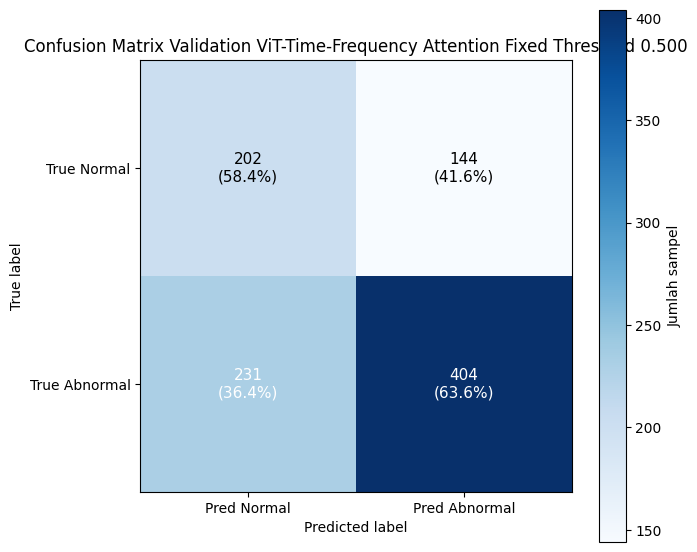

Confusion matrix figure: results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_confusion_matrix_val_threshold_500_fixed050.png


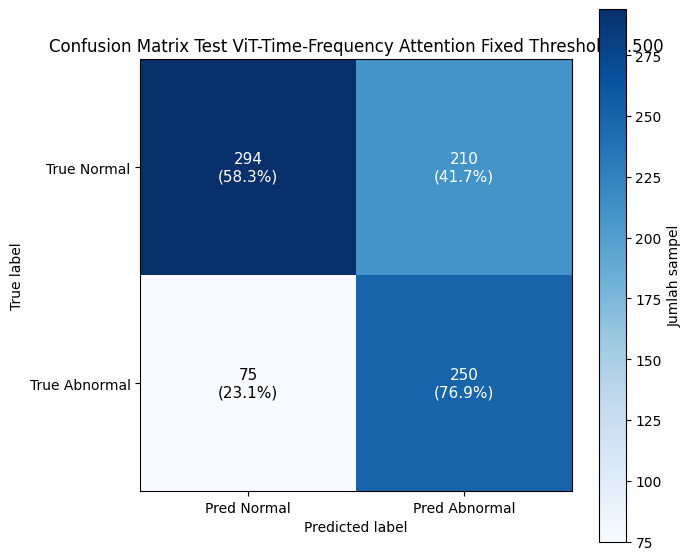

Confusion matrix figure: results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_confusion_matrix_test_threshold_500_fixed050.png


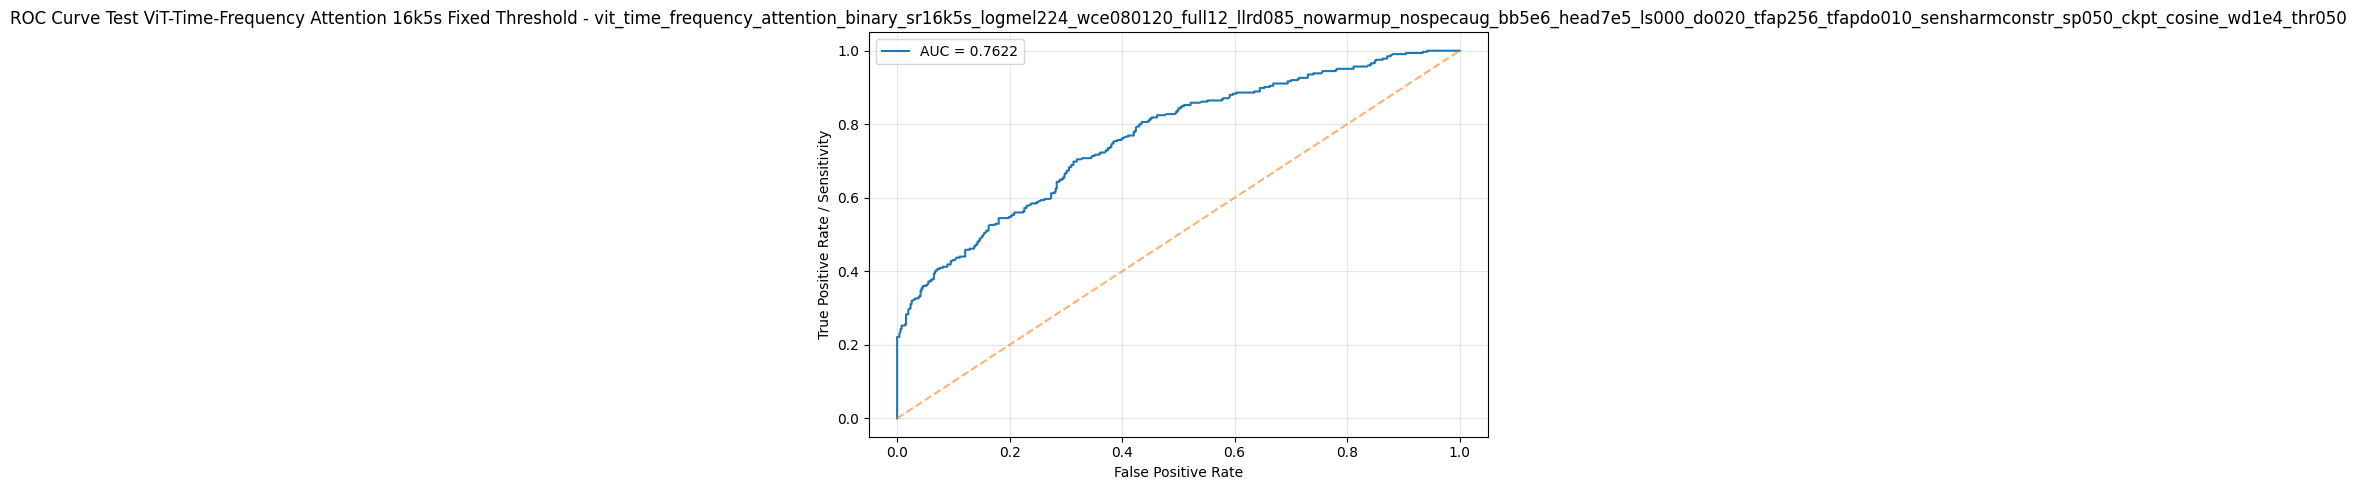

ROC curve figure: results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_roc_curve_test_fixed050_cell.png


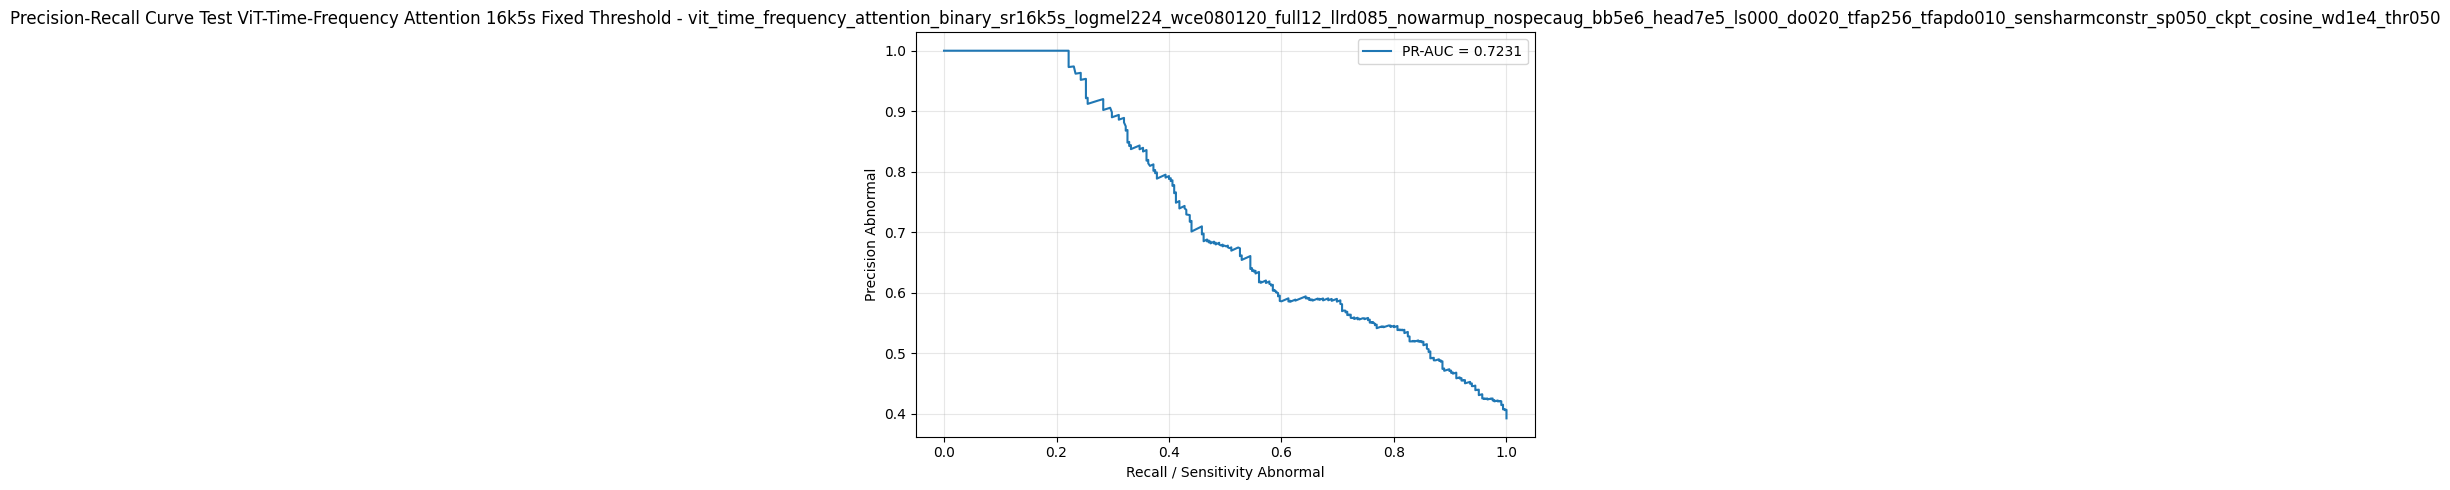

Precision-recall curve figure: results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_precision_recall_curve_test_fixed050_cell.png

AUDIT ERROR ViT-TIME-FREQUENCY ATTENTION FIXED THRESHOLD 0.50
False negative abnormal: 75
False positive normal  : 210

Distribusi source label false negative fixed 0.50:


,count
sound,
crackle,43
wheeze,24
both,8
abnormal,0



Distribusi patient_id false negative fixed 0.50:


,count
patient_id,
178,35
151,17
124,9
120,7
129,3
221,3
192,1



Distribusi patient_id false positive fixed 0.50:


,count
patient_id,
178,49
113,41
151,40
120,36
124,17
188,13
102,8
192,3
155,2



File hasil evaluasi threshold 0.50 disimpan:
Operating Point CSV          : results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_operating_point_fixed050.csv
Summary JSON                 : results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_evaluation_summary_fixed050.json
Vali

In [25]:
# ============================================================
# CELL 39: EVALUASI MODEL ViT-TIME-FREQUENCY ATTENTION
# Binary Normal-Abnormal 16k5s
# Evaluasi hanya menggunakan threshold tetap 0.50
# ============================================================

import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)


# ============================================================
# 0. VALIDASI GLOBAL WAJIB
# ============================================================

required_globals = [
    "model",
    "criterion",
    "run_one_epoch",
    "val_loader",
    "test_loader",
    "DEVICE",

    "SCENARIO_NAME",
    "CLASSES",
    "label2id",
    "id2label",
    "NUM_CLASSES",
    "LABEL_COL",

    "BEST_MODEL_PATH",
    "RESULT_DIR",

    "LOSS_NAME",
    "USE_CLASS_WEIGHT",
    "CLASS_WEIGHT_METHOD",

    "LEARNING_RATE",
    "LR_BACKBONE",
    "LR_HEAD",
    "WEIGHT_DECAY",
    "NUM_EPOCHS",
    "BATCH_SIZE",
    "PATIENCE",

    "CHECKPOINT_MONITOR",
    "EARLY_STOPPING_MONITOR",
    "CHECKPOINT_MODE",

    "TARGET_SR",
    "TARGET_DURATION_SEC",
    "TARGET_LEN_SAMPLES",
    "N_MELS",
    "FMIN",
    "FMAX",
    "N_FFT",
    "HOP_LENGTH",
    "WIN_LENGTH",
    "IMAGE_SIZE",

    "VIT_PATCH_SIZE",
    "VIT_PATCH_GRID_SIZE",
    "VIT_NUM_PATCHES",
    "VIT_EMBED_DIM",

    "TF_ATTN_INPUT_DIM",
    "TF_ATTN_HIDDEN_DIM",
    "TF_ATTN_DROPOUT",
    "TF_ATTN_POOLING",
    "TF_ATTN_NUM_PATCHES",
    "TF_ATTN_ACTIVATION",
    "CLASSIFIER_INPUT_DIM",
]

missing_globals = [g for g in required_globals if g not in globals()]

if missing_globals:
    raise RuntimeError(
        f"Global berikut belum tersedia: {missing_globals}\n"
        "Jalankan Cell 25, Cell metadata, Cell 33, Cell 35, dan Cell 37 "
        "Time-Frequency Attention terlebih dahulu."
    )


# ============================================================
# 1. VALIDASI KONFIGURASI EKSPERIMEN
# ============================================================

if int(NUM_CLASSES) != 2:
    raise ValueError("Evaluasi ini hanya untuk binary normal-abnormal.")

if list(CLASSES) != ["normal", "abnormal"]:
    raise ValueError(
        f"CLASSES saat ini {CLASSES}. Evaluasi binary wajib memakai ['normal', 'abnormal']."
    )

if LABEL_COL != "binary_label":
    raise ValueError(
        f"LABEL_COL saat ini {LABEL_COL}. Evaluasi binary wajib memakai binary_label."
    )

MODEL_FAMILY = globals().get("MODEL_FAMILY", "ViT-TimeFrequencyAttention")
MODEL_NAME = globals().get("MODEL_NAME", "ViT-B/16 + Time-Frequency Attention Pooling")
MODEL_CLAIM = globals().get(
    "MODEL_CLAIM",
    "Hybrid ViT-B/16 and Time-Frequency Attention Pooling using all patch-token representations.",
)

model_family_lower = str(MODEL_FAMILY).lower()
model_name_lower = str(MODEL_NAME).lower()

is_tf_attention_model = (
    ("timefrequency" in model_family_lower)
    or ("time-frequency" in model_family_lower)
    or ("time frequency" in model_family_lower)
    or ("time-frequency" in model_name_lower)
    or ("time frequency" in model_name_lower)
)

if not is_tf_attention_model:
    raise AssertionError(
        f"MODEL_FAMILY atau MODEL_NAME belum sesuai Time-Frequency Attention. "
        f"MODEL_FAMILY={MODEL_FAMILY}, MODEL_NAME={MODEL_NAME}"
    )

LOSS_NAME = str(globals().get("LOSS_NAME", "ce")).lower().strip()
CLASS_WEIGHT_METHOD = str(globals().get("CLASS_WEIGHT_METHOD", "none")).lower().strip()
USE_CLASS_WEIGHT = bool(globals().get("USE_CLASS_WEIGHT", False))

criterion_runtime_name = globals().get(
    "criterion_runtime_name",
    criterion.__class__.__name__,
)

if (
    LOSS_NAME == "weighted_ce"
    and criterion_runtime_name == "CrossEntropyLoss"
    and getattr(criterion, "weight", None) is not None
):
    criterion_runtime_name = "WeightedCrossEntropyLoss"
    globals()["criterion_runtime_name"] = criterion_runtime_name

valid_criterion_runtime = {
    "CrossEntropyLoss",
    "WeightedCrossEntropyLoss",
    "FocalLossWithLabelSmoothing",
}

if criterion_runtime_name not in valid_criterion_runtime:
    raise AssertionError(
        f"Loss runtime harus salah satu dari {valid_criterion_runtime}. "
        f"Saat ini: {criterion_runtime_name}"
    )

if LOSS_NAME == "ce":
    if criterion_runtime_name != "CrossEntropyLoss":
        raise AssertionError(
            f"LOSS_NAME='ce' harus memakai CrossEntropyLoss. "
            f"Saat ini: {criterion_runtime_name}"
        )

    if USE_CLASS_WEIGHT:
        raise AssertionError("USE_CLASS_WEIGHT harus False saat LOSS_NAME='ce'.")

    if getattr(criterion, "weight", None) is not None:
        raise AssertionError("criterion.weight harus None untuk CrossEntropy baseline.")

elif LOSS_NAME == "weighted_ce":
    if criterion_runtime_name != "WeightedCrossEntropyLoss":
        raise AssertionError(
            f"LOSS_NAME='weighted_ce' harus memakai WeightedCrossEntropyLoss. "
            f"Saat ini: {criterion_runtime_name}"
        )

    if not USE_CLASS_WEIGHT:
        raise AssertionError("USE_CLASS_WEIGHT harus True saat LOSS_NAME='weighted_ce'.")

    if getattr(criterion, "weight", None) is None:
        raise AssertionError(
            "criterion.weight tidak boleh None untuk Weighted Cross Entropy."
        )

elif LOSS_NAME == "focal":
    if criterion_runtime_name != "FocalLossWithLabelSmoothing":
        raise AssertionError(
            f"LOSS_NAME='focal' harus memakai FocalLossWithLabelSmoothing. "
            f"Saat ini: {criterion_runtime_name}"
        )

    if USE_CLASS_WEIGHT:
        raise AssertionError("USE_CLASS_WEIGHT harus False saat LOSS_NAME='focal'.")

else:
    raise ValueError(
        f"LOSS_NAME tidak valid: {LOSS_NAME}. Gunakan 'ce', 'weighted_ce', atau 'focal'."
    )

TARGET_SR = int(TARGET_SR)
TARGET_DURATION_SEC = float(TARGET_DURATION_SEC)
TARGET_LEN_SAMPLES = int(TARGET_LEN_SAMPLES)
N_MELS = int(N_MELS)
FMIN = int(FMIN)
FMAX = int(FMAX)
N_FFT = int(N_FFT)
HOP_LENGTH = int(HOP_LENGTH)
WIN_LENGTH = int(WIN_LENGTH)
IMAGE_SIZE = int(IMAGE_SIZE)

if TARGET_SR != 16000:
    raise AssertionError(f"TARGET_SR harus 16000. Saat ini: {TARGET_SR}")

if abs(TARGET_DURATION_SEC - 5.0) > 1e-12:
    raise AssertionError(f"TARGET_DURATION_SEC harus 5.0. Saat ini: {TARGET_DURATION_SEC}")

if TARGET_LEN_SAMPLES != 80000:
    raise AssertionError(f"TARGET_LEN_SAMPLES harus 80000. Saat ini: {TARGET_LEN_SAMPLES}")

if N_MELS != 224:
    raise AssertionError(f"N_MELS harus 224. Saat ini: {N_MELS}")

if FMIN != 0:
    raise AssertionError(
        f"FMIN harus 0 sesuai metadata citra yang sudah dibuat. Saat ini: {FMIN}."
    )

if FMAX != 8000:
    raise AssertionError(
        f"FMAX harus 8000 sesuai metadata citra yang sudah dibuat. Saat ini: {FMAX}."
    )

if N_FFT != 2048:
    raise AssertionError(f"N_FFT harus 2048. Saat ini: {N_FFT}")

if HOP_LENGTH != 128:
    raise AssertionError(f"HOP_LENGTH harus 128. Saat ini: {HOP_LENGTH}")

if WIN_LENGTH != 2048:
    raise AssertionError(f"WIN_LENGTH harus 2048. Saat ini: {WIN_LENGTH}")

if IMAGE_SIZE != 224:
    raise AssertionError(f"IMAGE_SIZE harus 224. Saat ini: {IMAGE_SIZE}")

VIT_PATCH_SIZE = int(VIT_PATCH_SIZE)
VIT_PATCH_GRID_SIZE = int(VIT_PATCH_GRID_SIZE)
VIT_NUM_PATCHES = int(VIT_NUM_PATCHES)
VIT_EMBED_DIM = int(VIT_EMBED_DIM)

TF_ATTN_INPUT_DIM = int(TF_ATTN_INPUT_DIM)
TF_ATTN_HIDDEN_DIM = int(TF_ATTN_HIDDEN_DIM)
TF_ATTN_DROPOUT = float(TF_ATTN_DROPOUT)
TF_ATTN_POOLING = str(TF_ATTN_POOLING).lower().strip()
TF_ATTN_NUM_PATCHES = int(TF_ATTN_NUM_PATCHES)
TF_ATTN_ACTIVATION = str(TF_ATTN_ACTIVATION).lower().strip()
CLASSIFIER_INPUT_DIM = int(CLASSIFIER_INPUT_DIM)

if VIT_PATCH_SIZE != 16:
    raise AssertionError(f"VIT_PATCH_SIZE harus 16. Saat ini: {VIT_PATCH_SIZE}")

if VIT_PATCH_GRID_SIZE != 14:
    raise AssertionError(f"VIT_PATCH_GRID_SIZE harus 14. Saat ini: {VIT_PATCH_GRID_SIZE}")

if VIT_NUM_PATCHES != 196:
    raise AssertionError(f"VIT_NUM_PATCHES harus 196. Saat ini: {VIT_NUM_PATCHES}")

if VIT_EMBED_DIM != 768:
    raise AssertionError(f"VIT_EMBED_DIM harus 768. Saat ini: {VIT_EMBED_DIM}")

if TF_ATTN_INPUT_DIM != VIT_EMBED_DIM:
    raise AssertionError(
        f"TF_ATTN_INPUT_DIM harus sama dengan VIT_EMBED_DIM. "
        f"Saat ini TF_ATTN_INPUT_DIM={TF_ATTN_INPUT_DIM}, VIT_EMBED_DIM={VIT_EMBED_DIM}"
    )

if TF_ATTN_NUM_PATCHES != VIT_NUM_PATCHES:
    raise AssertionError(
        f"TF_ATTN_NUM_PATCHES harus sama dengan VIT_NUM_PATCHES. "
        f"Saat ini TF_ATTN_NUM_PATCHES={TF_ATTN_NUM_PATCHES}, "
        f"VIT_NUM_PATCHES={VIT_NUM_PATCHES}"
    )

if CLASSIFIER_INPUT_DIM != TF_ATTN_INPUT_DIM:
    raise AssertionError(
        f"CLASSIFIER_INPUT_DIM harus sama dengan TF_ATTN_INPUT_DIM. "
        f"Saat ini CLASSIFIER_INPUT_DIM={CLASSIFIER_INPUT_DIM}, "
        f"TF_ATTN_INPUT_DIM={TF_ATTN_INPUT_DIM}"
    )

USE_SPEC_AUGMENT = bool(globals().get("USE_SPEC_AUGMENT", False))
if USE_SPEC_AUGMENT:
    raise AssertionError("USE_SPEC_AUGMENT harus False untuk evaluasi skenario ini.")

ENABLE_THRESHOLD_TUNING = bool(globals().get("ENABLE_THRESHOLD_TUNING", False))
if ENABLE_THRESHOLD_TUNING:
    raise AssertionError(
        "ENABLE_THRESHOLD_TUNING masih True. "
        "Untuk Cell 39 ini harus False karena evaluasi hanya threshold 0.50."
    )

print("=" * 90)
print("EVALUATION CONFIG VALIDATION - ViT-TIME-FREQUENCY ATTENTION")
print("=" * 90)
print("MODEL_FAMILY          :", MODEL_FAMILY)
print("MODEL_NAME            :", MODEL_NAME)
print("LOSS_NAME             :", LOSS_NAME)
print("Criterion runtime     :", criterion_runtime_name)
print("USE_CLASS_WEIGHT      :", USE_CLASS_WEIGHT)
print("CLASS_WEIGHT_METHOD   :", CLASS_WEIGHT_METHOD)
print("USE_SPEC_AUGMENT      :", USE_SPEC_AUGMENT)
print("ENABLE_THRESHOLD_TUNE :", ENABLE_THRESHOLD_TUNING)
print("FMIN                  :", FMIN)
print("FMAX                  :", FMAX)
print("WEIGHT_DECAY          :", WEIGHT_DECAY)
print("TF_ATTN_INPUT_DIM     :", TF_ATTN_INPUT_DIM)
print("TF_ATTN_HIDDEN_DIM    :", TF_ATTN_HIDDEN_DIM)
print("TF_ATTN_DROPOUT       :", TF_ATTN_DROPOUT)
print("TF_ATTN_POOLING       :", TF_ATTN_POOLING)
print("TF_ATTN_NUM_PATCHES   :", TF_ATTN_NUM_PATCHES)
print("TF_ATTN_ACTIVATION    :", TF_ATTN_ACTIVATION)
print("=" * 90)


# ============================================================
# 2. LABEL, CHECKPOINT, THRESHOLD CONFIG
# ============================================================

NEG_LABEL = globals().get("NEG_LABEL", "normal")
POS_LABEL = globals().get("POS_LABEL", "abnormal")

NEG_LABEL_ID = int(label2id[NEG_LABEL])
POS_LABEL_ID = int(label2id[POS_LABEL])

if NEG_LABEL_ID != 0 or POS_LABEL_ID != 1:
    raise ValueError(
        f"Mapping label salah. normal harus 0 dan abnormal harus 1. "
        f"Saat ini normal={NEG_LABEL_ID}, abnormal={POS_LABEL_ID}"
    )

FIXED_THRESHOLD = 0.50
DEFAULT_TEST_THRESHOLD = FIXED_THRESHOLD
BEST_THRESHOLD = FIXED_THRESHOLD

EVALUATION_MODE = "fixed_threshold_0_50_only"
EVALUATION_THRESHOLD_POLICY = "fixed_default_threshold_0_50"
PRIMARY_OPERATING_POINT = "fixed_threshold_0_50"

CHECKPOINT_MONITOR = str(globals().get("CHECKPOINT_MONITOR", "val_loss"))
EARLY_STOPPING_MONITOR = str(globals().get("EARLY_STOPPING_MONITOR", CHECKPOINT_MONITOR))
CHECKPOINT_MODE = str(globals().get("CHECKPOINT_MODE", "min"))

if CHECKPOINT_MONITOR == "val_loss" and CHECKPOINT_MODE != "min":
    raise AssertionError(
        "Jika CHECKPOINT_MONITOR='val_loss', CHECKPOINT_MODE harus 'min'."
    )

if CHECKPOINT_MONITOR != "val_loss" and CHECKPOINT_MODE != "max":
    raise AssertionError(
        f"Jika CHECKPOINT_MONITOR bukan val_loss, CHECKPOINT_MODE harus 'max'. "
        f"Saat ini monitor={CHECKPOINT_MONITOR}, mode={CHECKPOINT_MODE}."
    )

globals()["DEFAULT_TEST_THRESHOLD"] = DEFAULT_TEST_THRESHOLD
globals()["FIXED_THRESHOLD"] = FIXED_THRESHOLD
globals()["BEST_THRESHOLD"] = BEST_THRESHOLD
globals()["EVALUATION_MODE"] = EVALUATION_MODE
globals()["EVALUATION_THRESHOLD_POLICY"] = EVALUATION_THRESHOLD_POLICY
globals()["PRIMARY_OPERATING_POINT"] = PRIMARY_OPERATING_POINT
globals()["ENABLE_THRESHOLD_TUNING"] = False
globals()["CHECKPOINT_MONITOR"] = CHECKPOINT_MONITOR
globals()["EARLY_STOPPING_MONITOR"] = EARLY_STOPPING_MONITOR
globals()["CHECKPOINT_MODE"] = CHECKPOINT_MODE

print("=" * 90)
print("THRESHOLD REPORTING POLICY")
print("=" * 90)
print("Evaluation mode        :", EVALUATION_MODE)
print("Fixed threshold        :", FIXED_THRESHOLD)
print("Threshold tuning       : disabled")
print("Threshold policy       :", EVALUATION_THRESHOLD_POLICY)
print("Checkpoint monitor     :", CHECKPOINT_MONITOR)
print("Checkpoint mode        :", CHECKPOINT_MODE)
print("=" * 90)


# ============================================================
# 3. PATH OUTPUT
# ============================================================

RESULT_DIR = Path(RESULT_DIR)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = Path(BEST_MODEL_PATH)


# ============================================================
# 4. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def safe_float(x):
    try:
        if x is None:
            return None

        x = float(x)

        if np.isnan(x):
            return None

        return x

    except Exception:
        return None


def json_safe_value(x):
    if isinstance(x, (np.integer,)):
        return int(x)

    if isinstance(x, (np.floating,)):
        if np.isnan(float(x)):
            return None
        return float(x)

    if isinstance(x, float):
        if np.isnan(x):
            return None
        return x

    if isinstance(x, np.ndarray):
        return x.tolist()

    if isinstance(x, torch.Tensor):
        return x.detach().cpu().tolist()

    if isinstance(x, Path):
        return str(x)

    if isinstance(x, dict):
        return {str(k): json_safe_value(v) for k, v in x.items()}

    if isinstance(x, list):
        return [json_safe_value(v) for v in x]

    return x


def json_safe_dict(d):
    return {str(k): json_safe_value(v) for k, v in d.items()}


def load_checkpoint_safely(path, device):
    try:
        return torch.load(str(path), map_location=device, weights_only=False)
    except TypeError:
        return torch.load(str(path), map_location=device)


def get_id2label_value(class_id):
    if class_id in id2label:
        return id2label[class_id]

    if str(class_id) in id2label:
        return id2label[str(class_id)]

    raise KeyError(f"id2label tidak memiliki key {class_id}")


def make_threshold_suffix(threshold):
    return f"{int(round(float(threshold) * 1000)):03d}"


def format_auc_value(x):
    try:
        x = float(x)
        if np.isnan(x):
            return "nan"
        return f"{x:.4f}"
    except Exception:
        return "nan"


def print_metric_block(title, raw_loss, threshold, policy, metrics, cm_df, report_text):
    print("\n" + "=" * 90)
    print(title)
    print("=" * 90)
    print(f"Threshold                         : {threshold:.3f}")
    print(f"Threshold policy                  : {policy}")
    print(f"Loss                              : {raw_loss:.4f}")
    print(f"Accuracy                          : {metrics['accuracy']:.4f}")
    print(f"Sensitivity abnormal              : {metrics['sensitivity_abnormal']:.4f}")
    print(f"Specificity normal                : {metrics['specificity_normal']:.4f}")
    print(f"Precision abnormal                : {metrics['precision_abnormal']:.4f}")
    print(f"F1 abnormal                       : {metrics['f1_abnormal']:.4f}")
    print(f"Balanced score                    : {metrics['balanced_score']:.4f}")
    print(f"Harmonic score                    : {metrics['harmonic_score']:.4f}")
    print(f"AUC                               : {format_auc_value(metrics['auc'])}")
    print(f"PR-AUC                            : {format_auc_value(metrics['pr_auc'])}")
    print("\nConfusion Matrix:")
    safe_display(cm_df)
    print("\nClassification Report:")
    print(report_text)
    print("=" * 90)


def plot_confusion_matrix_binary(cm, title, path):
    cm_plot = np.asarray(cm).astype(np.int64)
    cm_norm = cm_plot.astype(np.float64) / (cm_plot.sum(axis=1, keepdims=True) + 1e-12)

    fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(
        cm_plot,
        interpolation="nearest",
        cmap="Blues",
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Jumlah sampel", rotation=90)

    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=["Pred Normal", "Pred Abnormal"],
        yticklabels=["True Normal", "True Abnormal"],
        xlabel="Predicted label",
        ylabel="True label",
        title=title,
    )

    threshold_color = cm_plot.max() / 2.0 if cm_plot.max() > 0 else 0.5

    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            count_text = cm_plot[i, j]
            pct_text = cm_norm[i, j] * 100.0

            ax.text(
                j,
                i,
                f"{count_text}\n({pct_text:.1f}%)",
                ha="center",
                va="center",
                color="white" if cm_plot[i, j] > threshold_color else "black",
                fontsize=11,
            )

    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()

    print("Confusion matrix figure:", path)


def compute_binary_metrics_from_prob(y_true, prob_abnormal, threshold=0.50):
    y_true = np.asarray(y_true).astype(int)
    prob_abnormal = np.asarray(prob_abnormal).astype(float)

    y_pred = (prob_abnormal >= float(threshold)).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[NEG_LABEL_ID, POS_LABEL_ID],
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity_abnormal = tp / (tp + fn + 1e-12)
    specificity_normal = tn / (tn + fp + 1e-12)
    precision_abnormal = tp / (tp + fp + 1e-12)

    f1_abnormal = (
        2.0 * precision_abnormal * sensitivity_abnormal /
        (precision_abnormal + sensitivity_abnormal + 1e-12)
    )

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    balanced_score = (sensitivity_abnormal + specificity_normal) / 2.0

    harmonic_score = (
        2.0 * sensitivity_abnormal * specificity_normal /
        (sensitivity_abnormal + specificity_normal + 1e-12)
    )

    try:
        auc = roc_auc_score(y_true, prob_abnormal)
    except Exception:
        auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, prob_abnormal)
    except Exception:
        pr_auc = np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy),
        "sensitivity_abnormal": float(sensitivity_abnormal),
        "specificity_normal": float(specificity_normal),
        "precision_abnormal": float(precision_abnormal),
        "f1_abnormal": float(f1_abnormal),
        "balanced_score": float(balanced_score),
        "harmonic_score": float(harmonic_score),
        "auc": float(auc) if not np.isnan(auc) else np.nan,
        "pr_auc": float(pr_auc) if not np.isnan(pr_auc) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "confusion_matrix": cm,
        "y_pred": y_pred,
    }


def build_prediction_df(y_true, prob_abnormal, y_pred, threshold, threshold_policy, df_meta=None):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    prob_abnormal = np.asarray(prob_abnormal).astype(float)

    pred_df = pd.DataFrame({
        "y_true_id": y_true,
        "y_true_label": [get_id2label_value(int(x)) for x in y_true],
        "prob_abnormal": prob_abnormal,
        "prob_normal": 1.0 - prob_abnormal,
        "y_pred_id": y_pred,
        "y_pred_label": [get_id2label_value(int(x)) for x in y_pred],
        "threshold": float(threshold),
        "threshold_policy": str(threshold_policy),
        "is_correct": y_true == y_pred,
    })

    if df_meta is not None and len(df_meta) == len(pred_df):
        meta = df_meta.reset_index(drop=True).copy()

        meta_cols = [
            "image_path",
            "sound",
            "sound_4class",
            "original_sound",
            "binary_label",
            "patient_id",
            "split",
            "is_augmented",
            "augmentation_group",
            "aug_type",
            "file",
            "image_sr",
            "image_n_mels",
            "image_fmin",
            "image_fmax",
            "image_hop_length",
            "image_expected_len_samples",
        ]

        for col in meta_cols:
            if col in meta.columns:
                pred_df[col] = meta[col].values

    return pred_df


# ============================================================
# 5. LOAD BEST MODEL BERDASARKAN CHECKPOINT MONITOR
# ============================================================

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best model tidak ditemukan: {BEST_MODEL_PATH}\n"
        "Jalankan Training Loop terlebih dahulu dan pastikan checkpoint best model tersimpan."
    )

print("=" * 90)
print("LOAD BEST MODEL UNTUK EVALUASI ViT-TIME-FREQUENCY ATTENTION BINARY 16k5s")
print("=" * 90)
print("Best model path:", BEST_MODEL_PATH)

checkpoint = load_checkpoint_safely(BEST_MODEL_PATH, DEVICE)

checkpoint_epoch = None
checkpoint_type = None
checkpoint_monitor = CHECKPOINT_MONITOR
checkpoint_mode = CHECKPOINT_MODE
checkpoint_selection_rule = f"{CHECKPOINT_MODE}_{CHECKPOINT_MONITOR}"
checkpoint_best_val_loss = None
checkpoint_loss_name = LOSS_NAME
checkpoint_class_weight_method = CLASS_WEIGHT_METHOD
checkpoint_scheduler = globals().get("scheduler_name_runtime", globals().get("SCHEDULER_NAME", "unknown"))
checkpoint_criterion_runtime = criterion_runtime_name
checkpoint_criterion_weights = None

checkpoint_tf_attn_input_dim = globals().get("TF_ATTN_INPUT_DIM", None)
checkpoint_tf_attn_hidden_dim = globals().get("TF_ATTN_HIDDEN_DIM", None)
checkpoint_tf_attn_dropout = globals().get("TF_ATTN_DROPOUT", None)
checkpoint_tf_attn_pooling = globals().get("TF_ATTN_POOLING", None)
checkpoint_tf_attn_num_patches = globals().get("TF_ATTN_NUM_PATCHES", None)
checkpoint_tf_attn_activation = globals().get("TF_ATTN_ACTIVATION", None)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])

    checkpoint_epoch = checkpoint.get("epoch", None)
    checkpoint_type = checkpoint.get("checkpoint_type", None)
    checkpoint_monitor = checkpoint.get("checkpoint_monitor", CHECKPOINT_MONITOR)
    checkpoint_mode = checkpoint.get("checkpoint_mode", CHECKPOINT_MODE)
    checkpoint_selection_rule = checkpoint.get(
        "selection_rule",
        f"{checkpoint_mode}_{checkpoint_monitor}",
    )
    checkpoint_best_val_loss = checkpoint.get("best_val_loss", None)
    checkpoint_loss_name = checkpoint.get("loss_name", LOSS_NAME)
    checkpoint_class_weight_method = checkpoint.get(
        "class_weight_method",
        CLASS_WEIGHT_METHOD,
    )
    checkpoint_scheduler = checkpoint.get(
        "scheduler",
        globals().get("scheduler_name_runtime", globals().get("SCHEDULER_NAME", "unknown")),
    )
    checkpoint_criterion_runtime = checkpoint.get(
        "criterion_runtime",
        criterion_runtime_name,
    )
    checkpoint_criterion_weights = checkpoint.get("criterion_weights", None)

    checkpoint_tf_attn_input_dim = checkpoint.get(
        "tf_attn_input_dim",
        checkpoint_tf_attn_input_dim,
    )
    checkpoint_tf_attn_hidden_dim = checkpoint.get(
        "tf_attn_hidden_dim",
        checkpoint_tf_attn_hidden_dim,
    )
    checkpoint_tf_attn_dropout = checkpoint.get(
        "tf_attn_dropout",
        checkpoint_tf_attn_dropout,
    )
    checkpoint_tf_attn_pooling = checkpoint.get(
        "tf_attn_pooling",
        checkpoint_tf_attn_pooling,
    )
    checkpoint_tf_attn_num_patches = checkpoint.get(
        "tf_attn_num_patches",
        checkpoint_tf_attn_num_patches,
    )
    checkpoint_tf_attn_activation = checkpoint.get(
        "tf_attn_activation",
        checkpoint_tf_attn_activation,
    )

elif isinstance(checkpoint, dict):
    try:
        model.load_state_dict(checkpoint)
        checkpoint_type = "raw_state_dict"
    except Exception as e:
        raise RuntimeError(
            "Format checkpoint tidak dikenali. "
            f"Error saat load_state_dict: {repr(e)}"
        )
else:
    raise RuntimeError("Checkpoint tidak valid.")

print("Checkpoint epoch               :", checkpoint_epoch)
print("Checkpoint type                :", checkpoint_type)
print("Checkpoint monitor             :", checkpoint_monitor)
print("Checkpoint mode                :", checkpoint_mode)
print("Checkpoint selection           :", checkpoint_selection_rule)
print("Checkpoint best val loss       :", checkpoint_best_val_loss)
print("Checkpoint loss name           :", checkpoint_loss_name)
print("Checkpoint criterion           :", checkpoint_criterion_runtime)
print("Checkpoint scheduler           :", checkpoint_scheduler)
print("Checkpoint TFAttn input        :", checkpoint_tf_attn_input_dim)
print("Checkpoint TFAttn hidden       :", checkpoint_tf_attn_hidden_dim)
print("Checkpoint TFAttn dropout      :", checkpoint_tf_attn_dropout)
print("Checkpoint TFAttn pooling      :", checkpoint_tf_attn_pooling)
print("Checkpoint TFAttn patches      :", checkpoint_tf_attn_num_patches)
print("Checkpoint TFAttn activation   :", checkpoint_tf_attn_activation)

model = model.to(DEVICE)
model.eval()


# ============================================================
# 6. RUN RAW EVALUATION ON VALIDATION AND TEST
# ============================================================

print("\n" + "=" * 90)
print("EVALUASI VALIDATION DAN TEST SET ViT-TIME-FREQUENCY ATTENTION BINARY 16k5s")
print("=" * 90)
print("Checkpoint monitor      :", checkpoint_monitor)
print("Checkpoint selection    :", checkpoint_selection_rule)
print("Threshold evaluation    :", FIXED_THRESHOLD)
print("Threshold tuning        : disabled")
print("=" * 90)

val_raw_metrics = run_one_epoch(
    model=model,
    loader=val_loader,
    criterion=criterion,
    optimizer=None,
    scaler=None,
    device=DEVICE,
)

test_raw_metrics = run_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    optimizer=None,
    scaler=None,
    device=DEVICE,
)

y_val = np.asarray(val_raw_metrics["y_true"]).astype(int)
val_prob_abnormal = np.asarray(val_raw_metrics["y_prob_abnormal"]).astype(float)

y_test = np.asarray(test_raw_metrics["y_true"]).astype(int)
test_prob_abnormal = np.asarray(test_raw_metrics["y_prob_abnormal"]).astype(float)


# ============================================================
# 7. HITUNG METRIK THRESHOLD 0.50
# ============================================================

val_metrics_fixed_050 = compute_binary_metrics_from_prob(
    y_true=y_val,
    prob_abnormal=val_prob_abnormal,
    threshold=FIXED_THRESHOLD,
)

test_metrics_fixed_050 = compute_binary_metrics_from_prob(
    y_true=y_test,
    prob_abnormal=test_prob_abnormal,
    threshold=FIXED_THRESHOLD,
)

val_cm_fixed_050 = val_metrics_fixed_050["confusion_matrix"].astype(np.int64)
test_cm_fixed_050 = test_metrics_fixed_050["confusion_matrix"].astype(np.int64)

val_cm_fixed_050_df = pd.DataFrame(
    val_cm_fixed_050,
    index=["True Normal", "True Abnormal"],
    columns=["Pred Normal", "Pred Abnormal"],
)

test_cm_fixed_050_df = pd.DataFrame(
    test_cm_fixed_050,
    index=["True Normal", "True Abnormal"],
    columns=["Pred Normal", "Pred Abnormal"],
)

val_report_fixed_050_text = classification_report(
    y_val,
    val_metrics_fixed_050["y_pred"],
    labels=[NEG_LABEL_ID, POS_LABEL_ID],
    target_names=CLASSES,
    digits=4,
    zero_division=0,
)

test_report_fixed_050_text = classification_report(
    y_test,
    test_metrics_fixed_050["y_pred"],
    labels=[NEG_LABEL_ID, POS_LABEL_ID],
    target_names=CLASSES,
    digits=4,
    zero_division=0,
)

val_tn_050, val_fp_050, val_fn_050, val_tp_050 = val_cm_fixed_050.ravel()
tn_050, fp_050, fn_050, tp_050 = test_cm_fixed_050.ravel()


# ============================================================
# 8. OUTPUT PATHS
# ============================================================

fixed_050_suffix = make_threshold_suffix(FIXED_THRESHOLD)

VAL_PRED_FIXED_050_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_val_predictions_threshold_{fixed_050_suffix}_fixed050.csv"
TEST_PRED_FIXED_050_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_test_predictions_threshold_{fixed_050_suffix}_fixed050.csv"

VAL_CM_FIXED_050_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_val_confusion_matrix_threshold_{fixed_050_suffix}_fixed050.csv"
TEST_CM_FIXED_050_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_test_confusion_matrix_threshold_{fixed_050_suffix}_fixed050.csv"

VAL_REPORT_FIXED_050_TXT_PATH = RESULT_DIR / f"{SCENARIO_NAME}_val_classification_report_threshold_{fixed_050_suffix}_fixed050.txt"
TEST_REPORT_FIXED_050_TXT_PATH = RESULT_DIR / f"{SCENARIO_NAME}_test_classification_report_threshold_{fixed_050_suffix}_fixed050.txt"

OPERATING_POINT_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_operating_point_fixed050.csv"
TEST_SUMMARY_JSON_PATH = RESULT_DIR / f"{SCENARIO_NAME}_evaluation_summary_fixed050.json"

ROC_CURVE_PATH = RESULT_DIR / f"{SCENARIO_NAME}_roc_curve_test_fixed050_cell.png"
PR_CURVE_PATH = RESULT_DIR / f"{SCENARIO_NAME}_precision_recall_curve_test_fixed050_cell.png"

VAL_CM_FIXED_050_FIG_PATH = RESULT_DIR / f"{SCENARIO_NAME}_confusion_matrix_val_threshold_{fixed_050_suffix}_fixed050.png"
TEST_CM_FIXED_050_FIG_PATH = RESULT_DIR / f"{SCENARIO_NAME}_confusion_matrix_test_threshold_{fixed_050_suffix}_fixed050.png"

FALSE_NEGATIVE_FIXED_050_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_false_negative_abnormal_threshold_{fixed_050_suffix}_fixed050.csv"
FALSE_POSITIVE_FIXED_050_CSV_PATH = RESULT_DIR / f"{SCENARIO_NAME}_false_positive_normal_threshold_{fixed_050_suffix}_fixed050.csv"


# ============================================================
# 9. OPERATING POINT SUMMARY
# ============================================================

operating_points_df = pd.DataFrame([
    {
        "operating_point": "fixed_050",
        "threshold": FIXED_THRESHOLD,
        "policy": EVALUATION_THRESHOLD_POLICY,

        "model_family": MODEL_FAMILY,
        "model_name": MODEL_NAME,

        "checkpoint_monitor": checkpoint_monitor,
        "checkpoint_mode": checkpoint_mode,
        "checkpoint_selection_rule": checkpoint_selection_rule,

        "val_loss": float(val_raw_metrics["loss"]),
        "val_accuracy": val_metrics_fixed_050["accuracy"],
        "val_sensitivity_abnormal": val_metrics_fixed_050["sensitivity_abnormal"],
        "val_specificity_normal": val_metrics_fixed_050["specificity_normal"],
        "val_precision_abnormal": val_metrics_fixed_050["precision_abnormal"],
        "val_f1_abnormal": val_metrics_fixed_050["f1_abnormal"],
        "val_balanced_score": val_metrics_fixed_050["balanced_score"],
        "val_harmonic_score": val_metrics_fixed_050["harmonic_score"],
        "val_auc": val_metrics_fixed_050["auc"],
        "val_pr_auc": val_metrics_fixed_050["pr_auc"],
        "val_tn": val_metrics_fixed_050["tn"],
        "val_fp": val_metrics_fixed_050["fp"],
        "val_fn": val_metrics_fixed_050["fn"],
        "val_tp": val_metrics_fixed_050["tp"],

        "test_loss": float(test_raw_metrics["loss"]),
        "test_accuracy": test_metrics_fixed_050["accuracy"],
        "test_sensitivity_abnormal": test_metrics_fixed_050["sensitivity_abnormal"],
        "test_specificity_normal": test_metrics_fixed_050["specificity_normal"],
        "test_precision_abnormal": test_metrics_fixed_050["precision_abnormal"],
        "test_f1_abnormal": test_metrics_fixed_050["f1_abnormal"],
        "test_balanced_score": test_metrics_fixed_050["balanced_score"],
        "test_harmonic_score": test_metrics_fixed_050["harmonic_score"],
        "test_auc": test_metrics_fixed_050["auc"],
        "test_pr_auc": test_metrics_fixed_050["pr_auc"],
        "test_tn": test_metrics_fixed_050["tn"],
        "test_fp": test_metrics_fixed_050["fp"],
        "test_fn": test_metrics_fixed_050["fn"],
        "test_tp": test_metrics_fixed_050["tp"],
    },
])

operating_points_df.to_csv(OPERATING_POINT_CSV_PATH, index=False)

print("\n" + "=" * 90)
print("OPERATING POINT SUMMARY: ViT-TIME-FREQUENCY ATTENTION FIXED THRESHOLD 0.50")
print("=" * 90)
safe_display(operating_points_df)
print("=" * 90)


# ============================================================
# 10. PRINT REPORT VALIDATION DAN TEST
# ============================================================

print_metric_block(
    title="HASIL VALIDATION SET - ViT-TIME-FREQUENCY ATTENTION - FIXED THRESHOLD 0.50",
    raw_loss=float(val_raw_metrics["loss"]),
    threshold=FIXED_THRESHOLD,
    policy=EVALUATION_THRESHOLD_POLICY,
    metrics=val_metrics_fixed_050,
    cm_df=val_cm_fixed_050_df,
    report_text=val_report_fixed_050_text,
)

print("\nKomponen confusion matrix validation fixed 0.50:")
print(f"TN normal benar                 : {val_tn_050}")
print(f"FP normal diprediksi abnormal   : {val_fp_050}")
print(f"FN abnormal diprediksi normal   : {val_fn_050}")
print(f"TP abnormal benar               : {val_tp_050}")

print_metric_block(
    title="HASIL TEST SET - ViT-TIME-FREQUENCY ATTENTION - FIXED THRESHOLD 0.50",
    raw_loss=float(test_raw_metrics["loss"]),
    threshold=FIXED_THRESHOLD,
    policy=EVALUATION_THRESHOLD_POLICY,
    metrics=test_metrics_fixed_050,
    cm_df=test_cm_fixed_050_df,
    report_text=test_report_fixed_050_text,
)

print("\nKomponen confusion matrix test fixed 0.50:")
print(f"TN normal benar                 : {tn_050}")
print(f"FP normal diprediksi abnormal   : {fp_050}")
print(f"FN abnormal diprediksi normal   : {fn_050}")
print(f"TP abnormal benar               : {tp_050}")


# ============================================================
# 11. SIMPAN PREDICTION CSV, CM, REPORT, DAN AUDIT ERROR
# ============================================================

val_meta_df = globals().get("val_df", None)
test_meta_df = globals().get("test_df", None)

val_pred_fixed_050_df = build_prediction_df(
    y_true=y_val,
    prob_abnormal=val_prob_abnormal,
    y_pred=val_metrics_fixed_050["y_pred"],
    threshold=FIXED_THRESHOLD,
    threshold_policy=EVALUATION_THRESHOLD_POLICY,
    df_meta=val_meta_df,
)

test_pred_fixed_050_df = build_prediction_df(
    y_true=y_test,
    prob_abnormal=test_prob_abnormal,
    y_pred=test_metrics_fixed_050["y_pred"],
    threshold=FIXED_THRESHOLD,
    threshold_policy=EVALUATION_THRESHOLD_POLICY,
    df_meta=test_meta_df,
)

val_pred_fixed_050_df.to_csv(VAL_PRED_FIXED_050_CSV_PATH, index=False)
test_pred_fixed_050_df.to_csv(TEST_PRED_FIXED_050_CSV_PATH, index=False)

val_cm_fixed_050_df.to_csv(VAL_CM_FIXED_050_CSV_PATH)
test_cm_fixed_050_df.to_csv(TEST_CM_FIXED_050_CSV_PATH)

with open(VAL_REPORT_FIXED_050_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(val_report_fixed_050_text)

with open(TEST_REPORT_FIXED_050_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(test_report_fixed_050_text)

false_negative_fixed_050_df = test_pred_fixed_050_df[
    (test_pred_fixed_050_df["y_true_id"] == POS_LABEL_ID) &
    (test_pred_fixed_050_df["y_pred_id"] == NEG_LABEL_ID)
].copy()

false_positive_fixed_050_df = test_pred_fixed_050_df[
    (test_pred_fixed_050_df["y_true_id"] == NEG_LABEL_ID) &
    (test_pred_fixed_050_df["y_pred_id"] == POS_LABEL_ID)
].copy()

false_negative_fixed_050_df.to_csv(FALSE_NEGATIVE_FIXED_050_CSV_PATH, index=False)
false_positive_fixed_050_df.to_csv(FALSE_POSITIVE_FIXED_050_CSV_PATH, index=False)


# ============================================================
# 12. SIMPAN SUMMARY JSON
# ============================================================

summary_dict = {
    "scenario_name": SCENARIO_NAME,
    "model_family": MODEL_FAMILY,
    "model_name": MODEL_NAME,
    "model_claim": MODEL_CLAIM,

    "vit_patch_size": int(globals().get("VIT_PATCH_SIZE", 16)),
    "vit_patch_grid_size": int(globals().get("VIT_PATCH_GRID_SIZE", 14)),
    "vit_num_patches": int(globals().get("VIT_NUM_PATCHES", 196)),
    "vit_embed_dim": int(globals().get("VIT_EMBED_DIM", 768)),

    "tf_attn_input_dim": int(globals().get("TF_ATTN_INPUT_DIM", 768)),
    "tf_attn_hidden_dim": int(globals().get("TF_ATTN_HIDDEN_DIM", 256)),
    "tf_attn_dropout": float(globals().get("TF_ATTN_DROPOUT", 0.30)),
    "tf_attn_pooling": str(globals().get("TF_ATTN_POOLING", "mlp_attention")),
    "tf_attn_num_patches": int(globals().get("TF_ATTN_NUM_PATCHES", 196)),
    "tf_attn_activation": str(globals().get("TF_ATTN_ACTIVATION", "tanh")),
    "classifier_input_dim": int(globals().get("CLASSIFIER_INPUT_DIM", 768)),

    "label_mode": "binary_normal_abnormal",
    "positive_label": POS_LABEL,
    "negative_label": NEG_LABEL,
    "classes": CLASSES,

    "target_sr": int(TARGET_SR),
    "target_duration_sec": float(TARGET_DURATION_SEC),
    "target_len_samples": int(TARGET_LEN_SAMPLES),
    "n_mels": int(N_MELS),
    "fmin": int(FMIN),
    "fmax": int(FMAX),
    "n_fft": int(N_FFT),
    "hop_length": int(HOP_LENGTH),
    "win_length": int(WIN_LENGTH),
    "image_size": int(IMAGE_SIZE),
    "image_colormap": str(globals().get("IMAGE_COLORMAP", "magma")),
    "image_mode": str(globals().get("IMAGE_MODE", "rgb")),

    "checkpoint_epoch": checkpoint_epoch,
    "checkpoint_type": checkpoint_type,
    "checkpoint_monitor": checkpoint_monitor,
    "early_stopping_monitor": EARLY_STOPPING_MONITOR,
    "checkpoint_mode": checkpoint_mode,
    "checkpoint_selection_rule": checkpoint_selection_rule,
    "best_model_path": str(BEST_MODEL_PATH),

    "loss_name": LOSS_NAME,
    "loss_function": checkpoint_criterion_runtime,
    "use_class_weight": bool(USE_CLASS_WEIGHT),
    "class_weight_method": checkpoint_class_weight_method,
    "criterion_weights": checkpoint_criterion_weights,

    "optimizer": "AdamW",
    "learning_rate": float(LEARNING_RATE),
    "lr_backbone": float(LR_BACKBONE),
    "lr_head": float(LR_HEAD),
    "weight_decay": float(WEIGHT_DECAY),
    "use_layer_wise_lr_decay": bool(globals().get("USE_LAYER_WISE_LR_DECAY", False)),
    "layer_lr_decay": safe_float(globals().get("LAYER_LR_DECAY", None)),
    "scheduler": checkpoint_scheduler,
    "warmup_epochs": int(globals().get("WARMUP_EPOCHS", 0)),

    "num_epochs": int(NUM_EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "patience": int(PATIENCE),
    "use_spec_augment": bool(globals().get("USE_SPEC_AUGMENT", False)),

    "threshold_mode": "fixed_050",
    "threshold": float(FIXED_THRESHOLD),
    "threshold_policy": EVALUATION_THRESHOLD_POLICY,
    "threshold_selected_from": "fixed_default",
    "threshold_tuning_enabled": False,

    "validation_loss": float(val_raw_metrics["loss"]),
    "validation_accuracy": float(val_metrics_fixed_050["accuracy"]),
    "validation_sensitivity_abnormal": float(val_metrics_fixed_050["sensitivity_abnormal"]),
    "validation_specificity_normal": float(val_metrics_fixed_050["specificity_normal"]),
    "validation_precision_abnormal": float(val_metrics_fixed_050["precision_abnormal"]),
    "validation_f1_abnormal": float(val_metrics_fixed_050["f1_abnormal"]),
    "validation_balanced_score": float(val_metrics_fixed_050["balanced_score"]),
    "validation_harmonic_score": float(val_metrics_fixed_050["harmonic_score"]),
    "validation_auc": safe_float(val_metrics_fixed_050["auc"]),
    "validation_pr_auc": safe_float(val_metrics_fixed_050["pr_auc"]),
    "validation_tn": int(val_tn_050),
    "validation_fp": int(val_fp_050),
    "validation_fn": int(val_fn_050),
    "validation_tp": int(val_tp_050),

    "test_loss": float(test_raw_metrics["loss"]),
    "test_accuracy": float(test_metrics_fixed_050["accuracy"]),
    "test_sensitivity_abnormal": float(test_metrics_fixed_050["sensitivity_abnormal"]),
    "test_specificity_normal": float(test_metrics_fixed_050["specificity_normal"]),
    "test_precision_abnormal": float(test_metrics_fixed_050["precision_abnormal"]),
    "test_f1_abnormal": float(test_metrics_fixed_050["f1_abnormal"]),
    "test_balanced_score": float(test_metrics_fixed_050["balanced_score"]),
    "test_harmonic_score": float(test_metrics_fixed_050["harmonic_score"]),
    "test_auc": safe_float(test_metrics_fixed_050["auc"]),
    "test_pr_auc": safe_float(test_metrics_fixed_050["pr_auc"]),
    "test_tn": int(tn_050),
    "test_fp": int(fp_050),
    "test_fn": int(fn_050),
    "test_tp": int(tp_050),

    "false_negative_abnormal": int(fn_050),
    "false_positive_normal": int(fp_050),

    "val_prediction_csv": str(VAL_PRED_FIXED_050_CSV_PATH),
    "test_prediction_csv": str(TEST_PRED_FIXED_050_CSV_PATH),
    "val_confusion_matrix_csv": str(VAL_CM_FIXED_050_CSV_PATH),
    "test_confusion_matrix_csv": str(TEST_CM_FIXED_050_CSV_PATH),
    "val_report_txt": str(VAL_REPORT_FIXED_050_TXT_PATH),
    "test_report_txt": str(TEST_REPORT_FIXED_050_TXT_PATH),
    "false_negative_csv": str(FALSE_NEGATIVE_FIXED_050_CSV_PATH),
    "false_positive_csv": str(FALSE_POSITIVE_FIXED_050_CSV_PATH),
    "operating_point_csv": str(OPERATING_POINT_CSV_PATH),
    "summary_json": str(TEST_SUMMARY_JSON_PATH),
}

with open(TEST_SUMMARY_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(json_safe_dict(summary_dict), f, indent=2, ensure_ascii=False)


# ============================================================
# 13. VISUALISASI CONFUSION MATRIX VALIDATION DAN TEST
# ============================================================

plot_confusion_matrix_binary(
    cm=val_cm_fixed_050,
    title=f"Confusion Matrix Validation ViT-Time-Frequency Attention Fixed Threshold {FIXED_THRESHOLD:.3f}",
    path=VAL_CM_FIXED_050_FIG_PATH,
)

plot_confusion_matrix_binary(
    cm=test_cm_fixed_050,
    title=f"Confusion Matrix Test ViT-Time-Frequency Attention Fixed Threshold {FIXED_THRESHOLD:.3f}",
    path=TEST_CM_FIXED_050_FIG_PATH,
)


# ============================================================
# 14. ROC CURVE TEST
# ROC tidak digunakan untuk memilih threshold. Hanya audit performa probabilistik.
# ============================================================

try:
    fpr, tpr, roc_thresholds = roc_curve(y_test, test_prob_abnormal)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, label=f"AUC = {test_metrics_fixed_050['auc']:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)

    ax.set_title(f"ROC Curve Test ViT-Time-Frequency Attention 16k5s Fixed Threshold - {SCENARIO_NAME}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate / Sensitivity")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(ROC_CURVE_PATH, dpi=150)
    plt.show()

    print("ROC curve figure:", ROC_CURVE_PATH)

except Exception as e:
    print("ROC curve tidak dapat dibuat:", repr(e))


# ============================================================
# 15. PRECISION-RECALL CURVE TEST
# PR curve tidak digunakan untuk memilih threshold. Hanya audit probabilistik.
# ============================================================

try:
    precision, recall, pr_thresholds = precision_recall_curve(
        y_test,
        test_prob_abnormal,
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        recall,
        precision,
        label=f"PR-AUC = {test_metrics_fixed_050['pr_auc']:.4f}",
    )

    ax.set_title(f"Precision-Recall Curve Test ViT-Time-Frequency Attention 16k5s Fixed Threshold - {SCENARIO_NAME}")
    ax.set_xlabel("Recall / Sensitivity Abnormal")
    ax.set_ylabel("Precision Abnormal")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(PR_CURVE_PATH, dpi=150)
    plt.show()

    print("Precision-recall curve figure:", PR_CURVE_PATH)

except Exception as e:
    print("Precision-recall curve tidak dapat dibuat:", repr(e))


# ============================================================
# 16. AUDIT FALSE NEGATIVE DAN FALSE POSITIVE
# ============================================================

print("\n" + "=" * 90)
print("AUDIT ERROR ViT-TIME-FREQUENCY ATTENTION FIXED THRESHOLD 0.50")
print("=" * 90)
print("False negative abnormal:", len(false_negative_fixed_050_df))
print("False positive normal  :", len(false_positive_fixed_050_df))

if len(false_negative_fixed_050_df) > 0 and "sound" in false_negative_fixed_050_df.columns:
    print("\nDistribusi source label false negative fixed 0.50:")
    safe_display(
        false_negative_fixed_050_df["sound"]
        .value_counts()
        .reindex(["crackle", "wheeze", "both", "abnormal"], fill_value=0)
        .astype(int)
    )

if len(false_negative_fixed_050_df) > 0 and "patient_id" in false_negative_fixed_050_df.columns:
    print("\nDistribusi patient_id false negative fixed 0.50:")
    safe_display(false_negative_fixed_050_df["patient_id"].value_counts().head(20))

if len(false_positive_fixed_050_df) > 0 and "patient_id" in false_positive_fixed_050_df.columns:
    print("\nDistribusi patient_id false positive fixed 0.50:")
    safe_display(false_positive_fixed_050_df["patient_id"].value_counts().head(20))


# ============================================================
# 17. SIMPAN KE GLOBALS
# ============================================================

globals()["val_raw_metrics"] = val_raw_metrics
globals()["test_raw_metrics"] = test_raw_metrics

globals()["val_metrics_fixed_050"] = val_metrics_fixed_050
globals()["test_metrics_fixed_050"] = test_metrics_fixed_050

globals()["val_metrics"] = val_metrics_fixed_050
globals()["test_metrics"] = test_metrics_fixed_050

globals()["FIXED_THRESHOLD"] = FIXED_THRESHOLD
globals()["DEFAULT_TEST_THRESHOLD"] = FIXED_THRESHOLD
globals()["BEST_THRESHOLD"] = FIXED_THRESHOLD
globals()["EVALUATION_MODE"] = EVALUATION_MODE
globals()["EVALUATION_THRESHOLD_POLICY"] = EVALUATION_THRESHOLD_POLICY
globals()["PRIMARY_OPERATING_POINT"] = PRIMARY_OPERATING_POINT
globals()["ENABLE_THRESHOLD_TUNING"] = False

globals()["operating_points_df"] = operating_points_df

globals()["val_cm_fixed_050"] = val_cm_fixed_050
globals()["test_cm_fixed_050"] = test_cm_fixed_050

globals()["val_cm_fixed_050_df"] = val_cm_fixed_050_df
globals()["test_cm_fixed_050_df"] = test_cm_fixed_050_df

globals()["val_report_fixed_050_text"] = val_report_fixed_050_text
globals()["test_report_fixed_050_text"] = test_report_fixed_050_text

globals()["val_pred_fixed_050_df"] = val_pred_fixed_050_df
globals()["test_pred_fixed_050_df"] = test_pred_fixed_050_df

globals()["false_negative_fixed_050_df"] = false_negative_fixed_050_df
globals()["false_positive_fixed_050_df"] = false_positive_fixed_050_df

# Kompatibilitas nama lama, diarahkan ke fixed 0.50.
globals()["val_pred_df"] = val_pred_fixed_050_df
globals()["test_pred_df"] = test_pred_fixed_050_df
globals()["false_negative_df"] = false_negative_fixed_050_df
globals()["false_positive_df"] = false_positive_fixed_050_df
globals()["val_cm"] = val_cm_fixed_050
globals()["test_cm"] = test_cm_fixed_050
globals()["val_cm_df"] = val_cm_fixed_050_df
globals()["test_cm_df"] = test_cm_fixed_050_df
globals()["cm_df"] = test_cm_fixed_050_df

globals()["summary_dict"] = summary_dict

globals()["VAL_PRED_FIXED_050_CSV_PATH"] = str(VAL_PRED_FIXED_050_CSV_PATH)
globals()["TEST_PRED_FIXED_050_CSV_PATH"] = str(TEST_PRED_FIXED_050_CSV_PATH)
globals()["VAL_CM_FIXED_050_CSV_PATH"] = str(VAL_CM_FIXED_050_CSV_PATH)
globals()["TEST_CM_FIXED_050_CSV_PATH"] = str(TEST_CM_FIXED_050_CSV_PATH)
globals()["VAL_REPORT_FIXED_050_TXT_PATH"] = str(VAL_REPORT_FIXED_050_TXT_PATH)
globals()["TEST_REPORT_FIXED_050_TXT_PATH"] = str(TEST_REPORT_FIXED_050_TXT_PATH)

globals()["FALSE_NEGATIVE_FIXED_050_CSV_PATH"] = str(FALSE_NEGATIVE_FIXED_050_CSV_PATH)
globals()["FALSE_POSITIVE_FIXED_050_CSV_PATH"] = str(FALSE_POSITIVE_FIXED_050_CSV_PATH)

globals()["OPERATING_POINT_CSV_PATH"] = str(OPERATING_POINT_CSV_PATH)
globals()["TEST_SUMMARY_JSON_PATH"] = str(TEST_SUMMARY_JSON_PATH)

globals()["VAL_CM_FIXED_050_FIG_PATH"] = str(VAL_CM_FIXED_050_FIG_PATH)
globals()["TEST_CM_FIXED_050_FIG_PATH"] = str(TEST_CM_FIXED_050_FIG_PATH)
globals()["ROC_CURVE_PATH"] = str(ROC_CURVE_PATH)
globals()["PR_CURVE_PATH"] = str(PR_CURVE_PATH)

# Alias lama agar cell lanjutan tidak rusak.
globals()["VAL_PRED_CSV_PATH"] = str(VAL_PRED_FIXED_050_CSV_PATH)
globals()["TEST_PRED_CSV_PATH"] = str(TEST_PRED_FIXED_050_CSV_PATH)
globals()["VAL_CM_CSV_PATH"] = str(VAL_CM_FIXED_050_CSV_PATH)
globals()["TEST_CM_CSV_PATH"] = str(TEST_CM_FIXED_050_CSV_PATH)
globals()["VAL_REPORT_TXT_PATH"] = str(VAL_REPORT_FIXED_050_TXT_PATH)
globals()["TEST_REPORT_TXT_PATH"] = str(TEST_REPORT_FIXED_050_TXT_PATH)
globals()["FALSE_NEGATIVE_CSV_PATH"] = str(FALSE_NEGATIVE_FIXED_050_CSV_PATH)
globals()["FALSE_POSITIVE_CSV_PATH"] = str(FALSE_POSITIVE_FIXED_050_CSV_PATH)
globals()["CM_FIG_PATH"] = str(TEST_CM_FIXED_050_FIG_PATH)

globals()["TF_ATTN_INPUT_DIM"] = TF_ATTN_INPUT_DIM
globals()["TF_ATTN_HIDDEN_DIM"] = TF_ATTN_HIDDEN_DIM
globals()["TF_ATTN_DROPOUT"] = TF_ATTN_DROPOUT
globals()["TF_ATTN_POOLING"] = TF_ATTN_POOLING
globals()["TF_ATTN_NUM_PATCHES"] = TF_ATTN_NUM_PATCHES
globals()["TF_ATTN_ACTIVATION"] = TF_ATTN_ACTIVATION
globals()["CLASSIFIER_INPUT_DIM"] = CLASSIFIER_INPUT_DIM

print("\nFile hasil evaluasi threshold 0.50 disimpan:")
print("Operating Point CSV          :", OPERATING_POINT_CSV_PATH)
print("Summary JSON                 :", TEST_SUMMARY_JSON_PATH)
print("Validation Prediction CSV    :", VAL_PRED_FIXED_050_CSV_PATH)
print("Test Prediction CSV          :", TEST_PRED_FIXED_050_CSV_PATH)
print("Validation CM CSV            :", VAL_CM_FIXED_050_CSV_PATH)
print("Test CM CSV                  :", TEST_CM_FIXED_050_CSV_PATH)
print("Validation Report TXT        :", VAL_REPORT_FIXED_050_TXT_PATH)
print("Test Report TXT              :", TEST_REPORT_FIXED_050_TXT_PATH)
print("False Negative CSV           :", FALSE_NEGATIVE_FIXED_050_CSV_PATH)
print("False Positive CSV           :", FALSE_POSITIVE_FIXED_050_CSV_PATH)
print("Validation CM Figure         :", VAL_CM_FIXED_050_FIG_PATH)
print("Test CM Figure               :", TEST_CM_FIXED_050_FIG_PATH)
print("ROC Curve Figure             :", ROC_CURVE_PATH)
print("PR Curve Figure              :", PR_CURVE_PATH)

print("\n[OK] Evaluasi ViT-Time-Frequency Attention selesai.")
print("[OK] Cell ini hanya menggunakan threshold standar 0.50.")
print("[OK] Tidak ada threshold tuning pada cell ini.")

Threshold search step unique: [0.001]
[WARNING] Tidak ada threshold yang memenuhi batas minimal sensitivity dan specificity. Fallback ke threshold allowed.


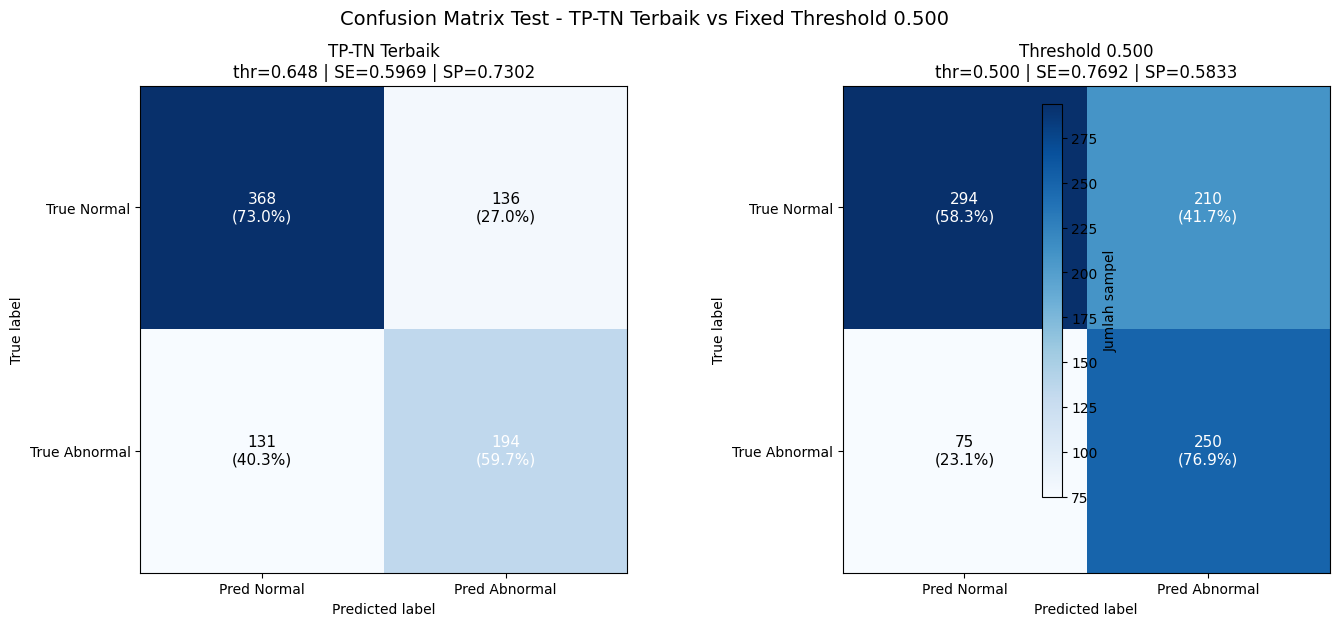

Saved combined 2 CM test figure: results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/two_operating_points_tp_tn_best_vs_fixed050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_two_confusion_matrices_test_tp_tn_best_vs_fixed050.png


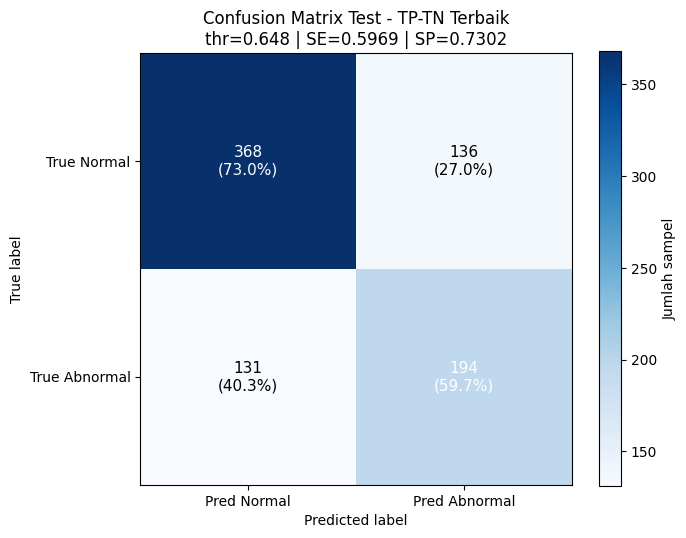

Saved: results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/two_operating_points_tp_tn_best_vs_fixed050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_confusion_matrix_test_tp_tn_best.png


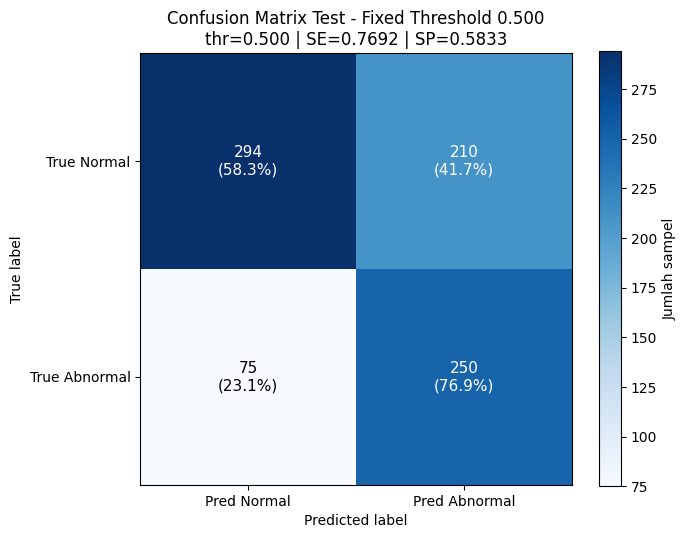

Saved: results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050/two_operating_points_tp_tn_best_vs_fixed050/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050_confusion_matrix_test_fixed0500.png
2 CONFUSION MATRIX SUMMARY
Scenario name: vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_cosine_wd1e4_thr050
Threshold step: 0.001

Selected thresholds:
- TP-TN Terbaik: 0.648 | validation_selected_tp_tn_best_min_sens_0.70_min_spec_0.50
- Threshold 0.500: 0.500 | fixed_threshold_0_500

Comparison table:


,set,operating_point,label,threshold,accuracy,sensitivity_abnormal,specificity_normal,precision_abnormal,f1_abnormal,balanced_score,harmonic_score,se_sp_gap,tn,fp,fn,tp,tp_tn_sum
0,validation,tp_tn_best,TP-TN Terbaik,0.648,0.586137,0.500787,0.742775,0.781327,0.610365,0.621781,0.598237,0.241987,257,89,317,318,575
1,test,tp_tn_best,TP-TN Terbaik,0.648,0.677925,0.596923,0.730159,0.587879,0.592366,0.663541,0.656853,0.133236,368,136,131,194,562
2,validation,fixed_0500,Threshold 0.500,0.500,0.617737,0.636220,0.583815,0.737226,0.683009,0.610018,0.608892,0.052405,202,144,231,404,606
3,test,fixed_0500,Threshold 0.500,0.500,0.656212,0.769231,0.583333,0.543478,0.636943,0.676282,0.663507,0.185897,294,210,75,250,544



Top 15 threshold kandidat dari validation set:


,threshold,accuracy,sensitivity_abnormal,specificity_normal,balanced_score,harmonic_score,se_sp_gap,tn,fp,fn,tp,tp_tn_sum,tp_tn_best_score
0,0.648,0.586137,0.500787,0.742775,0.621781,0.598237,0.241987,257,89,317,318,575,0.617939
1,0.643,0.586137,0.505512,0.734104,0.619808,0.598731,0.228592,254,92,314,321,575,0.616702
2,0.647,0.585117,0.500787,0.739884,0.620336,0.597297,0.239097,256,90,317,318,574,0.616640
3,0.644,0.585117,0.503937,0.734104,0.619021,0.597625,0.230167,254,92,315,320,574,0.615815
4,0.538,0.612640,0.606299,0.624277,0.615288,0.615157,0.017978,216,130,250,385,601,0.615731
5,0.551,0.608563,0.593701,0.635838,0.614769,0.614047,0.042137,220,126,258,377,597,0.615620
6,0.646,0.584098,0.500787,0.736994,0.618891,0.596353,0.236207,255,91,317,318,573,0.615340
7,0.649,0.583078,0.496063,0.742775,0.619419,0.594853,0.246712,257,89,320,315,572,0.615249
8,0.537,0.612640,0.607874,0.621387,0.614631,0.614556,0.013513,215,131,249,386,601,0.614974
9,0.544,0.609582,0.598425,0.630058,0.614242,0.613834,0.031633,218,128,255,380,598,0.614941



Test classification reports:

TP-TN Terbaik | threshold=0.648
              precision    recall  f1-score   support

      normal     0.7375    0.7302    0.7338       504
    abnormal     0.5879    0.5969    0.5924       325

    accuracy                         0.6779       829
   macro avg     0.6627    0.6635    0.6631       829
weighted avg     0.6788    0.6779    0.6784       829


Threshold 0.500 | threshold=0.500
              precision    recall  f1-score   support

      normal     0.7967    0.5833    0.6735       504
    abnormal     0.5435    0.7692    0.6369       325

    accuracy                         0.6562       829
   macro avg     0.6701    0.6763    0.6552       829
weighted avg     0.6975    0.6562    0.6592       829


Saved files:
Threshold search CSV       : results_vit_time_frequency_attention/vit_time_frequency_attention_binary_sr16k5s_logmel224_wce080120_full12_llrd085_nowarmup_nospecaug_bb5e6_head7e5_ls000_do020_tfap256_tfapdo010_sensharmconstr_sp050_ckpt_

In [26]:
# ============================================================
# CELL TAMBAHAN: 2 CONFUSION MATRIX
# 1. TP-TN terbaik
# 2. Fixed threshold 0.500
#
# Threshold TP-TN terbaik dipilih dari validation set,
# lalu diterapkan ke test set.
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

# ============================================================
# 0. KONFIGURASI
# ============================================================

FIXED_THRESHOLD = 0.500

THRESHOLD_START = 0.100
THRESHOLD_END = 0.900
THRESHOLD_STEP = 0.001

# Batas aman agar threshold tidak terlalu rendah dan tidak terlalu bias ke abnormal
MIN_ALLOWED_THRESHOLD = 0.350
MAX_ALLOWED_THRESHOLD = 0.900

# Constraint dasar untuk memilih TP-TN terbaik
MIN_SENSITIVITY_FOR_TP_TN = 0.7000
MIN_SPECIFICITY_FOR_TP_TN = 0.5000

REFERENCE_THRESHOLD = 0.500

RESULT_DIR = Path(RESULT_DIR)
RESULT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. VALIDASI GLOBAL DARI CELL 39
# ============================================================

required_globals = [
    "val_pred_fixed_050_df",
    "test_pred_fixed_050_df",
    "RESULT_DIR",
    "SCENARIO_NAME",
]

missing_globals = [g for g in required_globals if g not in globals()]

if missing_globals:
    raise RuntimeError(
        f"Global berikut belum tersedia: {missing_globals}\n"
        "Jalankan Cell 39 terlebih dahulu."
    )

val_base_df = val_pred_fixed_050_df.copy().reset_index(drop=True)
test_base_df = test_pred_fixed_050_df.copy().reset_index(drop=True)

required_cols = ["y_true_id", "prob_abnormal"]

for df_name, df in [
    ("val_pred_fixed_050_df", val_base_df),
    ("test_pred_fixed_050_df", test_base_df),
]:
    missing_cols = [c for c in required_cols if c not in df.columns]

    if missing_cols:
        raise ValueError(f"{df_name} kehilangan kolom wajib: {missing_cols}")

    if not set(df["y_true_id"].astype(int).unique()).issubset({0, 1}):
        raise ValueError(f"{df_name} memiliki y_true_id di luar 0 dan 1.")


# ============================================================
# 2. HELPER
# ============================================================

def safe_display(obj):
    try:
        display(obj)
    except NameError:
        print(obj)


def make_threshold_suffix(threshold):
    return f"{int(round(float(threshold) * 1000)):03d}"


def compute_threshold_metrics(pred_df, threshold):
    y_true = pred_df["y_true_id"].astype(int).values
    prob_abnormal = pred_df["prob_abnormal"].astype(float).values

    y_pred = (prob_abnormal >= float(threshold)).astype(int)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    tn, fp, fn, tp = cm.ravel()

    normal_support = tn + fp
    abnormal_support = tp + fn
    total_support = tn + fp + fn + tp

    sensitivity_abnormal = tp / (abnormal_support + 1e-12)
    specificity_normal = tn / (normal_support + 1e-12)
    precision_abnormal = tp / (tp + fp + 1e-12)

    accuracy = (tn + tp) / (total_support + 1e-12)

    f1_abnormal = (
        2.0 * precision_abnormal * sensitivity_abnormal /
        (precision_abnormal + sensitivity_abnormal + 1e-12)
    )

    balanced_score = (
        sensitivity_abnormal + specificity_normal
    ) / 2.0

    harmonic_score = (
        2.0 * sensitivity_abnormal * specificity_normal /
        (sensitivity_abnormal + specificity_normal + 1e-12)
    )

    tp_tn_sum = tp + tn
    fp_fn_sum = fp + fn

    fp_rate = fp / (normal_support + 1e-12)
    fn_rate = fn / (abnormal_support + 1e-12)

    se_sp_gap = abs(sensitivity_abnormal - specificity_normal)
    distance_to_reference_threshold = abs(float(threshold) - REFERENCE_THRESHOLD)

    try:
        auc = roc_auc_score(y_true, prob_abnormal)
    except Exception:
        auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, prob_abnormal)
    except Exception:
        pr_auc = np.nan

    # Skor TP-TN terbaik:
    # harmonic tinggi = sensitivity dan specificity sama-sama kuat
    # balanced tinggi = rata-rata SE-SP tinggi
    # specificity tetap diberi bobot agar TN tidak jatuh
    tp_tn_best_score = (
        0.45 * harmonic_score +
        0.30 * balanced_score +
        0.15 * accuracy +
        0.10 * specificity_normal
    )

    return {
        "threshold": float(threshold),

        "accuracy": float(accuracy),
        "sensitivity_abnormal": float(sensitivity_abnormal),
        "specificity_normal": float(specificity_normal),
        "precision_abnormal": float(precision_abnormal),
        "f1_abnormal": float(f1_abnormal),
        "balanced_score": float(balanced_score),
        "harmonic_score": float(harmonic_score),

        "auc": float(auc) if not np.isnan(auc) else np.nan,
        "pr_auc": float(pr_auc) if not np.isnan(pr_auc) else np.nan,

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),

        "normal_support": int(normal_support),
        "abnormal_support": int(abnormal_support),
        "total_support": int(total_support),

        "tp_tn_sum": int(tp_tn_sum),
        "fp_fn_sum": int(fp_fn_sum),

        "fp_rate": float(fp_rate),
        "fn_rate": float(fn_rate),
        "se_sp_gap": float(se_sp_gap),
        "distance_to_reference_threshold": float(distance_to_reference_threshold),

        "tp_tn_best_score": float(tp_tn_best_score),

        "confusion_matrix": cm,
        "y_pred": y_pred,
    }


def metrics_without_arrays(metrics, prefix=None):
    row = {}

    for k, v in metrics.items():
        if k in ["confusion_matrix", "y_pred"]:
            continue

        key = f"{prefix}_{k}" if prefix is not None else k
        row[key] = v

    return row


def build_prediction_df(base_df, threshold, policy):
    out_df = base_df.copy().reset_index(drop=True)

    out_df["threshold"] = float(threshold)
    out_df["threshold_policy"] = str(policy)

    out_df["y_pred_id"] = (
        out_df["prob_abnormal"].astype(float).values >= float(threshold)
    ).astype(int)

    out_df["y_pred_label"] = np.where(
        out_df["y_pred_id"] == 1,
        "abnormal",
        "normal",
    )

    out_df["is_correct"] = (
        out_df["y_true_id"].astype(int).values ==
        out_df["y_pred_id"].astype(int).values
    )

    return out_df


def plot_cm_on_axis(ax, cm, title):
    cm_plot = np.asarray(cm).astype(np.int64)
    cm_norm = cm_plot.astype(np.float64) / (
        cm_plot.sum(axis=1, keepdims=True) + 1e-12
    )

    im = ax.imshow(
        cm_plot,
        interpolation="nearest",
        cmap="Blues",
    )

    ax.set(
        xticks=np.arange(2),
        yticks=np.arange(2),
        xticklabels=["Pred Normal", "Pred Abnormal"],
        yticklabels=["True Normal", "True Abnormal"],
        xlabel="Predicted label",
        ylabel="True label",
        title=title,
    )

    threshold_color = cm_plot.max() / 2.0 if cm_plot.max() > 0 else 0.5

    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            ax.text(
                j,
                i,
                f"{cm_plot[i, j]}\n({cm_norm[i, j] * 100:.1f}%)",
                ha="center",
                va="center",
                color="white" if cm_plot[i, j] > threshold_color else "black",
                fontsize=11,
            )

    return im


def plot_single_confusion_matrix(cm, title, path):
    fig, ax = plt.subplots(figsize=(7, 6))

    im = plot_cm_on_axis(
        ax=ax,
        cm=cm,
        title=title,
    )

    fig.colorbar(im, ax=ax, shrink=0.85, label="Jumlah sampel")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()

    print("Saved:", path)


# ============================================================
# 3. THRESHOLD SEARCH PADA VALIDATION SET
# ============================================================

thresholds = np.round(
    np.arange(
        THRESHOLD_START,
        THRESHOLD_END + THRESHOLD_STEP,
        THRESHOLD_STEP,
    ),
    3,
)

rows = []

for thr in thresholds:
    metrics = compute_threshold_metrics(
        pred_df=val_base_df,
        threshold=thr,
    )

    rows.append(metrics_without_arrays(metrics))

threshold_search_df = pd.DataFrame(rows)

threshold_search_df["is_allowed_threshold"] = (
    (threshold_search_df["threshold"] >= MIN_ALLOWED_THRESHOLD) &
    (threshold_search_df["threshold"] <= MAX_ALLOWED_THRESHOLD)
)

threshold_search_df["is_safe_tp_tn"] = (
    (threshold_search_df["is_allowed_threshold"]) &
    (threshold_search_df["sensitivity_abnormal"] >= MIN_SENSITIVITY_FOR_TP_TN) &
    (threshold_search_df["specificity_normal"] >= MIN_SPECIFICITY_FOR_TP_TN)
)

unique_steps = np.unique(
    np.round(
        np.diff(np.sort(threshold_search_df["threshold"].unique())),
        6,
    )
)

print("Threshold search step unique:", unique_steps[:10])


# ============================================================
# 4. PILIH THRESHOLD TP-TN TERBAIK DARI VALIDATION SET
# ============================================================

tp_tn_best_candidate_df = threshold_search_df[
    threshold_search_df["is_safe_tp_tn"]
].copy()

if len(tp_tn_best_candidate_df) == 0:
    print(
        "[WARNING] Tidak ada threshold yang memenuhi batas minimal "
        "sensitivity dan specificity. Fallback ke threshold allowed."
    )

    tp_tn_best_candidate_df = threshold_search_df[
        threshold_search_df["is_allowed_threshold"]
    ].copy()

selected_tp_tn_best_row = (
    tp_tn_best_candidate_df
    .sort_values(
        by=[
            "tp_tn_best_score",
            "harmonic_score",
            "balanced_score",
            "specificity_normal",
            "sensitivity_abnormal",
            "accuracy",
            "distance_to_reference_threshold",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)

THRESHOLD_TP_TN_BEST = float(selected_tp_tn_best_row["threshold"])
THRESHOLD_FIXED_0500 = float(FIXED_THRESHOLD)


# ============================================================
# 5. HITUNG METRIK VALIDATION DAN TEST UNTUK 2 OPERATING POINT
# ============================================================

operating_points = [
    {
        "name": "tp_tn_best",
        "label": "TP-TN Terbaik",
        "threshold": THRESHOLD_TP_TN_BEST,
        "policy": (
            "validation_selected_tp_tn_best_"
            f"min_sens_{MIN_SENSITIVITY_FOR_TP_TN:.2f}_"
            f"min_spec_{MIN_SPECIFICITY_FOR_TP_TN:.2f}"
        ),
    },
    {
        "name": "fixed_0500",
        "label": "Threshold 0.500",
        "threshold": THRESHOLD_FIXED_0500,
        "policy": "fixed_threshold_0_500",
    },
]

summary_rows = []
val_pred_outputs = {}
test_pred_outputs = {}
val_metrics_outputs = {}
test_metrics_outputs = {}
val_cm_outputs = {}
test_cm_outputs = {}
val_report_outputs = {}
test_report_outputs = {}

for op in operating_points:
    op_name = op["name"]
    op_label = op["label"]
    op_thr = float(op["threshold"])
    op_policy = op["policy"]

    val_metrics = compute_threshold_metrics(
        pred_df=val_base_df,
        threshold=op_thr,
    )

    test_metrics = compute_threshold_metrics(
        pred_df=test_base_df,
        threshold=op_thr,
    )

    val_pred_df = build_prediction_df(
        base_df=val_base_df,
        threshold=op_thr,
        policy=op_policy,
    )

    test_pred_df = build_prediction_df(
        base_df=test_base_df,
        threshold=op_thr,
        policy=op_policy,
    )

    val_report_text = classification_report(
        val_pred_df["y_true_id"].astype(int).values,
        val_pred_df["y_pred_id"].astype(int).values,
        labels=[0, 1],
        target_names=["normal", "abnormal"],
        digits=4,
        zero_division=0,
    )

    test_report_text = classification_report(
        test_pred_df["y_true_id"].astype(int).values,
        test_pred_df["y_pred_id"].astype(int).values,
        labels=[0, 1],
        target_names=["normal", "abnormal"],
        digits=4,
        zero_division=0,
    )

    val_pred_outputs[op_name] = val_pred_df
    test_pred_outputs[op_name] = test_pred_df

    val_metrics_outputs[op_name] = val_metrics
    test_metrics_outputs[op_name] = test_metrics

    val_cm_outputs[op_name] = val_metrics["confusion_matrix"]
    test_cm_outputs[op_name] = test_metrics["confusion_matrix"]

    val_report_outputs[op_name] = val_report_text
    test_report_outputs[op_name] = test_report_text

    summary_rows.append({
        "set": "validation",
        "operating_point": op_name,
        "label": op_label,
        "threshold": op_thr,
        "policy": op_policy,
        **metrics_without_arrays(val_metrics),
    })

    summary_rows.append({
        "set": "test",
        "operating_point": op_name,
        "label": op_label,
        "threshold": op_thr,
        "policy": op_policy,
        **metrics_without_arrays(test_metrics),
    })

comparison_2cm_df = pd.DataFrame(summary_rows)


# ============================================================
# 6. SIMPAN OUTPUT
# ============================================================

TWO_CM_DIR = RESULT_DIR / "two_operating_points_tp_tn_best_vs_fixed050"
TWO_CM_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD_SEARCH_2CM_CSV_PATH = (
    TWO_CM_DIR /
    f"{SCENARIO_NAME}_threshold_search_tp_tn_best_step001.csv"
)

COMPARISON_2CM_CSV_PATH = (
    TWO_CM_DIR /
    f"{SCENARIO_NAME}_comparison_2cm_tp_tn_best_vs_fixed050.csv"
)

SUMMARY_2CM_JSON_PATH = (
    TWO_CM_DIR /
    f"{SCENARIO_NAME}_summary_2cm_tp_tn_best_vs_fixed050.json"
)

FIG_2CM_TEST_PATH = (
    TWO_CM_DIR /
    f"{SCENARIO_NAME}_two_confusion_matrices_test_tp_tn_best_vs_fixed050.png"
)

FIG_TP_TN_BEST_TEST_PATH = (
    TWO_CM_DIR /
    f"{SCENARIO_NAME}_confusion_matrix_test_tp_tn_best.png"
)

FIG_FIXED_0500_TEST_PATH = (
    TWO_CM_DIR /
    f"{SCENARIO_NAME}_confusion_matrix_test_fixed0500.png"
)

threshold_search_df.to_csv(THRESHOLD_SEARCH_2CM_CSV_PATH, index=False)
comparison_2cm_df.to_csv(COMPARISON_2CM_CSV_PATH, index=False)

for op in operating_points:
    op_name = op["name"]
    thr_suffix = make_threshold_suffix(op["threshold"])

    val_pred_outputs[op_name].to_csv(
        TWO_CM_DIR / f"{SCENARIO_NAME}_val_predictions_{op_name}_thr{thr_suffix}.csv",
        index=False,
    )

    test_pred_outputs[op_name].to_csv(
        TWO_CM_DIR / f"{SCENARIO_NAME}_test_predictions_{op_name}_thr{thr_suffix}.csv",
        index=False,
    )

    pd.DataFrame(
        val_cm_outputs[op_name],
        index=["True Normal", "True Abnormal"],
        columns=["Pred Normal", "Pred Abnormal"],
    ).to_csv(
        TWO_CM_DIR / f"{SCENARIO_NAME}_val_cm_{op_name}_thr{thr_suffix}.csv"
    )

    pd.DataFrame(
        test_cm_outputs[op_name],
        index=["True Normal", "True Abnormal"],
        columns=["Pred Normal", "Pred Abnormal"],
    ).to_csv(
        TWO_CM_DIR / f"{SCENARIO_NAME}_test_cm_{op_name}_thr{thr_suffix}.csv"
    )

    with open(
        TWO_CM_DIR / f"{SCENARIO_NAME}_val_report_{op_name}_thr{thr_suffix}.txt",
        "w",
        encoding="utf-8",
    ) as f:
        f.write(val_report_outputs[op_name])

    with open(
        TWO_CM_DIR / f"{SCENARIO_NAME}_test_report_{op_name}_thr{thr_suffix}.txt",
        "w",
        encoding="utf-8",
    ) as f:
        f.write(test_report_outputs[op_name])

summary_2cm_dict = {
    "scenario_name": SCENARIO_NAME,
    "threshold_selection_source": "validation_set",
    "applied_to": "test_set",
    "threshold_step": THRESHOLD_STEP,
    "fixed_threshold": FIXED_THRESHOLD,
    "selected_thresholds": {
        "tp_tn_best": THRESHOLD_TP_TN_BEST,
        "fixed_0500": THRESHOLD_FIXED_0500,
    },
    "config": {
        "min_allowed_threshold": MIN_ALLOWED_THRESHOLD,
        "max_allowed_threshold": MAX_ALLOWED_THRESHOLD,
        "min_sensitivity_for_tp_tn": MIN_SENSITIVITY_FOR_TP_TN,
        "min_specificity_for_tp_tn": MIN_SPECIFICITY_FOR_TP_TN,
    },
    "comparison": comparison_2cm_df.to_dict(orient="records"),
    "paths": {
        "threshold_search_csv": str(THRESHOLD_SEARCH_2CM_CSV_PATH),
        "comparison_csv": str(COMPARISON_2CM_CSV_PATH),
        "fig_2cm_test": str(FIG_2CM_TEST_PATH),
        "fig_tp_tn_best_test": str(FIG_TP_TN_BEST_TEST_PATH),
        "fig_fixed_0500_test": str(FIG_FIXED_0500_TEST_PATH),
        "summary_json": str(SUMMARY_2CM_JSON_PATH),
    },
}

with open(SUMMARY_2CM_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(summary_2cm_dict, f, indent=2, ensure_ascii=False)


# ============================================================
# 7. PLOT 2 CONFUSION MATRIX TEST DALAM SATU GAMBAR
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, op in zip(axes, operating_points):
    op_name = op["name"]
    op_label = op["label"]
    op_thr = float(op["threshold"])

    metrics = test_metrics_outputs[op_name]
    cm = test_cm_outputs[op_name]

    title = (
        f"{op_label}\n"
        f"thr={op_thr:.3f} | "
        f"SE={metrics['sensitivity_abnormal']:.4f} | "
        f"SP={metrics['specificity_normal']:.4f}"
    )

    im = plot_cm_on_axis(
        ax=ax,
        cm=cm,
        title=title,
    )

fig.suptitle(
    "Confusion Matrix Test - TP-TN Terbaik vs Fixed Threshold 0.500",
    fontsize=14,
)

fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    shrink=0.85,
    label="Jumlah sampel",
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIG_2CM_TEST_PATH, dpi=150)
plt.show()

print("Saved combined 2 CM test figure:", FIG_2CM_TEST_PATH)


# ============================================================
# 8. PLOT MASING-MASING CONFUSION MATRIX TEST SEBAGAI CITRA TERPISAH
# ============================================================

plot_single_confusion_matrix(
    cm=test_cm_outputs["tp_tn_best"],
    title=(
        f"Confusion Matrix Test - TP-TN Terbaik\n"
        f"thr={THRESHOLD_TP_TN_BEST:.3f} | "
        f"SE={test_metrics_outputs['tp_tn_best']['sensitivity_abnormal']:.4f} | "
        f"SP={test_metrics_outputs['tp_tn_best']['specificity_normal']:.4f}"
    ),
    path=FIG_TP_TN_BEST_TEST_PATH,
)

plot_single_confusion_matrix(
    cm=test_cm_outputs["fixed_0500"],
    title=(
        f"Confusion Matrix Test - Fixed Threshold 0.500\n"
        f"thr={THRESHOLD_FIXED_0500:.3f} | "
        f"SE={test_metrics_outputs['fixed_0500']['sensitivity_abnormal']:.4f} | "
        f"SP={test_metrics_outputs['fixed_0500']['specificity_normal']:.4f}"
    ),
    path=FIG_FIXED_0500_TEST_PATH,
)


# ============================================================
# 9. OUTPUT RINGKAS
# ============================================================

print("=" * 90)
print("2 CONFUSION MATRIX SUMMARY")
print("=" * 90)

print("Scenario name:", SCENARIO_NAME)
print("Threshold step:", THRESHOLD_STEP)

print("\nSelected thresholds:")
for op in operating_points:
    print(
        f"- {op['label']}: "
        f"{op['threshold']:.3f} | {op['policy']}"
    )

print("\nComparison table:")
safe_display(comparison_2cm_df[[
    "set",
    "operating_point",
    "label",
    "threshold",
    "accuracy",
    "sensitivity_abnormal",
    "specificity_normal",
    "precision_abnormal",
    "f1_abnormal",
    "balanced_score",
    "harmonic_score",
    "se_sp_gap",
    "tn",
    "fp",
    "fn",
    "tp",
    "tp_tn_sum",
]])

print("\nTop 15 threshold kandidat dari validation set:")
top_candidate_df = threshold_search_df[
    threshold_search_df["is_safe_tp_tn"]
].copy()

if len(top_candidate_df) == 0:
    top_candidate_df = threshold_search_df[
        threshold_search_df["is_allowed_threshold"]
    ].copy()

top_candidate_df = top_candidate_df.sort_values(
    by=[
        "tp_tn_best_score",
        "harmonic_score",
        "balanced_score",
        "specificity_normal",
        "sensitivity_abnormal",
        "accuracy",
    ],
    ascending=[
        False,
        False,
        False,
        False,
        False,
        False,
    ],
).reset_index(drop=True)

safe_display(top_candidate_df[[
    "threshold",
    "accuracy",
    "sensitivity_abnormal",
    "specificity_normal",
    "balanced_score",
    "harmonic_score",
    "se_sp_gap",
    "tn",
    "fp",
    "fn",
    "tp",
    "tp_tn_sum",
    "tp_tn_best_score",
]].head(15))

print("\nTest classification reports:")
for op in operating_points:
    op_name = op["name"]
    print("\n" + "=" * 90)
    print(f"{op['label']} | threshold={op['threshold']:.3f}")
    print("=" * 90)
    print(test_report_outputs[op_name])

print("\nSaved files:")
print("Threshold search CSV       :", THRESHOLD_SEARCH_2CM_CSV_PATH)
print("Comparison CSV             :", COMPARISON_2CM_CSV_PATH)
print("Combined 2 CM Test Figure  :", FIG_2CM_TEST_PATH)
print("TP-TN Best Test Figure     :", FIG_TP_TN_BEST_TEST_PATH)
print("Fixed 0.500 Test Figure    :", FIG_FIXED_0500_TEST_PATH)
print("Summary JSON               :", SUMMARY_2CM_JSON_PATH)
print("=" * 90)


# ============================================================
# 10. SIMPAN KE GLOBALS
# ============================================================

globals()["THRESHOLD_TP_TN_BEST"] = THRESHOLD_TP_TN_BEST
globals()["THRESHOLD_FIXED_0500"] = THRESHOLD_FIXED_0500

globals()["operating_points_2cm_tp_tn_best_fixed050"] = operating_points
globals()["comparison_2cm_tp_tn_best_fixed050_df"] = comparison_2cm_df
globals()["threshold_search_2cm_tp_tn_best_fixed050_df"] = threshold_search_df

globals()["val_metrics_2cm_tp_tn_best_fixed050"] = val_metrics_outputs
globals()["test_metrics_2cm_tp_tn_best_fixed050"] = test_metrics_outputs

globals()["val_cm_2cm_tp_tn_best_fixed050"] = val_cm_outputs
globals()["test_cm_2cm_tp_tn_best_fixed050"] = test_cm_outputs

globals()["val_pred_2cm_tp_tn_best_fixed050"] = val_pred_outputs
globals()["test_pred_2cm_tp_tn_best_fixed050"] = test_pred_outputs

globals()["test_report_2cm_tp_tn_best_fixed050"] = test_report_outputs
globals()["val_report_2cm_tp_tn_best_fixed050"] = val_report_outputs

globals()["THRESHOLD_SEARCH_2CM_TP_TN_BEST_FIXED050_CSV_PATH"] = str(THRESHOLD_SEARCH_2CM_CSV_PATH)
globals()["COMPARISON_2CM_TP_TN_BEST_FIXED050_CSV_PATH"] = str(COMPARISON_2CM_CSV_PATH)
globals()["FIG_2CM_TEST_TP_TN_BEST_FIXED050_PATH"] = str(FIG_2CM_TEST_PATH)
globals()["FIG_TP_TN_BEST_TEST_PATH"] = str(FIG_TP_TN_BEST_TEST_PATH)
globals()["FIG_FIXED_0500_TEST_PATH"] = str(FIG_FIXED_0500_TEST_PATH)
globals()["SUMMARY_2CM_TP_TN_BEST_FIXED050_JSON_PATH"] = str(SUMMARY_2CM_JSON_PATH)

print("\n[OK] 2 confusion matrix TP-TN terbaik dan fixed threshold 0.500 selesai.")